<a href="https://colab.research.google.com/github/hwayobi2020/StockCrash/blob/main/traindata_advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# data preprocess

In [ ]:
# prompt: analysis_timeseries_2015.csv부터 analysis_timeseries_2024.csv 파일까지 연도별 데이터들을 합쳐서 time_series_total.csv,   time_series_total.parquet로 만들어줘. 합칠때 BSOP_DATE 컬럼을 기준으로 각년도가 아닌 것은 제외해줘 예를 들어서 2025년도 파일에는 2016년도 데이터도 일부 있는데 이건 제외해야 해.

import pandas as pd
import glob
import os

# 파일 목록 가져오기
file_paths = glob.glob('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/analysis_timeseries_20*.csv')


# 데이터프레임들을 저장할 리스트
dfs = []

# 각 파일별로 처리
for file_path in file_paths:
    year = int(os.path.basename(file_path).split('_')[2].split('.')[0]) # 파일 이름에서 연도 추출
    df = pd.read_csv(file_path)
    # BSOP_DATE 컬럼을 datetime 객체로 변환
    df['BSOP_DATE'] = pd.to_datetime(df['BSOP_DATE'])
    # 연도 필터링
    df = df[df['BSOP_DATE'].dt.year == year]
    dfs.append(df)

print(dfs)

# 모든 데이터프레임 합치기
total_df = pd.concat(dfs, ignore_index=True)

# CSV 파일로 저장
total_df.to_csv('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/time_series_total.csv', index=False, encoding='cp949')  # 또는 encoding='cp949'

# Parquet 파일로 저장
total_df.to_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/time_series_total.parquet', index=False)


[       SHRN_ISCD        HTS_KOR_ISNM  BSOP_DATE  STCK_PRPR  WindowDrop
0        A000020                동화약품 2015-01-02       5530         0.0
1        A000020                동화약품 2015-01-05       5500         0.0
2        A000020                동화약품 2015-01-06       5470         0.0
3        A000020                동화약품 2015-01-07       5540         0.0
4        A000020                동화약품 2015-01-08       5500         0.0
...          ...                 ...        ...        ...         ...
700069   Q590002  미래에셋 일본 바이백 ETN(H) 2015-12-23      10170         0.0
700070   Q590002  미래에셋 일본 바이백 ETN(H) 2015-12-24      10075         0.0
700071   Q590002  미래에셋 일본 바이백 ETN(H) 2015-12-28      10035         0.0
700072   Q590002  미래에셋 일본 바이백 ETN(H) 2015-12-29      10170         0.0
700073   Q590002  미래에셋 일본 바이백 ETN(H) 2015-12-30      10275         0.0

[564867 rows x 5 columns],        SHRN_ISCD        HTS_KOR_ISNM  BSOP_DATE  STCK_PRPR  WindowDrop
0        A000020                동화약품 2016-01-04 

KeyboardInterrupt: 

In [ ]:
# prompt: time_series_total.parquet' 에서SHRN_ISCD 이  A000150인 것 중 WindowDrop이 1인 것만 읽어봐

import pandas as pd

# Parquet 파일 읽기
df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/time_series_total.parquet')

# 조건에 맞는 데이터 필터링
filtered_df = df[(df['SHRN_ISCD'] == 'A000150') & (df['WindowDrop'] == 1)]

# 필터링된 데이터 출력
filtered_df


,SHRN_ISCD,HTS_KOR_ISNM,BSOP_DATE,STCK_PRPR,WindowDrop
3680,A000150,두산,2015-11-04,120000,1.0
3681,A000150,두산,2015-11-05,121000,1.0
3682,A000150,두산,2015-11-06,118000,1.0
3683,A000150,두산,2015-11-09,122000,1.0
3685,A000150,두산,2015-11-11,121000,1.0
...,...,...,...,...,...
6850613,A000150,두산,2024-07-11,241500,1.0
6850614,A000150,두산,2024-07-12,237000,1.0
6850615,A000150,두산,2024-07-15,239500,1.0
6850616,A000150,두산,2024-07-16,227500,1.0


In [ ]:
# prompt: "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/time_series_total.parquet에서 컬럼이름들을 출력해줘

import pandas as pd

# 파일 경로 설정
file_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/time_series_total.parquet"

# parquet 파일 읽기
try:
  df = pd.read_parquet(file_path)
  # 컬럼 이름 출력
  print(df.columns)
except FileNotFoundError:
  print(f"Error: File not found at {file_path}")
except Exception as e:
  print(f"An error occurred: {e}")


Index(['SHRN_ISCD', 'HTS_KOR_ISNM', 'BSOP_DATE', 'STCK_PRPR', 'WindowDrop'], dtype='object')


In [ ]:
# prompt: data_stock 폴더에 있는 stock_all_vkospi.parquet 파일의 컬럼들을 열거해봐

import pandas as pd

# 파일 경로 설정
file_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet"

# parquet 파일 읽기
try:
  df = pd.read_parquet(file_path)
  # 컬럼 이름 출력
  print(df.columns)
except FileNotFoundError:
  print(f"Error: File not found at {file_path}")
except Exception as e:
  print(f"An error occurred: {e}")


Index(['BSOP_DATE', 'STND_ISCD', 'SHRN_ISCD', 'SCRT_GRP_CLS_CODE',
       'MRKT_DIV_CLS_CODE', 'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR',
       'FN_ACML_TR_PBMN', 'CRDT_RMND_RATE', 'MARKET_CAP', 'FRGN_HLDN_RATE',
       'FRGN_NTBY_QTY', 'ORGN_NTBY_QTY', 'vkospi', 'ks200', 'fx'],
      dtype='object')


In [ ]:
# prompt: 이 코드 내 경로에 맞춰서 파큐파일 로드하는 식으로 바꿔줘
# import pandas as pd
# # 데이터 불러오기
# time_series = pd.read_csv("/mnt/data/time_series_total.csv")
# stock_all = pd.read_csv("/mnt/data/stock_all.csv")

#stock_all
#Index(['STND_ISCD', 'SHRN_ISCD', 'MRKT_DIV_CLS_CODE', 'SCRT_GRP_CLS_CODE',
#       'BSOP_DATE', 'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR',
#       'CRDT_RMND_RATE', 'FN_ACML_TR_PBMN', 'MARKET_CAP'],
#      dtype='object')

import pandas as pd

# 파일 경로 설정
time_series_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/qresult.parquet"
stock_all_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all.parquet"
output_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_result.parquet"

try:
    time_series = pd.read_parquet(time_series_path)
    stock_all = pd.read_parquet(stock_all_path)

    # 모든 문자열 데이터를 strip() 적용하여 공백 제거
    time_series = time_series.applymap(lambda x: x.strip() if isinstance(x, str) else x)
    stock_all = stock_all.applymap(lambda x: x.strip() if isinstance(x, str) else x)

    # 날짜 데이터 변환 (datetime 형식으로 변환)
    time_series['BSOP_DATE'] = pd.to_datetime(time_series['quarter_end_date'])
    stock_all['BSOP_DATE'] = pd.to_datetime(stock_all['BSOP_DATE'])

    # 필요한 컬럼 선택
    stock_selected = stock_all[['SHRN_ISCD', 'BSOP_DATE', 'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR', 'FN_ACML_TR_PBMN',
                                'CRDT_RMND_RATE', 'MARKET_CAP',
                                'SCRT_GRP_CLS_CODE','MRKT_DIV_CLS_CODE',
                                'ORGN_NTBY_QTY',
                                ]]

    # 데이터 병합 (왼쪽 기준 병합)
    merged_df = time_series.merge(stock_selected, on=['SHRN_ISCD', 'BSOP_DATE'], how='left')

    # 만약 merged_df에 'window_drop' 컬럼이 있다면, 마지막 컬럼으로 이동
    if 'WindowDrop' in merged_df.columns:
        # 'window_drop'을 제외한 나머지 컬럼 순서를 유지하고 마지막에 'window_drop' 추가
        cols = [col for col in merged_df.columns if col != 'WindowDrop'] + ['WindowDrop']
        merged_df = merged_df[cols]

    # 결과 저장
    merged_df.to_parquet(output_path, index=False)
    merged_df.to_csv('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_result.csv', index=False, encoding='cp949')  # 또는 encoding='cp949'

    # 아래 코드는 Colab 환경에서만 동작하므로 주석 처리
    # import ace_tools as tools
    # tools.display_dataframe_to_user(name="Merged Time Series Data", dataframe=merged_df)

except FileNotFoundError as e:
    print(f"Error: File not found - {e}")
except Exception as e:
    print(f"An error occurred: {e}")


<ipython-input-2-2872833a62e3>:25: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  time_series = time_series.applymap(lambda x: x.strip() if isinstance(x, str) else x)
<ipython-input-2-2872833a62e3>:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  stock_all = stock_all.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [ ]:
# prompt: stock_result 파일 읽어봐

import pandas as pd

# 파일 경로 설정
file_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_result.parquet"

try:
    df = pd.read_parquet(file_path)
    print(df.head())  # 처음 5개 행 출력
    print(df.info())  # 데이터프레임 정보 출력
    print(df.describe()) # 데이터프레임 요약 통계량 출력
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")


  SHRN_ISCD quarter quarter_end_date  quarter_last_price  min_price  \
0   A000020  2015Q1       2015-03-31              7510.0     7510.0   
1   A000020  2015Q2       2015-06-30              9070.0     6580.0   
2   A000020  2015Q3       2015-09-30              7020.0     6810.0   
3   A000020  2015Q4       2015-12-30              8140.0     7700.0   
4   A000020  2016Q1       2016-03-31              8110.0     8390.0   

   max_price  min_ratio  max_ratio  windowdrop  BSOP_DATE  STCK_PRPR  \
0    10400.0   1.000000   1.384820           0 2015-03-31     7510.0   
1    11200.0   0.725469   1.234840           0 2015-06-30     9070.0   
2     8510.0   0.970085   1.212251           0 2015-09-30     7020.0   
3     9510.0   0.945946   1.168305           0 2015-12-30     8140.0   
4    11550.0   1.034525   1.424168           0 2016-03-31     8110.0   

   ADJ_PRPR  W52_HGPR  W52_LWPR  FN_ACML_TR_PBMN  CRDT_RMND_RATE  \
0    7510.0    7940.0    4905.0     8.100601e+08            1.18   
1   

In [ ]:
# prompt: stock_fin_result_with_vkospi에 A352820 종목의 데이터를 A352820.csv로 저장해줘

import pandas as pd

# 파일 경로 설정
file_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_fin_result_with_vkospi.parquet"

try:
    df = pd.read_parquet(file_path)

    # A352820 종목 데이터 필터링
    a352820_df = df[df['SHRN_ISCD'] == 'A352820']

    # CSV 파일로 저장
    a352820_df.to_csv('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/A352820.csv', index=False, encoding='cp949')

    print("A352820.csv 파일이 생성되었습니다.")

except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except KeyError:
    print("Error: 'SHRN_ISCD' column not found in the DataFrame.")
except Exception as e:
    print(f"An error occurred: {e}")


A352820.csv 파일이 생성되었습니다.


In [ ]:
# prompt: stock_result파일을 csv파일로 바꿔봐

import pandas as pd
# 파일 경로 설정
parquet_file_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_result.parquet"
csv_file_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_result.csv"  # CSV 파일 저장 경로

try:
    df = pd.read_parquet(parquet_file_path)
    df.to_csv(csv_file_path, index=False, encoding='utf-8-sig')  # CSV 파일로 저장, 인덱스 제외, UTF-8 encoding with BOM
    print(f"Successfully converted '{parquet_file_path}' to '{csv_file_path}'")

except FileNotFoundError:
    print(f"Error: Parquet file not found at {parquet_file_path}")
except Exception as e:
    print(f"An error occurred: {e}")


Successfully converted '/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_result.parquet' to '/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_result.csv'


In [ ]:
# prompt: stock_fin_result를 csv로 복사해줘

import pandas as pd

# 파일 경로 설정
parquet_file_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_fin_result.parquet"
csv_file_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_fin_result.csv"  # CSV 파일 저장 경로

try:
    df = pd.read_parquet(parquet_file_path)
    df.to_csv(csv_file_path, index=False, encoding='utf-8-sig')  # CSV 파일로 저장, 인덱스 제외, UTF-8 encoding with BOM
    print(f"Successfully converted '{parquet_file_path}' to '{csv_file_path}'")

except FileNotFoundError:
    print(f"Error: Parquet file not found at {parquet_file_path}")
except Exception as e:
    print(f"An error occurred: {e}")


Successfully converted '/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_fin_result.parquet' to '/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_fin_result.csv'


In [ ]:
import pandas as pd
import numpy as np
import traceback

# 파일 경로 설정
stock_result_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_result.parquet"
fselect_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/data_fin/fselected.parquet"
output_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_fin_result.parquet"

# 처리할 재무 컬럼 리스트 (추가/삭제 시 FIN_COLS 만 수정하면 됩니다)
FIN_COLS = ['ROE', 'DR', 'ROE_INC', 'PS' , 'SHORT_DEBT', 'DEBT_COST_RATIO', 'EQUITY',
            'NET_DEBT', 'DEBT_COST','DEBT_DEPENDENCY','NET_INCOME', 'ICR',
            'F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9', 'F10', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19', 'F20', 'F21', 'F22', 'F23', 'F24', 'F25', 'F26', 'F27', 'F28', 'F29', 'F30', 'F31', 'F32', 'F33', 'F34', 'F35', 'F36', 'F37', 'F38', 'F39', 'F40', 'F41', 'F42', 'F43', 'F44', 'F45', 'F46', 'F47', 'F48', 'F49', 'F50', 'F51', 'F52', 'F53', 'F54', 'F55', 'F56', 'F57', 'F58', 'F59', 'F60', 'F61', 'F62', 'F63', 'F64', 'F65', 'F66', 'F67', 'F68', 'F69', 'F70', 'F71', 'F72', 'F73', 'F74', 'F75',
           ]

try:
    # 데이터 불러오기
    stock_result_df = pd.read_parquet(stock_result_path)
    fselect_df = pd.read_parquet(fselect_path)

    # 데이터 타입 확인
    print("Data types before conversion:")
    print("BSOP_DATE:", stock_result_df['BSOP_DATE'].dtype)
    print("fromdate:", fselect_df['fromdate'].dtype)
    print("todate:", fselect_df['todate'].dtype)

    # 날짜 형식 통일
    stock_result_df['BSOP_DATE'] = pd.to_datetime(stock_result_df['BSOP_DATE'], errors='coerce')
    fselect_df['fromdate'] = pd.to_datetime(fselect_df['fromdate'], errors='coerce')
    fselect_df['todate'] = pd.to_datetime(fselect_df['todate'], errors='coerce')

    # 데이터 타입 재확인
    print("\nData types after conversion:")
    print("BSOP_DATE:", stock_result_df['BSOP_DATE'].dtype)
    print("fromdate:", fselect_df['fromdate'].dtype)
    print("todate:", fselect_df['todate'].dtype)

    # 그룹핑
    grouped_stock = stock_result_df.groupby('SHRN_ISCD', group_keys=False)
    grouped_fselect = fselect_df.groupby('SHRN_ISCD', group_keys=False)

    def fill_financial_info(stock_df, select_df):
        dates = stock_df['BSOP_DATE'].to_numpy()
        n = len(dates)

        # 재무 컬럼별 초기 np.nan 배열 생성 (FIN_COLS 사용)
        fin_arrays = {col: np.full(n, np.nan) for col in FIN_COLS}

        for _, row in select_df.iterrows():
            from_d = row['fromdate'].to_numpy()  # Timestamp를 numpy datetime64로 변환
            to_d   = row['todate'].to_numpy()

            start_idx = np.searchsorted(dates, from_d, side='left')
            end_idx   = np.searchsorted(dates, to_d, side='right') - 1

            if start_idx <= end_idx and start_idx < n and end_idx >= 0:
                start_idx = max(start_idx, 0)
                end_idx   = min(end_idx, n - 1)
                # 각 재무 컬럼에 대해 값 할당
                for col in FIN_COLS:
                    fin_arrays[col][start_idx:end_idx+1] = row[col]

        # 계산된 값을 stock_df에 추가
        for col in FIN_COLS:
            stock_df[col] = fin_arrays[col]
        return stock_df

    # 최종 결합할 리스트
    result_list = []

    # stock_result_df의 각 종목 그룹을 순회
    for code, s_df in grouped_stock:
        # 그룹 내에서 BSOP_DATE를 기준으로 정렬
        s_df = s_df.sort_values('BSOP_DATE')

        if code in grouped_fselect.groups:
            f_df = grouped_fselect.get_group(code)
            # fselect_df 그룹 내에서 fromdate를 기준으로 정렬
            f_df = f_df.sort_values('fromdate')
            s_df = fill_financial_info(s_df, f_df)
        else:
            # 해당 코드에 대한 재무 구간 정보가 없으면 NaN 처리 (FIN_COLS 사용)
            for col in FIN_COLS:
                s_df[col] = np.nan
        result_list.append(s_df)

    # 그룹별로 처리한 데이터 재결합
    stock_fin_result = pd.concat(result_list, axis=0)

    # 최종 파일 저장
    stock_fin_result.to_parquet(output_path, index=False)
    stock_fin_result.to_csv('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_fin_result.csv', index=False, encoding='cp949')
    print("Processing completed successfully.")

except FileNotFoundError as e:
    print(f"Error: File not found - {e}")
except Exception as e:
    print(f"An error occurred: {e}")
    print(f"Error type: {type(e)}")
    traceback.print_exc()


Data types before conversion:
BSOP_DATE: datetime64[ns]
fromdate: datetime64[ns]
todate: datetime64[ns]

Data types after conversion:
BSOP_DATE: datetime64[ns]
fromdate: datetime64[ns]
todate: datetime64[ns]
Processing completed successfully.


In [ ]:
# prompt: stock_fin_result.parque에 VKOSPI 컬럼을 추가하고, 해당 컬럼에는 vkospi.csv 파일의 vdate와 stock_fin_result 안의 BSOP_DATE와 같은 날짜에 대해서  vkospi.csv의 vkospi 값을 넣어줘

import pandas as pd

# 파일 경로 설정
stock_fin_result_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_fin_result.parquet"
vkospi_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/vkospi.csv"  # vkospi.csv 파일 경로
output_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_fin_result_with_vkospi.parquet"

try:
    # 데이터 불러오기
    stock_fin_result = pd.read_parquet(stock_fin_result_path)
    vkospi = pd.read_csv(vkospi_path)

    # 날짜 형식 일치 확인 및 변환
    stock_fin_result['BSOP_DATE'] = pd.to_datetime(stock_fin_result['BSOP_DATE'])
    vkospi['vdate'] = pd.to_datetime(vkospi['vdate'])

    # vkospi 데이터에서 필요한 컬럼만 선택
    vkospi = vkospi[['vdate', 'vkospi', 'ks200']]

    # 데이터 병합
    stock_fin_result = pd.merge(stock_fin_result, vkospi, left_on='BSOP_DATE', right_on='vdate', how='left')

    # VKOSPI 컬럼 추가 (병합된 결과에서 vkospi 값 사용)
    stock_fin_result = stock_fin_result.rename(columns={'vkospi': 'VKOSPI'})

    # 불필요한 'vdate' 컬럼 제거
    stock_fin_result = stock_fin_result.drop('vdate', axis=1)

    # 결과 저장
    stock_fin_result.to_parquet(output_path, index=False)
    stock_fin_result.to_csv('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_fin_result_with_vkospi.csv',index=False, encoding='cp949')

    print(f"VKOSPI column added and saved to {output_path}")

except FileNotFoundError as e:
    print(f"Error: File not found - {e}")
except Exception as e:
    print(f"An error occurred: {e}")


VKOSPI column added and saved to /content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_fin_result_with_vkospi.parquet


In [ ]:
# prompt: stock_fin_result에서 아래 컬럼들만을 남기고 이름을 fin_result로 저장해줘
#        'SHRN_ISCD',
#        'BSOP_DATE',
#        'ROE', 'DR',
#        'ROE_INC', 'PS', 'SHORT_DEBT', 'DEBT_COST_RATIO', 'EQUITY', 'NET_DEBT',
#        'DEBT_COST', 'DEBT_DEPENDENCY', 'NET_INCOME', 'ICR', 'CF',
#        'windowdrop'

import pandas as pd

# 파일 경로 설정
file_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_fin_result.parquet"
output_file_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/fin_result.parquet"

try:
    # Parquet 파일 읽기
    df = pd.read_parquet(file_path)

    # 원하는 컬럼만 선택
    selected_columns = [
        'SHRN_ISCD', 'BSOP_DATE', 'ROE', 'DR', 'ROE_INC', 'PS', 'SHORT_DEBT',
        'DEBT_COST_RATIO', 'EQUITY', 'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY',
        'NET_INCOME', 'ICR', 'CF', 'windowdrop'
    ]

    # 'windowdrop' 컬럼이 존재하지 않을 경우 에러 처리
    if 'windowdrop' not in df.columns:
        print("'windowdrop' column not found. Using 'WindowDrop' instead.")
        if 'WindowDrop' in df.columns:
            selected_columns = [col if col != 'windowdrop' else 'WindowDrop' for col in selected_columns]
        else:
            print("Neither 'windowdrop' nor 'WindowDrop' columns are present.")
            # 적절한 처리를 추가, 예: 빈 DataFrame 생성, 프로그램 종료 등
            # 예시:
            # fin_result = pd.DataFrame(columns=selected_columns)
            # raise Exception("'windowdrop' column not found.")
            selected_columns.remove('windowdrop')


    fin_result = df[selected_columns]

    # 결과를 Parquet 파일로 저장
    fin_result.to_parquet(output_file_path, index=False)
    print(f"Successfully saved the selected columns to {output_file_path}")

except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except KeyError as e:
    print(f"Error: Column '{e}' not found in the DataFrame.")
except Exception as e:
    print(f"An error occurred: {e}")


Successfully saved the selected columns to /content/drive/MyDrive/Colab Notebooks/hana_stock/result/fin_result.parquet


In [ ]:
# prompt: stock_all_vkospi와 fin_result에서 SHRN_ISCD 기준으로 50종목만 임의로 뽑은 다음에 각각에 대해서
# stock_all_vkospi_sample, fin_result_sample로 저장해줘, 그리고 두 파일은 파큐파일 하나, 그리고 csv파일로도 저장해줘
# 돌릴때마다 값이 바뀌지 않도록 시드를 고정해줘

import pandas as pd
import numpy as np

# 파일 경로 설정
stock_all_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet"
fin_result_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/result/fin_result.parquet"

# Seed 고정
np.random.seed(42)

try:
    # 데이터 불러오기
    stock_all_df = pd.read_parquet(stock_all_path)
    fin_result_df = pd.read_parquet(fin_result_path)

    # SHRN_ISCD 기준으로 50개 종목 랜덤 샘플링
    sampled_shrn_iscd = np.random.choice(stock_all_df['SHRN_ISCD'].unique(), size=50, replace=False)

    # 샘플링된 종목으로 데이터프레임 필터링
    stock_all_vkospi_sample = stock_all_df[stock_all_df['SHRN_ISCD'].isin(sampled_shrn_iscd)]
    fin_result_sample = fin_result_df[fin_result_df['SHRN_ISCD'].isin(sampled_shrn_iscd)]

    # parquet 파일로 저장
    stock_all_vkospi_sample.to_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_all_vkospi_sample.parquet', index=False)
    fin_result_sample.to_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/fin_result_sample.parquet', index=False)

    # csv 파일로 저장 (encoding='cp949' 추가)
    stock_all_vkospi_sample.to_csv('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/stock_all_vkospi_sample.csv', index=False, encoding='cp949')
    fin_result_sample.to_csv('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/fin_result_sample.csv', index=False, encoding='cp949')

    print("샘플링 및 저장 완료")

except FileNotFoundError:
    print("파일을 찾을 수 없습니다.")
except Exception as e:
    print(f"오류 발생: {e}")


샘플링 및 저장 완료


# pip install


In [ ]:
import subprocess
import sys
import numpy as np
from packaging import version  # ← 이 부분이 누락됨
required_version = "1.26.4"

# 현재 numpy 버전 확인 (예: 2.2.4는 호환되지 않음)
if version.parse(np.__version__) >= version.parse("2.0.0"):
    print(f"현재 numpy 버전: {np.__version__} - 호환되지 않습니다. {required_version}로 재설치합니다.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"numpy=={required_version}"])
    print("재설치 완료. 런타임을 재시작하세요.")
else:
    print("numpy 버전이 호환됩니다.")

!pip install catboost

현재 numpy 버전: 2.0.2 - 호환되지 않습니다. 1.26.4로 재설치합니다.
재설치 완료. 런타임을 재시작하세요.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 20.6 MB/s eta 0:00:00


In [ ]:
!pip install PyWavelets

In [ ]:
# 1) 호환되는 NumPy 재설치
!pip install --quiet --force-reinstall "numpy<2.0"

# 2) 런타임 강제 재시작 (Colab)
import os, signal, sys; os.kill(os.getpid(), signal.SIGKILL)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 60.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
pip install yfinance matplotlib pandas

In [ ]:
pip install graphviz

# feature selection

In [ ]:
import subprocess
import sys
import numpy as np
from packaging import version  # ← 이 부분이 누락됨
required_version = "1.26.4"

# 현재 numpy 버전 확인 (예: 2.2.4는 호환되지 않음)
if version.parse(np.__version__) >= version.parse("2.0.0"):
    print(f"현재 numpy 버전: {np.__version__} - 호환되지 않습니다. {required_version}로 재설치합니다.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"numpy=={required_version}"])
    print("재설치 완료. 런타임을 재시작하세요.")
else:
    print("numpy 버전이 호환됩니다.")

import pandas as pd
import numpy as np
!pip install catboost
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# (1) 기본 데이터 로드 & 전처리
file_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_fin_result_with_vkospi_all.parquet"

df = pd.read_parquet(file_path)

df['BSOP_DATE'] = pd.to_datetime(df['BSOP_DATE'], errors='coerce')

# 계절성 반영
df['MONTH'] = df['BSOP_DATE'].dt.month

# 간접적 시간가중치 반영
df['YEAR'] = df['BSOP_DATE'].dt.year - 2020

# ROE 값이 없는 종목 제거
non_missing_counts = df.groupby('SHRN_ISCD')['ROE'].transform('count')
df = df[non_missing_counts > 0].copy()

# 라벨 인코더
le_scrt = LabelEncoder()
le_mrkt = LabelEncoder()
df['SCRT_GRP_CLS_CODE'] = le_scrt.fit_transform(df['SCRT_GRP_CLS_CODE'].astype(str))
df['MRKT_DIV_CLS_CODE'] = le_mrkt.fit_transform(df['MRKT_DIV_CLS_CODE'].astype(str))

# 재무데이터와 결과데이터가 있는 구간까지만 (예: 2024-07-01 이전)
df = df[df['BSOP_DATE'] < '2024-07-01']

# 코로나 기간 제외 (예시)
df = df[df['BSOP_DATE'] != '2020-03-31']
df = df[df['BSOP_DATE'] != '2019-12-31']

# Feature Engineering (기존에 하던 계산들)
df.loc[:, 'PRICE_TO_52W_HIGH'] = df['STCK_PRPR'] / df['W52_HGPR']
df.loc[:, 'PRICE_TO_52W_LOW'] = df['STCK_PRPR'] / df['W52_LWPR']
df.loc[:, 'PER'] = df['NET_INCOME'] / df['MARKET_CAP']
df.loc[:, 'PSR'] = df['PS'] / df['STCK_PRPR']
df.loc[:, 'FTRUTH'] = df['PS'] / df['NET_INCOME']

df.loc[:, 'NET_DEBT'] = df['NET_DEBT'] / df['MARKET_CAP']
df.loc[:, 'DEBT_COST'] = df['DEBT_COST'] / df['MARKET_CAP']

# (2) **기본으로 사용 중인 features** & target
base_features = [
    'PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW', 'SCRT_GRP_CLS_CODE',
    'MONTH', #'YEAR',
    'VKOSPI',
    'FN_ACML_TR_PBMN',
    'ORGN_NTBY_QTY',
    'DR', 'PSR', 'ROE', 'ROE_INC',
    'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH',
    'F70', 'F71', 'TOTAL_ASKP_RSQN',  'LSTN_STCN'
]

target = 'windowdrop'

# (3) 데이터 분할 (시계열 고려: 2015~2022 => 학습, 2023~2024 => 테스트)
train_df = df[df['BSOP_DATE'].dt.year < 2023]
test_df  = df[df['BSOP_DATE'].dt.year >= 2023]

X_train = train_df[base_features]
y_train = train_df[target]
X_test  = test_df[base_features]
y_test  = test_df[target]

print("학습 데이터 크기:", X_train.shape, " / 테스트 데이터 크기:", X_test.shape)
print("\n학습데이터 Target 분포")
print(y_train.value_counts())


# (4) CatBoost 학습용 함수 & 평가 함수
def train_and_evaluate_catboost(X_train, y_train, X_test, y_test, class_weights=None, model_name="Model"):
    # Pool 생성
    train_pool = Pool(X_train, y_train)
    eval_pool  = Pool(X_test, y_test)

    # (참고) iterations=100000은 매우 오래 걸릴 수 있으니, 테스트 시엔 더 줄이거나 하시길 권장
    cat = CatBoostClassifier(
            iterations=10000,
            depth=5,
            learning_rate=0.01,
            random_seed=42,
            verbose=100,
            loss_function='Logloss',
            class_weights=class_weights,
            early_stopping_rounds=1000,
            l2_leaf_reg=100,
            random_strength=50,
            bootstrap_type='Bayesian',
            bagging_temperature=10.0,
            eval_metric='AUC',
            use_best_model=True,
        )
    cat.fit(train_pool, eval_set=eval_pool, verbose=False)

    # 검증 데이터 AUC
    y_test_pred_proba = cat.predict_proba(X_test)[:, 1]
    auc_test = roc_auc_score(y_test, y_test_pred_proba)

    return cat, auc_test

# (5) 클래스 불균형 처리를 위한 가중치
scale = 1
class_ratio = (y_train == 0).sum() / (y_train == 1).sum()
class_weights = {0: 1, 1: class_ratio * scale}

# (6) columns_to_check에 있는 컬럼을 하나씩 추가해가며 성능 비교
columns_to_check = [
    'STCK_OPRC', 'PRDY_VRSS_SIGN', 'PRDY_VRSS', 'PRDY_CTRT', 'PRDY_VOL',
    'ACML_VOL', 'ACML_TR_PBMN', 'ASKP1', 'BIDP1', 'TOTAL_ASKP_RSQN', 'TOTAL_BIDP_RSQN',
    'SELN_CNTG_SMTN', 'SHNU_CNTG_SMTN', 'SELN_TR_PBMN', 'SHNU_TR_PBMN', 'SELN_CNTG_CSNU',
    'SHNU_CNTG_CSNU',
    'OVTM_UNTP_BSOP_HOUR', 'OVTM_UNTP_PRPR', 'OVTM_UNTP_PRDY_VRSS', 'OVTM_UNTP_PRDY_VRSS_SIGN',
    'OVTM_UNTP_ASKP1', 'OVTM_UNTP_BIDP1', 'OVTM_UNTP_VOL', 'OVTM_UNTP_TR_PBMN', 'OVTM_UNTP_OPRC',
    'OVTM_UNTP_HGPR', 'OVTM_UNTP_LWPR', 'MKOB_OTCP_VOL', 'MKOB_OTCP_TR_PBMN', 'MKFA_OTCP_VOL',
    'MKFA_OTCP_TR_PBMN',  'PSTC_DVDN_AMT', 'LSTN_STCN', 'STCK_SDPR', 'STCK_FCAM',
    'WGHN_AVRG_STCK_PRC', 'ISSU_LIMT_RATE', 'FRGN_LIMT_QTY', 'FRGN_ODER_ABLE_QTY',
    'FRGN_HLDN_QTY', 'FRGN_HLDN_RATE', 'HTS_FRGN_EHRT', 'ITMT_LAST_NAV', 'PRDY_LAST_NAV', 'TRC_ERRT', 'DPRT',
    'FRGN_NTBY_QTY', 'FLNG_CLS_CODE', 'PRTT_RATE', 'ACML_PRTT_RATE',
    'BETA_CFCN', 'CRLT_CFCN', 'BULL_BETA', 'BEAR_BETA', 'BULL_DVTN', 'BEAR_DVTN', 'BULL_CRLT', 'BEAR_CRLT',
    'STCK_MXPR', 'STCK_LLAM', 'ICIC_CLS_CODE', 'ITMT_VOL', 'ITMT_TR_PBMN', 'FCAM_MOD_CLS_CODE', 'REVL_ISSU_REAS_CODE',
    'ORGN_NTBY_QTY_y', 'ADJ_PRPR_y', 'FN_OPRC', 'FN_HGPR', 'FN_LWPR', 'FN_PRPR', 'FN_ACML_VOL', 'FN_ACML_TR_PBMN_y',
    'FN_PRTT_RATE', 'FN_FLNG_CLS_CODE', 'BUYIN_NOR_PRPR', 'BUYIN_NOR_PRDY_VRSS', 'BUYIN_NOR_VOL', 'BUYIN_NOR_TR_PBMN',
    'BUYIN_TOD_PRPR', 'BUYIN_TOD_PRDY_VRSS', 'BUYIN_TOD_VOL', 'BUYIN_TOD_TR_PBMN', 'CNNT_UPLM_DYNU', 'CNNT_ASCN_DYNU',
    'CNNT_LSLM_DYNU', 'CNNT_DOWN_DYNU', 'CNNT_STNR_DYNU', 'ASKP_RSQN1', 'BIDP_RSQN1',
    'CTTR', 'CRDT_RMND_AMT', 'CRDT_RMND_STCN', 'DVDN_ERT'
]

results = []

# 우선 "기본 feature"만 가지고 학습했을 때 AUC
_, base_auc = train_and_evaluate_catboost(
    X_train, y_train, X_test, y_test,
    class_weights=class_weights,
    model_name="BaseCatBoost"
)
results.append(("Base (No extra col)", base_auc))

print(f"Base Feature AUC: {base_auc:.5f}")

# (7) 각 후보 컬럼을 하나씩 추가해서 성능 비교
for col in columns_to_check:
    if col not in df.columns:
        # 해당 컬럼이 df에 실제로 없는 경우 스킵
        continue

    # 새로 들어가는 컬럼이 결측치가 많다면, 그에 대한 처리(대체값/삭제 등)도 여기서 수행 가능
    # 예: df[col].fillna(0, inplace=True) 처럼..

    # train, test에 해당 컬럼 추가
    X_train_new = train_df[base_features + [col]]
    X_test_new  = test_df[base_features + [col]]

    # 모델 학습 & 검증
    _, auc_col = train_and_evaluate_catboost(
        X_train_new, y_train, X_test_new, y_test,
        class_weights=class_weights,
        model_name=f"CatBoost + [{col}]"
    )
    results.append((col, auc_col))
    print(f"{col}: AUC = {auc_col:.5f}")

# (8) 결과 정리
results_df = pd.DataFrame(results, columns=["Added_Column", "Val_AUC"]).sort_values("Val_AUC", ascending=False)
print("\n=== 성능 비교 결과 ===")
print(results_df)

# 시각화 예시
plt.figure(figsize=(8, len(results_df)*0.3))
sns.barplot(data=results_df, x="Val_AUC", y="Added_Column")
plt.title("Validation AUC by Added Column (Descending)")
plt.xlabel("AUC")
plt.ylabel("Column")
plt.show()


numpy 버전이 호환됩니다.
학습 데이터 크기: (66268, 21)  / 테스트 데이터 크기: (15085, 21)

학습데이터 Target 분포
windowdrop
0    62845
1     3423
Name: count, dtype: int64


KeyboardInterrupt: 

In [ ]:
# -*- coding: utf-8 -*-
# 전체 스크립트: 데이터 로드 → 전처리 → 오버샘플링(SMOTENC) → MLP baseline → FT‑Transformer (어텐션 추출 수정)

# 1) 필요한 라이브러리 임포트
import subprocess
import sys
import numpy as np
from packaging import version
import pandas as pd
import torch
import torch.nn as nn
from torch.nn import TransformerEncoderLayer, MultiheadAttention # MultiheadAttention 임포트 추가
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import warnings
import importlib # imblearn 설치 확인용

warnings.filterwarnings("ignore", category=UserWarning)

# 2) numpy 및 imbalanced-learn 버전/설치 체크
required_numpy_version = "1.26.4"
if version.parse(np.__version__) >= version.parse("2.0.0"):
    print(f"Current numpy version {np.__version__} is >= 2.0.0. Reinstalling {required_numpy_version}.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"numpy=={required_numpy_version}"])
    print("Reinstalled numpy. Please restart the runtime/kernel.")
    sys.exit(1)
else:
    print(f"Numpy version {np.__version__} is compatible.")

try:
    importlib.import_module('imblearn')
    print("imbalanced-learn is already installed.")
except ImportError:
    print("imbalanced-learn not found. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    print("Installed imbalanced-learn. You might need to restart the runtime/kernel for changes to take effect.")
finally:
    from imblearn.over_sampling import SMOTENC # SMOTENC 임포트

# 3) 데이터 로드 및 기본 전처리 (이전과 동일)
# --- 데이터 로드 경로 확인 필요 ---
try:
    # 구글 드라이브 마운트 시 경로 (Colab 환경 가정)
    file_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_fin_result_with_vkospi_all.parquet"
    df = pd.read_parquet(file_path)
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
    print("Please ensure the file path is correct and the Google Drive is mounted if using Colab.")
    sys.exit(1) # 파일 로드 실패 시 종료

df['BSOP_DATE'] = pd.to_datetime(df['BSOP_DATE'], errors='coerce')
df = df.dropna(subset=['BSOP_DATE']).copy()
df['MONTH'] = df['BSOP_DATE'].dt.month
df['YEAR']  = df['BSOP_DATE'].dt.year - df['BSOP_DATE'].dt.year.min()
df = df[df['BSOP_DATE'] < '2024-07-01'].copy()

# 4) Feature Engineering (이전과 동일)
eps = 1e-6
def calculate_safe_ratio(numerator, denominator, eps=1e-6):
    denominator_safe = denominator.replace(0, np.nan) + eps
    ratio = numerator / denominator_safe
    ratio.replace([np.inf, -np.inf], np.nan, inplace=True)
    return ratio

df['PRICE_TO_52W_HIGH'] = calculate_safe_ratio(df['STCK_PRPR'], df['W52_HGPR'])
df['PRICE_TO_52W_LOW']  = calculate_safe_ratio(df['STCK_PRPR'], df['W52_LWPR'])
df['PER'] = df['STCK_PRPR'] / (df['EPS'].replace(0, np.nan) + eps)
df['PER'].replace([np.inf, -np.inf], np.nan, inplace=True)
df['PSR'] = np.nan
df['FTRUTH'] = np.nan
df['NET_DEBT_RATIO']   = calculate_safe_ratio(df['NET_DEBT'], df['MARKET_CAP'])
df['DEBT_COST_RATIO']  = calculate_safe_ratio(df['DEBT_COST'], df['MARKET_CAP'])

# 5) 피처 정의 (이전과 동일)
base_feats = [
    'PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW', 'SCRT_GRP_CLS_CODE', 'MONTH', 'VKOSPI',
    'FN_ACML_TR_PBMN', 'ORGN_NTBY_QTY', 'DR', 'ROE', 'ROE_INC', 'NET_DEBT_RATIO',
    'DEBT_COST_RATIO', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'TOTAL_ASKP_RSQN', 'LSTN_STCN'
]
all_feats = list(set(base_feats))
all_feats = [f for f in all_feats if f in df.columns]
potential_cats = ['SCRT_GRP_CLS_CODE', 'MONTH']
cats = [c for c in all_feats if c in potential_cats]
nums = [c for c in all_feats if c not in cats]
target = 'windowdrop'
if target in cats: cats.remove(target)
if target in nums: nums.remove(target)
all_feats = cats + nums
if target not in df.columns:
    print(f"Error: Target variable '{target}' not found.")
    sys.exit(1)
print(f"Final features ({len(all_feats)}): {all_feats}")
print(f"Categorical features ({len(cats)}): {cats}")
print(f"Numerical features ({len(nums)}): {nums}")

# 6) Train/Test Split & 전처리 (이전과 동일)
train_df = df[df['BSOP_DATE'].dt.year < 2023].copy()
test_df  = df[df['BSOP_DATE'].dt.year >= 2023].copy()
train_df = train_df[all_feats + [target]].copy()
test_df = test_df[all_feats + [target]].copy()

CAT_NAN_REPLACEMENT = -999
cat_dims = []
cat_mappings = {}
for col in cats:
    unique_vals = train_df[col].dropna().astype(str).unique().tolist()
    all_possible_vals = sorted(unique_vals) + [str(CAT_NAN_REPLACEMENT)]
    le = LabelEncoder()
    le.fit(all_possible_vals)
    cat_mappings[col] = {val: int(idx) for val, idx in zip(le.classes_, le.transform(le.classes_))}
    nan_encoded_val = cat_mappings[col][str(CAT_NAN_REPLACEMENT)]
    for df_ in [train_df, test_df]:
        mapped_col = df_[col].astype(str).fillna(str(CAT_NAN_REPLACEMENT)).map(cat_mappings[col])
        df_[col] = mapped_col.fillna(nan_encoded_val).astype(int)
    cat_dims.append(len(le.classes_))
print(f"Categorical dimensions (for embeddings): {cat_dims}")

num_medians = train_df[nums].median()
for col in nums:
    median_val = num_medians[col]
    train_df[col].fillna(median_val, inplace=True)
    test_df[col].fillna(median_val, inplace=True)
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(train_df[nums])
X_test_num_scaled = scaler.transform(test_df[nums])
X_train_num_scaled = np.nan_to_num(X_train_num_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_num_scaled  = np.nan_to_num(X_test_num_scaled,  nan=0.0, posinf=0.0, neginf=0.0)
X_train_cat = train_df[cats].values
X_test_cat  = test_df[cats].values
y_train = train_df[target].values
y_test  = test_df[target].values
print(f"Train target distribution: {np.bincount(y_train)}")
print(f"Test target distribution: {np.bincount(y_test)}")

# 7) 오버샘플링 (SMOTENC 적용) (이전과 동일)
categorical_features_indices = list(range(len(cats)))
X_train_combined = np.hstack((X_train_cat, X_train_num_scaled))
print(f"\nApplying SMOTENC for oversampling...")
smotenc = SMOTENC(categorical_features=categorical_features_indices, random_state=42, k_neighbors=5)
try:
    X_train_resampled, y_train_resampled = smotenc.fit_resample(X_train_combined, y_train)
    X_train_cat_res = X_train_resampled[:, :len(cats)].astype(int)
    X_train_num_res = X_train_resampled[:, len(cats):]
    print(f"Oversampling complete.")
    print(f"Resampled train target distribution: {np.bincount(y_train_resampled)}")
    X_train_num_final = X_train_num_res
    X_train_cat_final = X_train_cat_res
    y_train_final = y_train_resampled
except ValueError as e:
    print(f"Error during SMOTENC: {e}. Proceeding without oversampling.")
    X_train_num_final = X_train_num_scaled
    X_train_cat_final = X_train_cat
    y_train_final = y_train

# 8) MLP Baseline (이전과 동일, 생략 가능)
# --- MLP 코드 부분 ---
print("\n--- Starting MLP Baseline (using original imbalanced data) ---")
X_tr_mlp = torch.tensor(X_train_num_scaled, dtype=torch.float32)
X_te_mlp = torch.tensor(X_test_num_scaled,  dtype=torch.float32)
y_tr_mlp = torch.tensor(y_train,            dtype=torch.float32).unsqueeze(1)
y_te_mlp = torch.tensor(y_test,             dtype=torch.float32).unsqueeze(1)
tr_ds_mlp = TensorDataset(X_tr_mlp, y_tr_mlp)
te_ds_mlp = TensorDataset(X_te_mlp, y_te_mlp)
tr_loader_mlp = DataLoader(tr_ds_mlp, batch_size=512, shuffle=True)
te_loader_mlp = DataLoader(te_ds_mlp, batch_size=1024, shuffle=False)
class MLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 64),    nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
    def forward(self, x): return self.net(x)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
mlp = MLP(X_tr_mlp.shape[1]).to(device)
pos_orig = y_train.sum()
neg_orig = len(y_train) - pos_orig
pw_orig  = neg_orig / pos_orig if pos_orig > 0 else 1.0
crit_mlp = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pw_orig, device=device))
opt_mlp  = torch.optim.Adam(mlp.parameters(), lr=1e-3)
best_auc_mlp = 0.0
epochs_mlp = 50
print(f"Training MLP for {epochs_mlp} epochs...")
for ep in range(1, epochs_mlp + 1):
    mlp.train()
    for xb, yb in tr_loader_mlp:
        xb, yb = xb.to(device), yb.to(device)
        opt_mlp.zero_grad(); loss = crit_mlp(mlp(xb), yb); loss.backward(); opt_mlp.step()
    mlp.eval()
    preds_mlp, tars_mlp = [], []
    with torch.no_grad():
        for xb, yb in te_loader_mlp:
            out = torch.sigmoid(mlp(xb.to(device))).cpu().numpy()
            preds_mlp.append(out); tars_mlp.append(yb.numpy())
    preds_mlp = np.vstack(preds_mlp); tars_mlp = np.vstack(tars_mlp)
    try:
        auc_mlp = roc_auc_score(tars_mlp, preds_mlp)
        best_auc_mlp = max(best_auc_mlp, auc_mlp)
        if ep == 1 or ep % 10 == 0 or ep == epochs_mlp: print(f"[MLP] Epoch {ep:02d} Test AUC: {auc_mlp:.4f}")
    except ValueError as e: print(f"[MLP] Epoch {ep:02d} AUC calculation error: {e}")
print(f"[MLP] Best Test AUC over {epochs_mlp} epochs: {best_auc_mlp:.4f}")
# --- MLP 코드 종료 ---

# --- 9) FT-Transformer (어텐션 추출 가능하도록 수정) ---
print("\n--- Starting FT-Transformer (modified for attention extraction) ---")

# 9.1) Dataset 클래스 (이전과 동일)
class StockDataset(Dataset):
    def __init__(self, X_num, X_cat, y):
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.y     = torch.tensor(y,     dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X_num[idx], self.X_cat[idx], self.y[idx]

# 9.2) FT-Transformer 모델 정의 (forward 메소드 수정)
class FTTransformer(nn.Module):
    def __init__(self, categories, num_continuous, dim=64, dim_out=1, depth=6, heads=8, attn_dropout=0.1, ff_dropout=0.1, mlp_hidden_mults=(4,2), mlp_act=nn.ReLU()):
        super().__init__()
        self.num_cat = len(categories)
        self.num_cont = num_continuous
        self.dim = dim
        self.heads = heads # Store heads count

        # Categorical embeddings
        self.cat_embeds = nn.ModuleList([nn.Embedding(n, dim) for n in categories]) if self.num_cat > 0 else None

        # Numerical embeddings
        self.num_embeds = nn.ModuleList([nn.Linear(1, dim) for _ in range(num_continuous)]) if num_continuous > 0 else None

        # CLS token + Positional embedding
        self.use_cls = (self.num_cat > 0 or self.num_cont > 0)
        if self.use_cls:
            self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
            self.total_tokens = 1 + self.num_cat + self.num_cont
            self.pos_embed = nn.Parameter(torch.randn(1, self.total_tokens, dim))

        # Transformer Encoder Layers (stored in ModuleList)
        if self.use_cls:
            self.transformer_layers = nn.ModuleList() # Use ModuleList instead of Sequential
            for _ in range(depth):
                # We create the layer here, it includes MHA, norms, FFN etc.
                self.transformer_layers.append(
                    TransformerEncoderLayer(
                        d_model=dim,
                        nhead=heads,
                        dim_feedforward=int(dim * mlp_hidden_mults[0]),
                        dropout=ff_dropout, # Note: dropout is applied *after* attention and FFN in standard impl.
                        activation=mlp_act,
                        batch_first=True,
                        norm_first=True
                    )
                )
            self.final_layer_norm = nn.LayerNorm(dim) # Final LayerNorm after all transformer blocks

        # MLP Head
        mlp_input_dim = dim
        mlp_dims = [mlp_input_dim] + [int(dim * m) for m in mlp_hidden_mults]
        mlp_layers = []
        for i in range(len(mlp_dims) - 1):
            mlp_layers += [
                nn.Linear(mlp_dims[i], mlp_dims[i+1]),
                mlp_act,
                nn.Dropout(attn_dropout) # Original paper used attn_dropout here
            ]
        mlp_layers.append(nn.Linear(mlp_dims[-1], dim_out))
        self.mlp_head = nn.Sequential(*mlp_layers)

    def forward(self, x_num=None, x_cat=None, return_attn=False):
        if x_num is None and x_cat is None:
            raise ValueError("At least one of x_num or x_cat must be provided.")
        batch_size = x_num.shape[0] if x_num is not None else x_cat.shape[0]

        tokens = []
        if self.use_cls:
            cls_tokens = self.cls_token.expand(batch_size, -1, -1)
            tokens.append(cls_tokens)
        if self.cat_embeds is not None and x_cat is not None:
            cat_embeddings = torch.stack([self.cat_embeds[i](x_cat[:, i]) for i in range(self.num_cat)], dim=1)
            tokens.append(cat_embeddings)
        if self.num_embeds is not None and x_num is not None:
            x_num_unsqueezed = x_num.unsqueeze(-1)
            num_embeddings = torch.stack([self.num_embeds[i](x_num_unsqueezed[:, i, :]) for i in range(self.num_cont)], dim=1)
            tokens.append(num_embeddings)

        x = torch.cat(tokens, dim=1)

        if self.use_cls:
            x = x + self.pos_embed[:, :x.size(1), :]

        # --- Modified Transformer processing for attention extraction ---
        all_layer_attentions = [] # To store attention weights from each layer
        if self.use_cls:
            for layer in self.transformer_layers:
                # TransformerEncoderLayer with norm_first=True applies:
                # x = x + self._sa_block(self.norm1(x), src_mask, src_key_padding_mask)
                # x = x + self._ff_block(self.norm2(x))
                # where _sa_block includes self-attention and dropout.

                if return_attn:
                    # 1. Apply first LayerNorm
                    normed_x = layer.norm1(x)
                    # 2. Apply MultiheadAttention (self.self_attn within the layer)
                    #    We need to call it explicitly to get weights.
                    #    Use average_attn_weights=False to get weights per head.
                    attn_output, attn_weights_layer = layer.self_attn(
                        normed_x, normed_x, normed_x,
                        attn_mask=None, # Assuming no mask needed
                        key_padding_mask=None, # Assuming no padding mask needed
                        need_weights=True,
                        average_attn_weights=False # Shape: (batch_size, num_heads, seq_len, seq_len)
                    )
                    all_layer_attentions.append(attn_weights_layer)
                    # 3. Manually apply dropout and residual connection for the self-attention block
                    # Note: We are essentially replicating the layer's forward logic partially
                    # This might differ slightly if internal states or specific dropout patterns matter.
                    x = x + layer.dropout1(attn_output) # Add residual after attention + dropout
                    # 4. Apply second LayerNorm and Feedforward block
                    x = x + layer._ff_block(layer.norm2(x)) # This includes the FFN and dropout2

                else:
                    # Original path: just apply the layer
                    x = layer(x)

            x = self.final_layer_norm(x) # Apply final LayerNorm after the loop

        # Get CLS token output
        cls_output = x[:, 0] if self.use_cls else x.mean(dim=1)

        # MLP Head
        output = self.mlp_head(cls_output)

        # Return attention weights if requested (now a list of tensors)
        returned_attn = all_layer_attentions if return_attn else None
        return output, returned_attn


# 9.3) Attention extraction helper (수정: 리스트 형태의 어텐션 처리)
def get_attention_scores_batched(model, X_num, X_cat, feature_names, device, batch_size=512):
    model.to(device).eval()
    ds = StockDataset(X_num, X_cat, np.zeros(len(X_num))) # Dummy target
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    all_batch_avg_attentions = [] # Store average attention (over layers & heads) for each batch
    print("Attempting to extract attention scores (modified model)...")
    with torch.no_grad():
        for batch_idx, (xb_num, xb_cat, _) in enumerate(loader):
            xb_num, xb_cat = xb_num.to(device), xb_cat.to(device)
            # Request attention weights from the modified model (returns a list of tensors)
            _, attn_weights_list = model(x_num=xb_num, x_cat=xb_cat, return_attn=True)

            # Check if attention weights (list) were returned
            if attn_weights_list and isinstance(attn_weights_list, list) and len(attn_weights_list) > 0:
                # Stack attentions from all layers: list of [B, H, S, S] -> [L, B, H, S, S]
                try:
                    attn_tensor = torch.stack(attn_weights_list, dim=0)
                    # Average over layers (dim 0) and heads (dim 2) -> [B, S, S]
                    avg_layer_head_attn = attn_tensor.mean(dim=(0, 2))
                    all_batch_avg_attentions.append(avg_layer_head_attn.cpu())
                except Exception as e:
                     print(f"Error processing attention weights in batch {batch_idx}: {e}")
            # else:
                # if batch_idx == 0: print("Warning: Model did not return valid attention weights list.")

    if not all_batch_avg_attentions:
        print("No valid attention weights collected. Returning zero scores.")
        names = (["CLS"] if model.use_cls else []) + feature_names
        return {name: 0.0 for name in names}

    # Concatenate average attentions from all batches
    full_avg_attn_tensor = torch.cat(all_batch_avg_attentions, dim=0) # Shape: [total_samples, seq_len, seq_len]

    # --- Calculate Importance Score (using average attention to CLS token) ---
    if model.use_cls:
        # Attention *to* CLS token (column 0), averaged over all samples.
        # Exclude CLS token attending to itself (index 0)
        # Shape of full_avg_attn_tensor: [total_samples, seq_len, seq_len]
        # We need the attention scores from other tokens (rows 1:) to the CLS token (column 0)
        if full_avg_attn_tensor.shape[1] > 1: # Ensure there are tokens other than CLS
            cls_attn_scores = full_avg_attn_tensor[:, 1:, 0].mean(dim=0).numpy() # Avg over samples
        else:
            cls_attn_scores = np.array([]) # No other tokens

        names = feature_names # Feature names correspond to tokens starting from index 1

        # Ensure lengths match
        if len(cls_attn_scores) != len(names):
            print(f"Warning: Mismatch between attention score length ({len(cls_attn_scores)}) and feature names ({len(names)}). Adjusting.")
            min_len = min(len(cls_attn_scores), len(names))
            cls_attn_scores = cls_attn_scores[:min_len]
            names = names[:min_len]

        scores_dict = {name: score for name, score in zip(names, cls_attn_scores)}
        # Add CLS self-attention score (average over samples)
        scores_dict["CLS"] = full_avg_attn_tensor[:, 0, 0].mean().item() if full_avg_attn_tensor.shape[1] > 0 else 0.0
    else:
        # Fallback if no CLS token (less common for FT-Transformer)
        print("Warning: CLS token not used. Calculating basic mean attention scores.")
        # Example: Mean attention from each token (row mean), averaged over samples
        mean_scores = full_avg_attn_tensor.mean(dim=(0, 2)).numpy() # Avg over samples and target tokens
        names = feature_names
        if len(mean_scores) != len(names):
             print(f"Warning: Mismatch between score length ({len(mean_scores)}) and names ({len(names)}). Adjusting.")
             min_len = min(len(mean_scores), len(names))
             mean_scores = mean_scores[:min_len]
             names = names[:min_len]
        scores_dict = {name: score for name, score in zip(names, mean_scores)}

    return scores_dict


# 9.4) 학습/평가 함수 (이전과 거의 동일, 모델 호출 방식만 변경됨)
def train_and_evaluate_fttransformer(X_tr_num, X_tr_cat, y_tr, X_te_num, X_te_cat, y_te,
                                     cat_dims, num_cont, feature_names,
                                     epochs=200, patience=30, train_bs=512, eval_bs=1024,
                                     lr=1e-3, weight_decay=1e-5,
                                     model_name="FT-Transformer"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[{model_name}] Using device: {device}")

    # DataLoaders
    ds_tr = StockDataset(X_tr_num, X_tr_cat, y_tr)
    ds_te = StockDataset(X_te_num, X_te_cat, y_te)
    loader_tr = DataLoader(ds_tr, batch_size=train_bs, shuffle=True, pin_memory=True, num_workers=2)
    loader_te = DataLoader(ds_te, batch_size=eval_bs, shuffle=False, pin_memory=True, num_workers=2)

    # Model Instantiation (using the modified FTTransformer class)
    model = FTTransformer(categories=cat_dims, num_continuous=num_cont, dim=64, depth=6, heads=8).to(device)

    # Loss, Optimizer, Scheduler (previous setup)
    pos_tr = y_tr.sum(); neg_tr = len(y_tr) - pos_tr
    pw_tr = float(neg_tr / pos_tr) if pos_tr > 0 else 1.0
    print(f"[{model_name}] Training target distribution: Pos={pos_tr}, Neg={neg_tr}. Calculated pos_weight: {pw_tr:.2f}")
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pw_tr, device=device))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=patience // 2, verbose=True)

    # Training Loop (previous setup)
    best_auc, epochs_no_improve = 0.0, 0
    best_model_state = None
    print(f"[{model_name}] Starting training for max {epochs} epochs with patience {patience}...")
    for ep in range(1, epochs + 1):
        model.train()
        train_loss_epoch = 0.0
        for batch_idx, (xb_num, xb_cat, yb) in enumerate(loader_tr):
            xb_num, xb_cat, yb = xb_num.to(device), xb_cat.to(device), yb.to(device)
            optimizer.zero_grad()
            # Use return_attn=False during training for efficiency
            out, _ = model(xb_num, xb_cat, return_attn=False)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            train_loss_epoch += loss.item()
        avg_train_loss = train_loss_epoch / len(loader_tr)

        # Evaluation Phase (previous setup)
        model.eval()
        preds_te, tars_te = [], []
        with torch.no_grad():
            for xb_num, xb_cat, yb in loader_te:
                xb_num, xb_cat = xb_num.to(device), xb_cat.to(device)
                # Use return_attn=False during evaluation as well
                out, _ = model(xb_num, xb_cat, return_attn=False)
                probabilities = torch.sigmoid(out).cpu().numpy()
                preds_te.append(probabilities)
                tars_te.append(yb.numpy())
        preds_te = np.vstack(preds_te); tars_te = np.vstack(tars_te)

        try:
            epoch_auc = roc_auc_score(tars_te, preds_te)
            print(f"[{model_name}] Epoch {ep:03d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Test AUC: {epoch_auc:.4f}")
            scheduler.step(epoch_auc)
            if epoch_auc > best_auc:
                best_auc = epoch_auc; epochs_no_improve = 0
                best_model_state = model.state_dict()
                print(f"[{model_name}] New best AUC found: {best_auc:.4f}. Saving model state.")
            else:
                epochs_no_improve += 1
                print(f"[{model_name}] No improvement in AUC for {epochs_no_improve} epochs.")
            if epochs_no_improve >= patience:
                print(f"[{model_name}] Early stopping triggered after {ep} epochs.")
                break
        except ValueError as e:
             print(f"[{model_name}] Epoch {ep:03d} AUC calculation error: {e}. Skipping.")

    # Load best model and extract attention
    print(f"[{model_name}] Training finished.")
    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"[{model_name}] Loaded best model state with Test AUC: {best_auc:.4f}")
    else:
         print(f"[{model_name}] No best model state saved. Using last state for attention.")
         best_auc = epoch_auc # Use last epoch's AUC as best_auc

    print(f"[{model_name}] Calculating attention scores using best model...")
    attn_scores = get_attention_scores_batched(model, X_te_num, X_te_cat, feature_names, device, batch_size=eval_bs)

    if attn_scores:
        sorted_features = sorted(attn_scores, key=attn_scores.get, reverse=True)
        print(f"[{model_name}] Top 10 features by average attention to CLS token:")
        for i, feature in enumerate(sorted_features[:10]):
            print(f"  {i+1}. {feature}: {attn_scores[feature]:.4f}")
    else:
        print(f"[{model_name}] Could not retrieve attention scores.")

    return model, best_auc, attn_scores

# 9.5) FT-Transformer 실행 (수정된 모델 사용)
ft_feature_names = cats + nums # Order: CLS + cats + nums assumed by attn function

model_ft, auc_ft, attn_ft = train_and_evaluate_fttransformer(
    X_train_num_final, X_train_cat_final, y_train_final, # Oversampled train
    X_test_num_scaled, X_test_cat, y_test,               # Original test
    cat_dims, len(nums), ft_feature_names,               # Dims and names
    epochs=200, patience=30, train_bs=512, eval_bs=1024,
    lr=5e-4, weight_decay=1e-5,
    model_name="FT-Transformer (Attn)" # Changed name slightly
)

# --- 최종 결과 출력 (오류 수정) ---
print(f"\n--- Final Results ---")
print(f"[MLP Baseline] Best Test AUC: {best_auc_mlp:.4f} (trained on original imbalanced data)")
# Corrected print statement below:
print(f"[FT-Transformer (Attn)] Best Test AUC: {auc_ft:.4f} (trained on potentially oversampled data)")

# Optional: Print full attention dictionary if needed
# print("\nFull Attention Scores:")
# print(attn_ft)


Numpy version 1.26.4 is compatible.
imbalanced-learn is already installed.


<ipython-input-36-663ff190bbcf>:70: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['PER'].replace([np.inf, -np.inf], np.nan, inplace=True)


Final features (17): ['MONTH', 'SCRT_GRP_CLS_CODE', 'PRICE_TO_52W_LOW', 'ROE', 'TOTAL_ASKP_RSQN', 'ORGN_NTBY_QTY', 'NET_DEBT_RATIO', 'PRICE_TO_52W_HIGH', 'VKOSPI', 'FN_ACML_TR_PBMN', 'DEBT_COST_RATIO', 'ICR', 'DEBT_DEPENDENCY', 'PER', 'DR', 'ROE_INC', 'LSTN_STCN']
Categorical features (2): ['MONTH', 'SCRT_GRP_CLS_CODE']
Numerical features (15): ['PRICE_TO_52W_LOW', 'ROE', 'TOTAL_ASKP_RSQN', 'ORGN_NTBY_QTY', 'NET_DEBT_RATIO', 'PRICE_TO_52W_HIGH', 'VKOSPI', 'FN_ACML_TR_PBMN', 'DEBT_COST_RATIO', 'ICR', 'DEBT_DEPENDENCY', 'PER', 'DR', 'ROE_INC', 'LSTN_STCN']
Categorical dimensions (for embeddings): [13, 14]
Train target distribution: [92898  4746]
Test target distribution: [23667   839]

Applying SMOTENC for oversampling...


<ipython-input-36-663ff190bbcf>:123: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df[col].fillna(median_val, inplace=True)
<ipython-input-36-663ff190bbcf>:124: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

Oversampling complete.
Resampled train target distribution: [92898 92898]

--- Starting MLP Baseline (using original imbalanced data) ---
Using device: cuda
Training MLP for 50 epochs...
[MLP] Epoch 01 Test AUC: 0.7271
[MLP] Epoch 10 Test AUC: 0.7655
[MLP] Epoch 20 Test AUC: 0.7737
[MLP] Epoch 30 Test AUC: 0.8027
[MLP] Epoch 40 Test AUC: 0.8012
[MLP] Epoch 50 Test AUC: 0.8031
[MLP] Best Test AUC over 50 epochs: 0.8051

--- Starting FT-Transformer (modified for attention extraction) ---
[FT-Transformer (Attn)] Using device: cuda
[FT-Transformer (Attn)] Training target distribution: Pos=92898, Neg=92898. Calculated pos_weight: 1.00
[FT-Transformer (Attn)] Starting training for max 200 epochs with patience 30...
[FT-Transformer (Attn)] Epoch 001/200 | Train Loss: 0.5129 | Test AUC: 0.7470
[FT-Transformer (Attn)] New best AUC found: 0.7470. Saving model state.
[FT-Transformer (Attn)] Epoch 002/200 | Train Loss: 0.4145 | Test AUC: 0.7629
[FT-Transformer (Attn)] New best AUC found: 0.7629. S

# modeling

## Deep learning

#### CNN only

Epoch 1/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7766 - loss: 0.5753 - val_accuracy: 0.8860 - val_loss: 0.4416
Epoch 2/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8806 - loss: 0.4246 - val_accuracy: 0.7750 - val_loss: 0.5494
Epoch 3/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8682 - loss: 0.4130 - val_accuracy: 0.8984 - val_loss: 0.3505
Epoch 4/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8799 - loss: 0.3891 - val_accuracy: 0.9273 - val_loss: 0.2410
Epoch 5/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8598 - loss: 0.3999 - val_accuracy: 0.8960 - val_loss: 0.3084
Epoch 6/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8800 - loss: 0.3645 - val_accuracy: 0.8890 - val_loss: 0.3327
Epoch 7/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8745 - loss: 0.3603 - val_accuracy: 0.8895 - val_loss: 0.3204
Epoch 8/20
499/499 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8746 - loss: 0.3526 - val_accuracy: 

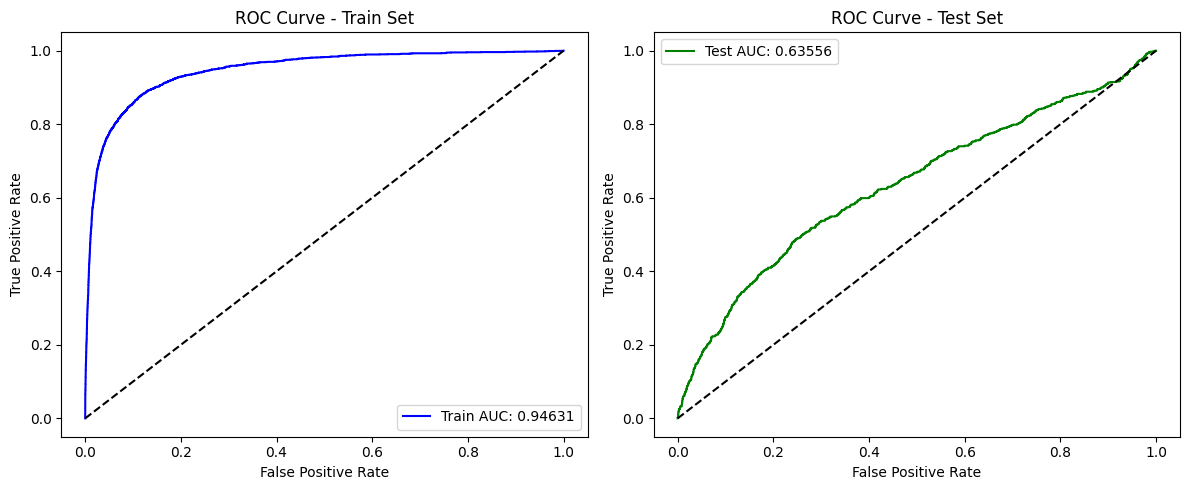

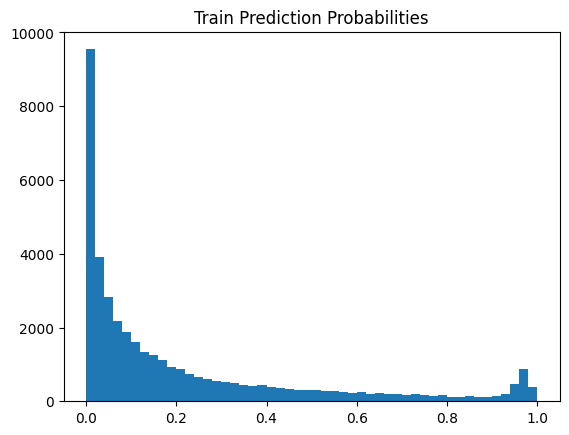

Saved Samsung sequence data with 33 rows to /content/drive/MyDrive/Colab Notebooks/hana_stock/result/samsung_sequence_training_data.csv


In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv1D, Flatten, Concatenate, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# ====================================
# 1) 파일 로드
# ====================================
stock_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet')
fin_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/fin_result.parquet')

# ====================================
# 2) 날짜 전처리
# ====================================
stock_df['BSOP_DATE'] = pd.to_datetime(stock_df['BSOP_DATE'], errors='coerce')
fin_df['BSOP_DATE'] = pd.to_datetime(fin_df['BSOP_DATE'], errors='coerce')

# 코로나 기간(2020년) 제외 + 2024-07-01 이전 데이터만 남김
stock_df = stock_df[(stock_df['BSOP_DATE'].dt.year != 2020) & (stock_df['BSOP_DATE'] < '2024-07-01')]
fin_df = fin_df[(fin_df['BSOP_DATE'].dt.year != 2020) & (fin_df['BSOP_DATE'] < '2024-07-01')]

# ====================================
# 3) ROE 결측치 제거
# ====================================
roe_missing_stocks = fin_df[fin_df['ROE'].isna()]['SHRN_ISCD'].unique()
stock_df = stock_df[~stock_df['SHRN_ISCD'].isin(roe_missing_stocks)]
fin_df = fin_df[~fin_df['SHRN_ISCD'].isin(roe_missing_stocks)]

# 타겟 데이터 준비 (windowdrop이 결측치가 아닌 행만 남김)
fin_df = fin_df.dropna(subset=['windowdrop'])

# ====================================
# 4) 주요 설정값
# ====================================
sequence_length = 60
stock_features = [
    'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR', 'FN_ACML_TR_PBMN',
    'MARKET_CAP', 'VKOSPI', 'KS200'
]
fin_features = [
    'ROE', 'DR', 'ROE_INC', 'PS', 'SHORT_DEBT', 'DEBT_COST_RATIO',
    'EQUITY', 'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY',
    'NET_INCOME', 'ICR', 'CF'
]

# ====================================
# 5) 결측치 처리
# ====================================
# (원본코드는 0으로 채우지만, 여기서는 median으로 대체 가능. 아래서는 원본처럼 0으로도 바꿀 수 있음)
fin_df[fin_features] = fin_df[fin_features].astype(float)
# 만약 원본 유지하려면 다음 주석 해제:
#fin_df[fin_features] = fin_df[fin_features].fillna(0)
# 개선된 버전(중간값) 사용하려면 다음 코드 사용:
fin_df[fin_features] = fin_df[fin_features].fillna(fin_df[fin_features].median())

# ====================================
# 6) 시퀀스 데이터 생성
# ====================================
stock_series_data = []
fin_series_data = []
matched_targets = []
dates = []

stock_groups = stock_df.groupby('SHRN_ISCD')

for stock_code, fin_group in fin_df.groupby('SHRN_ISCD'):
    if stock_code not in stock_groups.groups:
        continue  # 주식 데이터에 없는 종목은 스킵

    stock_history_group = stock_groups.get_group(stock_code)

    for row in fin_group.itertuples():
        date = row.BSOP_DATE
        stock_history = (
            stock_history_group[stock_history_group['BSOP_DATE'] < date]
            .sort_values('BSOP_DATE', ascending=False)
            .head(sequence_length)
        )

        if len(stock_history) == sequence_length:
            stock_series_data.append(stock_history[stock_features].values)
            fin_series_data.append([getattr(row, feature) for feature in fin_features])
            matched_targets.append(row.windowdrop)
            dates.append(date)

# ====================================
# 7) NumPy 배열 변환 및 Train/Test 분할
# ====================================
stock_series_data = np.array(stock_series_data)
fin_series_data = np.array(fin_series_data)
matched_targets = np.array(matched_targets)
dates = np.array(dates)

train_mask = dates < pd.Timestamp('2022-01-01')
test_mask = dates >= pd.Timestamp('2022-01-01')

X_stock_train = stock_series_data[train_mask]
X_stock_test = stock_series_data[test_mask]
X_fin_train = fin_series_data[train_mask]
X_fin_test = fin_series_data[test_mask]
y_train = matched_targets[train_mask]
y_test = matched_targets[test_mask]

# ====================================
# 8) 데이터 정규화(StandardScaler)
# ====================================
stock_scaler = StandardScaler()
X_stock_train = stock_scaler.fit_transform(
    X_stock_train.reshape(-1, len(stock_features))
).reshape(X_stock_train.shape)
X_stock_test = stock_scaler.transform(
    X_stock_test.reshape(-1, len(stock_features))
).reshape(X_stock_test.shape)

fin_scaler = StandardScaler()
X_fin_train = fin_scaler.fit_transform(X_fin_train)
X_fin_test = fin_scaler.transform(X_fin_test)

# ====================================
# 9) 모델 구성 (CNN + Dense)
# ====================================
stock_input = Input(shape=(sequence_length, len(stock_features)))
x = Conv1D(32, kernel_size=3, activation='relu')(stock_input)
x = Conv1D(64, kernel_size=3, activation='relu')(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
h_cnn = Dense(64, activation='relu')(x)

fin_input = Input(shape=(len(fin_features),))
y = Dense(128, activation='relu')(fin_input)
y = Dropout(0.3)(y)
y = Dense(64, activation='relu')(y)
y = Dropout(0.3)(y)
h_fin = Dense(32, activation='relu')(y)

# 특성 결합
combined = Concatenate()([h_cnn, h_fin])
z = Dense(32, activation='relu')(combined)
# 필요시 Dropout 추가 가능
z = Dense(1, activation='sigmoid')(z)

model = Model(inputs=[stock_input, fin_input], outputs=z)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ====================================
# 10) 클래스 불균형 처리 (클래스 가중치)
# ====================================
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

# ====================================
# 11) 모델 학습
# ====================================
model.fit(
    [X_stock_train, X_fin_train],
    y_train,
    epochs=20,           # 에폭 수를 20으로 증가
    batch_size=64,       # 배치 크기를 64로 변경
    validation_split=0.2,
    class_weight=class_weights
)

# ====================================
# 12) 모델 평가 및 예측
# ====================================
train_pred_proba = model.predict([X_stock_train, X_fin_train])
test_pred_proba = model.predict([X_stock_test, X_fin_test])

roc_auc_train = roc_auc_score(y_train, train_pred_proba)
roc_auc_test = roc_auc_score(y_test, test_pred_proba)
print(f'Train AUC: {roc_auc_train:.5f}')
print(f'Test AUC: {roc_auc_test:.5f}')

# ====================================
# 13) 시각화 (ROC Curve, 예측 확률 히스토그램)
# ====================================
fpr_train, tpr_train, _ = roc_curve(y_train, train_pred_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, test_pred_proba)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_train, tpr_train, label=f'Train AUC: {roc_auc_train:.5f}', color='blue')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Train Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fpr_test, tpr_test, label=f'Test AUC: {roc_auc_test:.5f}', color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Test Set')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()

plt.tight_layout()
plt.show()

# 예측 확률 히스토그램 (Train)
plt.hist(train_pred_proba, bins=50)
plt.title("Train Prediction Probabilities")
plt.show()

# ====================================
# 14) 삼성전자 데이터 별도로 추출 후 CSV 저장
# ====================================
samsung_code = 'A005930'

samsung_series_data = []
samsung_fin_series_data = []
samsung_matched_targets = []
samsung_dates = []

samsung_stock_data = stock_df[stock_df['SHRN_ISCD'] == samsung_code]
samsung_fin_data = fin_df[fin_df['SHRN_ISCD'] == samsung_code]

samsung_stock_group = samsung_stock_data.sort_values('BSOP_DATE')

for row in samsung_fin_data.itertuples():
    date = row.BSOP_DATE
    stock_history = (
        samsung_stock_group[samsung_stock_group['BSOP_DATE'] < date]
        .sort_values('BSOP_DATE', ascending=False)
        .head(sequence_length)
    )

    if len(stock_history) == sequence_length:
        samsung_series_data.append(stock_history[stock_features].values)
        samsung_fin_series_data.append([getattr(row, feature) for feature in fin_features])
        samsung_matched_targets.append(row.windowdrop)
        samsung_dates.append(date)

samsung_series_data = np.array(samsung_series_data)
samsung_fin_series_data = np.array(samsung_fin_series_data)
samsung_matched_targets = np.array(samsung_matched_targets)
samsung_dates = np.array(samsung_dates)

# CSV로 저장하기 위해 ndarray를 그대로 DataFrame에 넣으면 에러가 날 수 있으므로, .tolist() 권장
samsung_sequence_df = pd.DataFrame({
    'date': samsung_dates,
    'target': samsung_matched_targets,
    'stock_sequence': [arr.tolist() for arr in samsung_series_data],
    'fin_features': [arr.tolist() for arr in samsung_fin_series_data]
})

save_path = '/content/drive/MyDrive/Colab Notebooks/hana_stock/result/samsung_sequence_training_data.csv'
samsung_sequence_df.to_csv(save_path, index=False)
print(f'Saved Samsung sequence data with {len(samsung_sequence_df)} rows to {save_path}')


### catboost with cnn embedding

In [ ]:
'''
기획
: 주가데이터와 재무데이터의 분리, 재무데이터는 마지막에 dense layer에 합산하는 방식으로 1d cnn 사용

1. 데이터
 : 1d cnn을 사용하고 각각의 채널이 이게 되게 한다
   'PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW', 'FN_ACML_TR_PBMN', 'MARKET_CAP', 'VKOSPI', 'ks200',
2. input/output 구조
 : 첫번째 파일(주가데이터, 일별) : stock_all_vkospi
   두번째 파일(재무데이터, 분기별. 타겟 windowdrop 포함) : fin_result
3. 구조
   주가데이터는 일별로 하고, 재무는 분기별로 한다면 상이한 시계열끼리 어떻게 연결할 것인가
   Branch A (1D CNN): 일별 주가 시계열 (N일 × K채널)을 입력받아 → 시계열 합성곱 → 특성벡터 h_cnn 획득
   Branch B (Dense MLP): 분기별 재무데이터(하나의 벡터로 바로 처리) → h_fin 벡터
   합치기(Concatenate):
   [h_cnn,h_fin]→Dense→Output
'''


In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv1D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# CatBoost
!pip install catboost imblearn
from catboost import CatBoostClassifier
from imblearn.over_sampling import RandomOverSampler

############################################################
# 1) 파일 로드
############################################################
stock_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet')
fin_df   = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/fin_result.parquet')

############################################################
# 2) 날짜 전처리
############################################################
stock_df['BSOP_DATE'] = pd.to_datetime(stock_df['BSOP_DATE'], errors='coerce')
fin_df['BSOP_DATE']   = pd.to_datetime(fin_df['BSOP_DATE'],   errors='coerce')

# 코로나 기간 제외 + 2024-07-01 이전 데이터
stock_df = stock_df[(stock_df['BSOP_DATE'].dt.year != 2020) & (stock_df['BSOP_DATE'] < '2024-07-01')]
fin_df   = fin_df[(fin_df['BSOP_DATE'].dt.year != 2020) & (fin_df['BSOP_DATE']   < '2024-07-01')]

############################################################
# 3) ROE 결측치 제거
############################################################
roe_missing_stocks = fin_df[fin_df['ROE'].isna()]['SHRN_ISCD'].unique()
stock_df = stock_df[~stock_df['SHRN_ISCD'].isin(roe_missing_stocks)]
fin_df   = fin_df[~fin_df['SHRN_ISCD'].isin(roe_missing_stocks)]

# 타겟이 결측치인 행 제거
fin_df = fin_df.dropna(subset=['windowdrop'])

############################################################
# 4) 주요 설정값
############################################################
sequence_length = 60

stock_features = [
    'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR',
    'FN_ACML_TR_PBMN', 'MARKET_CAP', 'VKOSPI', 'KS200'
]
fin_features = [
    'ROE', 'DR', 'ROE_INC', 'PS', 'SHORT_DEBT', 'DEBT_COST_RATIO',
    'EQUITY', 'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY',
    'NET_INCOME', 'ICR', 'CF'
]

############################################################
# 5) 시퀀스 데이터 (CNN용) + 동일 날짜 주가 데이터 + 재무 + 타겟
############################################################
stock_series_data  = []  # (N, 60, len(stock_features)) - CNN 입력
stock_current_data = []  # (N, len(stock_features)) - 동일 날짜 주가
fin_series_data    = []  # (N, len(fin_features))
matched_targets    = []
dates              = []

stock_groups = stock_df.groupby('SHRN_ISCD')

for stock_code, fin_group in fin_df.groupby('SHRN_ISCD'):
    if stock_code not in stock_groups.groups:
        continue
    stock_history_group = stock_groups.get_group(stock_code)

    for row in fin_group.itertuples():
        date = row.BSOP_DATE

        # 5-1) 과거 60일분 주가
        stock_history = (
            stock_history_group[stock_history_group['BSOP_DATE'] < date]
            .sort_values('BSOP_DATE', ascending=False)
            .head(sequence_length)
        )

        if len(stock_history) != sequence_length:
            continue  # 시계열 길이가 부족하면 스킵

        # 5-2) '동일 일자'에 해당하는 주가 (1행)
        today_data_row = stock_history_group[stock_history_group['BSOP_DATE'] == date]
        if len(today_data_row) == 0:
            # 만약 동일 일자의 주가데이터가 없으면 스킵(또는 np.nan 처리)
            continue

        # 오늘 날짜 주가 (stock_features)
        today_data = today_data_row[stock_features].iloc[0].values

        # 5-3) 저장
        stock_series_data.append(stock_history[stock_features].values)  # 60일 시계열
        stock_current_data.append(today_data)                           # 동일 일자 1행
        fin_series_data.append([getattr(row, f) for f in fin_features])
        matched_targets.append(row.windowdrop)
        dates.append(date)

stock_series_data  = np.array(stock_series_data)   # shape: (N, 60, len(stock_features))
stock_current_data = np.array(stock_current_data)  # shape: (N, len(stock_features))
fin_series_data    = np.array(fin_series_data)     # shape: (N, len(fin_features))
matched_targets    = np.array(matched_targets)
dates              = np.array(dates)

print("stock_series_data.shape :", stock_series_data.shape)
print("stock_current_data.shape:", stock_current_data.shape)
print("fin_series_data.shape   :", fin_series_data.shape)

############################################################
# 6) Train/Test 분할
############################################################
train_mask = dates < pd.Timestamp('2023-01-01')
test_mask  = dates >= pd.Timestamp('2023-01-01')

X_stock_train_seq  = stock_series_data[train_mask]   # CNN 60일 시계열
X_stock_test_seq   = stock_series_data[test_mask]

X_stock_train_curr = stock_current_data[train_mask]  # '동일 일자' 주가
X_stock_test_curr  = stock_current_data[test_mask]

X_fin_train = fin_series_data[train_mask]
X_fin_test  = fin_series_data[test_mask]

y_train = matched_targets[train_mask]
y_test  = matched_targets[test_mask]

print("Train size:", len(y_train))
print("Test size :", len(y_test))

############################################################
# 7) 데이터 정규화
############################################################
# (1) 먼저 2차원 (N*60, len(stock_features)) 형태로 펼침
temp_train = X_stock_train_seq.reshape(-1, len(stock_features))
temp_test  = X_stock_test_seq.reshape(-1, len(stock_features))

# (2) 로그 변환 - np.log1p 사용 (log(1 + x))
#     - 단, 모든 값이 0보다 크거나 같다고 가정(음수 존재 시 별도 처리 필요)
temp_train_log = np.log1p(temp_train)
temp_test_log  = np.log1p(temp_test)

# (3) StandardScaler 적용
stock_scaler_seq = StandardScaler()

temp_train_scaled = stock_scaler_seq.fit_transform(temp_train_log)
temp_test_scaled  = stock_scaler_seq.transform(temp_test_log)

# (4) 다시 3차원 (N, 60, len(stock_features))로 복구
X_stock_train_seq = temp_train_scaled.reshape(X_stock_train_seq.shape)
X_stock_test_seq  = temp_test_scaled.reshape(X_stock_test_seq.shape)

# 동일 일자 주가 피처도 별도 스케일러
# stock_scaler_curr = StandardScaler()
# X_stock_train_curr = stock_scaler_curr.fit_transform(X_stock_train_curr)
# X_stock_test_curr  = stock_scaler_curr.transform(X_stock_test_curr)

# fin_scaler = StandardScaler()
# X_fin_train = fin_scaler.fit_transform(X_fin_train)
# X_fin_test  = fin_scaler.transform(X_fin_test)

############################################################
# 8) 오버샘플링 (Train만)
############################################################
ros = RandomOverSampler(random_state=42)

train_indices = np.arange(len(y_train)).reshape(-1, 1)  # (N,1)
resampled_indices, y_train_resampled = ros.fit_resample(train_indices, y_train)
resampled_indices = resampled_indices.flatten()

# 오버샘플링된 X들
X_stock_train_seq_resampled  = X_stock_train_seq[resampled_indices]
X_stock_train_curr_resampled = X_stock_train_curr[resampled_indices]
X_fin_train_resampled        = X_fin_train[resampled_indices]

print("Before Oversampling:", X_stock_train_seq.shape, "Pos Ratio:", np.mean(y_train))
print("After  Oversampling:", X_stock_train_seq_resampled.shape, "Pos Ratio:", np.mean(y_train_resampled))

############################################################
# 9) CNN 모델 (출력: 이진 분류) -- (시계열 전용)
############################################################
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam

sequence_input = Input(shape=(sequence_length, len(stock_features)), name='sequence_input')

# Conv1D 필터 수와 커널 크기 조정 (예: 필터 64, 커널 5)
x = Conv1D(filters=64, kernel_size=5, activation='relu')(sequence_input)
# Dropout 비율 조정 (0.3 -> 0.4)
x = Dropout(0.4)(x)

# 2번째 Conv1D 필터 수와 커널 크기 (예: 필터 32, 커널 3)
x = Conv1D(filters=32, kernel_size=3, activation='relu')(x)
x = Dropout(0.4)(x)

# 특징 펼치기
x = Flatten()(x)

# Dense 유닛 수 증가 (예: 4 -> 8)
x = Dense(16, activation='relu')(x)
# 추가 Dropout (예: 0.4 -> 0.5로 조금 더 높임)
x = Dropout(0.5)(x)

# 중간 임베딩 레이어 (차원=1은 그대로 유지)
embedding_layer = Dense(4, activation='relu', name='embedding_layer')(x)

# 최종 출력 레이어 (이진 분류이므로 시그모이드)
output_layer = Dense(1, activation='sigmoid', name='output')(embedding_layer)

model_cnn = Model(inputs=sequence_input, outputs=output_layer)

# Optimizer 학습률 조정 (예: 0.001 -> 0.0005)
model_cnn.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

############################################################
# 10) CNN 학습 (오버샘플링 데이터)
############################################################
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model_cnn.fit(
    X_stock_train_seq_resampled, y_train_resampled,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

############################################################
# 11) 중간 임베딩 추출
############################################################
sub_model = Model(inputs=model_cnn.input,
                  outputs=model_cnn.get_layer('embedding_layer').output)

# 오버샘플링된 임베딩 (Train)
train_embedding_resampled = sub_model.predict(X_stock_train_seq_resampled)

# 원본 Test 임베딩
test_embedding = sub_model.predict(X_stock_test_seq)

print("train_embedding_resampled.shape:", train_embedding_resampled.shape)
print("test_embedding.shape            :", test_embedding.shape)

############################################################
# 12) (임베딩 + 재무데이터 + 동일 일자 주가) 결합 -> CatBoost
############################################################
# -- Train
train_features_resampled = np.concatenate([
    train_embedding_resampled,
    X_fin_train_resampled,
    X_stock_train_curr_resampled  # 오늘 날짜의 주가 피처
], axis=1)

# -- Test
test_features = np.concatenate([
    test_embedding,
    X_fin_test,
    X_stock_test_curr
], axis=1)

print("train_features_resampled.shape:", train_features_resampled.shape)
print("test_features.shape           :", test_features.shape)

    # # CatBoost 모델 선언
    # cat = CatBoostClassifier(
    #     iterations=100000,
    #     depth=5,
    #     learning_rate=0.005,
    #     random_seed=42,
    #     verbose=100,
    #     loss_function='Logloss',
    #     class_weights=class_weights,
    #     early_stopping_rounds=100,
    #     l2_leaf_reg=10,
    #     random_strength=1,
    #     bootstrap_type='Bernoulli',
    #     subsample=0.7,
    #     eval_metric='AUC',      # 모델 선언부에 AUC를 모니터링하도록 설정
    #     use_best_model=True     # 평가 세트를 기준으로 Best Model 사용
    # )

# cat_model = CatBoostClassifier(
#     iterations=20000,
#     depth=5,
#     learning_rate=0.01,
#     random_state=42,
#     eval_metric='AUC',
#     l2_leaf_reg=10,
#     verbose=100,
#     bootstrap_type='Bernoulli',
#     subsample=0.7
#     # 불균형은 이미 오버샘플링으로 해결
# )

cat_model = CatBoostClassifier(
    iterations=20000,       # 1. 반복 횟수 줄이고 Early Stopping 활용
    depth=6,                # 2. 트리 깊이 증가 (5 -> 7)
    learning_rate=0.01,     # 3. 학습률 조정 (0.005 -> 0.01)
    l2_leaf_reg=5,          # 4. L2 정규화 감소 (10 -> 5)
    subsample=0.7,          # 5. 배깅 샘플 비율 적용 (1.0 -> 0.8)
    eval_metric='AUC',
    early_stopping_rounds=100,  # 조기 종료 설정
    use_best_model=True           # 최적 모델 저장
)

cat_model.fit(
    train_features_resampled, y_train_resampled,
    eval_set=(test_features, y_test),
    verbose=100
)

############################################################
# 13) 최종 평가
############################################################
pred_train_proba = cat_model.predict_proba(train_features_resampled)[:, 1]
pred_test_proba  = cat_model.predict_proba(test_features)[:, 1]

roc_auc_train = roc_auc_score(y_train_resampled, pred_train_proba)
roc_auc_test  = roc_auc_score(y_test, pred_test_proba)

print(f'[CatBoost] Train AUC: {roc_auc_train:.5f}')
print(f'[CatBoost] Test  AUC: {roc_auc_test:.5f}')

fpr_train, tpr_train, _ = roc_curve(y_train_resampled, pred_train_proba)
fpr_test,  tpr_test,  _ = roc_curve(y_test, pred_test_proba)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_train, tpr_train, label=f'Train AUC: {roc_auc_train:.5f}')
plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve - Train (CatBoost)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fpr_test, tpr_test, label=f'Test AUC: {roc_auc_test:.5f}')
plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve - Test (CatBoost)')
plt.legend()

plt.tight_layout()
plt.show()

# 예측 확률 히스토그램 (Train)
plt.hist(pred_train_proba, bins=50)
plt.title('Train Prediction Probabilities (CatBoost)')
plt.show()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.2 MB/s eta 0:00:00


KeyError: "['VKOSPI', 'KS200'] not in index"

### catboost with cnn embed2

In [ ]:
import pandas as pd
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Conv1D, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# CatBoost
!pip install catboost imblearn
from catboost import CatBoostClassifier
from imblearn.over_sampling import RandomOverSampler

############################################################
# 1) 파일 로드
############################################################
stock_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet')
fin_df   = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_fin_result_with_vkospi_all.parquet')

############################################################
# 2) 날짜 전처리
############################################################
stock_df['BSOP_DATE'] = pd.to_datetime(stock_df['BSOP_DATE'], errors='coerce')
fin_df['BSOP_DATE']   = pd.to_datetime(fin_df['BSOP_DATE'],   errors='coerce')

# 코로나 기간 제외 + 2024-07-01 이전 데이터
stock_df = stock_df[(stock_df['BSOP_DATE'].dt.year != 2020) & (stock_df['BSOP_DATE'] < '2024-07-01')]
fin_df   = fin_df[(fin_df['BSOP_DATE'].dt.year != 2020) & (fin_df['BSOP_DATE']   < '2024-07-01')]

############################################################
# 3) ROE 결측치 제거
############################################################
roe_missing_stocks = fin_df[fin_df['ROE'].isna()]['SHRN_ISCD'].unique()
stock_df = stock_df[~stock_df['SHRN_ISCD'].isin(roe_missing_stocks)]
fin_df   = fin_df[~fin_df['SHRN_ISCD'].isin(roe_missing_stocks)]

# 타겟이 결측치인 행 제거
fin_df = fin_df.dropna(subset=['windowdrop'])

############################################################
# 4) 주요 설정값
############################################################
sequence_length = 60

stock_features = [
    'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR',
    'FN_ACML_TR_PBMN', 'MARKET_CAP', 'VKOSPI', 'KS200'
]
fin_features = [
    'ROE', 'DR', 'ROE_INC', 'PS', 'SHORT_DEBT', 'DEBT_COST_RATIO',
    'EQUITY', 'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY',
    'NET_INCOME', 'ICR', 'CF'
]

############################################################
# 5) 시퀀스 데이터 (CNN용) + 동일 날짜 주가 데이터 + 재무 + 타겟
############################################################
stock_series_data  = []  # (N, 60, len(stock_features)) - CNN 입력
stock_current_data = []  # (N, len(stock_features)) - 동일 날짜 주가
fin_series_data    = []  # (N, len(fin_features))
matched_targets    = []
dates              = []

stock_groups = stock_df.groupby('SHRN_ISCD')

for stock_code, fin_group in fin_df.groupby('SHRN_ISCD'):
    if stock_code not in stock_groups.groups:
        continue
    stock_history_group = stock_groups.get_group(stock_code)

    for row in fin_group.itertuples():
        date = row.BSOP_DATE

        # 5-1) 과거 60일분 주가
        stock_history = (
            stock_history_group[stock_history_group['BSOP_DATE'] < date]
            .sort_values('BSOP_DATE', ascending=False)
            .head(sequence_length)
        )

        if len(stock_history) != sequence_length:
            continue  # 시계열 길이가 부족하면 스킵

        # 5-2) '동일 일자'에 해당하는 주가 (1행)
        today_data_row = stock_history_group[stock_history_group['BSOP_DATE'] == date]
        if len(today_data_row) == 0:
            # 만약 동일 일자의 주가데이터가 없으면 스킵(또는 np.nan 처리)
            continue

        # 오늘 날짜 주가 (stock_features)
        today_data = today_data_row[stock_features].iloc[0].values

        # 5-3) 저장
        stock_series_data.append(stock_history[stock_features].values)  # 60일 시계열
        stock_current_data.append(today_data)                           # 동일 일자 1행
        fin_series_data.append([getattr(row, f) for f in fin_features])
        matched_targets.append(row.windowdrop)
        dates.append(date)

stock_series_data  = np.array(stock_series_data)   # shape: (N, 60, len(stock_features))
stock_current_data = np.array(stock_current_data)  # shape: (N, len(stock_features))
fin_series_data    = np.array(fin_series_data)     # shape: (N, len(fin_features))
matched_targets    = np.array(matched_targets)
dates              = np.array(dates)

print("stock_series_data.shape :", stock_series_data.shape)
print("stock_current_data.shape:", stock_current_data.shape)
print("fin_series_data.shape   :", fin_series_data.shape)

############################################################
# 6) Train/Test 분할
############################################################
train_mask = dates < pd.Timestamp('2023-01-01')
test_mask  = dates >= pd.Timestamp('2023-01-01')

X_stock_train_seq  = stock_series_data[train_mask]   # CNN 60일 시계열
X_stock_test_seq   = stock_series_data[test_mask]

X_stock_train_curr = stock_current_data[train_mask]  # '동일 일자' 주가
X_stock_test_curr  = stock_current_data[test_mask]

X_fin_train = fin_series_data[train_mask]
X_fin_test  = fin_series_data[test_mask]

y_train = matched_targets[train_mask]
y_test  = matched_targets[test_mask]

print("Train size:", len(y_train))
print("Test size :", len(y_test))

############################################################
# 7) 데이터 정규화
############################################################
# (1) 먼저 2차원 (N*60, len(stock_features)) 형태로 펼침
temp_train = X_stock_train_seq.reshape(-1, len(stock_features))
temp_test  = X_stock_test_seq.reshape(-1, len(stock_features))

# (2) 로그 변환 - np.log1p 사용 (log(1 + x))
#     - 단, 모든 값이 0보다 크거나 같다고 가정(음수 존재 시 별도 처리 필요)
temp_train_log = np.log1p(temp_train)
temp_test_log  = np.log1p(temp_test)

# (3) StandardScaler 적용
stock_scaler_seq = StandardScaler()

temp_train_scaled = stock_scaler_seq.fit_transform(temp_train_log)
temp_test_scaled  = stock_scaler_seq.transform(temp_test_log)

# (4) 다시 3차원 (N, 60, len(stock_features))로 복구
X_stock_train_seq = temp_train_scaled.reshape(X_stock_train_seq.shape)
X_stock_test_seq  = temp_test_scaled.reshape(X_stock_test_seq.shape)

# 동일 일자 주가 피처도 별도 스케일러
# stock_scaler_curr = StandardScaler()
# X_stock_train_curr = stock_scaler_curr.fit_transform(X_stock_train_curr)
# X_stock_test_curr  = stock_scaler_curr.transform(X_stock_test_curr)

# fin_scaler = StandardScaler()
# X_fin_train = fin_scaler.fit_transform(X_fin_train)
# X_fin_test  = fin_scaler.transform(X_fin_test)

############################################################
# 8) 오버샘플링 (Train만)
############################################################
ros = RandomOverSampler(random_state=42)

train_indices = np.arange(len(y_train)).reshape(-1, 1)  # (N,1)
resampled_indices, y_train_resampled = ros.fit_resample(train_indices, y_train)
resampled_indices = resampled_indices.flatten()

# 오버샘플링된 X들
X_stock_train_seq_resampled  = X_stock_train_seq[resampled_indices]
X_stock_train_curr_resampled = X_stock_train_curr[resampled_indices]
X_fin_train_resampled        = X_fin_train[resampled_indices]

print("Before Oversampling:", X_stock_train_seq.shape, "Pos Ratio:", np.mean(y_train))
print("After  Oversampling:", X_stock_train_seq_resampled.shape, "Pos Ratio:", np.mean(y_train_resampled))

############################################################
# 9) CNN 모델 (출력: 이진 분류) -- (시계열 전용)
############################################################
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam

sequence_input = Input(shape=(sequence_length, len(stock_features)), name='sequence_input')

# Conv1D 필터 수와 커널 크기 조정 (예: 필터 64, 커널 5)
x = Conv1D(filters=64, kernel_size=5, activation='relu')(sequence_input)
# Dropout 비율 조정 (0.3 -> 0.4)
x = Dropout(0.4)(x)

# 2번째 Conv1D 필터 수와 커널 크기 (예: 필터 32, 커널 3)
x = Conv1D(filters=32, kernel_size=3, activation='relu')(x)
x = Dropout(0.4)(x)

# 특징 펼치기
x = Flatten()(x)

# Dense 유닛 수 증가 (예: 4 -> 8)
x = Dense(16, activation='relu')(x)
# 추가 Dropout (예: 0.4 -> 0.5로 조금 더 높임)
x = Dropout(0.5)(x)

# 중간 임베딩 레이어 (차원=1은 그대로 유지)
embedding_layer = Dense(4, activation='relu', name='embedding_layer')(x)

# 최종 출력 레이어 (이진 분류이므로 시그모이드)
output_layer = Dense(1, activation='sigmoid', name='output')(embedding_layer)

model_cnn = Model(inputs=sequence_input, outputs=output_layer)

# Optimizer 학습률 조정 (예: 0.001 -> 0.0005)
model_cnn.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_cnn.summary()

############################################################
# 10) CNN 학습 (오버샘플링 데이터)
############################################################
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model_cnn.fit(
    X_stock_train_seq_resampled, y_train_resampled,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

############################################################
# 11) 중간 임베딩 추출
############################################################
sub_model = Model(inputs=model_cnn.input,
                  outputs=model_cnn.get_layer('embedding_layer').output)

# 오버샘플링된 임베딩 (Train)
train_embedding_resampled = sub_model.predict(X_stock_train_seq_resampled)

# 원본 Test 임베딩
test_embedding = sub_model.predict(X_stock_test_seq)

print("train_embedding_resampled.shape:", train_embedding_resampled.shape)
print("test_embedding.shape            :", test_embedding.shape)

############################################################
# 12) (임베딩 + 재무데이터 + 동일 일자 주가) 결합 -> CatBoost
############################################################
# -- Train
train_features_resampled = np.concatenate([
    train_embedding_resampled,
    X_fin_train_resampled,
    X_stock_train_curr_resampled  # 오늘 날짜의 주가 피처
], axis=1)

# -- Test
test_features = np.concatenate([
    test_embedding,
    X_fin_test,
    X_stock_test_curr
], axis=1)

print("train_features_resampled.shape:", train_features_resampled.shape)
print("test_features.shape           :", test_features.shape)

    # # CatBoost 모델 선언
    # cat = CatBoostClassifier(
    #     iterations=100000,
    #     depth=5,
    #     learning_rate=0.005,
    #     random_seed=42,
    #     verbose=100,
    #     loss_function='Logloss',
    #     class_weights=class_weights,
    #     early_stopping_rounds=100,
    #     l2_leaf_reg=10,
    #     random_strength=1,
    #     bootstrap_type='Bernoulli',
    #     subsample=0.7,
    #     eval_metric='AUC',      # 모델 선언부에 AUC를 모니터링하도록 설정
    #     use_best_model=True     # 평가 세트를 기준으로 Best Model 사용
    # )

# cat_model = CatBoostClassifier(
#     iterations=20000,
#     depth=5,
#     learning_rate=0.01,
#     random_state=42,
#     eval_metric='AUC',
#     l2_leaf_reg=10,
#     verbose=100,
#     bootstrap_type='Bernoulli',
#     subsample=0.7
#     # 불균형은 이미 오버샘플링으로 해결
# )

cat_model = CatBoostClassifier(
    iterations=20000,       # 1. 반복 횟수 줄이고 Early Stopping 활용
    depth=6,                # 2. 트리 깊이 증가 (5 -> 7)
    learning_rate=0.01,     # 3. 학습률 조정 (0.005 -> 0.01)
    l2_leaf_reg=5,          # 4. L2 정규화 감소 (10 -> 5)
    subsample=0.7,          # 5. 배깅 샘플 비율 적용 (1.0 -> 0.8)
    eval_metric='AUC',
    early_stopping_rounds=100,  # 조기 종료 설정
    use_best_model=True           # 최적 모델 저장
)

cat_model.fit(
    train_features_resampled, y_train_resampled,
    eval_set=(test_features, y_test),
    verbose=100
)

############################################################
# 13) 최종 평가
############################################################
pred_train_proba = cat_model.predict_proba(train_features_resampled)[:, 1]
pred_test_proba  = cat_model.predict_proba(test_features)[:, 1]

roc_auc_train = roc_auc_score(y_train_resampled, pred_train_proba)
roc_auc_test  = roc_auc_score(y_test, pred_test_proba)

print(f'[CatBoost] Train AUC: {roc_auc_train:.5f}')
print(f'[CatBoost] Test  AUC: {roc_auc_test:.5f}')

fpr_train, tpr_train, _ = roc_curve(y_train_resampled, pred_train_proba)
fpr_test,  tpr_test,  _ = roc_curve(y_test, pred_test_proba)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_train, tpr_train, label=f'Train AUC: {roc_auc_train:.5f}')
plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve - Train (CatBoost)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fpr_test, tpr_test, label=f'Test AUC: {roc_auc_test:.5f}')
plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve - Test (CatBoost)')
plt.legend()

plt.tight_layout()
plt.show()

# 예측 확률 히스토그램 (Train)
plt.hist(pred_train_proba, bins=50)
plt.title('Train Prediction Probabilities (CatBoost)')
plt.show()


### ensemble(cnn and catboost)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from imblearn.over_sampling import RandomOverSampler

# CatBoost
!pip install catboost
from catboost import CatBoostClassifier

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

###########################################################################
# 1) 파일 로드
###########################################################################
stock_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet')
fin_df   = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/fin_result.parquet')

###########################################################################
# 2) 날짜 전처리
###########################################################################
stock_df['BSOP_DATE'] = pd.to_datetime(stock_df['BSOP_DATE'], errors='coerce')
fin_df['BSOP_DATE']   = pd.to_datetime(fin_df['BSOP_DATE'], errors='coerce')

# 코로나 기간 제외 + 2024-07-01 이전 데이터
stock_df = stock_df[(stock_df['BSOP_DATE'].dt.year != 2020) & (stock_df['BSOP_DATE'] < '2024-07-01')]
fin_df   = fin_df[(fin_df['BSOP_DATE'].dt.year != 2020) & (fin_df['BSOP_DATE']   < '2024-07-01')]

###########################################################################
# 3) ROE 결측치 제거 및 타겟 결측 제거
###########################################################################
roe_missing_stocks = fin_df[fin_df['ROE'].isna()]['SHRN_ISCD'].unique()
stock_df = stock_df[~stock_df['SHRN_ISCD'].isin(roe_missing_stocks)]
fin_df   = fin_df[~fin_df['SHRN_ISCD'].isin(roe_missing_stocks)]
fin_df   = fin_df.dropna(subset=['windowdrop'])


###########################################################################
# 4) 주요 설정값
###########################################################################
sequence_length = 40

stock_features = [
    'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR',
    'FN_ACML_TR_PBMN', 'MARKET_CAP', 'VKOSPI', 'KS200'
]
fin_features = [
    'ROE', 'DR', 'ROE_INC', 'PS', 'SHORT_DEBT', 'DEBT_COST_RATIO',
    'EQUITY', 'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY',
    'NET_INCOME', 'ICR', 'CF'
]

###########################################################################
# 5) 시퀀스(60일) + 동일 일자 주가 + 재무 + 타겟
###########################################################################
stock_series_data  = []  # 60일 시계열 데이터 (numpy array)
stock_current_data = []  # 당일 주가 데이터 (나중에 DataFrame 전환)
fin_series_data    = []  # 재무 데이터 (나중에 DataFrame 전환)
matched_targets    = []  # 타겟 변수 (windowdrop, 그대로 사용)
dates              = []  # 날짜 리스트
keys               = []  # (BSOP_DATE, SHRN_ISCD) 튜플

stock_groups = stock_df.groupby('SHRN_ISCD')

for stock_code, fin_group in fin_df.groupby('SHRN_ISCD'):
    if stock_code not in stock_groups.groups:
        continue
    stock_history_group = stock_groups.get_group(stock_code)

    for row in fin_group.itertuples():
        date = row.BSOP_DATE

        # 과거 60일 주가
        stock_history = (stock_history_group[stock_history_group['BSOP_DATE'] < date]
                         .sort_values('BSOP_DATE', ascending=False)
                         .head(sequence_length))
        if len(stock_history) != sequence_length:
            continue

        # 동일 일자 주가
        today_data_row = stock_history_group[stock_history_group['BSOP_DATE'] == date]
        if len(today_data_row) == 0:
            continue
        today_data = today_data_row[stock_features].iloc[0].values

        # 저장
        stock_series_data.append(stock_history[stock_features].values)
        stock_current_data.append(today_data)
        fin_series_data.append([getattr(row, f) for f in fin_features])
        matched_targets.append(row.windowdrop)
        dates.append(date)
        keys.append((date, stock_code))

# DataFrame 변환: 당일 주가 데이터
df_stock_current = pd.DataFrame(stock_current_data, columns=stock_features)
df_stock_current['BSOP_DATE'] = dates
df_stock_current['SHRN_ISCD'] = [k[1] for k in keys]
df_stock_current.set_index(['BSOP_DATE', 'SHRN_ISCD'], inplace=True)

# DataFrame 변환: 재무 데이터
df_fin = pd.DataFrame(fin_series_data, columns=fin_features)
df_fin['BSOP_DATE'] = dates
df_fin['SHRN_ISCD'] = [k[1] for k in keys]
df_fin.set_index(['BSOP_DATE', 'SHRN_ISCD'], inplace=True)

# 병합: 날짜와 종목코드를 기준으로 inner join
df_cat = pd.merge(df_stock_current, df_fin, left_index=True, right_index=True, how='inner')

# 새로운 피처 생성 (PER, PSR, FTRUTH) – target은 그대로 windowdrop 사용
df_cat['PER'] = df_cat['NET_INCOME'] / df_cat['MARKET_CAP']
df_cat['PSR'] = df_cat['PS'] / df_cat['STCK_PRPR']
df_cat['FTRUTH'] = df_cat['PS'] / df_cat['NET_INCOME']

# 넘파이 변환 (시계열 데이터는 이미 넘파이 배열)
stock_series_data  = np.array(stock_series_data)
# cat_data는 df_cat의 전체 내용을 넘파이 배열로 변환 (주로 CatBoost 입력용)
cat_data = np.array(df_cat)
# matched_targets와 dates도 넘파이 배열로
matched_targets = np.array(matched_targets)
dates = np.array(dates)

print("stock_series_data.shape :", stock_series_data.shape)   # (N, 60, len(stock_features))
print("stock_current_data.shape:", df_stock_current.shape)  # (N, len(stock_features))
print("fin_series_data.shape   :", df_fin.shape)      # (N, len(fin_features))

###########################################################################
# 6) Train/Test 분할 (날짜 기준)
###########################################################################
train_mask = dates < pd.Timestamp('2023-01-01')
test_mask  = dates >= pd.Timestamp('2023-01-01')

X_stock_train_seq = stock_series_data[train_mask]
X_stock_test_seq  = stock_series_data[test_mask]

X_fin_train = cat_data[train_mask]
X_fin_test  = cat_data[test_mask]

y_train = matched_targets[train_mask]
y_test  = matched_targets[test_mask]

dates_train = dates[train_mask]
dates_test  = dates[test_mask]

print("Train size:", len(y_train))
print("Test size :", len(y_test))

###########################################################################
# 7) 데이터 전처리 (로그 변환 + StandardScaler) - CNN 입력용 (시계열 데이터)
###########################################################################
# 2차원으로 펼쳐서 로그변환, 스케일링 후 3차원 복구
temp_train = X_stock_train_seq.reshape(-1, len(stock_features))
temp_test  = X_stock_test_seq.reshape(-1, len(stock_features))

temp_train_log = np.log1p(temp_train)
temp_test_log  = np.log1p(temp_test)

stock_scaler_seq = StandardScaler()
temp_train_scaled = stock_scaler_seq.fit_transform(temp_train_log)
temp_test_scaled  = stock_scaler_seq.transform(temp_test_log)

X_stock_train_seq = temp_train_scaled.reshape(X_stock_train_seq.shape)
X_stock_test_seq  = temp_test_scaled.reshape(X_stock_test_seq.shape)

print("X_stock_train_seq.shape:", X_stock_train_seq.shape)
print("X_stock_test_seq.shape :", X_stock_test_seq.shape)

# 동일 일자 주가 데이터 (CatBoost 입력용): df_stock_current를 사용
curr_scaler = StandardScaler()
# train/test 마스크는 df_cat의 인덱스 기준(여기서는 reset_index 후, BSOP_DATE 기준)
df_stock_current_reset = df_stock_current.reset_index()
X_stock_train_curr = curr_scaler.fit_transform(df_stock_current_reset.loc[train_mask, stock_features])
X_stock_test_curr  = curr_scaler.transform(df_stock_current_reset.loc[test_mask, stock_features])

###########################################################################
# 8) Train 오버샘플링 (각 모델별)
###########################################################################
ros = RandomOverSampler(random_state=42)

# (1) CNN 오버샘플링: 시계열 데이터
train_idx_cnn = np.arange(len(y_train)).reshape(-1,1)
resampled_idx_cnn, y_train_res_cnn = ros.fit_resample(train_idx_cnn, y_train)
resampled_idx_cnn = resampled_idx_cnn.flatten()
X_stock_train_seq_res = X_stock_train_seq[resampled_idx_cnn]

print("[CNN] Before Oversampling:", X_stock_train_seq.shape, "Pos Ratio:", np.mean(y_train))
print("[CNN] After  Oversampling:", X_stock_train_seq_res.shape, "Pos Ratio:", np.mean(y_train_res_cnn))

# (2) CatBoost 오버샘플링: 동일 일자 주가 + 재무 데이터
X_cat_train = X_fin_train
X_cat_test  = X_fin_test

train_idx_cat = np.arange(len(y_train)).reshape(-1,1)
resampled_idx_cat, y_train_res_cat = ros.fit_resample(train_idx_cat, y_train)
resampled_idx_cat = resampled_idx_cat.flatten()
X_cat_train_res = X_cat_train[resampled_idx_cat]

print("[CatBoost] Before Oversampling:", X_cat_train.shape, "Pos Ratio:", np.mean(y_train))
print("[CatBoost] After  Oversampling:", X_cat_train_res.shape, "Pos Ratio:", np.mean(y_train_res_cat))

###########################################################################
# 9) CNN 모델 (이진 분류: 시계열 전용)
###########################################################################
from tensorflow.keras.layers import MaxPooling1D, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau

sequence_input = Input(shape=(sequence_length, len(stock_features)), name='sequence_input')
x = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same')(sequence_input)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.4)(x)

x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.4)(x)

x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Flatten()(x)
x = Dense(16, activation='relu')(x)
x = Dropout(0.3)(x)
output_layer = Dense(1, activation='sigmoid')(x)

model_cnn = Model(inputs=sequence_input, outputs=output_layer)
model_cnn.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
model_cnn.summary()

###########################################################################
# 10) CNN 학습 (오버샘플링 데이터)
###########################################################################
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_cnn = model_cnn.fit(
    X_stock_train_seq_res, y_train_res_cnn,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

###########################################################################
# 11) CNN 예측 확률 (원본 데이터 평가)
###########################################################################
cnn_pred_train_proba = model_cnn.predict(X_stock_train_seq).ravel()
cnn_pred_test_proba  = model_cnn.predict(X_stock_test_seq).ravel()

###########################################################################
# 12) CatBoost 학습 (오버샘플링 데이터)
###########################################################################
#{'depth': 6, 'l2_leaf_reg': 5, 'learning_rate': 0.01, 'subsample': 0.8}
cat = CatBoostClassifier(
    iterations=100000,
    depth=6,
    learning_rate=0.01,
    random_seed=42,
    verbose=100,
    loss_function='Logloss',
    early_stopping_rounds=100,
    l2_leaf_reg=5,
    random_strength=1,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    eval_metric='AUC',
    use_best_model=True
)
cat_model = cat
cat_model.fit(
    X_cat_train_res, y_train_res_cat,
    eval_set=(X_cat_test, y_test),
)

# from catboost import CatBoostClassifier
# from sklearn.model_selection import GridSearchCV

# # 튜닝할 하이퍼파라미터 그리드 설정
# param_grid = {
#     'depth': [4, 5, 6],
#     'learning_rate': [0.005, 0.01],
#     'l2_leaf_reg': [3, 5, 7],
#     'subsample': [0.6, 0.7, 0.8]
# }

# # CatBoostClassifier 기본 설정 (iterations는 early stopping으로 조정)
# cat_model = CatBoostClassifier(
#     iterations=10000,            # 충분히 큰 값 설정 (early stopping으로 조절)
#     random_seed=42,
#     loss_function='Logloss',
#     eval_metric='AUC',
#     verbose=0,
#     early_stopping_rounds=50,    # 조기 종료를 더 민감하게 설정
#     bootstrap_type='Bernoulli'
# )

# # GridSearchCV로 하이퍼파라미터 탐색 (3-fold cross validation)
# grid = GridSearchCV(estimator=cat_model,
#                     param_grid=param_grid,
#                     scoring='roc_auc',
#                     cv=3,
#                     n_jobs=-1)

# # 튜닝 실행 (오버샘플링 데이터 사용)
# grid.fit(X_cat_train_res, y_train_res_cat, eval_set=(X_cat_test, y_test))

# print("Best parameters:", grid.best_params_)
# print("Best CV AUC:", grid.best_score_)

###########################################################################
# 13) CatBoost 예측 확률 (원본 데이터 평가)
###########################################################################
cat_pred_train_proba = cat_model.predict_proba(X_cat_train)[:,1]
cat_pred_test_proba  = cat_model.predict_proba(X_cat_test)[:,1]

###########################################################################
# 14) 두 모델 예측 결합 (가중치 alpha 탐색)
###########################################################################
from sklearn.metrics import roc_auc_score
search_alphas = np.linspace(0, 1, 101)
best_alpha = 0
best_auc   = 0
for alpha in search_alphas:
    blend_pred_train = alpha * cnn_pred_train_proba + (1 - alpha) * cat_pred_train_proba
    auc_val = roc_auc_score(y_train, blend_pred_train)
    if auc_val > best_auc:
        best_auc = auc_val
        best_alpha = alpha
print(f"\n[Blending] Best alpha on TRAIN = {best_alpha:.2f} / AUC = {best_auc:.5f}")

###########################################################################
# 15) 최종 Test 평가
###########################################################################
blend_pred_test = best_alpha * cnn_pred_test_proba + (1 - best_alpha) * cat_pred_test_proba
final_auc_test  = roc_auc_score(y_test, blend_pred_test)
print(f"[Blending] Test AUC (alpha={best_alpha:.2f}): {final_auc_test:.5f}")

###########################################################################
# 16) ROC Curve 시각화 (Test)
###########################################################################
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, cnn_pred_test_proba)
fpr_cat, tpr_cat, _ = roc_curve(y_test, cat_pred_test_proba)
fpr_bld, tpr_bld, _ = roc_curve(y_test, blend_pred_test)
auc_cnn = roc_auc_score(y_test, cnn_pred_test_proba)
auc_cat = roc_auc_score(y_test, cat_pred_test_proba)
auc_bld = roc_auc_score(y_test, blend_pred_test)
plt.plot(fpr_cnn, tpr_cnn, label=f'CNN AUC: {auc_cnn:.5f}')
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost AUC: {auc_cat:.5f}')
plt.plot(fpr_bld, tpr_bld, label=f'Blend AUC: {auc_bld:.5f} (alpha={best_alpha:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title('ROC Curve - Test')
plt.legend()
plt.show()


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

### catboost/cnn/transformer

stock_series_data.shape : (59984, 40, 8)
stock_current_data.shape: (59984, 8)
fin_series_data.shape   : (59984, 13)
Train size: 48975
Test size : 11009
X_stock_train_seq.shape: (48975, 40, 8)
X_stock_test_seq.shape : (11009, 40, 8)
[시계열 데이터] Before Oversampling: (48975, 40, 8) Pos Ratio: 0.05129147524247065
[시계열 데이터] After  Oversampling: (92926, 40, 8) Pos Ratio: 0.5
[CatBoost] Before Oversampling: (48975, 24) Pos Ratio: 0.05129147524247065
[CatBoost] After  Oversampling: (92926, 24) Pos Ratio: 0.5


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)          │ (None, 40, 8)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_20 (Conv1D)                   │ (None, 40, 128)             │           5,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 40, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_8 (MaxPooling1D)       │ (None, 20, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ (None, 20, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_21 (Conv1D)                   │ (None, 20, 64)              │          24,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 20, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_9 (MaxPooling1D)       │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_29 (Dropout)                 │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_22 (Conv1D)                   │ (None, 10, 32)              │           6,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 10, 32)              │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (Dropout)                 │ (None, 10, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_8 (Flatten)                  │ (None, 320)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 16)                  │           5,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_31 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 42,113 (164.50 KB)

 Trainable params: 41,665 (162.75 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ transformer_input         │ (None, 40, 8)          │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_18 (Dense)          │ (None, 40, 64)         │            576 │ transformer_input[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 40, 64)         │            128 │ dense_18[0][0]         │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ (None, 40, 64)         │         33,216 │ layer_normalization[0… │
│ (MultiHeadAttention)      │                        │                │ layer_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_33 (Dropout)      │ (None, 40, 64)         │              0 │ multi_head_attention[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 40, 64)         │              0 │ layer_normalization[0… │
│                           │                        │                │ dropout_33[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1     │ (None, 40, 64)         │            128 │ add[0][0]              │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_19 (Dense)          │ (None, 40, 64)         │          4,160 │ layer_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_34 (Dropout)      │ (None, 40, 64)         │              0 │ dense_19[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_20 (Dense)          │ (None, 40, 64)         │          4,160 │ dropout_34[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 40, 64)         │              0 │ layer_normalization_1… │
│                           │                        │                │ dense_20[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling1d  │ (None, 64)             │              0 │ add_1[0][0]            │
│ (GlobalAveragePooling1D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_35 (Dropout)      │ (None, 64)             │              0 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_21 (Dense)          │ (None, 16)             │          1,040 │ dropout_35[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_36 (Dropout)      │ (None, 16)             │              0 │ dense_21[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_22 (Dense)          │ (None, 1)              │             17 │ dropout_36[0][0]       │
└──────────────────────

 Total params: 43,425 (169.63 KB)

 Trainable params: 43,425 (169.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.7539 - loss: 0.5002 - val_accuracy: 0.7013 - val_loss: 0.5604
Epoch 2/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8230 - loss: 0.3858 - val_accuracy: 0.7964 - val_loss: 0.4689
Epoch 3/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8408 - loss: 0.3607 - val_accuracy: 0.7747 - val_loss: 0.5538
Epoch 4/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8466 - loss: 0.3499 - val_accuracy: 0.7944 - val_loss: 0.4977
Epoch 5/30
1162/1162 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8483 - loss: 0.3453 - val_accuracy: 0.7570 - val_loss: 0.5446
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
0:	test: 0.7172834	best: 0.7172834 (0)	total: 26.7ms	remaining: 44m 27s
100:	test: 0.7586943	best: 0.7654457 (55)	total: 2.58s	remaining: 42m 36s
200:	test: 0.7852224	best: 0.7852224 (200)	total: 5.01s	remaining: 41m 25s
300:	test: 0.7958562	best: 0.7960854 (298)

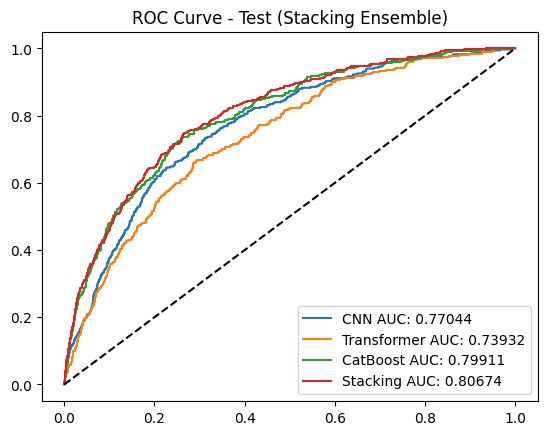

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from imblearn.over_sampling import RandomOverSampler

# CatBoost
!pip install catboost
from catboost import CatBoostClassifier

# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, Dropout, Flatten, Dense,
                                     MaxPooling1D, BatchNormalization, GlobalAveragePooling1D,
                                     LayerNormalization, Add)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

###########################################################################
# 1) 파일 로드
###########################################################################
stock_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet')
fin_df   = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/fin_result.parquet')

###########################################################################
# 2) 날짜 전처리
###########################################################################
stock_df['BSOP_DATE'] = pd.to_datetime(stock_df['BSOP_DATE'], errors='coerce')
fin_df['BSOP_DATE']   = pd.to_datetime(fin_df['BSOP_DATE'], errors='coerce')

# 코로나 기간 제외 + 2024-07-01 이전 데이터
stock_df = stock_df[(stock_df['BSOP_DATE'].dt.year != 2020) & (stock_df['BSOP_DATE'] < '2024-07-01')]
fin_df   = fin_df[(fin_df['BSOP_DATE'].dt.year != 2020) & (fin_df['BSOP_DATE']   < '2024-07-01')]

###########################################################################
# 3) ROE 결측치 제거 및 타겟 결측 제거
###########################################################################
roe_missing_stocks = fin_df[fin_df['ROE'].isna()]['SHRN_ISCD'].unique()
stock_df = stock_df[~stock_df['SHRN_ISCD'].isin(roe_missing_stocks)]
fin_df   = fin_df[~fin_df['SHRN_ISCD'].isin(roe_missing_stocks)]
fin_df   = fin_df.dropna(subset=['windowdrop'])

###########################################################################
# 4) 주요 설정값
###########################################################################
sequence_length = 40

stock_features = [
    'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR',
    'FN_ACML_TR_PBMN', 'MARKET_CAP', 'VKOSPI', 'KS200'
]
fin_features = [
    'ROE', 'DR', 'ROE_INC', 'PS', 'SHORT_DEBT', 'DEBT_COST_RATIO',
    'EQUITY', 'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY',
    'NET_INCOME', 'ICR', 'CF'
]

###########################################################################
# 5) 시퀀스(60일) + 동일 일자 주가 + 재무 + 타겟
###########################################################################
stock_series_data  = []  # 60일 시계열 데이터 (numpy array)
stock_current_data = []  # 당일 주가 데이터 (나중에 DataFrame 전환)
fin_series_data    = []  # 재무 데이터 (나중에 DataFrame 전환)
matched_targets    = []  # 타겟 변수 (windowdrop, 그대로 사용)
dates              = []  # 날짜 리스트
keys               = []  # (BSOP_DATE, SHRN_ISCD) 튜플

stock_groups = stock_df.groupby('SHRN_ISCD')

for stock_code, fin_group in fin_df.groupby('SHRN_ISCD'):
    if stock_code not in stock_groups.groups:
        continue
    stock_history_group = stock_groups.get_group(stock_code)

    for row in fin_group.itertuples():
        date = row.BSOP_DATE

        # 과거 60일 주가
        stock_history = (stock_history_group[stock_history_group['BSOP_DATE'] < date]
                         .sort_values('BSOP_DATE', ascending=False)
                         .head(sequence_length))
        if len(stock_history) != sequence_length:
            continue

        # 동일 일자 주가
        today_data_row = stock_history_group[stock_history_group['BSOP_DATE'] == date]
        if len(today_data_row) == 0:
            continue
        today_data = today_data_row[stock_features].iloc[0].values

        # 저장
        stock_series_data.append(stock_history[stock_features].values)
        stock_current_data.append(today_data)
        fin_series_data.append([getattr(row, f) for f in fin_features])
        matched_targets.append(row.windowdrop)
        dates.append(date)
        keys.append((date, stock_code))

# DataFrame 변환: 당일 주가 데이터
df_stock_current = pd.DataFrame(stock_current_data, columns=stock_features)
df_stock_current['BSOP_DATE'] = dates
df_stock_current['SHRN_ISCD'] = [k[1] for k in keys]
df_stock_current.set_index(['BSOP_DATE', 'SHRN_ISCD'], inplace=True)

# DataFrame 변환: 재무 데이터
df_fin = pd.DataFrame(fin_series_data, columns=fin_features)
df_fin['BSOP_DATE'] = dates
df_fin['SHRN_ISCD'] = [k[1] for k in keys]
df_fin.set_index(['BSOP_DATE', 'SHRN_ISCD'], inplace=True)

# 병합: 날짜와 종목코드를 기준으로 inner join
df_cat = pd.merge(df_stock_current, df_fin, left_index=True, right_index=True, how='inner')

# 새로운 피처 생성 (PER, PSR, FTRUTH) – target은 그대로 windowdrop 사용
df_cat['PER'] = df_cat['NET_INCOME'] / df_cat['MARKET_CAP']
df_cat['PSR'] = df_cat['PS'] / df_cat['STCK_PRPR']
df_cat['FTRUTH'] = df_cat['PS'] / df_cat['NET_INCOME']

# 넘파이 변환 (시계열 데이터는 이미 넘파이 배열)
stock_series_data  = np.array(stock_series_data)
# cat_data는 df_cat의 전체 내용을 넘파이 배열로 변환 (주로 CatBoost 입력용)
cat_data = np.array(df_cat)
# matched_targets와 dates도 넘파이 배열로
matched_targets = np.array(matched_targets)
dates = np.array(dates)

print("stock_series_data.shape :", stock_series_data.shape)   # (N, 60, len(stock_features))
print("stock_current_data.shape:", df_stock_current.shape)      # (N, len(stock_features))
print("fin_series_data.shape   :", df_fin.shape)                # (N, len(fin_features))

###########################################################################
# 6) Train/Test 분할 (날짜 기준)
###########################################################################
train_mask = dates < pd.Timestamp('2023-01-01')
test_mask  = dates >= pd.Timestamp('2023-01-01')

X_stock_train_seq = stock_series_data[train_mask]
X_stock_test_seq  = stock_series_data[test_mask]

X_fin_train = cat_data[train_mask]
X_fin_test  = cat_data[test_mask]

y_train = matched_targets[train_mask]
y_test  = matched_targets[test_mask]

dates_train = dates[train_mask]
dates_test  = dates[test_mask]

print("Train size:", len(y_train))
print("Test size :", len(y_test))

###########################################################################
# 7) 데이터 전처리 (로그 변환 + StandardScaler) - CNN 및 Transformer 입력용 (시계열 데이터)
###########################################################################
# 2차원으로 펼쳐서 로그변환, 스케일링 후 3차원 복구
temp_train = X_stock_train_seq.reshape(-1, len(stock_features))
temp_test  = X_stock_test_seq.reshape(-1, len(stock_features))

temp_train_log = np.log1p(temp_train)
temp_test_log  = np.log1p(temp_test)

stock_scaler_seq = StandardScaler()
temp_train_scaled = stock_scaler_seq.fit_transform(temp_train_log)
temp_test_scaled  = stock_scaler_seq.transform(temp_test_log)

X_stock_train_seq = temp_train_scaled.reshape(X_stock_train_seq.shape)
X_stock_test_seq  = temp_test_scaled.reshape(X_stock_test_seq.shape)

print("X_stock_train_seq.shape:", X_stock_train_seq.shape)
print("X_stock_test_seq.shape :", X_stock_test_seq.shape)

# 동일 일자 주가 데이터 (CatBoost 입력용): df_stock_current를 사용
curr_scaler = StandardScaler()
df_stock_current_reset = df_stock_current.reset_index()
X_stock_train_curr = curr_scaler.fit_transform(df_stock_current_reset.loc[train_mask, stock_features])
X_stock_test_curr  = curr_scaler.transform(df_stock_current_reset.loc[test_mask, stock_features])

###########################################################################
# 8) Train 오버샘플링 (각 모델별)
###########################################################################
ros = RandomOverSampler(random_state=42)

# (1) CNN 및 Transformer 오버샘플링: 시계열 데이터
train_idx_seq = np.arange(len(y_train)).reshape(-1,1)
resampled_idx_seq, y_train_res_seq = ros.fit_resample(train_idx_seq, y_train)
resampled_idx_seq = resampled_idx_seq.flatten()
X_stock_train_seq_res = X_stock_train_seq[resampled_idx_seq]

print("[시계열 데이터] Before Oversampling:", X_stock_train_seq.shape, "Pos Ratio:", np.mean(y_train))
print("[시계열 데이터] After  Oversampling:", X_stock_train_seq_res.shape, "Pos Ratio:", np.mean(y_train_res_seq))

# (2) CatBoost 오버샘플링: 동일 일자 주가 + 재무 데이터
X_cat_train = X_fin_train
X_cat_test  = X_fin_test

train_idx_cat = np.arange(len(y_train)).reshape(-1,1)
resampled_idx_cat, y_train_res_cat = ros.fit_resample(train_idx_cat, y_train)
resampled_idx_cat = resampled_idx_cat.flatten()
X_cat_train_res = X_cat_train[resampled_idx_cat]

print("[CatBoost] Before Oversampling:", X_cat_train.shape, "Pos Ratio:", np.mean(y_train))
print("[CatBoost] After  Oversampling:", X_cat_train_res.shape, "Pos Ratio:", np.mean(y_train_res_cat))

###########################################################################
# 9) CNN 모델 (이진 분류: 시계열 전용)
###########################################################################
sequence_input = Input(shape=(sequence_length, len(stock_features)), name='sequence_input')
x = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same')(sequence_input)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.4)(x)

x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.4)(x)

x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Flatten()(x)
x = Dense(16, activation='relu')(x)
x = Dropout(0.3)(x)
output_layer = Dense(1, activation='sigmoid')(x)

model_cnn = Model(inputs=sequence_input, outputs=output_layer)
model_cnn.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
model_cnn.summary()

###########################################################################
# 10) CNN 학습 (오버샘플링 데이터)
###########################################################################
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_cnn = model_cnn.fit(
    X_stock_train_seq_res, y_train_res_seq,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

###########################################################################
# 11) CNN 예측 확률 (원본 데이터 평가)
###########################################################################
cnn_pred_train_proba = model_cnn.predict(X_stock_train_seq).ravel()
cnn_pred_test_proba  = model_cnn.predict(X_stock_test_seq).ravel()

###########################################################################
# 12) Transformer 모델 (이진 분류: 시계열 전용)
###########################################################################
# Transformer Encoder 블록 정의
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x_attn = tf.keras.layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x_attn = Dropout(dropout)(x_attn)
    x = Add()([x, x_attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    x_ff = Dense(ff_dim, activation='relu')(x)
    x_ff = Dropout(dropout)(x_ff)
    x_ff = Dense(inputs.shape[-1])(x_ff)
    return Add()([x, x_ff])

transformer_input = Input(shape=(sequence_length, len(stock_features)), name='transformer_input')
# 입력 차원을 64로 투영 (옵션)
x = Dense(64)(transformer_input)
# Transformer Encoder 블록 적용 (필요시 블록을 여러 개 쌓을 수 있음)
x = transformer_encoder(x, head_size=32, num_heads=4, ff_dim=64, dropout=0.1)
x = GlobalAveragePooling1D()(x)
x = Dropout(0.1)(x)
x = Dense(16, activation='relu')(x)
x = Dropout(0.1)(x)
transformer_output = Dense(1, activation='sigmoid')(x)

model_transformer = Model(inputs=transformer_input, outputs=transformer_output)
model_transformer.compile(optimizer=Adam(learning_rate=0.001),
                          loss='binary_crossentropy',
                          metrics=['accuracy'])
model_transformer.summary()

###########################################################################
# 13) Transformer 학습 (오버샘플링 데이터)
###########################################################################
early_stop_transformer = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_transformer = model_transformer.fit(
    X_stock_train_seq_res, y_train_res_seq,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_transformer],
    verbose=1
)

###########################################################################
# 14) Transformer 예측 확률 (원본 데이터 평가)
###########################################################################
transformer_pred_train_proba = model_transformer.predict(X_stock_train_seq).ravel()
transformer_pred_test_proba  = model_transformer.predict(X_stock_test_seq).ravel()

###########################################################################
# 15) CatBoost 학습 (오버샘플링 데이터)
###########################################################################
cat = CatBoostClassifier(
    iterations=100000,
    depth=6,
    learning_rate=0.01,
    random_seed=42,
    verbose=100,
    loss_function='Logloss',
    early_stopping_rounds=100,
    l2_leaf_reg=5,
    random_strength=1,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    eval_metric='AUC',
    use_best_model=True
)
cat_model = cat
cat_model.fit(
    X_cat_train_res, y_train_res_cat,
    eval_set=(X_cat_test, y_test),
)

###########################################################################
# 16) CatBoost 예측 확률 (원본 데이터 평가)
###########################################################################
cat_pred_train_proba = cat_model.predict_proba(X_cat_train)[:,1]
cat_pred_test_proba  = cat_model.predict_proba(X_cat_test)[:,1]

###########################################################################
# 17) 세 모델 예측 결합 (스태킹 앙상블)
###########################################################################
from sklearn.linear_model import LogisticRegression

# 메타 피처 구성: 각 행은 [CNN 예측, Transformer 예측, CatBoost 예측]
X_meta_train = np.column_stack((cnn_pred_train_proba, transformer_pred_train_proba, cat_pred_train_proba))
X_meta_test  = np.column_stack((cnn_pred_test_proba, transformer_pred_test_proba, cat_pred_test_proba))

# 메타 모델 학습
meta_model = LogisticRegression()
meta_model.fit(X_meta_train, y_train)

# 메타 모델을 통한 최종 예측
stacked_pred_train = meta_model.predict_proba(X_meta_train)[:, 1]
stacked_pred_test  = meta_model.predict_proba(X_meta_test)[:, 1]

# 평가: AUC 계산
stacked_auc_train = roc_auc_score(y_train, stacked_pred_train)
stacked_auc_test  = roc_auc_score(y_test, stacked_pred_test)
print(f"[Stacking] Train AUC: {stacked_auc_train:.5f}")
print(f"[Stacking] Test AUC: {stacked_auc_test:.5f}")

# ===== ROC Curve 시각화 (스태킹 앙상블) =====
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, cnn_pred_test_proba)
fpr_transformer, tpr_transformer, _ = roc_curve(y_test, transformer_pred_test_proba)
fpr_cat, tpr_cat, _ = roc_curve(y_test, cat_pred_test_proba)
fpr_stack, tpr_stack, _ = roc_curve(y_test, stacked_pred_test)

auc_cnn = roc_auc_score(y_test, cnn_pred_test_proba)
auc_transformer = roc_auc_score(y_test, transformer_pred_test_proba)
auc_cat = roc_auc_score(y_test, cat_pred_test_proba)

plt.plot(fpr_cnn, tpr_cnn, label=f'CNN AUC: {auc_cnn:.5f}')
plt.plot(fpr_transformer, tpr_transformer, label=f'Transformer AUC: {auc_transformer:.5f}')
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost AUC: {auc_cat:.5f}')
plt.plot(fpr_stack, tpr_stack, label=f'Stacking AUC: {stacked_auc_test:.5f}')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve - Test (Stacking Ensemble)')
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from imblearn.over_sampling import RandomOverSampler

# CatBoost
import os
import numpy as np
import sys
import subprocess

# 필요한 numpy 버전 지정
required_version = "1.26.4"

# 현재 numpy 버전 확인 (예: 2.2.4는 호환되지 않음)
if version.parse(np.__version__) >= version.parse("2.0.0"):
    print(f"현재 numpy 버전: {np.__version__} - 호환되지 않습니다. {required_version}로 재설치합니다.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"numpy=={required_version}"])
    print("재설치 완료. 런타임을 재시작하세요.")
else:
    print("numpy 버전이 호환됩니다.")


!pip install catboost
from catboost import CatBoostClassifier


# TensorFlow/Keras
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, Dropout, Flatten, Dense,
                                     MaxPooling1D, BatchNormalization, GlobalAveragePooling1D,
                                     LayerNormalization, Add)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

###########################################################################
# 1) 파일 로드
###########################################################################
stock_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet')
fin_df   = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/fin_result.parquet')

###########################################################################
# 2) 날짜 전처리
###########################################################################
stock_df['BSOP_DATE'] = pd.to_datetime(stock_df['BSOP_DATE'], errors='coerce')
fin_df['BSOP_DATE']   = pd.to_datetime(fin_df['BSOP_DATE'], errors='coerce')

# 코로나 기간 제외 + 2024-07-01 이전 데이터
stock_df = stock_df[(stock_df['BSOP_DATE'].dt.year != 2020) & (stock_df['BSOP_DATE'] < '2024-07-01')]
fin_df   = fin_df[(fin_df['BSOP_DATE'].dt.year != 2020) & (fin_df['BSOP_DATE']   < '2024-07-01')]

###########################################################################
# 3) ROE 결측치 제거 및 타겟 결측 제거
###########################################################################
roe_missing_stocks = fin_df[fin_df['ROE'].isna()]['SHRN_ISCD'].unique()
stock_df = stock_df[~stock_df['SHRN_ISCD'].isin(roe_missing_stocks)]
fin_df   = fin_df[~fin_df['SHRN_ISCD'].isin(roe_missing_stocks)]
fin_df   = fin_df.dropna(subset=['windowdrop'])

###########################################################################
# 4) 주요 설정값
###########################################################################
sequence_length = 40

stock_features = [
    'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR',
    'FN_ACML_TR_PBMN', 'MARKET_CAP', 'vkospi', 'ks200', 'fx'
]
fin_features = [
    'ROE', 'DR', 'ROE_INC', 'PS', 'SHORT_DEBT', 'DEBT_COST_RATIO',
    'EQUITY', 'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY',
    'NET_INCOME', 'ICR', 'CF'
]

###########################################################################
# 5) 시퀀스(60일) + 동일 일자 주가 + 재무 + 타겟
###########################################################################
stock_series_data  = []  # 60일 시계열 데이터 (numpy array)
stock_current_data = []  # 당일 주가 데이터 (나중에 DataFrame 전환)
fin_series_data    = []  # 재무 데이터 (나중에 DataFrame 전환)
matched_targets    = []  # 타겟 변수 (windowdrop, 그대로 사용)
dates              = []  # 날짜 리스트
keys               = []  # (BSOP_DATE, SHRN_ISCD) 튜플

stock_groups = stock_df.groupby('SHRN_ISCD')

for stock_code, fin_group in fin_df.groupby('SHRN_ISCD'):
    if stock_code not in stock_groups.groups:
        continue
    stock_history_group = stock_groups.get_group(stock_code)

    for row in fin_group.itertuples():
        date = row.BSOP_DATE

        # 과거 60일 주가
        stock_history = (stock_history_group[stock_history_group['BSOP_DATE'] < date]
                         .sort_values('BSOP_DATE', ascending=False)
                         .head(sequence_length))
        if len(stock_history) != sequence_length:
            continue

        # 동일 일자 주가
        today_data_row = stock_history_group[stock_history_group['BSOP_DATE'] == date]
        if len(today_data_row) == 0:
            continue
        today_data = today_data_row[stock_features].iloc[0].values

        # 저장
        stock_series_data.append(stock_history[stock_features].values)
        stock_current_data.append(today_data)
        fin_series_data.append([getattr(row, f) for f in fin_features])
        matched_targets.append(row.windowdrop)
        dates.append(date)
        keys.append((date, stock_code))

# DataFrame 변환: 당일 주가 데이터
df_stock_current = pd.DataFrame(stock_current_data, columns=stock_features)
df_stock_current['BSOP_DATE'] = dates
df_stock_current['SHRN_ISCD'] = [k[1] for k in keys]
df_stock_current.set_index(['BSOP_DATE', 'SHRN_ISCD'], inplace=True)

# DataFrame 변환: 재무 데이터
df_fin = pd.DataFrame(fin_series_data, columns=fin_features)
df_fin['BSOP_DATE'] = dates
df_fin['SHRN_ISCD'] = [k[1] for k in keys]
df_fin.set_index(['BSOP_DATE', 'SHRN_ISCD'], inplace=True)

# 병합: 날짜와 종목코드를 기준으로 inner join
df_cat = pd.merge(df_stock_current, df_fin, left_index=True, right_index=True, how='inner')

# 새로운 피처 생성 (PER, PSR, FTRUTH) – target은 그대로 windowdrop 사용
df_cat['PER'] = df_cat['NET_INCOME'] / df_cat['MARKET_CAP']
df_cat['PSR'] = df_cat['PS'] / df_cat['STCK_PRPR']
df_cat['FTRUTH'] = df_cat['PS'] / df_cat['NET_INCOME']

# 넘파이 변환 (시계열 데이터는 이미 넘파이 배열)
stock_series_data  = np.array(stock_series_data)
# cat_data는 df_cat의 전체 내용을 넘파이 배열로 변환 (주로 CatBoost 입력용)
cat_data = np.array(df_cat)
# matched_targets와 dates도 넘파이 배열로
matched_targets = np.array(matched_targets)
dates = np.array(dates)

print("stock_series_data.shape :", stock_series_data.shape)   # (N, 60, len(stock_features))
print("stock_current_data.shape:", df_stock_current.shape)      # (N, len(stock_features))
print("fin_series_data.shape   :", df_fin.shape)                # (N, len(fin_features))

###########################################################################
# 6) Train/Test 분할 (날짜 기준)
###########################################################################
train_mask = dates < pd.Timestamp('2022-01-01')
test_mask  = dates >= pd.Timestamp('2022-01-01')

X_stock_train_seq = stock_series_data[train_mask]
X_stock_test_seq  = stock_series_data[test_mask]

X_fin_train = cat_data[train_mask]
X_fin_test  = cat_data[test_mask]

y_train = matched_targets[train_mask]
y_test  = matched_targets[test_mask]

dates_train = dates[train_mask]
dates_test  = dates[test_mask]

print("Train size:", len(y_train))
print("Test size :", len(y_test))

###########################################################################
# 7) 데이터 전처리 (로그 변환 + StandardScaler) - CNN 및 Transformer 입력용 (시계열 데이터)
###########################################################################
# 2차원으로 펼쳐서 로그변환, 스케일링 후 3차원 복구
temp_train = X_stock_train_seq.reshape(-1, len(stock_features))
temp_test  = X_stock_test_seq.reshape(-1, len(stock_features))

temp_train_log = np.log1p(temp_train)
temp_test_log  = np.log1p(temp_test)

stock_scaler_seq = StandardScaler()
temp_train_scaled = stock_scaler_seq.fit_transform(temp_train_log)
temp_test_scaled  = stock_scaler_seq.transform(temp_test_log)

X_stock_train_seq = temp_train_scaled.reshape(X_stock_train_seq.shape)
X_stock_test_seq  = temp_test_scaled.reshape(X_stock_test_seq.shape)

print("X_stock_train_seq.shape:", X_stock_train_seq.shape)
print("X_stock_test_seq.shape :", X_stock_test_seq.shape)

# 동일 일자 주가 데이터 (CatBoost 입력용): df_stock_current를 사용
curr_scaler = StandardScaler()
df_stock_current_reset = df_stock_current.reset_index()
X_stock_train_curr = curr_scaler.fit_transform(df_stock_current_reset.loc[train_mask, stock_features])
X_stock_test_curr  = curr_scaler.transform(df_stock_current_reset.loc[test_mask, stock_features])

###########################################################################
# 8) Train 오버샘플링 (각 모델별)
###########################################################################
ros = RandomOverSampler(random_state=42)

# (1) CNN 및 Transformer 오버샘플링: 시계열 데이터
train_idx_seq = np.arange(len(y_train)).reshape(-1,1)
resampled_idx_seq, y_train_res_seq = ros.fit_resample(train_idx_seq, y_train)
resampled_idx_seq = resampled_idx_seq.flatten()
X_stock_train_seq_res = X_stock_train_seq[resampled_idx_seq]

print("[시계열 데이터] Before Oversampling:", X_stock_train_seq.shape, "Pos Ratio:", np.mean(y_train))
print("[시계열 데이터] After  Oversampling:", X_stock_train_seq_res.shape, "Pos Ratio:", np.mean(y_train_res_seq))

# (2) CatBoost 오버샘플링: 동일 일자 주가 + 재무 데이터
X_cat_train = X_fin_train
X_cat_test  = X_fin_test

train_idx_cat = np.arange(len(y_train)).reshape(-1,1)
resampled_idx_cat, y_train_res_cat = ros.fit_resample(train_idx_cat, y_train)
resampled_idx_cat = resampled_idx_cat.flatten()
X_cat_train_res = X_cat_train[resampled_idx_cat]

print("[CatBoost] Before Oversampling:", X_cat_train.shape, "Pos Ratio:", np.mean(y_train))
print("[CatBoost] After  Oversampling:", X_cat_train_res.shape, "Pos Ratio:", np.mean(y_train_res_cat))

###########################################################################
# 9) CNN 모델 (이진 분류: 시계열 전용)
###########################################################################
sequence_input = Input(shape=(sequence_length, len(stock_features)), name='sequence_input')
x = Conv1D(filters=128, kernel_size=5, activation='relu', padding='same')(sequence_input)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.4)(x)

x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Dropout(0.4)(x)

x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = Flatten()(x)
x = Dense(16, activation='relu')(x)
x = Dropout(0.3)(x)
output_layer = Dense(1, activation='sigmoid')(x)

model_cnn = Model(inputs=sequence_input, outputs=output_layer)
model_cnn.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
model_cnn.summary()

###########################################################################
# 10) CNN 학습 (오버샘플링 데이터)
###########################################################################
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_cnn = model_cnn.fit(
    X_stock_train_seq_res, y_train_res_seq,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

###########################################################################
# 11) CNN 예측 확률 (원본 데이터 평가)
###########################################################################
cnn_pred_train_proba = model_cnn.predict(X_stock_train_seq).ravel()
cnn_pred_test_proba  = model_cnn.predict(X_stock_test_seq).ravel()

###########################################################################
# 12) Transformer 모델 (이진 분류: 시계열 전용)
###########################################################################
# Transformer Encoder 블록 정의
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = LayerNormalization(epsilon=1e-6)(inputs)
    x_attn = tf.keras.layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    x_attn = Dropout(dropout)(x_attn)
    x = Add()([x, x_attn])
    x = LayerNormalization(epsilon=1e-6)(x)
    x_ff = Dense(ff_dim, activation='relu')(x)
    x_ff = Dropout(dropout)(x_ff)
    x_ff = Dense(inputs.shape[-1])(x_ff)
    return Add()([x, x_ff])

transformer_input = Input(shape=(sequence_length, len(stock_features)), name='transformer_input')
# 입력 차원을 64로 투영 (옵션)
x = Dense(64)(transformer_input)
# Transformer Encoder 블록 적용 (필요시 블록을 여러 개 쌓을 수 있음)
x = transformer_encoder(x, head_size=32, num_heads=4, ff_dim=64, dropout=0.1)
attn_weights = tf.keras.layers.Dense(1)(x)               # (batch, seq_len, 1)
attn_weights = tf.keras.layers.Softmax(axis=1)(attn_weights)
x = tf.reduce_sum(x * attn_weights, axis=1)              # (batch, feature_dim)
x = Dropout(0.1)(x)
x = Dense(16, activation='relu')(x)
x = Dropout(0.1)(x)
transformer_output = Dense(1, activation='sigmoid')(x)

model_transformer = Model(inputs=transformer_input, outputs=transformer_output)
model_transformer.compile(optimizer=Adam(learning_rate=0.001),
                          loss='binary_crossentropy',
                          metrics=['accuracy'])
model_transformer.summary()

###########################################################################
# 13) Transformer 학습 (오버샘플링 데이터)
###########################################################################
early_stop_transformer = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history_transformer = model_transformer.fit(
    X_stock_train_seq_res, y_train_res_seq,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_transformer],
    verbose=1
)

###########################################################################
# 14) Transformer 예측 확률 (원본 데이터 평가)
###########################################################################
transformer_pred_train_proba = model_transformer.predict(X_stock_train_seq).ravel()
transformer_pred_test_proba  = model_transformer.predict(X_stock_test_seq).ravel()

###########################################################################
# 15) CatBoost 학습 (오버샘플링 데이터)
###########################################################################
cat = CatBoostClassifier(
    iterations=100000,
    depth=6,
    learning_rate=0.01,
    random_seed=42,
    verbose=100,
    loss_function='Logloss',
    early_stopping_rounds=100,
    l2_leaf_reg=5,
    random_strength=1,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    eval_metric='AUC',
    use_best_model=True
)
cat_model = cat
cat_model.fit(
    X_cat_train_res, y_train_res_cat,
    eval_set=(X_cat_test, y_test),
)

###########################################################################
# 16) CatBoost 예측 확률 (원본 데이터 평가)
###########################################################################
cat_pred_train_proba = cat_model.predict_proba(X_cat_train)[:,1]
cat_pred_test_proba  = cat_model.predict_proba(X_cat_test)[:,1]

###########################################################################
# 17) 세 모델 예측 결합 (스태킹 앙상블)
###########################################################################
from sklearn.linear_model import LogisticRegression

# 메타 피처 구성: 각 행은 [CNN 예측, Transformer 예측, CatBoost 예측]
X_meta_train = np.column_stack((cnn_pred_train_proba, transformer_pred_train_proba, cat_pred_train_proba))
X_meta_test  = np.column_stack((cnn_pred_test_proba, transformer_pred_test_proba, cat_pred_test_proba))

# 메타 모델 학습
meta_model = LogisticRegression()
meta_model.fit(X_meta_train, y_train)

# 메타 모델을 통한 최종 예측
stacked_pred_train = meta_model.predict_proba(X_meta_train)[:, 1]
stacked_pred_test  = meta_model.predict_proba(X_meta_test)[:, 1]

# 평가: AUC 계산
stacked_auc_train = roc_auc_score(y_train, stacked_pred_train)
stacked_auc_test  = roc_auc_score(y_test, stacked_pred_test)
print(f"[Stacking] Train AUC: {stacked_auc_train:.5f}")
print(f"[Stacking] Test AUC: {stacked_auc_test:.5f}")

# ===== ROC Curve 시각화 (스태킹 앙상블) =====
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, cnn_pred_test_proba)
fpr_transformer, tpr_transformer, _ = roc_curve(y_test, transformer_pred_test_proba)
fpr_cat, tpr_cat, _ = roc_curve(y_test, cat_pred_test_proba)
fpr_stack, tpr_stack, _ = roc_curve(y_test, stacked_pred_test)

auc_cnn = roc_auc_score(y_test, cnn_pred_test_proba)
auc_transformer = roc_auc_score(y_test, transformer_pred_test_proba)
auc_cat = roc_auc_score(y_test, cat_pred_test_proba)

plt.plot(fpr_cnn, tpr_cnn, label=f'CNN AUC: {auc_cnn:.5f}')
plt.plot(fpr_transformer, tpr_transformer, label=f'Transformer AUC: {auc_transformer:.5f}')
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost AUC: {auc_cat:.5f}')
plt.plot(fpr_stack, tpr_stack, label=f'Stacking AUC: {stacked_auc_test:.5f}')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve - Test (Stacking Ensemble)')
plt.legend()
plt.show()

# 브라이어 스코어
from sklearn.metrics import brier_score_loss

# 베이스라인 확률 예측 (항상 y_train 평균값으로 예측)
baseline_proba = np.full_like(y_test, fill_value=np.mean(y_train), dtype=float)

# Brier Score 계산
brier_cnn = brier_score_loss(y_test, cnn_pred_test_proba)
brier_transformer = brier_score_loss(y_test, transformer_pred_test_proba)
brier_cat = brier_score_loss(y_test, cat_pred_test_proba)
brier_stack = brier_score_loss(y_test, stacked_pred_test)
brier_baseline = brier_score_loss(y_test, baseline_proba)

print(f"[Brier Score] CNN         : {brier_cnn:.5f}")
print(f"[Brier Score] Transformer : {brier_transformer:.5f}")
print(f"[Brier Score] CatBoost    : {brier_cat:.5f}")
print(f"[Brier Score] Stacking    : {brier_stack:.5f}")
print(f"[Brier Score] Baseline    : {brier_baseline:.5f}")


Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7d386131c0e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: /usr/local/lib/python3.11/dist-packages/numpy.libs/libscipy_openblas64_-99b71e

현재 numpy 버전: 2.0.2 - 호환되지 않습니다. 1.26.4로 재설치합니다.
재설치 완료. 런타임을 재시작하세요.


KeyboardInterrupt: 

## autoencoder

###catboost

In [ ]:
import pandas as pd
import numpy as np
# Tensorflow / Keras Imports - Modify for Transformer
import tensorflow as tf
from tensorflow.keras.models import Model
# >>> MODIFICATION START: Import Transformer layers, remove unused CNN layers <<<
# from tensorflow.keras.layers import Input, Dense, Conv1D, Flatten, Dropout, MaxPooling1D, UpSampling1D, Reshape
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D, TimeDistributed, Reshape, Embedding # Added Embedding
# >>> MODIFICATION END <<<
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

# CatBoost
# !pip install catboost imblearn # imblearn은 이제 필요 없음
from catboost import CatBoostClassifier
# from imblearn.over_sampling import RandomOverSampler # 삭제

############################################################
# 1) 파일 로드 (변경 없음)
############################################################
# 경로를 실제 환경에 맞게 수정해야 합니다.
try:
    stock_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet')
    fin_df   = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_fin_result_with_vkospi_all.parquet')
    print("Successfully loaded data from Parquet files.")
except FileNotFoundError:
    print("Warning: Parquet files not found. Please ensure the path is correct or provide dummy data.")
    # If you need dummy data for testing, uncomment and adapt the block from your *original* code.
    # Make sure this dummy data generation is *exactly* as you had it before, DO NOT use the modified one from the previous response.
    # Example (using the structure from the prompt):
    # stock_df = pd.DataFrame(...) # Your original dummy stock_df
    # fin_df = pd.DataFrame(...) # Your original dummy fin_df
    # print("Using dummy data for execution.")
    # If dummy data is not needed or provided, the script might fail later.
    # For now, let's assume files exist or the user will handle this.
    pass # Allow the script to continue, potentially failing later if files are truly missing.


############################################################
# 2) 날짜 전처리 (변경 없음)
############################################################
stock_df['BSOP_DATE'] = pd.to_datetime(stock_df['BSOP_DATE'], errors='coerce')
fin_df['BSOP_DATE']   = pd.to_datetime(fin_df['BSOP_DATE'],   errors='coerce')

# 코로나 기간 제외 + 2024-07-01 이전 데이터
stock_df = stock_df[(stock_df['BSOP_DATE'].dt.year != 2020) & (stock_df['BSOP_DATE'] < '2024-07-01')].copy() # Added .copy() to avoid SettingWithCopyWarning
fin_df   = fin_df[(fin_df['BSOP_DATE'].dt.year != 2020) & (fin_df['BSOP_DATE']   < '2024-07-01')].copy() # Added .copy()

############################################################
# 3) ROE 결측치 제거 및 피처 생성 (변경 없음)
############################################################
# 1) fin_df에서 ROE가 하나라도 존재하는 종목만 남김
mask_fin = fin_df.groupby('SHRN_ISCD')['ROE'].transform('count') > 0
fin_df = fin_df[mask_fin].copy()
valid_codes = fin_df['SHRN_ISCD'].unique()
stock_df = stock_df[stock_df['SHRN_ISCD'].isin(valid_codes)].copy()

# 전체 컬럼 이름 보기
print("Stock DF Columns:", stock_df.columns.tolist()) # Added label

# 타겟이 결측치인 행 제거
fin_df = fin_df.dropna(subset=['windowdrop']).copy() # Added .copy()

fin_df['MONTH'] = fin_df['BSOP_DATE'].dt.month

# 피처 생성 (변경 없음)
fin_df.loc[:, 'PRICE_TO_52W_HIGH'] = fin_df['STCK_PRPR'] / fin_df['W52_HGPR']
fin_df.loc[:, 'PRICE_TO_52W_LOW'] = fin_df['STCK_PRPR'] / fin_df['W52_LWPR']
fin_df.loc[:, 'PER'] = fin_df['NET_INCOME'] / fin_df['MARKET_CAP']
fin_df.loc[:, 'PSR'] = fin_df['PS'] / fin_df['STCK_PRPR']
fin_df.loc[:, 'FTRUTH'] = fin_df['PS'] / fin_df['NET_INCOME']
fin_df.loc[:, 'NET_DEBT'] = fin_df['NET_DEBT'] / fin_df['MARKET_CAP']
fin_df.loc[:, 'DEBT_COST'] = fin_df['DEBT_COST'] / fin_df['MARKET_CAP']

# 라벨 인코더 (변경 없음)
le_scrt = LabelEncoder()
le_mrkt = LabelEncoder()
# Handle potential unseen values during transform if necessary
fin_df['SCRT_GRP_CLS_CODE'] = fin_df['SCRT_GRP_CLS_CODE'].astype(str)
fin_df['MRKT_DIV_CLS_CODE'] = fin_df['MRKT_DIV_CLS_CODE'].astype(str)
fin_df['SCRT_GRP_CLS_CODE'] = le_scrt.fit_transform(fin_df['SCRT_GRP_CLS_CODE'])
fin_df['MRKT_DIV_CLS_CODE'] = le_mrkt.fit_transform(fin_df['MRKT_DIV_CLS_CODE'])

############################################################
# 4) 주요 설정값 (변경 없음)
############################################################
sequence_length = 60

stock_features = [
    'STCK_PRPR',
    #'vkospi', #'ks200', #'MARKET_CAP'
    #'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR',
    #'FN_ACML_TR_PBMN', #'MARKET_CAP', 'vkospi', 'ks200'
]
n_stock_features = len(stock_features) # Recalculate after definition

fin_features = [
    'PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW',
    'SCRT_GRP_CLS_CODE',
    #'MRKT_DIV_CLS_CODE', # Added encoded market division
    #'SEASONALITY',
    'MONTH',
    #'YEAR',
    'VKOSPI',   #'ks200',
    #'PRDY_VRSS_SIGN',
    #'MARKET_CAP',
    'FN_ACML_TR_PBMN',
    'ORGN_NTBY_QTY',
    'DR', 'PSR', 'ROE', 'ROE_INC',
    'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH',
    'F70', 'F71',  #   '자본금증가율(YoY)': 'F70','총자본증가율(YoY)': 'F71',
    #,'F8','F9','F10','F11','F12','F13','F14','F15','F16','F17','F18','F19','F20','F21',
]
# Ensure only existing columns are used
fin_features = [f for f in fin_features if f in fin_df.columns]
print("Using Fin Features:", fin_features) # Added print


############################################################
# 5) 시퀀스 데이터 생성 (변경 없음)
############################################################
stock_series_data  = []  # (N, 60, n_stock_features) - Autoencoder 입력
stock_current_data = []  # (N, n_stock_features) - 동일 날짜 주가
fin_series_data    = []  # (N, len(fin_features))
matched_targets    = []
dates              = []

stock_groups = stock_df.groupby('SHRN_ISCD')

# Handle potential NaN/Inf before loop (Minimal handling: fillna(0))
# Replace inf/-inf first, then fillna
fin_df = fin_df.replace([np.inf, -np.inf], np.nan)
stock_df = stock_df.replace([np.inf, -np.inf], np.nan)
fin_df.fillna(0, inplace=True)
stock_df.fillna(0, inplace=True)


print("Starting sequence generation...") # Added print
processed_count = 0
skipped_short_seq = 0
skipped_no_today = 0

for stock_code, fin_group in fin_df.groupby('SHRN_ISCD'):
    if stock_code not in stock_groups.groups:
        continue
    stock_history_group = stock_groups.get_group(stock_code).sort_values('BSOP_DATE') # Sort added

    # Ensure stock history has enough data points overall
    if len(stock_history_group) < sequence_length:
        continue

    for row in fin_group.itertuples():
        date = row.BSOP_DATE

        # 5-1) 과거 60일분 주가
        # Efficiently find the end index for the historical slice
        end_index = stock_history_group['BSOP_DATE'].searchsorted(date, side='left')
        start_index = max(0, end_index - sequence_length)
        stock_history = stock_history_group.iloc[start_index:end_index]


        # stock_history = ( # Original method - potentially slower
        #     stock_history_group[stock_history_group['BSOP_DATE'] < date]
        #     .tail(sequence_length)
        # )

        if len(stock_history) != sequence_length:
            skipped_short_seq += 1
            continue  # 시계열 길이가 부족하면 스킵

        # 5-2) '동일 일자'에 해당하는 주가 (1행)
        # Use the pre-sorted group for efficiency
        today_data_row = stock_history_group[stock_history_group['BSOP_DATE'] == date]
        # today_data_row = stock_history_group.loc[stock_history_group['BSOP_DATE'] == date] # Alternative using loc

        if len(today_data_row) == 0:
            # This might happen if fin_df has dates not present in stock_df for that SHRN_ISCD
            skipped_no_today += 1
            continue

        # 오늘 날짜 주가 (stock_features)
        today_data = today_data_row[stock_features].iloc[0].values

        # 5-3) 저장
        stock_series_data.append(stock_history[stock_features].values)  # 60일 시계열
        stock_current_data.append(today_data)                            # 동일 일자 1행
        fin_series_data.append([getattr(row, f) for f in fin_features])
        matched_targets.append(row.windowdrop)
        dates.append(date)
        processed_count += 1

print(f"Finished sequence generation. Processed: {processed_count}, Skipped (short seq): {skipped_short_seq}, Skipped (no today data): {skipped_no_today}") # Added counts


# Check if data was generated
if not stock_series_data:
     raise ValueError("No sequences generated. Check data and preprocessing steps (e.g., date ranges, joins, sufficient history).")

stock_series_data  = np.array(stock_series_data)   # shape: (N, 60, n_stock_features)
stock_current_data = np.array(stock_current_data)  # shape: (N, n_stock_features)
fin_series_data    = np.array(fin_series_data)     # shape: (N, len(fin_features))
matched_targets    = np.array(matched_targets)
dates              = np.array(dates)

print("stock_series_data.shape :", stock_series_data.shape)
print("stock_current_data.shape:", stock_current_data.shape)
print("fin_series_data.shape   :", fin_series_data.shape)
print("matched_targets.shape :", matched_targets.shape) # Added print
print("dates.shape           :", dates.shape)           # Added print


############################################################
# 6) Train/Test 분할 (변경 없음)
############################################################
train_mask = dates < pd.Timestamp('2023-01-01')
test_mask  = dates >= pd.Timestamp('2023-01-01')

# Ensure there's data in both train and test sets
if not np.any(train_mask) or not np.any(test_mask):
    raise ValueError(f"Data splitting error: Train samples={np.sum(train_mask)}, Test samples={np.sum(test_mask)}. Check date range and data.")


# Important: Autoencoder uses the original sequences for training
X_stock_train_seq  = stock_series_data[train_mask]   # Autoencoder Train Input/Target
X_stock_test_seq   = stock_series_data[test_mask]    # Autoencoder Test Input / Embedding source

X_stock_train_curr = stock_current_data[train_mask]  # '동일 일자' 주가 (CatBoost용) - Keep as original
X_stock_test_curr  = stock_current_data[test_mask] # Keep as original

X_fin_train = fin_series_data[train_mask]            # 재무 데이터 (CatBoost용)
X_fin_test  = fin_series_data[test_mask]

y_train = matched_targets[train_mask]                # CatBoost Train Target
y_test  = matched_targets[test_mask]                 # CatBoost Test Target

print("Train size (for Autoencoder & CatBoost target):", len(y_train))
print("Test size  (for Autoencoder & CatBoost target):", len(y_test))
print("Train target distribution (Class 1):", np.mean(y_train)) # Added print
print("Test target distribution  (Class 1):", np.mean(y_test)) # Added print


############################################################
# 7) 데이터 정규화 (변경 없음 - 시계열 데이터에 동일하게 적용)
############################################################
# NaN/Inf check before reshape/scaling (minimal handling) - Already done before loop
# X_stock_train_seq = np.nan_to_num(X_stock_train_seq) # Redundant if handled before
# X_stock_test_seq = np.nan_to_num(X_stock_test_seq)   # Redundant
# X_fin_train = np.nan_to_num(X_fin_train)             # Redundant
# X_fin_test = np.nan_to_num(X_fin_test)               # Redundant
# X_stock_train_curr = np.nan_to_num(X_stock_train_curr) # Redundant
# X_stock_test_curr = np.nan_to_num(X_stock_test_curr)   # Redundant


# (1) 먼저 2차원 (N*60, n_stock_features)) 형태로 펼침
n_train_samples, seq_len, n_features = X_stock_train_seq.shape
n_test_samples = X_stock_test_seq.shape[0]

# Check for edge case where n_features might mismatch if stock_features list was faulty
if n_features != n_stock_features:
     raise ValueError(f"Feature count mismatch: X_stock_train_seq has {n_features} features, expected {n_stock_features}")


temp_train = X_stock_train_seq.reshape(-1, n_stock_features)
temp_test  = X_stock_test_seq.reshape(-1, n_stock_features)


# Ensure non-negativity for log1p (replace negative values, e.g., with 0)
# Check min values before clipping
# print("Min value in temp_train before clip:", temp_train.min())
# print("Min value in temp_test before clip:", temp_test.min())
temp_train[temp_train < 0] = 0
temp_test[temp_test < 0] = 0


# (2) 로그 변환 - np.log1p 사용 (log(1 + x))
temp_train_log = np.log1p(temp_train)
temp_test_log  = np.log1p(temp_test)

# Handle potential NaNs/Infs *after* log transformation if needed (e.g., if input was exactly -1)
temp_train_log = np.nan_to_num(temp_train_log, nan=0.0, posinf=0.0, neginf=0.0) # Replace potential issues
temp_test_log = np.nan_to_num(temp_test_log, nan=0.0, posinf=0.0, neginf=0.0) # Replace potential issues


# (3) StandardScaler 적용
stock_scaler_seq = StandardScaler()
temp_train_scaled = stock_scaler_seq.fit_transform(temp_train_log)
temp_test_scaled  = stock_scaler_seq.transform(temp_test_log)

# Check if scaling produced NaNs (can happen if variance is zero in a feature)
if np.isnan(temp_train_scaled).any() or np.isnan(temp_test_scaled).any():
    print("Warning: NaNs detected after scaling. Check for constant features in training data.")
    temp_train_scaled = np.nan_to_num(temp_train_scaled)
    temp_test_scaled = np.nan_to_num(temp_test_scaled)


# (4) 다시 3차원 (N, 60, n_stock_features))로 복구
X_stock_train_seq_scaled = temp_train_scaled.reshape(n_train_samples, seq_len, n_features)
X_stock_test_seq_scaled  = temp_test_scaled.reshape(n_test_samples, seq_len, n_features)

print("Scaled train sequence shape:", X_stock_train_seq_scaled.shape) # Added print
print("Scaled test sequence shape:", X_stock_test_seq_scaled.shape) # Added print

# 동일 일자 주가 피처 및 재무 피처 스케일링 (주석 처리 유지 - 원본 코드 유지)
# stock_scaler_curr = StandardScaler()
# X_stock_train_curr = stock_scaler_curr.fit_transform(X_stock_train_curr)
# X_stock_test_curr  = stock_scaler_curr.transform(X_stock_test_curr)

# fin_scaler = StandardScaler()
# X_fin_train = fin_scaler.fit_transform(X_fin_train)
# X_fin_test  = fin_scaler.transform(X_fin_test)

############################################################
# 8) 오버샘플링 제거 (변경 없음 - 코드는 이미 제거됨)
############################################################
# (No code here in the original prompt, remains unchanged)
print("Skipping oversampling step as per previous modification.")


#시드 고정 (변경 없음)
import tensorflow as tf # TensorFlow 임포트 추가
import random # 파이썬 기본 random 모듈 임포트 추가
import os # os 모듈 임포트 추가
# --- 랜덤 시드 고정 ---
seed_value = 42 # 원하는 시드 값 설정
# 1. Python 기본 해시 시드 설정 (필요한 경우)
os.environ['PYTHONHASHSEED'] = str(seed_value)
# 2. Python 기본 random 모듈 시드 설정
random.seed(seed_value)
# 3. NumPy 시드 설정
np.random.seed(seed_value)
# 4. TensorFlow 시드 설정 (글로벌 시드 및 연산 수준 시드)
tf.random.set_seed(seed_value)
# tf.config.experimental.enable_op_determinism() # Keep commented as per original
print(f"Set random seeds to {seed_value}")


#################################################################
# 9) >>> MODIFICATION START: Transformer 오토인코더 모델 정의 <<<
#################################################################

# --- Hyperparameters for Transformer ---
latent_dim = 10       # Same latent dimension as before
d_model = 32         # Internal dimension of the transformer model (embedding size)
num_heads = 4        # Number of attention heads
ff_dim = 64          # Hidden layer size in feed forward network inside transformer
num_transformer_blocks = 2 # Number of encoder/decoder blocks
dropout_rate = 0.2   # Dropout rate

# --- Positional Encoding ---
# Using a simple learnable embedding layer for positional encoding
class PositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, maxlen, embed_dim):
        super(PositionEmbedding, self).__init__()
        self.pos_emb = Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-2] # Get sequence length dynamically
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        # Need to broadcast positions to match input batch dimension
        # Input shape: (batch, seq_len, features)
        # Position shape: (seq_len, embed_dim) -> (1, seq_len, embed_dim)
        return x + positions[tf.newaxis, :, :] # Add broadcasting dimension


# --- Transformer Block ---
class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads) # Adjusted key_dim
        self.ffn = tf.keras.Sequential(
            [Dense(ff_dim, activation="relu"), Dense(embed_dim),]
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False): # Added training flag
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training) # Pass training flag
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training) # Pass training flag
        return self.layernorm2(out1 + ffn_output)

# --- Define Inputs ---
sequence_input = Input(shape=(sequence_length, n_stock_features), name='sequence_input')

# --- Encoder ---
# Optional: Project input features to d_model dimension
x = Dense(d_model, activation='relu')(sequence_input)
# Add positional encoding
pos_embed_layer = PositionEmbedding(sequence_length, d_model)
x = pos_embed_layer(x)

# Stack Transformer Blocks for Encoder
for _ in range(num_transformer_blocks):
    x = TransformerBlock(d_model, num_heads, ff_dim, dropout_rate)(x) # Pass training flag implicitly handled by Keras

# Pooling to get a single vector representation
attn_weights = tf.keras.layers.Dense(1)(x)               # (batch, seq_len, 1)
attn_weights = tf.keras.layers.Softmax(axis=1)(attn_weights)
x = tf.keras.layers.Lambda(lambda t: tf.reduce_sum(t[0] * t[1], axis=1))(
        [x, attn_weights]
)
# Final dense layer for the embedding
encoder_output = Dense(latent_dim, activation='relu', name='embedding_layer')(x) # Keep latent_dim and name

# --- Encoder Model ---
encoder_model = Model(inputs=sequence_input, outputs=encoder_output, name='transformer_encoder')

# --- Decoder ---
# Start from the latent vector
decoder_input = Input(shape=(latent_dim,), name='decoder_latent_input') # Separate input for decoder model if needed, but autoencoder uses encoder_output

# Upsample latent vector to sequence length * d_model
x = Dense(sequence_length * d_model, activation='relu')(encoder_output) # Use encoder_output for autoencoder path
x = Reshape((sequence_length, d_model))(x)

# Add positional encoding
x = pos_embed_layer(x) # Reuse the same positional embedding layer instance

# Stack Transformer Blocks for Decoder
for _ in range(num_transformer_blocks):
    x = TransformerBlock(d_model, num_heads, ff_dim, dropout_rate)(x) # Pass training flag implicitly handled by Keras

# Project back to original feature dimension for each time step
decoder_output = TimeDistributed(Dense(n_stock_features, activation='linear'), name='decoder_output')(x) # Linear activation for reconstruction

# --- Autoencoder Model ---
autoencoder = Model(inputs=sequence_input, outputs=decoder_output, name='transformer_autoencoder')

# --- Compile Autoencoder ---
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse') # Same optimizer and loss

print("--- Transformer Autoencoder Model Summary ---")
autoencoder.summary()
print("\n--- Transformer Encoder Model Summary ---")
encoder_model.summary()

#################################################################
# 9) >>> MODIFICATION END <<<
#################################################################


############################################################
# 10) 오토인코더 학습 (변경 없음 - 모델 변수 이름만 확인)
############################################################
early_stop_ae = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, mode='min', verbose=1) # Increased patience slightly

print("\n--- Starting Transformer Autoencoder Training ---") # Updated title
history_ae = autoencoder.fit(
    X_stock_train_seq_scaled, X_stock_train_seq_scaled, # Using the same scaled data
    epochs=50, # Might need more epochs for Transformer
    batch_size=64,
    shuffle=False, # Shuffle is generally good for training NNs like Transformers
    validation_split=0.2,
    callbacks=[early_stop_ae]
)

# 학습 손실 시각화 (Optional - 변경 없음)
plt.figure(figsize=(10, 4))
plt.plot(history_ae.history['loss'], label='Train Loss')
plt.plot(history_ae.history['val_loss'], label='Validation Loss')
plt.title('Transformer Autoencoder Model Loss') # Updated title
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True) # Added grid
plt.show()

############################################################
# 11) 중간 임베딩 추출 (학습된 인코더 사용) (변경 없음 - 모델 변수 이름만 확인)
############################################################
print("\n--- Extracting Embeddings using trained Transformer Encoder ---") # Updated title
# 원본 Train 데이터에서 임베딩 추출
# Ensure encoder_model is the correct trained encoder
train_embedding = encoder_model.predict(X_stock_train_seq_scaled)

# 원본 Test 데이터에서 임베딩 추출
test_embedding = encoder_model.predict(X_stock_test_seq_scaled)

# *** 이제 오버샘플링 적용 안 함 *** (변경 없음)
# ... (오버샘플링 관련 주석처리된 코드 유지)

print("train_embedding (original).shape:", train_embedding.shape)
print("test_embedding.shape          :", test_embedding.shape)


############################################################
# 12) (임베딩 + 재무데이터) 결합 -> CatBoost 준비 (변경 없음)
############################################################
# -- Train (원본 데이터 사용) <<-- 수정 (원본 코드와 동일)
# Check if embeddings should be included based on original commented-out code
#include_embeddings = True # Set based on whether #train_embedding was commented out originally
include_embeddings = False # Set based on whether #train_embedding was commented out originally
print(f"Include Embeddings in CatBoost Features: {include_embeddings}")

if include_embeddings:
     train_features = np.concatenate([
         train_embedding, # Include if needed
         X_fin_train
         # X_stock_train_curr # Include if needed based on original comments
     ], axis=1)
else:
     train_features = np.concatenate([
         X_fin_train
         # X_stock_train_curr # Include if needed based on original comments
     ], axis=1)


# -- Test (원본 Test 데이터 사용 - 변경 없음)
if include_embeddings:
    test_features = np.concatenate([
        test_embedding, # Include if needed
        X_fin_test
        # X_stock_test_curr # Include if needed based on original comments
    ], axis=1)
else:
    test_features = np.concatenate([
        X_fin_test
        # X_stock_test_curr # Include if needed based on original comments
    ], axis=1)


print("train_features.shape:", train_features.shape)
print("test_features.shape :", test_features.shape)

# --- 클래스 가중치 계산 --- (변경 없음)
n_negatives = np.sum(y_train == 0)
n_positives = np.sum(y_train == 1)
if n_positives == 0 or n_negatives == 0: # Avoid division by zero
    print("Warning: One class is missing in the training data. Setting scale_pos_weight=1.0")
    scale_pos_weight_value = 1.0
else:
    scale_pos_weight_value = n_negatives / n_positives
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.4f}") # Added print


# CatBoost 모델 선언 (scale_pos_weight 추가) (변경 없음 - 하이퍼파라미터 유지)
#0.8282
# cat_model = CatBoostClassifier(
#         iterations=20000, # Keep original iterations
#         depth=6,          # Keep original depth
#         learning_rate=0.005,
#         random_seed=42,
#         verbose=100,
#         loss_function='Logloss',
#         early_stopping_rounds=10000, # Keep original early stopping
#         l2_leaf_reg=100,         # Keep original L2
#         random_strength=50,      # Keep original random strength
#         bootstrap_type='Bayesian',
#         bagging_temperature=10.0,
#         eval_metric='AUC',
#         use_best_model=True,
#         scale_pos_weight=scale_pos_weight_value # Use calculated weight
# )
cat_model = CatBoostClassifier(
        iterations=5000, # Keep original iterations
        depth=5,          # Keep original depth
        learning_rate=0.02,
        random_seed=42,
        verbose=100,
        loss_function='Logloss',
        early_stopping_rounds=500, # Keep original early stopping
        l2_leaf_reg=50,         # Keep original L2
        random_strength=7,      # Keep original random strength
        bootstrap_type='Bernoulli',
        subsample = 0.9,
        #bagging_temperature=10.0,
        eval_metric='AUC',
        use_best_model=True,
        scale_pos_weight=scale_pos_weight_value # Use calculated weight
)

# CatBoost 학습 (입력 데이터 변경 없음)
print("\n--- Starting CatBoost Training ---")
# Create eval set
eval_set = (test_features, y_test)

cat_model.fit(
    train_features, y_train,
    eval_set=eval_set,
    verbose=100 # Print progress every 100 iterations
)

############################################################
# 13) 최종 평가 (입력 및 타겟 변경 없음)
############################################################
# Use predict_proba on the correct feature sets
pred_train_proba = cat_model.predict_proba(train_features)[:, 1]
pred_test_proba  = cat_model.predict_proba(test_features)[:, 1]

# Calculate AUC scores
roc_auc_train = roc_auc_score(y_train, pred_train_proba)
roc_auc_test  = roc_auc_score(y_test, pred_test_proba)

# Determine title based on whether embeddings were used
ae_type = "Transformer AE" if include_embeddings else "No AE"
print(f'\n[CatBoost with {ae_type} Embeddings] Train AUC: {roc_auc_train:.5f}')
print(f'[CatBoost with {ae_type} Embeddings] Test  AUC: {roc_auc_test:.5f}')

# ROC Curve 시각화 (입력 변경 없음)
fpr_train, tpr_train, _ = roc_curve(y_train, pred_train_proba)
fpr_test,  tpr_test,  _ = roc_curve(y_test, pred_test_proba)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_train, tpr_train, label=f'Train AUC: {roc_auc_train:.5f}')
plt.plot([0,1],[0,1],'k--')
plt.title(f'ROC Curve - Train (CatBoost + {ae_type})') # Updated title
plt.xlabel('False Positive Rate') # Added label
plt.ylabel('True Positive Rate')  # Added label
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(fpr_test, tpr_test, label=f'Test AUC: {roc_auc_test:.5f}')
plt.plot([0,1],[0,1],'k--')
plt.title(f'ROC Curve - Test (CatBoost + {ae_type})') # Updated title
plt.xlabel('False Positive Rate') # Added label
plt.ylabel('True Positive Rate')  # Added label
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 예측 확률 히스토그램 (Train) (입력 변경 없음)
plt.figure(figsize=(10, 4)) # Consistent figure size
plt.hist(pred_train_proba, bins=50, alpha=0.7)
plt.title(f'Train Prediction Probabilities (CatBoost + {ae_type})') # Updated title
plt.xlabel('Predicted Probability (Class 1)') # Added label
plt.ylabel('Frequency') # Added label
plt.grid(True, axis='y')
plt.show()

# 예측 확률 히스토그램 (Test) (변경 없음)
plt.figure(figsize=(10, 4)) # Consistent figure size
plt.hist(pred_test_proba, bins=50, alpha=0.7, color='orange') # Different color for test
plt.title(f'Test Prediction Probabilities (CatBoost + {ae_type})') # Updated title
plt.xlabel('Predicted Probability (Class 1)') # Added label
plt.ylabel('Frequency') # Added label
plt.grid(True, axis='y')
plt.show()

print("Script finished.")

### simple nn

Successfully loaded data from Parquet files.
Stock DF Columns: ['BSOP_DATE', 'STND_ISCD', 'SHRN_ISCD', 'SCRT_GRP_CLS_CODE', 'MRKT_DIV_CLS_CODE', 'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR', 'FN_ACML_TR_PBMN', 'CRDT_RMND_RATE', 'MARKET_CAP', 'FRGN_HLDN_RATE', 'FRGN_NTBY_QTY', 'ORGN_NTBY_QTY', 'vkospi', 'ks200', 'fx']
Using Fin Features: ['PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW', 'SCRT_GRP_CLS_CODE', 'MONTH', 'VKOSPI', 'FN_ACML_TR_PBMN', 'ORGN_NTBY_QTY', 'DR', 'PSR', 'ROE', 'ROE_INC', 'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH', 'F70', 'F71']
Starting sequence generation...
Finished sequence generation. Processed: 71724, Skipped (short seq): 2816, Skipped (no today data): 0
stock_series_data.shape : (71724, 60, 1)
fin_series_data.shape   : (71724, 19)
matched_targets.shape : (71724,)
dates.shape           : (71724,)
Train size (AE & Final Target): 56829
Test size  (AE & Final Target): 14895
Train target distribution (Class 1): 0.05648524520931215
Test target dis

Model: "transformer_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ sequence_input (InputLayer)       │ (None, 60, 1)                │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dense_363 (Dense)                 │ (None, 60, 32)               │                64 │ sequence_input[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ position_embedding_32             │ (None, 60, 32)               │             1,920 │ dense_363[0][0],          
│ (PositionEmbedding)               │                              │                   │ reshape_34[0][0]          
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ transformer_block_112             │ (None, 60, 32)               │             8,544 │ position_embedding_32[0][0
│ (TransformerBlock)                │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ transformer_block_113             │ (None, 60, 32)               │             8,544 │ transformer_block_112[0][0
│ (TransformerBlock)                │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dense_368 (Dense)                 │ (None, 60, 1)                │                33 │ transformer_block_113[0][0
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ softmax_160 (Softmax)             │ (None, 60, 1)                │                 0 │ dense_368[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lambda_28 (Lambda)                │ (None, 32)                   │                 0 │ transformer_block_113[0][0
│                                   │                              │                   │ softmax_160[0][0]         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_layer (Dense)           │ (None, 2)                    │                66 │ lambda_28[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dense_369 (Dense)                 │ (None, 1920)                 │             5,760 │ embedding_layer[0][0]     
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ reshape_34 (Reshape)              │ (None, 60, 32)               │                 0 │ dense_369[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ transformer_block_114             │ (None, 60, 32)               │             8,544 │ position_embedding_32[1][0
│ (TransformerBlock)                │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ transformer_block_115             │ (None, 60, 32)               │             8,544 │ transformer_block_114[0][0
│ (TransformerBlock)                │                              │                   │                           
├───────────────────────────────────┼───────────────────

 Total params: 42,052 (164.27 KB)

 Trainable params: 42,052 (164.27 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ sequence_input (InputLayer)       │ (None, 60, 1)                │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dense_363 (Dense)                 │ (None, 60, 32)               │                64 │ sequence_input[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ position_embedding_32             │ (None, 60, 32)               │             1,920 │ dense_363[0][0]           
│ (PositionEmbedding)               │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ transformer_block_112             │ (None, 60, 32)               │             8,544 │ position_embedding_32[0][0
│ (TransformerBlock)                │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ transformer_block_113             │ (None, 60, 32)               │             8,544 │ transformer_block_112[0][0
│ (TransformerBlock)                │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dense_368 (Dense)                 │ (None, 60, 1)                │                33 │ transformer_block_113[0][0
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ softmax_160 (Softmax)             │ (None, 60, 1)                │                 0 │ dense_368[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lambda_28 (Lambda)                │ (None, 32)                   │                 0 │ transformer_block_113[0][0
│                                   │                              │                   │ softmax_160[0][0]         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_layer (Dense)           │ (None, 2)                    │                66 │ lambda_28[0][0]           
└───────────────────────────────────┴──────────────────────────────┴───────────────────┴───────────────────────────

 Total params: 19,171 (74.89 KB)

 Trainable params: 19,171 (74.89 KB)

 Non-trainable params: 0 (0.00 B)


--- Starting Transformer Autoencoder Training ---
Epoch 1/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 57s 41ms/step - loss: 0.1841 - val_loss: 0.0110
Epoch 2/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0156 - val_loss: 0.0105
Epoch 3/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0110 - val_loss: 0.0088
Epoch 4/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0094 - val_loss: 0.0112
Epoch 5/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0085 - val_loss: 0.0116
Epoch 6/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0076 - val_loss: 0.0100
Epoch 7/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0075 - val_loss: 0.0096
Epoch 8/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0073 - val_loss: 0.0119
Epoch 9/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0072 - val_loss: 0.0088
Epoch 10/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0071 - val_loss: 0.0093
Epoch 11/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0072 - val_loss: 0.0093

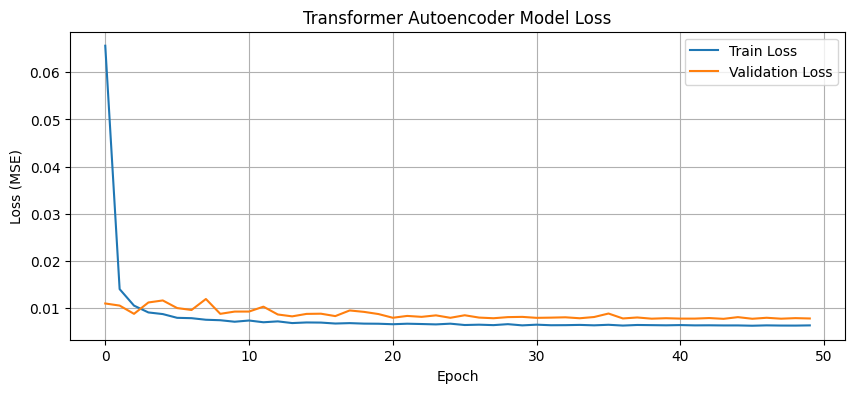


--- Extracting Embeddings using trained Transformer Encoder ---
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
466/466 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
train_embedding.shape: (56829, 2)
test_embedding.shape : (14895, 2)

--- Preparing Data for NN Classifier ---
Include Autoencoder Embeddings in NN Features: True
Combined Train Features (unscaled) shape: (56829, 21)
Combined Test Features (unscaled) shape: (14895, 21)
Scaling combined features for NN...
Scaled Train Features shape: (56829, 21)
Scaled Test Features shape: (14895, 21)

--- Defining Simple NN (MLP) Model ---

--- Simple NN (MLP) Model Summary ---


Model: "simple_nn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ nn_dense_1 (Dense)                                  │ (None, 32)                             │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ nn_dropout_1 (Dropout)                              │ (None, 32)                             │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ nn_dense_2 (Dense)                                  │ (None, 16)                             │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ nn_dropout_2 (Dropout)                              │ (None, 16)                             │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ nn_dense_3 (Dense)                                  │ (None, 4)                              │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ output_layer (Dense)                                │ (None, 1)                              │                   
└─────────────────────────────────────────────────────┴────────────────────────────────────────┴───────────────────

 Total params: 1,305 (5.10 KB)

 Trainable params: 1,305 (5.10 KB)

 Non-trainable params: 0 (0.00 B)


Calculating class weights for Keras...
Calculated Class Weights for Keras: {0: 0.5299334191238181, 1: 8.851869158878504}

--- Starting Simple NN (MLP) Training ---
Epoch 1/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - auc: 0.5276 - loss: 0.6877 - val_auc: 0.5738 - val_loss: 0.6714
Epoch 2/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.6046 - loss: 0.6302 - val_auc: 0.5749 - val_loss: 0.6598
Epoch 3/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.6360 - loss: 0.6224 - val_auc: 0.5731 - val_loss: 0.6399
Epoch 4/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.6801 - loss: 0.6019 - val_auc: 0.5796 - val_loss: 0.6397
Epoch 5/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.6731 - loss: 0.6045 - val_auc: 0.5899 - val_loss: 0.6217
Epoch 6/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.6964 - loss: 0.5943 - val_auc: 0.5920 - val_loss: 0.6080
Epoch 7/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.6921 - loss: 0.5930 - val_auc: 0.5900 - val_loss: 0.6157
Ep

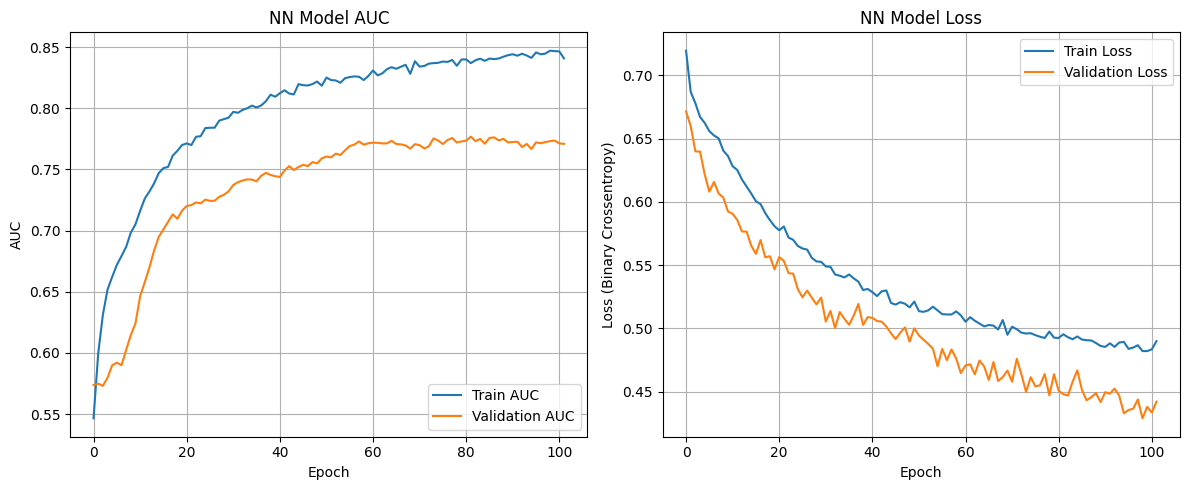


--- Evaluating NN Model ---
Predicting on training data (NN)...
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Predicting on test data (NN)...
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

[Simple NN (MLP) with Transformer AE Embeddings] Train AUC: 0.87163
[Simple NN (MLP) with Transformer AE Embeddings] Test  AUC: 0.77670


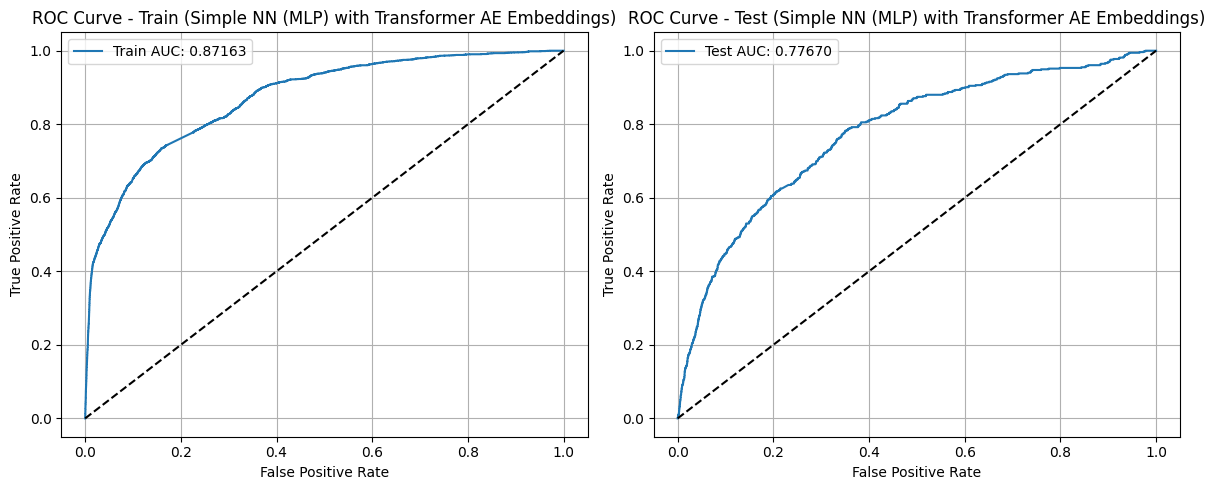

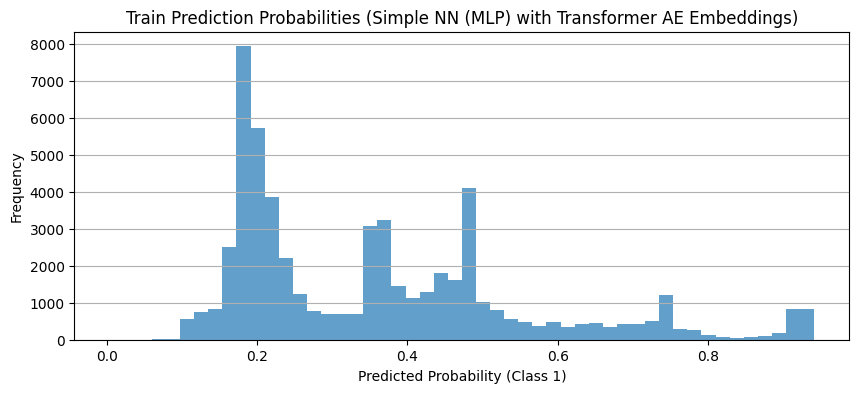

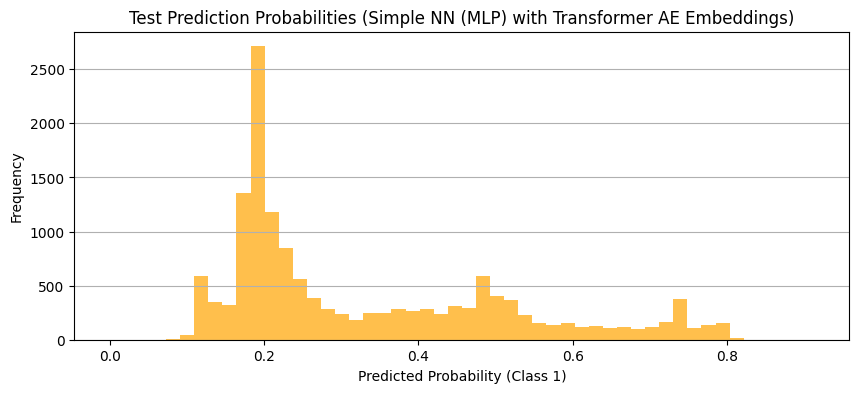

Script finished.


In [ ]:
import pandas as pd
import numpy as np
# Tensorflow / Keras Importsa
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential # Added Sequential for NN
# Transformer AE Layers (Keep these)
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D, TimeDistributed, Reshape, Embedding
# Standard NN Layers (Dense, Dropout already imported)
from tensorflow.keras.optimizers import Adam, AdamW # Keep AdamW for potential use, or stick to Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
# Remove CatBoost import
# from catboost import CatBoostClassifier
# Add class weight calculation utility
from sklearn.utils.class_weight import compute_class_weight


############################################################
# 1) 파일 로드 (변경 없음)
############################################################
# 경로를 실제 환경에 맞게 수정해야 합니다.
try:
    stock_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet')
    fin_df   = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_fin_result_with_vkospi_all.parquet')
    print("Successfully loaded data from Parquet files.")
except FileNotFoundError:
    print("Warning: Parquet files not found. Please ensure the path is correct or provide dummy data.")
    pass # Allow the script to continue, potentially failing later if files are truly missing.


############################################################
# 2) 날짜 전처리 (변경 없음)
############################################################
stock_df['BSOP_DATE'] = pd.to_datetime(stock_df['BSOP_DATE'], errors='coerce')
fin_df['BSOP_DATE']   = pd.to_datetime(fin_df['BSOP_DATE'],   errors='coerce')

# 코로나 기간 제외 + 2024-07-01 이전 데이터
stock_df = stock_df[(stock_df['BSOP_DATE'].dt.year != 2020) & (stock_df['BSOP_DATE'] < '2024-07-01')].copy()
fin_df   = fin_df[(fin_df['BSOP_DATE'].dt.year != 2020) & (fin_df['BSOP_DATE']   < '2024-07-01')].copy()

############################################################
# 3) ROE 결측치 제거 및 피처 생성 (변경 없음)
############################################################
mask_fin = fin_df.groupby('SHRN_ISCD')['ROE'].transform('count') > 0
fin_df = fin_df[mask_fin].copy()
valid_codes = fin_df['SHRN_ISCD'].unique()
stock_df = stock_df[stock_df['SHRN_ISCD'].isin(valid_codes)].copy()

print("Stock DF Columns:", stock_df.columns.tolist())

fin_df = fin_df.dropna(subset=['windowdrop']).copy()
fin_df['MONTH'] = fin_df['BSOP_DATE'].dt.month

fin_df.loc[:, 'PRICE_TO_52W_HIGH'] = fin_df['STCK_PRPR'] / fin_df['W52_HGPR']
fin_df.loc[:, 'PRICE_TO_52W_LOW'] = fin_df['STCK_PRPR'] / fin_df['W52_LWPR']
# Handle potential division by zero or large values before log/scaling later
fin_df.loc[:, 'PER'] = (fin_df['NET_INCOME'] / fin_df['MARKET_CAP']).replace([np.inf, -np.inf], 0)
fin_df.loc[:, 'PSR'] = (fin_df['PS'] / fin_df['STCK_PRPR']).replace([np.inf, -np.inf], 0)
fin_df.loc[:, 'FTRUTH'] = (fin_df['PS'] / fin_df['NET_INCOME']).replace([np.inf, -np.inf], 0)
fin_df.loc[:, 'NET_DEBT'] = (fin_df['NET_DEBT'] / fin_df['MARKET_CAP']).replace([np.inf, -np.inf], 0)
fin_df.loc[:, 'DEBT_COST'] = (fin_df['DEBT_COST'] / fin_df['MARKET_CAP']).replace([np.inf, -np.inf], 0)


le_scrt = LabelEncoder()
le_mrkt = LabelEncoder()
fin_df['SCRT_GRP_CLS_CODE'] = fin_df['SCRT_GRP_CLS_CODE'].astype(str)
fin_df['MRKT_DIV_CLS_CODE'] = fin_df['MRKT_DIV_CLS_CODE'].astype(str)
fin_df['SCRT_GRP_CLS_CODE'] = le_scrt.fit_transform(fin_df['SCRT_GRP_CLS_CODE'])
fin_df['MRKT_DIV_CLS_CODE'] = le_mrkt.fit_transform(fin_df['MRKT_DIV_CLS_CODE']) # Keep if MRKT_DIV_CLS_CODE is in fin_features

############################################################
# 4) 주요 설정값 (변경 없음)
############################################################
sequence_length = 60

stock_features = [
    'STCK_PRPR',
]
n_stock_features = len(stock_features)

fin_features = [
    'PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW',
    'SCRT_GRP_CLS_CODE', # Categorical - Will be treated as numerical by NN scaler unless handled differently
    # 'MRKT_DIV_CLS_CODE', # Categorical - Uncomment if used
    'MONTH', # Consider treating as categorical if using embeddings, otherwise scaler treats as numerical
    'VKOSPI',
    'FN_ACML_TR_PBMN',
    'ORGN_NTBY_QTY',
    'DR', 'PSR', 'ROE', 'ROE_INC',
    'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH',
    'F70', 'F71',
]
fin_features = [f for f in fin_features if f in fin_df.columns]
print("Using Fin Features:", fin_features)


############################################################
# 5) 시퀀스 데이터 생성 (변경 없음)
############################################################
stock_series_data  = []
stock_current_data = [] # Not used in NN input combination later, but kept for consistency
fin_series_data    = []
matched_targets    = []
dates              = []

stock_groups = stock_df.groupby('SHRN_ISCD')

# Handle potential NaN/Inf before loop
fin_df = fin_df.replace([np.inf, -np.inf], np.nan)
stock_df = stock_df.replace([np.inf, -np.inf], np.nan)
fin_df.fillna(0, inplace=True)
stock_df.fillna(0, inplace=True)

print("Starting sequence generation...")
processed_count = 0
skipped_short_seq = 0
skipped_no_today = 0

for stock_code, fin_group in fin_df.groupby('SHRN_ISCD'):
    if stock_code not in stock_groups.groups:
        continue
    stock_history_group = stock_groups.get_group(stock_code).sort_values('BSOP_DATE')

    if len(stock_history_group) < sequence_length:
        continue

    for row in fin_group.itertuples():
        date = row.BSOP_DATE

        end_index = stock_history_group['BSOP_DATE'].searchsorted(date, side='left')
        start_index = max(0, end_index - sequence_length)
        stock_history = stock_history_group.iloc[start_index:end_index]

        if len(stock_history) != sequence_length:
            skipped_short_seq += 1
            continue

        today_data_row = stock_history_group[stock_history_group['BSOP_DATE'] == date]
        if len(today_data_row) == 0:
            skipped_no_today += 1
            continue
        today_data = today_data_row[stock_features].iloc[0].values

        stock_series_data.append(stock_history[stock_features].values)
        stock_current_data.append(today_data)
        fin_series_data.append([getattr(row, f) for f in fin_features])
        matched_targets.append(row.windowdrop)
        dates.append(date)
        processed_count += 1

print(f"Finished sequence generation. Processed: {processed_count}, Skipped (short seq): {skipped_short_seq}, Skipped (no today data): {skipped_no_today}")

if not stock_series_data:
     raise ValueError("No sequences generated. Check data and preprocessing steps.")

stock_series_data  = np.array(stock_series_data)
stock_current_data = np.array(stock_current_data)
fin_series_data    = np.array(fin_series_data)
matched_targets    = np.array(matched_targets)
dates              = np.array(dates)

print("stock_series_data.shape :", stock_series_data.shape)
# print("stock_current_data.shape:", stock_current_data.shape) # Not directly used in final NN input
print("fin_series_data.shape   :", fin_series_data.shape)
print("matched_targets.shape :", matched_targets.shape)
print("dates.shape           :", dates.shape)


############################################################
# 6) Train/Test 분할 (변경 없음)
############################################################
train_mask = dates < pd.Timestamp('2023-01-01')
test_mask  = dates >= pd.Timestamp('2023-01-01')

if not np.any(train_mask) or not np.any(test_mask):
    raise ValueError(f"Data splitting error: Train samples={np.sum(train_mask)}, Test samples={np.sum(test_mask)}. Check date range and data.")

# AE data
X_stock_train_seq  = stock_series_data[train_mask]
X_stock_test_seq   = stock_series_data[test_mask]

# Financial data (for final NN)
X_fin_train = fin_series_data[train_mask]
X_fin_test  = fin_series_data[test_mask]

# Target variable
y_train = matched_targets[train_mask]
y_test  = matched_targets[test_mask]

# Current stock data (Not used later)
# X_stock_train_curr = stock_current_data[train_mask]
# X_stock_test_curr  = stock_current_data[test_mask]


print("Train size (AE & Final Target):", len(y_train))
print("Test size  (AE & Final Target):", len(y_test))
print("Train target distribution (Class 1):", np.mean(y_train))
print("Test target distribution  (Class 1):", np.mean(y_test))


############################################################
# 7) 데이터 정규화 (AE 시퀀스 데이터만 - 변경 없음)
############################################################
# (1) 펼침
n_train_samples, seq_len, n_features = X_stock_train_seq.shape
n_test_samples = X_stock_test_seq.shape[0]
if n_features != n_stock_features:
     raise ValueError(f"Feature count mismatch: X_stock_train_seq has {n_features} features, expected {n_stock_features}")
temp_train = X_stock_train_seq.reshape(-1, n_stock_features)
temp_test  = X_stock_test_seq.reshape(-1, n_stock_features)

# Ensure non-negativity for log1p
temp_train[temp_train < 0] = 0
temp_test[temp_test < 0] = 0

# (2) 로그 변환
temp_train_log = np.log1p(temp_train)
temp_test_log  = np.log1p(temp_test)
temp_train_log = np.nan_to_num(temp_train_log, nan=0.0, posinf=0.0, neginf=0.0)
temp_test_log = np.nan_to_num(temp_test_log, nan=0.0, posinf=0.0, neginf=0.0)

# (3) StandardScaler 적용
stock_scaler_seq = StandardScaler()
temp_train_scaled = stock_scaler_seq.fit_transform(temp_train_log)
temp_test_scaled  = stock_scaler_seq.transform(temp_test_log)
if np.isnan(temp_train_scaled).any() or np.isnan(temp_test_scaled).any():
    print("Warning: NaNs detected after AE sequence scaling.")
    temp_train_scaled = np.nan_to_num(temp_train_scaled)
    temp_test_scaled = np.nan_to_num(temp_test_scaled)

# (4) 복구
X_stock_train_seq_scaled = temp_train_scaled.reshape(n_train_samples, seq_len, n_features)
X_stock_test_seq_scaled  = temp_test_scaled.reshape(n_test_samples, seq_len, n_features)

print("Scaled AE train sequence shape:", X_stock_train_seq_scaled.shape)
print("Scaled AE test sequence shape:", X_stock_test_seq_scaled.shape)

# Note: Financial data (X_fin_train, X_fin_test) is NOT scaled here.
# It will be scaled AFTER combining with embeddings in Section 12.

############################################################
# 8) 오버샘플링 제거 (변경 없음)
############################################################
print("Skipping oversampling step.")


############################################################
# 시드 고정 (변경 없음)
############################################################
import random
import os
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
print(f"Set random seeds to {seed_value}")


#################################################################
# 9) Transformer 오토인코더 모델 정의 (변경 없음)
#################################################################
latent_dim = 2
d_model = 32
num_heads = 4
ff_dim = 64
num_transformer_blocks = 2
dropout_rate = 0.2

class PositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, maxlen, embed_dim):
        super(PositionEmbedding, self).__init__()
        # Ensure input_dim is at least 1, handle potential sequence_length=0 edge case
        self.pos_emb = Embedding(input_dim=max(1, maxlen), output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-2]
        # Handle case where maxlen might be 0 dynamically
        limit = tf.maximum(1, maxlen)
        positions = tf.range(start=0, limit=limit, delta=1)
        # Slice positions if maxlen was 0 initially but becomes > 0 due to batching/padding
        positions = self.pos_emb(positions)
        positions = positions[:maxlen, :] # Ensure correct shape if limit > maxlen
        return x + positions[tf.newaxis, :, :]


class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
         # Ensure key_dim is at least 1
        key_dim = max(1, embed_dim // num_heads)
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)
        self.ffn = tf.keras.Sequential(
            [Dense(ff_dim, activation="relu"), Dense(embed_dim),]
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

sequence_input = Input(shape=(sequence_length, n_stock_features), name='sequence_input')

x = Dense(d_model, activation='relu')(sequence_input)
pos_embed_layer = PositionEmbedding(sequence_length, d_model)
x = pos_embed_layer(x)

for _ in range(num_transformer_blocks):
    x = TransformerBlock(d_model, num_heads, ff_dim, dropout_rate)(x)

# Using Attention Pooling like before
attn_weights = tf.keras.layers.Dense(1)(x)               # (batch, seq_len, 1)
attn_weights = tf.keras.layers.Softmax(axis=1)(attn_weights)
x = tf.keras.layers.Lambda(lambda t: tf.reduce_sum(t[0] * t[1], axis=1))(
    [x, attn_weights]
)
encoder_output = Dense(latent_dim, activation='relu', name='embedding_layer')(x)

encoder_model = Model(inputs=sequence_input, outputs=encoder_output, name='transformer_encoder')

# Decoder part for Autoencoder
decoder_latent_input = Input(shape=(latent_dim,), name='decoder_latent_input') # Not directly used in AE model path
x = Dense(sequence_length * d_model, activation='relu')(encoder_output) # Use encoder output for AE
x = Reshape((sequence_length, d_model))(x)
x = pos_embed_layer(x) # Reuse positional embedding
for _ in range(num_transformer_blocks):
    x = TransformerBlock(d_model, num_heads, ff_dim, dropout_rate)(x)
decoder_output = TimeDistributed(Dense(n_stock_features, activation='linear'), name='decoder_output')(x)

autoencoder = Model(inputs=sequence_input, outputs=decoder_output, name='transformer_autoencoder')
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print("--- Transformer Autoencoder Model Summary ---")
autoencoder.summary(line_length=120)
print("\n--- Transformer Encoder Model Summary ---")
encoder_model.summary(line_length=120)


############################################################
# 10) 오토인코더 학습 (변경 없음)
############################################################
include_embeddings = True # Set to True to include embeddings

if include_embeddings:
  early_stop_ae = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, mode='min', verbose=1)

  print("\n--- Starting Transformer Autoencoder Training ---")
  history_ae = autoencoder.fit(
      X_stock_train_seq_scaled, X_stock_train_seq_scaled,
      epochs=50,
      batch_size=64,
      shuffle=True, # Set shuffle to True for better training dynamics
      validation_split=0.2,
      callbacks=[early_stop_ae],
      verbose=1 # Show progress
  )

  plt.figure(figsize=(10, 4))
  plt.plot(history_ae.history['loss'], label='Train Loss')
  plt.plot(history_ae.history['val_loss'], label='Validation Loss')
  plt.title('Transformer Autoencoder Model Loss')
  plt.ylabel('Loss (MSE)')
  plt.xlabel('Epoch')
  plt.legend(loc='upper right')
  plt.grid(True)
  plt.show()

  ############################################################
  # 11) 중간 임베딩 추출 (변경 없음)
  ############################################################
  print("\n--- Extracting Embeddings using trained Transformer Encoder ---")
  train_embedding = encoder_model.predict(X_stock_train_seq_scaled)
  test_embedding = encoder_model.predict(X_stock_test_seq_scaled)

  print("train_embedding.shape:", train_embedding.shape)
  print("test_embedding.shape :", test_embedding.shape)


############################################################
# 12) >>> MODIFICATION START: (임베딩 + 재무데이터) 결합 -> 스케일링 -> NN 모델 정의 및 학습 <<<
############################################################
print("\n--- Preparing Data for NN Classifier ---")

# -- Combine Features --
print(f"Include Autoencoder Embeddings in NN Features: {include_embeddings}")

if include_embeddings:
    train_features_unscaled = np.concatenate([
        train_embedding, # AE Embeddings
        X_fin_train      # Financial features (UNSCALED at this point)
    ], axis=1)
    test_features_unscaled = np.concatenate([
        test_embedding, # AE Embeddings
        X_fin_test       # Financial features (UNSCALED at this point)
    ], axis=1)
else:
    # Only use financial features if embeddings are excluded
    train_features_unscaled = X_fin_train
    test_features_unscaled = X_fin_test

print("Combined Train Features (unscaled) shape:", train_features_unscaled.shape)
print("Combined Test Features (unscaled) shape:", test_features_unscaled.shape)

# -- Scale Combined Features (CRUCIAL FOR NN) --
print("Scaling combined features for NN...")
combined_scaler = StandardScaler()
train_features_scaled = combined_scaler.fit_transform(train_features_unscaled)
test_features_scaled = combined_scaler.transform(test_features_unscaled)

# Handle potential NaNs after scaling combined features
if np.isnan(train_features_scaled).any() or np.isnan(test_features_scaled).any():
    print("Warning: NaNs detected after scaling combined features. Filling with 0.")
    train_features_scaled = np.nan_to_num(train_features_scaled, nan=0.0)
    test_features_scaled = np.nan_to_num(test_features_scaled, nan=0.0)

print("Scaled Train Features shape:", train_features_scaled.shape)
print("Scaled Test Features shape:", test_features_scaled.shape)


# -- Define Simple NN (MLP) Model ---
print("\n--- Defining Simple NN (MLP) Model ---")
nn_input_dim = train_features_scaled.shape[1]

nn_model = Sequential([
    Input(shape=(nn_input_dim,), name='combined_input'),
    Dense(32, activation='relu', name='nn_dense_1'),
    Dropout(0.5, name='nn_dropout_1'), # Increased dropout slightly
    Dense(16, activation='relu', name='nn_dense_2'),
    Dropout(0.5, name='nn_dropout_2'), # Increased dropout slightly
    Dense(4, activation='relu', name='nn_dense_3'),
    # Removed dropout before final layer based on common practice
    Dense(1, activation='sigmoid', name='output_layer') # Sigmoid for binary classification
], name='simple_nn_classifier')

# --- Compile NN Model ---
nn_model.compile(
    optimizer=Adam(learning_rate=0.0005), # Slightly adjusted learning rate
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')] # Use AUC metric
)

print("\n--- Simple NN (MLP) Model Summary ---")
nn_model.summary(line_length=120)


# --- Calculate Class Weights for Keras ---
print("\nCalculating class weights for Keras...")
unique_classes = np.unique(y_train)
class_weights_array = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train)
# Keras expects a dictionary mapping class indices (0 and 1) to weights
class_weights = dict(zip(unique_classes, class_weights_array))
print(f"Calculated Class Weights for Keras: {class_weights}")


# --- Train NN Model ---
print("\n--- Starting Simple NN (MLP) Training ---")
early_stop_nn = EarlyStopping(
    monitor='val_auc', # Monitor validation AUC
    patience=20,       # Increased patience
    mode='max',        # Maximize AUC
    restore_best_weights=True,
    verbose=1
)

history_nn = nn_model.fit(
    train_features_scaled, y_train,
    validation_data=(test_features_scaled, y_test),
    epochs=150,         # Increased epochs, early stopping will handle duration
    batch_size=128,     # Adjusted batch size
    shuffle=False,       # Shuffle training data each epoch
    callbacks=[early_stop_nn],
    class_weight=class_weights, # Apply class weights
    verbose=1           # Show progress
)

# --- Plot NN Training History ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_nn.history['auc'], label='Train AUC')
plt.plot(history_nn.history['val_auc'], label='Validation AUC')
plt.title('NN Model AUC')
plt.ylabel('AUC')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_nn.history['loss'], label='Train Loss')
plt.plot(history_nn.history['val_loss'], label='Validation Loss')
plt.title('NN Model Loss')
plt.ylabel('Loss (Binary Crossentropy)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

############################################################
# 12) >>> MODIFICATION END <<<
############################################################


############################################################
# 13) >>> MODIFICATION START: 최종 평가 (NN 모델 사용) <<<
############################################################
print("\n--- Evaluating NN Model ---")

# --- Get Predictions from NN Model ---
# Use the SCALED features for prediction
print("Predicting on training data (NN)...")
pred_train_proba = nn_model.predict(train_features_scaled).squeeze()
print("Predicting on test data (NN)...")
pred_test_proba  = nn_model.predict(test_features_scaled).squeeze()

# Ensure probabilities are within [0, 1] range after potential squeezing/activation
pred_train_proba = np.clip(pred_train_proba, 0.0, 1.0)
pred_test_proba = np.clip(pred_test_proba, 0.0, 1.0)


# --- Calculate AUC Scores ---
roc_auc_train = roc_auc_score(y_train, pred_train_proba)
roc_auc_test  = roc_auc_score(y_test, pred_test_proba)

# Determine title based on whether embeddings were used
ae_status = "with Transformer AE Embeddings" if include_embeddings else "without AE Embeddings"
model_name = "Simple NN (MLP)" # Updated model name
print(f'\n[{model_name} {ae_status}] Train AUC: {roc_auc_train:.5f}')
print(f'[{model_name} {ae_status}] Test  AUC: {roc_auc_test:.5f}')

# --- ROC Curve 시각화 ---
fpr_train, tpr_train, _ = roc_curve(y_train, pred_train_proba)
fpr_test,  tpr_test,  _ = roc_curve(y_test, pred_test_proba)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_train, tpr_train, label=f'Train AUC: {roc_auc_train:.5f}')
plt.plot([0,1],[0,1],'k--')
plt.title(f'ROC Curve - Train ({model_name} {ae_status})') # Updated title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(fpr_test, tpr_test, label=f'Test AUC: {roc_auc_test:.5f}')
plt.plot([0,1],[0,1],'k--')
plt.title(f'ROC Curve - Test ({model_name} {ae_status})') # Updated title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- 예측 확률 히스토그램 ---
plt.figure(figsize=(10, 4))
plt.hist(pred_train_proba, bins=50, alpha=0.7)
plt.title(f'Train Prediction Probabilities ({model_name} {ae_status})') # Updated title
plt.xlabel('Predicted Probability (Class 1)')
plt.ylabel('Frequency')
plt.grid(True, axis='y')
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(pred_test_proba, bins=50, alpha=0.7, color='orange')
plt.title(f'Test Prediction Probabilities ({model_name} {ae_status})') # Updated title
plt.xlabel('Predicted Probability (Class 1)')
plt.ylabel('Frequency')
plt.grid(True, axis='y')
plt.show()

############################################################
# 13) >>> MODIFICATION END <<<
############################################################

print("Script finished.")

### lstm

Successfully loaded data from Parquet files.
Stock DF Columns: ['BSOP_DATE', 'STND_ISCD', 'SHRN_ISCD', 'SCRT_GRP_CLS_CODE', 'MRKT_DIV_CLS_CODE', 'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR', 'FN_ACML_TR_PBMN', 'CRDT_RMND_RATE', 'MARKET_CAP', 'FRGN_HLDN_RATE', 'FRGN_NTBY_QTY', 'ORGN_NTBY_QTY', 'vkospi', 'ks200', 'fx']
Using Fin Features: ['PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW', 'SCRT_GRP_CLS_CODE', 'MONTH', 'VKOSPI', 'FN_ACML_TR_PBMN', 'ORGN_NTBY_QTY', 'DR', 'PSR', 'ROE', 'ROE_INC', 'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH', 'F70', 'F71']
Starting sequence generation...
Finished sequence generation. Processed: 71724, Skipped (short seq): 2816, Skipped (no today data): 0
stock_series_data.shape : (71724, 60, 1)
fin_series_data.shape   : (71724, 19)
matched_targets.shape : (71724,)
dates.shape           : (71724,)
Train size (AE & Final Target): 56829
Test size  (AE & Final Target): 14895
Train target distribution (Class 1): 0.05648524520931215
Test target dis

Model: "transformer_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ sequence_input (InputLayer)       │ (None, 60, 1)                │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dense_315 (Dense)                 │ (None, 60, 32)               │                64 │ sequence_input[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ position_embedding_28             │ (None, 60, 32)               │             1,920 │ dense_315[0][0],          
│ (PositionEmbedding)               │                              │                   │ reshape_30[0][0]          
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ transformer_block_96              │ (None, 60, 32)               │             8,544 │ position_embedding_28[0][0
│ (TransformerBlock)                │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ transformer_block_97              │ (None, 60, 32)               │             8,544 │ transformer_block_96[0][0]
│ (TransformerBlock)                │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dense_320 (Dense)                 │ (None, 60, 1)                │                33 │ transformer_block_97[0][0]
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ softmax_140 (Softmax)             │ (None, 60, 1)                │                 0 │ dense_320[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lambda_24 (Lambda)                │ (None, 32)                   │                 0 │ transformer_block_97[0][0]
│                                   │                              │                   │ softmax_140[0][0]         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_layer (Dense)           │ (None, 5)                    │               165 │ lambda_24[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dense_321 (Dense)                 │ (None, 1920)                 │            11,520 │ embedding_layer[0][0]     
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ reshape_30 (Reshape)              │ (None, 60, 32)               │                 0 │ dense_321[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ transformer_block_98              │ (None, 60, 32)               │             8,544 │ position_embedding_28[1][0
│ (TransformerBlock)                │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ transformer_block_99              │ (None, 60, 32)               │             8,544 │ transformer_block_98[0][0]
│ (TransformerBlock)                │                              │                   │                           
├───────────────────────────────────┼───────────────────

 Total params: 47,911 (187.15 KB)

 Trainable params: 47,911 (187.15 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ sequence_input (InputLayer)       │ (None, 60, 1)                │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dense_315 (Dense)                 │ (None, 60, 32)               │                64 │ sequence_input[0][0]      
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ position_embedding_28             │ (None, 60, 32)               │             1,920 │ dense_315[0][0]           
│ (PositionEmbedding)               │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ transformer_block_96              │ (None, 60, 32)               │             8,544 │ position_embedding_28[0][0
│ (TransformerBlock)                │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ transformer_block_97              │ (None, 60, 32)               │             8,544 │ transformer_block_96[0][0]
│ (TransformerBlock)                │                              │                   │                           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ dense_320 (Dense)                 │ (None, 60, 1)                │                33 │ transformer_block_97[0][0]
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ softmax_140 (Softmax)             │ (None, 60, 1)                │                 0 │ dense_320[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ lambda_24 (Lambda)                │ (None, 32)                   │                 0 │ transformer_block_97[0][0]
│                                   │                              │                   │ softmax_140[0][0]         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ embedding_layer (Dense)           │ (None, 5)                    │               165 │ lambda_24[0][0]           
└───────────────────────────────────┴──────────────────────────────┴───────────────────┴───────────────────────────

 Total params: 19,270 (75.27 KB)

 Trainable params: 19,270 (75.27 KB)

 Non-trainable params: 0 (0.00 B)


--- Starting Transformer Autoencoder Training ---
Epoch 1/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 60s 44ms/step - loss: 0.2227 - val_loss: 0.0110
Epoch 2/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0173 - val_loss: 0.0094
Epoch 3/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0113 - val_loss: 0.0104
Epoch 4/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0094 - val_loss: 0.0101
Epoch 5/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0083 - val_loss: 0.0084
Epoch 6/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0079 - val_loss: 0.0094
Epoch 7/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0076 - val_loss: 0.0082
Epoch 8/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0073 - val_loss: 0.0088
Epoch 9/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0071 - val_loss: 0.0092
Epoch 10/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0069 - val_loss: 0.0086
Epoch 11/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0070 - val_loss: 0.0082

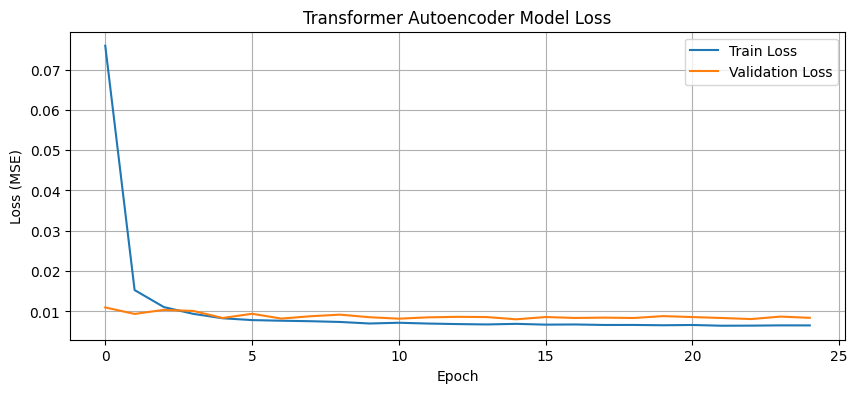


--- Extracting Embeddings using trained Transformer Encoder ---
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
train_embedding.shape: (56829, 5)
test_embedding.shape : (14895, 5)

--- Preparing Data for Final Classifier ---
Include Autoencoder Embeddings in Final Classifier Features: True
Combined Train Features (unscaled) shape: (56829, 24)
Combined Test Features (unscaled) shape: (14895, 24)
Scaling combined features...
Scaled Train Features shape: (56829, 24)
Scaled Test Features shape: (14895, 24)
Reshaped Train Features for LSTM shape: (56829, 1, 24)
Reshaped Test Features for LSTM shape: (14895, 1, 24)

--- Defining LSTM Model ---

--- LSTM Model Summary ---


Model: "lstm_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ lstm_layer_1 (LSTM)                                 │ (None, 1, 64)                          │                22,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ lstm_dropout_1 (Dropout)                            │ (None, 1, 64)                          │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ lstm_layer_2 (LSTM)                                 │ (None, 16)                             │                 5,
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ lstm_dropout_2 (Dropout)                            │ (None, 16)                             │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ output_layer (Dense)                                │ (None, 1)                              │                   
└─────────────────────────────────────────────────────┴────────────────────────────────────────┴───────────────────

 Total params: 27,985 (109.32 KB)

 Trainable params: 27,985 (109.32 KB)

 Non-trainable params: 0 (0.00 B)


Calculating class weights for Keras...
Calculated Class Weights for Keras: {0: 0.5299334191238181, 1: 8.851869158878504}

--- Starting LSTM Model Training ---
Epoch 1/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - auc: 0.6450 - loss: 0.6138 - val_auc: 0.5806 - val_loss: 0.6802
Epoch 2/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.7298 - loss: 0.5731 - val_auc: 0.6161 - val_loss: 0.6291
Epoch 3/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.7484 - loss: 0.5547 - val_auc: 0.6442 - val_loss: 0.6097
Epoch 4/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.7616 - loss: 0.5422 - val_auc: 0.6684 - val_loss: 0.6036
Epoch 5/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.7776 - loss: 0.5293 - val_auc: 0.6864 - val_loss: 0.5993
Epoch 6/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.7865 - loss: 0.5209 - val_auc: 0.6994 - val_loss: 0.5908
Epoch 7/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - auc: 0.7987 - loss: 0.5083 - val_auc: 0.7080 - val_loss: 0.5903
Epoch 8

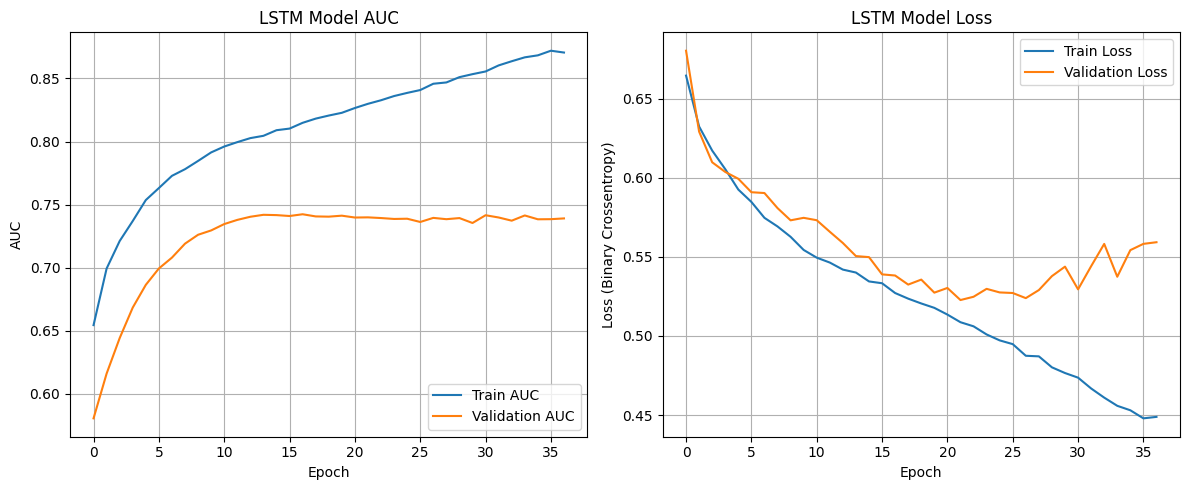


--- Evaluating LSTM Model ---
Predicting on training data (LSTM)...
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Predicting on test data (LSTM)...
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

[LSTM Classifier with Transformer AE Embeddings] Train AUC: 0.82661
[LSTM Classifier with Transformer AE Embeddings] Test  AUC: 0.74240


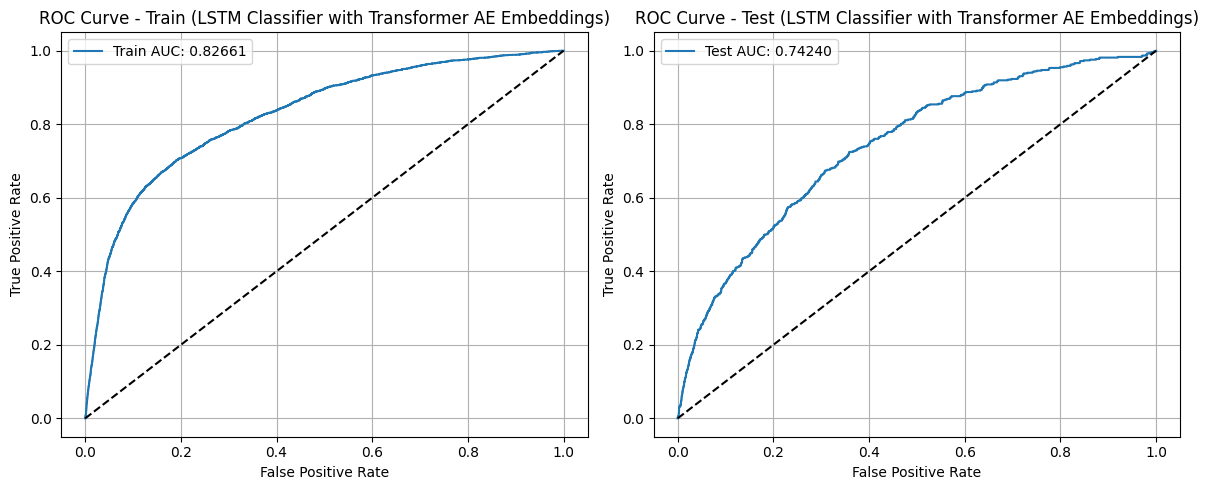

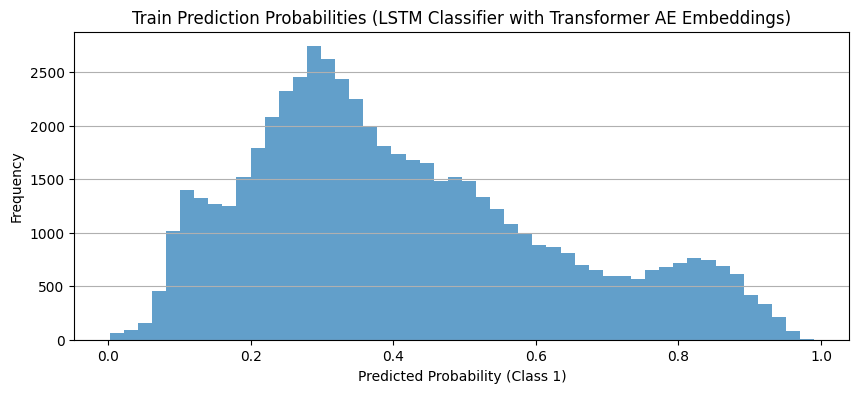

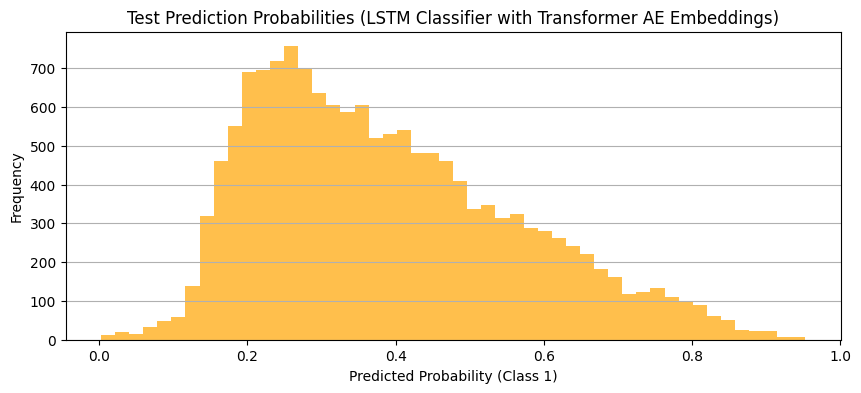

Script finished.


In [ ]:
# 전체 라인 수: 약 618 라인 (수정으로 약간 변경됨)
# 수정 시작 라인: 8 (import 추가), 445 (Section 12 시작), 528 (Section 13 시작)
# 수정 종료 라인: 8 (import 추가), 525 (Section 12 끝), 609 (Section 13 끝)

import pandas as pd
import numpy as np
# Tensorflow / Keras Imports
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential # Added Sequential for NN
# Transformer AE Layers (Keep these)
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D, TimeDistributed, Reshape, Embedding
from tensorflow.keras.layers import LSTM # <--- [수정 1] LSTM 레이어 import 추가 (약 8 라인)
# Standard NN Layers (Dense, Dropout already imported)
from tensorflow.keras.optimizers import Adam, AdamW # Keep AdamW for potential use, or stick to Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
# Remove CatBoost import
# from catboost import CatBoostClassifier
# Add class weight calculation utility
from sklearn.utils.class_weight import compute_class_weight
import random # For seeding
import os # For seeding


############################################################
# 1) 파일 로드 (변경 없음)
############################################################
# 경로를 실제 환경에 맞게 수정해야 합니다.
# Colab 경로 예시 (필요시 로컬 경로로 변경)
drive_path = '/content/drive/MyDrive/Colab Notebooks/hana_stock/' # 경로 예시
try:
    stock_df = pd.read_parquet(f'{drive_path}data_stock/stock_all_vkospi.parquet')
    fin_df   = pd.read_parquet(f'{drive_path}data_stock/stock_fin_result_with_vkospi_all.parquet')
    print("Successfully loaded data from Parquet files.")
except FileNotFoundError:
    print("Warning: Parquet files not found. Please ensure the path is correct or provide dummy data.")
    pass # Allow the script to continue, potentially failing later if files are truly missing.


############################################################
# 2) 날짜 전처리 (변경 없음)
############################################################
stock_df['BSOP_DATE'] = pd.to_datetime(stock_df['BSOP_DATE'], errors='coerce')
fin_df['BSOP_DATE']   = pd.to_datetime(fin_df['BSOP_DATE'],   errors='coerce')

# 코로나 기간 제외 + 2024-07-01 이전 데이터
stock_df = stock_df[(stock_df['BSOP_DATE'].dt.year != 2020) & (stock_df['BSOP_DATE'] < '2024-07-01')].copy()
fin_df   = fin_df[(fin_df['BSOP_DATE'].dt.year != 2020) & (fin_df['BSOP_DATE']   < '2024-07-01')].copy()

############################################################
# 3) ROE 결측치 제거 및 피처 생성 (변경 없음)
############################################################
mask_fin = fin_df.groupby('SHRN_ISCD')['ROE'].transform('count') > 0
fin_df = fin_df[mask_fin].copy()
valid_codes = fin_df['SHRN_ISCD'].unique()
stock_df = stock_df[stock_df['SHRN_ISCD'].isin(valid_codes)].copy()

print("Stock DF Columns:", stock_df.columns.tolist())

fin_df = fin_df.dropna(subset=['windowdrop']).copy()
fin_df['MONTH'] = fin_df['BSOP_DATE'].dt.month

fin_df.loc[:, 'PRICE_TO_52W_HIGH'] = fin_df['STCK_PRPR'] / fin_df['W52_HGPR']
fin_df.loc[:, 'PRICE_TO_52W_LOW'] = fin_df['STCK_PRPR'] / fin_df['W52_LWPR']
# Handle potential division by zero or large values before log/scaling later
fin_df.loc[:, 'PER'] = (fin_df['NET_INCOME'] / fin_df['MARKET_CAP']).replace([np.inf, -np.inf], 0)
fin_df.loc[:, 'PSR'] = (fin_df['PS'] / fin_df['STCK_PRPR']).replace([np.inf, -np.inf], 0)
fin_df.loc[:, 'FTRUTH'] = (fin_df['PS'] / fin_df['NET_INCOME']).replace([np.inf, -np.inf], 0)
fin_df.loc[:, 'NET_DEBT'] = (fin_df['NET_DEBT'] / fin_df['MARKET_CAP']).replace([np.inf, -np.inf], 0)
fin_df.loc[:, 'DEBT_COST'] = (fin_df['DEBT_COST'] / fin_df['MARKET_CAP']).replace([np.inf, -np.inf], 0)


le_scrt = LabelEncoder()
le_mrkt = LabelEncoder()
fin_df['SCRT_GRP_CLS_CODE'] = fin_df['SCRT_GRP_CLS_CODE'].astype(str)
fin_df['MRKT_DIV_CLS_CODE'] = fin_df['MRKT_DIV_CLS_CODE'].astype(str)
fin_df['SCRT_GRP_CLS_CODE'] = le_scrt.fit_transform(fin_df['SCRT_GRP_CLS_CODE'])
fin_df['MRKT_DIV_CLS_CODE'] = le_mrkt.fit_transform(fin_df['MRKT_DIV_CLS_CODE']) # Keep if MRKT_DIV_CLS_CODE is in fin_features

############################################################
# 4) 주요 설정값 (변경 없음)
############################################################
sequence_length = 60

stock_features = [
    'STCK_PRPR',
]
n_stock_features = len(stock_features)

fin_features = [
    'PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW',
    'SCRT_GRP_CLS_CODE', # Categorical - Will be treated as numerical by NN scaler unless handled differently
    # 'MRKT_DIV_CLS_CODE', # Categorical - Uncomment if used
    'MONTH', # Consider treating as categorical if using embeddings, otherwise scaler treats as numerical
    'VKOSPI',
    'FN_ACML_TR_PBMN',
    'ORGN_NTBY_QTY',
    'DR', 'PSR', 'ROE', 'ROE_INC',
    'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH',
    'F70', 'F71',
]
fin_features = [f for f in fin_features if f in fin_df.columns]
print("Using Fin Features:", fin_features)


############################################################
# 5) 시퀀스 데이터 생성 (변경 없음 - 사용자 요청)
############################################################
stock_series_data   = []
stock_current_data = [] # Not used in NN input combination later, but kept for consistency
fin_series_data     = []
matched_targets     = []
dates               = []

stock_groups = stock_df.groupby('SHRN_ISCD')

# Handle potential NaN/Inf before loop
fin_df = fin_df.replace([np.inf, -np.inf], np.nan)
stock_df = stock_df.replace([np.inf, -np.inf], np.nan)
fin_df.fillna(0, inplace=True)
stock_df.fillna(0, inplace=True)

print("Starting sequence generation...")
processed_count = 0
skipped_short_seq = 0
skipped_no_today = 0

for stock_code, fin_group in fin_df.groupby('SHRN_ISCD'):
    if stock_code not in stock_groups.groups:
        continue
    stock_history_group = stock_groups.get_group(stock_code).sort_values('BSOP_DATE')

    if len(stock_history_group) < sequence_length:
        continue

    for row in fin_group.itertuples():
        date = row.BSOP_DATE

        # 사용자의 코드 원본 유지 (pandas searchsorted 아님)
        end_index = stock_history_group['BSOP_DATE'].searchsorted(date, side='left')
        start_index = max(0, end_index - sequence_length)
        stock_history = stock_history_group.iloc[start_index:end_index]

        if len(stock_history) != sequence_length:
            skipped_short_seq += 1
            continue

        today_data_row = stock_history_group[stock_history_group['BSOP_DATE'] == date]
        if len(today_data_row) == 0:
            skipped_no_today += 1
            continue
        today_data = today_data_row[stock_features].iloc[0].values

        stock_series_data.append(stock_history[stock_features].values)
        stock_current_data.append(today_data)
        fin_series_data.append([getattr(row, f) for f in fin_features])
        matched_targets.append(row.windowdrop)
        dates.append(date)
        processed_count += 1

print(f"Finished sequence generation. Processed: {processed_count}, Skipped (short seq): {skipped_short_seq}, Skipped (no today data): {skipped_no_today}")

if not stock_series_data:
     raise ValueError("No sequences generated. Check data and preprocessing steps.")

stock_series_data   = np.array(stock_series_data)
stock_current_data = np.array(stock_current_data)
fin_series_data     = np.array(fin_series_data)
matched_targets     = np.array(matched_targets)
dates               = np.array(dates)

print("stock_series_data.shape :", stock_series_data.shape)
# print("stock_current_data.shape:", stock_current_data.shape) # Not directly used in final NN input
print("fin_series_data.shape   :", fin_series_data.shape)
print("matched_targets.shape :", matched_targets.shape)
print("dates.shape           :", dates.shape)


############################################################
# 6) Train/Test 분할 (변경 없음)
############################################################
train_mask = dates < pd.Timestamp('2023-01-01')
test_mask  = dates >= pd.Timestamp('2023-01-01')

if not np.any(train_mask) or not np.any(test_mask):
    raise ValueError(f"Data splitting error: Train samples={np.sum(train_mask)}, Test samples={np.sum(test_mask)}. Check date range and data.")

# AE data
X_stock_train_seq  = stock_series_data[train_mask]
X_stock_test_seq   = stock_series_data[test_mask]

# Financial data (for final NN)
X_fin_train = fin_series_data[train_mask]
X_fin_test  = fin_series_data[test_mask]

# Target variable
y_train = matched_targets[train_mask]
y_test  = matched_targets[test_mask]

# Current stock data (Not used later)
# X_stock_train_curr = stock_current_data[train_mask]
# X_stock_test_curr  = stock_current_data[test_mask]


print("Train size (AE & Final Target):", len(y_train))
print("Test size  (AE & Final Target):", len(y_test))
print("Train target distribution (Class 1):", np.mean(y_train))
print("Test target distribution  (Class 1):", np.mean(y_test))


############################################################
# 7) 데이터 정규화 (AE 시퀀스 데이터만 - 변경 없음)
############################################################
# (1) 펼침
# Check if train data exists
if X_stock_train_seq.shape[0] == 0:
     print("Warning: Training AE data is empty. Skipping scaling.")
     X_stock_train_seq_scaled = np.empty((0, sequence_length, n_stock_features))
     X_stock_test_seq_scaled = np.empty((X_stock_test_seq.shape[0], sequence_length, n_stock_features)) # Keep test shape but empty scaled version
else:
    n_train_samples, seq_len, n_features = X_stock_train_seq.shape
    n_test_samples = X_stock_test_seq.shape[0] if X_stock_test_seq.ndim == 3 else 0 # Check dimension before accessing shape[0]
    if n_features != n_stock_features:
        raise ValueError(f"Feature count mismatch: X_stock_train_seq has {n_features} features, expected {n_stock_features}")
    temp_train = X_stock_train_seq.reshape(-1, n_stock_features)

    # Handle potentially empty test set during reshape
    temp_test = X_stock_test_seq.reshape(-1, n_stock_features) if n_test_samples > 0 else np.empty((0, n_stock_features))

    # Ensure non-negativity for log1p
    temp_train[temp_train < 0] = 0
    if n_test_samples > 0: temp_test[temp_test < 0] = 0

    # (2) 로그 변환
    temp_train_log = np.log1p(temp_train)
    temp_train_log = np.nan_to_num(temp_train_log, nan=0.0, posinf=0.0, neginf=0.0)
    temp_test_log = np.log1p(temp_test) if n_test_samples > 0 else np.empty((0, n_stock_features))
    temp_test_log = np.nan_to_num(temp_test_log, nan=0.0, posinf=0.0, neginf=0.0)


    # (3) StandardScaler 적용
    stock_scaler_seq = StandardScaler()
    temp_train_scaled = stock_scaler_seq.fit_transform(temp_train_log)

    if n_test_samples > 0:
        temp_test_scaled  = stock_scaler_seq.transform(temp_test_log)
    else:
        temp_test_scaled = np.empty((0, n_stock_features))

    if np.isnan(temp_train_scaled).any() or np.isnan(temp_test_scaled).any():
        print("Warning: NaNs detected after AE sequence scaling.")
        temp_train_scaled = np.nan_to_num(temp_train_scaled)
        temp_test_scaled = np.nan_to_num(temp_test_scaled)

    # (4) 복구
    X_stock_train_seq_scaled = temp_train_scaled.reshape(n_train_samples, seq_len, n_features)
    X_stock_test_seq_scaled  = temp_test_scaled.reshape(n_test_samples, seq_len, n_features) if n_test_samples > 0 else np.empty((0, seq_len, n_features))

print("Scaled AE train sequence shape:", X_stock_train_seq_scaled.shape)
print("Scaled AE test sequence shape:", X_stock_test_seq_scaled.shape)

# Note: Financial data (X_fin_train, X_fin_test) is NOT scaled here.
# It will be scaled AFTER combining with embeddings in Section 12.

############################################################
# 8) 오버샘플링 제거 (변경 없음)
############################################################
print("Skipping oversampling step.")


############################################################
# 시드 고정 (변경 없음)
############################################################
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
print(f"Set random seeds to {seed_value}")


#################################################################
# 9) Transformer 오토인코더 모델 정의 (변경 없음)
#################################################################
latent_dim = 5
d_model = 32
num_heads = 4
ff_dim = 64
num_transformer_blocks = 2
dropout_rate = 0.2

class PositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, maxlen, embed_dim):
        super(PositionEmbedding, self).__init__()
        # Ensure input_dim is at least 1, handle potential sequence_length=0 edge case
        self.pos_emb = Embedding(input_dim=max(1, maxlen), output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-2]
        # Handle case where maxlen might be 0 dynamically
        limit = tf.maximum(1, maxlen)
        positions = tf.range(start=0, limit=limit, delta=1)
        # Slice positions if maxlen was 0 initially but becomes > 0 due to batching/padding
        positions_embedded = self.pos_emb(positions) # Renamed variable
        positions_embedded = positions_embedded[:maxlen, :] # Ensure correct shape if limit > maxlen
        return x + positions_embedded[tf.newaxis, :, :]


class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()
         # Ensure key_dim is at least 1
        key_dim = max(1, embed_dim // num_heads)
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=key_dim)
        self.ffn = tf.keras.Sequential(
            [Dense(ff_dim, activation="relu"), Dense(embed_dim),]
        )
        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(rate)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

sequence_input = Input(shape=(sequence_length, n_stock_features), name='sequence_input')

x = Dense(d_model, activation='relu')(sequence_input)
pos_embed_layer = PositionEmbedding(sequence_length, d_model)
x = pos_embed_layer(x)

for _ in range(num_transformer_blocks):
    x = TransformerBlock(d_model, num_heads, ff_dim, dropout_rate)(x)

# Using Attention Pooling like before
attn_weights = tf.keras.layers.Dense(1)(x)           # (batch, seq_len, 1)
attn_weights = tf.keras.layers.Softmax(axis=1)(attn_weights)
x = tf.keras.layers.Lambda(lambda t: tf.reduce_sum(t[0] * t[1], axis=1))(
    [x, attn_weights]
)
encoder_output = Dense(latent_dim, activation='relu', name='embedding_layer')(x)

encoder_model = Model(inputs=sequence_input, outputs=encoder_output, name='transformer_encoder')

# Decoder part for Autoencoder
decoder_latent_input = Input(shape=(latent_dim,), name='decoder_latent_input') # Not directly used in AE model path
x_dec = Dense(sequence_length * d_model, activation='relu')(encoder_output) # Use encoder output for AE - renamed internal var
x_dec = Reshape((sequence_length, d_model))(x_dec)
x_dec = pos_embed_layer(x_dec) # Reuse positional embedding
for _ in range(num_transformer_blocks):
    x_dec = TransformerBlock(d_model, num_heads, ff_dim, dropout_rate)(x_dec)
decoder_output = TimeDistributed(Dense(n_stock_features, activation='linear'), name='decoder_output')(x_dec)

autoencoder = Model(inputs=sequence_input, outputs=decoder_output, name='transformer_autoencoder')
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print("--- Transformer Autoencoder Model Summary ---")
autoencoder.summary(line_length=120)
print("\n--- Transformer Encoder Model Summary ---")
encoder_model.summary(line_length=120)


############################################################
# 10) 오토인코더 학습 (변경 없음)
############################################################
early_stop_ae = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, mode='min', verbose=1)

print("\n--- Starting Transformer Autoencoder Training ---")
# Check if data exists before fitting
if X_stock_train_seq_scaled.shape[0] > 0:
    history_ae = autoencoder.fit(
        X_stock_train_seq_scaled, X_stock_train_seq_scaled,
        epochs=50,
        batch_size=64,
        shuffle=True, # Set shuffle to True for better training dynamics
        validation_split=0.2,
        callbacks=[early_stop_ae],
        verbose=1 # Show progress
    )

    plt.figure(figsize=(10, 4))
    plt.plot(history_ae.history['loss'], label='Train Loss')
    plt.plot(history_ae.history['val_loss'], label='Validation Loss')
    plt.title('Transformer Autoencoder Model Loss')
    plt.ylabel('Loss (MSE)')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()
else:
    print("Skipping Autoencoder training and plotting: No scaled training data.")
    history_ae = None # Keep track that training didn't happen


############################################################
# 11) 중간 임베딩 추출 (변경 없음)
############################################################
print("\n--- Extracting Embeddings using trained Transformer Encoder ---")
# Check if model was trained and data exists
if history_ae is not None and X_stock_train_seq_scaled.shape[0] > 0:
    train_embedding = encoder_model.predict(X_stock_train_seq_scaled)
else:
    train_embedding = np.empty((0, latent_dim)) # Create empty embedding array

if history_ae is not None and X_stock_test_seq_scaled.shape[0] > 0:
    test_embedding = encoder_model.predict(X_stock_test_seq_scaled)
else:
    test_embedding = np.empty((0, latent_dim)) # Create empty embedding array

print("train_embedding.shape:", train_embedding.shape)
print("test_embedding.shape :", test_embedding.shape)


# ============================================================
# ==================== MODIFICATION BLOCK 1 START ====================
# ============================================================
# 수정 시작 라인: 약 445
############################################################
# 12) >>> MODIFICATION START: (임베딩 + 재무데이터) 결합 -> 스케일링 -> **LSTM** 모델 정의 및 학습 <<<
############################################################
print("\n--- Preparing Data for Final Classifier ---") # 이름 변경: NN -> Final

# -- Combine Features -- (변경 없음)
include_embeddings = True # Set to True to include embeddings
print(f"Include Autoencoder Embeddings in Final Classifier Features: {include_embeddings}")

if include_embeddings:
    # Handle cases where embeddings or financial data might be empty
    if train_embedding.shape[0] > 0 and X_fin_train.shape[0] > 0:
         if train_embedding.shape[0] == X_fin_train.shape[0]:
            train_features_unscaled = np.concatenate([train_embedding, X_fin_train], axis=1)
         else: # Mismatch case - prioritize embedding if exists
            print(f"Warning: Train sample mismatch ({train_embedding.shape[0]} vs {X_fin_train.shape[0]}). Using only embeddings.")
            train_features_unscaled = train_embedding
    elif train_embedding.shape[0] > 0: # Only embeddings exist
        train_features_unscaled = train_embedding
    elif X_fin_train.shape[0] > 0: # Only financial data exists
         print("Warning: Train embeddings are empty. Using only financial features.")
         train_features_unscaled = X_fin_train
    else: # Neither exists
        train_features_unscaled = np.empty((0,0))

    if test_embedding.shape[0] > 0 and X_fin_test.shape[0] > 0:
        if test_embedding.shape[0] == X_fin_test.shape[0]:
            test_features_unscaled = np.concatenate([test_embedding, X_fin_test], axis=1)
        else: # Mismatch case
             print(f"Warning: Test sample mismatch ({test_embedding.shape[0]} vs {X_fin_test.shape[0]}). Using only embeddings.")
             test_features_unscaled = test_embedding
    elif test_embedding.shape[0] > 0:
        test_features_unscaled = test_embedding
    elif X_fin_test.shape[0] > 0:
        print("Warning: Test embeddings are empty. Using only financial features.")
        test_features_unscaled = X_fin_test
    else:
        test_features_unscaled = np.empty((0,0))

else: # Not including embeddings
    train_features_unscaled = X_fin_train if X_fin_train.shape[0] > 0 else np.empty((0,0))
    test_features_unscaled = X_fin_test if X_fin_test.shape[0] > 0 else np.empty((0,0))


print("Combined Train Features (unscaled) shape:", train_features_unscaled.shape)
print("Combined Test Features (unscaled) shape:", test_features_unscaled.shape)

# -- Scale Combined Features (CRUCIAL FOR NN/LSTM) -- (변경 없음)
print("Scaling combined features...")
combined_scaler = StandardScaler()
# Fit only on non-empty training data
if train_features_unscaled.shape[0] > 0:
    train_features_scaled = combined_scaler.fit_transform(train_features_unscaled)
else:
    train_features_scaled = np.empty((0, train_features_unscaled.shape[1])) # Empty array with same num cols if possible

# Transform test data if it exists and scaler was fitted
if test_features_unscaled.shape[0] > 0 and hasattr(combined_scaler, 'mean_'):
    test_features_scaled = combined_scaler.transform(test_features_unscaled)
elif test_features_unscaled.shape[0] > 0: # Scaler not fitted (train empty)
    print("Warning: Cannot scale test features as training data was empty.")
    test_features_scaled = test_features_unscaled # Pass unscaled
else: # Test data empty
    test_features_scaled = np.empty((0, train_features_scaled.shape[1])) if train_features_scaled.shape[0] > 0 else np.empty((0,0))


# Handle potential NaNs after scaling combined features (변경 없음)
if np.isnan(train_features_scaled).any() or np.isnan(test_features_scaled).any():
    print("Warning: NaNs detected after scaling combined features. Filling with 0.")
    train_features_scaled = np.nan_to_num(train_features_scaled, nan=0.0)
    test_features_scaled = np.nan_to_num(test_features_scaled, nan=0.0)

print("Scaled Train Features shape:", train_features_scaled.shape)
print("Scaled Test Features shape:", test_features_scaled.shape)

# --- [수정 2] LSTM 모델을 위한 입력 데이터 Reshape ---
# LSTM은 (samples, timesteps, features) 형태의 입력을 기대합니다.
# 여기서는 결합된 피처 벡터 전체를 하나의 타임스텝으로 취급합니다.
if train_features_scaled.shape[0] > 0:
    n_features_total = train_features_scaled.shape[1]
    X_train_lstm = train_features_scaled.reshape((-1, 1, n_features_total))
    print("Reshaped Train Features for LSTM shape:", X_train_lstm.shape)
else:
    X_train_lstm = np.empty((0, 1, 0)) # Empty LSTM input
    print("Train features empty, creating empty LSTM input.")

if test_features_scaled.shape[0] > 0 and train_features_scaled.shape[0] > 0 : # Ensure n_features_total is defined
    X_test_lstm = test_features_scaled.reshape((-1, 1, n_features_total))
    print("Reshaped Test Features for LSTM shape:", X_test_lstm.shape)
elif test_features_scaled.shape[0] > 0: # Train was empty
    print("Cannot reshape test features as input dimension from train is unknown.")
    X_test_lstm = np.empty((0, 1, 0))
else:
    X_test_lstm = np.empty((0, 1, 0)) # Empty LSTM input


# --- [수정 3] Define LSTM Model ---
print("\n--- Defining LSTM Model ---") # 제목 변경
# Check if LSTM input can be defined
if X_train_lstm.shape[0] > 0 and X_train_lstm.shape[2] > 0:
    lstm_input_shape = (X_train_lstm.shape[1], X_train_lstm.shape[2]) # (1, n_features_total)

    lstm_model = Sequential([ # 변수명 변경 nn_model -> lstm_model
        Input(shape=lstm_input_shape, name='lstm_input'), # (timesteps, features)
        LSTM(64, name='lstm_layer_1', return_sequences=True), # LSTM 유닛 수 조정 가능, return_sequences=False (기본값)
        Dropout(0.3, name='lstm_dropout_1'), # Dropout 비율 조정 가능
        LSTM(16, name='lstm_layer_2'), # LSTM 유닛 수 조정 가능, return_sequences=False (기본값)
        Dropout(0.3, name='lstm_dropout_2'), # Dropout 비율 조정 가능
        Dense(1, activation='sigmoid', name='output_layer') # Sigmoid for binary classification
    ], name='lstm_classifier') # 모델 이름 변경


    # --- [수정 4] Compile LSTM Model --- (옵티마이저, 손실함수, 메트릭은 유지)
    lstm_model.compile( # 변수명 변경
        optimizer=Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=[tf.keras.metrics.AUC(name='auc')] # Use AUC metric
    )

    print("\n--- LSTM Model Summary ---") # 제목 변경
    lstm_model.summary(line_length=120) # 변수명 변경
else:
    print("Skipping LSTM model definition: No valid input shape.")
    lstm_model = None # Ensure model variable is None if not defined

# --- Calculate Class Weights for Keras --- (변경 없음)
print("\nCalculating class weights for Keras...")
# Check if y_train exists and has multiple classes
if len(y_train) > 0 and len(np.unique(y_train)) > 1:
    unique_classes = np.unique(y_train)
    class_weights_array = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train)
    class_weights = dict(zip(unique_classes, class_weights_array))
    print(f"Calculated Class Weights for Keras: {class_weights}")
else:
    print("Warning: Cannot compute balanced class weights (y_train empty or single class). Using None.")
    class_weights = None


# --- [수정 5] Train LSTM Model ---
print("\n--- Starting LSTM Model Training ---") # 제목 변경
# Check if model and data exist
if lstm_model is not None and X_train_lstm.shape[0] > 0:
    early_stop_lstm = EarlyStopping( # 변수 이름 변경 (nn -> lstm)
        monitor='val_auc', # Monitor validation AUC
        patience=20,       # Increased patience
        mode='max',        # Maximize AUC
        restore_best_weights=True,
        verbose=1
    )

    # Use reshaped validation data if available
    validation_data_lstm = (X_test_lstm, y_test) if X_test_lstm.shape[0] > 0 else None
    if validation_data_lstm is None:
        print("Warning: Test data is empty or could not be reshaped. Training without validation.")

    # fit 메소드에 Reshape된 데이터 (X_train_lstm, X_test_lstm) 사용
    history_lstm = lstm_model.fit( # 변수 이름 변경 (nn -> lstm)
        X_train_lstm, y_train, # <--- Reshaped train data
        validation_data=validation_data_lstm, # <--- Reshaped test data (or None)
        epochs=150,            # Increased epochs, early stopping will handle duration
        batch_size=128,        # Adjusted batch size
        shuffle=False,          # Shuffle training data each epoch
        callbacks=[early_stop_lstm] if validation_data_lstm else [], # Only use callback if validating
        class_weight=class_weights, # Apply class weights
        verbose=1              # Show progress
    )
else:
    print("Skipping LSTM training: Model not defined or no training data.")
    history_lstm = None # Indicate training didn't happen

# --- [수정 6] Plot LSTM Training History --- (history 변수명 변경)
if history_lstm and history_lstm.history: # Check if training happened
    plt.figure(figsize=(12, 5))
    plot_loss = 'loss' in history_lstm.history
    plot_auc = 'auc' in history_lstm.history
    plot_val_loss = 'val_loss' in history_lstm.history
    plot_val_auc = 'val_auc' in history_lstm.history

    if plot_auc or plot_val_auc:
        plt.subplot(1, 2, 1)
        if plot_auc: plt.plot(history_lstm.history['auc'], label='Train AUC')
        if plot_val_auc: plt.plot(history_lstm.history['val_auc'], label='Validation AUC')
        plt.title('LSTM Model AUC') # <--- 제목 변경
        plt.ylabel('AUC')
        plt.xlabel('Epoch')
        plt.legend(loc='lower right')
        plt.grid(True)

    if plot_loss or plot_val_loss:
        plt.subplot(1, 2, 2 if (plot_auc or plot_val_auc) else 1) # Adjust subplot index if AUC wasn't plotted
        if plot_loss: plt.plot(history_lstm.history['loss'], label='Train Loss')
        if plot_val_loss: plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
        plt.title('LSTM Model Loss') # <--- 제목 변경
        plt.ylabel('Loss (Binary Crossentropy)')
        plt.xlabel('Epoch')
        plt.legend(loc='upper right')
        plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print("Skipping LSTM training history plot.")

############################################################
# 12) >>> MODIFICATION END <<<
############################################################
# 수정 종료 라인: 약 525
# ============================================================
# ==================== MODIFICATION BLOCK 1 END ======================
# ============================================================


# ============================================================
# ==================== MODIFICATION BLOCK 2 START ====================
# ============================================================
# 수정 시작 라인: 약 528
############################################################
# 13) >>> MODIFICATION START: 최종 평가 (**LSTM** 모델 사용) <<<
############################################################
print("\n--- Evaluating LSTM Model ---") # <--- 이름 변경

# --- [수정 7] Get Predictions from LSTM Model ---
# Check if model was trained and data exists
pred_train_proba = np.array([]) # Initialize as empty
pred_test_proba = np.array([])

if history_lstm is not None and X_train_lstm.shape[0] > 0: # Check if training happened and data exists
    print("Predicting on training data (LSTM)...") # 이름 변경
    pred_train_proba = lstm_model.predict(X_train_lstm).squeeze() # <--- Reshaped train data & model name
else:
    print("Skipping prediction on training data.")

if history_lstm is not None and X_test_lstm.shape[0] > 0: # Check if training happened and data exists
    print("Predicting on test data (LSTM)...") # 이름 변경
    pred_test_proba  = lstm_model.predict(X_test_lstm).squeeze() # <--- Reshaped test data & model name
else:
    print("Skipping prediction on test data.")


# Ensure probabilities are within [0, 1] range (변경 없음)
if len(pred_train_proba) > 0: pred_train_proba = np.clip(pred_train_proba, 0.0, 1.0)
if len(pred_test_proba) > 0: pred_test_proba = np.clip(pred_test_proba, 0.0, 1.0)


# --- Calculate AUC Scores --- (변경 없음, y_train/y_test 와 예측값 사용)
# Calculate only if predictions and true labels exist and have variation
roc_auc_train = float('nan')
roc_auc_test = float('nan')
if len(pred_train_proba) > 0 and len(y_train) == len(pred_train_proba) and len(np.unique(y_train)) > 1:
    try: roc_auc_train = roc_auc_score(y_train, pred_train_proba)
    except ValueError as e: print(f"Could not calculate Train AUC: {e}")
if len(pred_test_proba) > 0 and len(y_test) == len(pred_test_proba) and len(np.unique(y_test)) > 1:
    try: roc_auc_test = roc_auc_score(y_test, pred_test_proba)
    except ValueError as e: print(f"Could not calculate Test AUC: {e}")


# --- [수정 8] Update Evaluation Output ---
# Determine title based on whether embeddings were used (변경 없음)
ae_status = "with Transformer AE Embeddings" if include_embeddings else "without AE Embeddings"
model_name = "LSTM Classifier" # <--- 모델 이름 변경
print(f'\n[{model_name} {ae_status}] Train AUC: {roc_auc_train:.5f}')
print(f'[{model_name} {ae_status}] Test  AUC: {roc_auc_test:.5f}')

# --- ROC Curve 시각화 --- (변경 없음, fpr/tpr 계산 로직 동일, 제목 업데이트)
plt.figure(figsize=(12, 5))
plot_count = 0
if not np.isnan(roc_auc_train):
    fpr_train, tpr_train, _ = roc_curve(y_train, pred_train_proba)
    plt.subplot(1, 2, 1)
    plt.plot(fpr_train, tpr_train, label=f'Train AUC: {roc_auc_train:.5f}')
    plt.plot([0,1],[0,1],'k--')
    plt.title(f'ROC Curve - Train ({model_name} {ae_status})') # <--- 제목 업데이트
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.legend(); plt.grid(True)
    plot_count += 1

if not np.isnan(roc_auc_test):
    fpr_test,  tpr_test,  _ = roc_curve(y_test, pred_test_proba)
    plt.subplot(1, 2, 2 if plot_count > 0 else 1) # Adjust subplot index
    plt.plot(fpr_test, tpr_test, label=f'Test AUC: {roc_auc_test:.5f}')
    plt.plot([0,1],[0,1],'k--')
    plt.title(f'ROC Curve - Test ({model_name} {ae_status})') # <--- 제목 업데이트
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.legend(); plt.grid(True)
    plot_count += 1

if plot_count > 0:
    plt.tight_layout()
    plt.show()
else:
    plt.close() # Close figure if no plots were made
    print("Skipping ROC Curve plot.")


# --- 예측 확률 히스토그램 --- (변경 없음, 예측값 사용, 제목 업데이트)
if len(pred_train_proba) > 0:
    plt.figure(figsize=(10, 4))
    plt.hist(pred_train_proba, bins=50, alpha=0.7)
    plt.title(f'Train Prediction Probabilities ({model_name} {ae_status})') # <--- 제목 업데이트
    plt.xlabel('Predicted Probability (Class 1)'); plt.ylabel('Frequency')
    plt.grid(True, axis='y'); plt.show()
else:
    print("Skipping Train Prediction Histogram.")

if len(pred_test_proba) > 0:
    plt.figure(figsize=(10, 4))
    plt.hist(pred_test_proba, bins=50, alpha=0.7, color='orange')
    plt.title(f'Test Prediction Probabilities ({model_name} {ae_status})') # <--- 제목 업데이트
    plt.xlabel('Predicted Probability (Class 1)'); plt.ylabel('Frequency')
    plt.grid(True, axis='y'); plt.show()
else:
    print("Skipping Test Prediction Histogram.")


############################################################
# 13) >>> MODIFICATION END <<<
############################################################
# 수정 종료 라인: 약 609
# ============================================================
# ==================== MODIFICATION BLOCK 2 END ======================
# ============================================================


print("Script finished.")

### vae

Successfully loaded data from Parquet files.
Stock DF Columns: ['BSOP_DATE', 'STND_ISCD', 'SHRN_ISCD', 'SCRT_GRP_CLS_CODE', 'MRKT_DIV_CLS_CODE', 'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR', 'FN_ACML_TR_PBMN', 'CRDT_RMND_RATE', 'MARKET_CAP', 'FRGN_HLDN_RATE', 'FRGN_NTBY_QTY', 'ORGN_NTBY_QTY', 'vkospi', 'ks200', 'fx']
Using Fin Features: ['PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW', 'SCRT_GRP_CLS_CODE', 'MONTH', 'VKOSPI', 'FN_ACML_TR_PBMN', 'ORGN_NTBY_QTY', 'DR', 'PSR', 'ROE', 'ROE_INC', 'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH', 'F70', 'F71']
Starting sequence generation...
Finished sequence generation. Processed: 71724, Skipped (short seq): 2816, Skipped (no today data): 0, Skipped (target NaN): 0
stock_series_data.shape : (71724, 60, 1)
fin_series_data.shape   : (71724, 19)
matched_targets.shape : (71724,)
dates.shape           : (71724,)
Train size (AE & Final Target): 56829
Test size  (AE & Final Target): 14895
Train target distribution (Class 1): 0.05648524

/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: kl_loss,reconstruction_loss,total_loss,val_kl_loss,val_reconstruction_loss,val_total_loss
  current = self.get_monitor_value(logs)


711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - kl_loss: 2.3975 - reconstruction_loss: 1.0466 - total_loss: 3.4441 - val_kl_loss: 2.1997 - val_reconstruction_loss: 1.1085 - val_total_loss: 3.3082
Epoch 3/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - kl_loss: 2.3842 - reconstruction_loss: 0.9692 - total_loss: 3.3535 - val_kl_loss: 2.2928 - val_reconstruction_loss: 1.1730 - val_total_loss: 3.4657
Epoch 4/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - kl_loss: 2.3901 - reconstruction_loss: 0.9916 - total_loss: 3.3816 - val_kl_loss: 2.3164 - val_reconstruction_loss: 1.0063 - val_total_loss: 3.3227
Epoch 5/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - kl_loss: 2.3885 - reconstruction_loss: 1.0065 - total_loss: 3.3950 - val_kl_loss: 2.2648 - val_reconstruction_loss: 1.0407 - val_total_loss: 3.3056
Epoch 6/50
711/711 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - kl_loss: 2.3841 - reconstruction_loss: 0.9717 - total_loss: 3.3558 - val_kl_loss: 2.3351 - val_reconstruction_loss: 1.0154 - val_total_loss: 3.3505
E

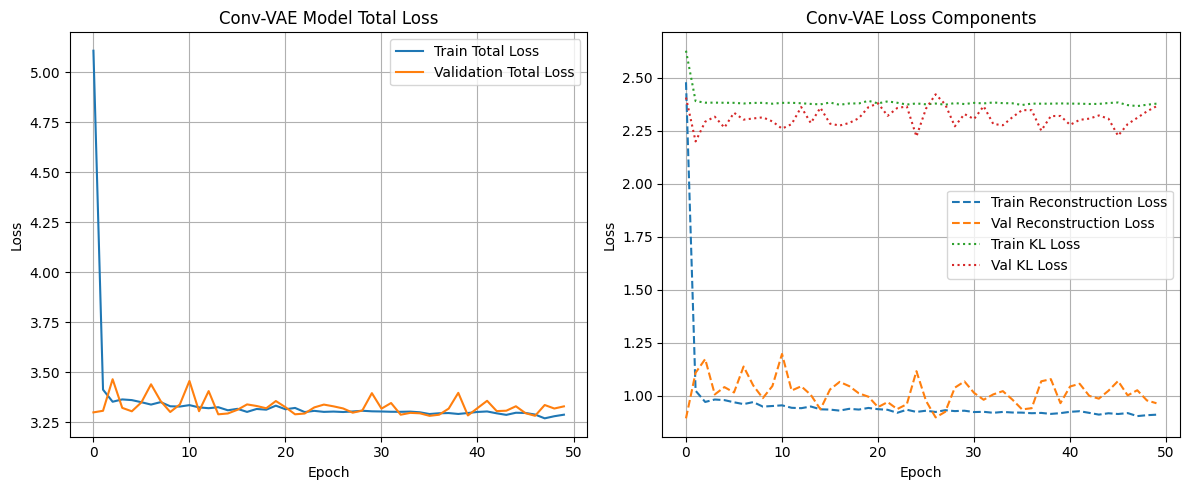


--- Extracting Embeddings using trained Conv-VAE Encoder ---
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
train_embedding.shape: (56829, 2)
test_embedding.shape : (14895, 2)

--- Preparing Data for NN Classifier ---
Include Autoencoder Embeddings in NN Features: True
Shape check: train_embedding (56829, 2), X_fin_train (56829, 19)
Shape check: test_embedding (14895, 2), X_fin_test (14895, 19)
Combined Train Features (unscaled) shape: (56829, 21)
Combined Test Features (unscaled) shape: (14895, 21)
Scaling combined features for NN...
Scaled Train Features shape: (56829, 21)
Scaled Test Features shape: (14895, 21)

--- Defining Simple NN (MLP) Model ---

--- Simple NN (MLP) Model Summary ---


Model: "simple_nn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                                        ┃ Output Shape                           ┃               Para
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━
│ nn_dense_1 (Dense)                                  │ (None, 32)                             │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ nn_dropout_1 (Dropout)                              │ (None, 32)                             │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ nn_dense_2 (Dense)                                  │ (None, 16)                             │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ nn_dropout_2 (Dropout)                              │ (None, 16)                             │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ nn_dense_3 (Dense)                                  │ (None, 4)                              │                   
├─────────────────────────────────────────────────────┼────────────────────────────────────────┼───────────────────
│ output_layer (Dense)                                │ (None, 1)                              │                   
└─────────────────────────────────────────────────────┴────────────────────────────────────────┴───────────────────

 Total params: 1,305 (5.10 KB)

 Trainable params: 1,305 (5.10 KB)

 Non-trainable params: 0 (0.00 B)


Calculating class weights for Keras...
Calculated Class Weights for Keras: {0: 0.5299334191238181, 1: 8.851869158878504}

--- Starting Simple NN (MLP) Training ---
Epoch 1/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - auc: 0.5038 - loss: 0.7318 - val_auc: 0.4817 - val_loss: 0.6897
Epoch 2/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.6157 - loss: 0.6872 - val_auc: 0.5155 - val_loss: 0.6565
Epoch 3/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.6554 - loss: 0.6826 - val_auc: 0.5675 - val_loss: 0.6131
Epoch 4/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.6790 - loss: 0.6743 - val_auc: 0.6003 - val_loss: 0.5848
Epoch 5/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7069 - loss: 0.6500 - val_auc: 0.6294 - val_loss: 0.5568
Epoch 6/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7147 - loss: 0.6459 - val_auc: 0.6494 - val_loss: 0.5100
Epoch 7/150
444/444 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.7277 - loss: 0.6340 - val_auc: 0.6703 - val_loss: 0.4916
E

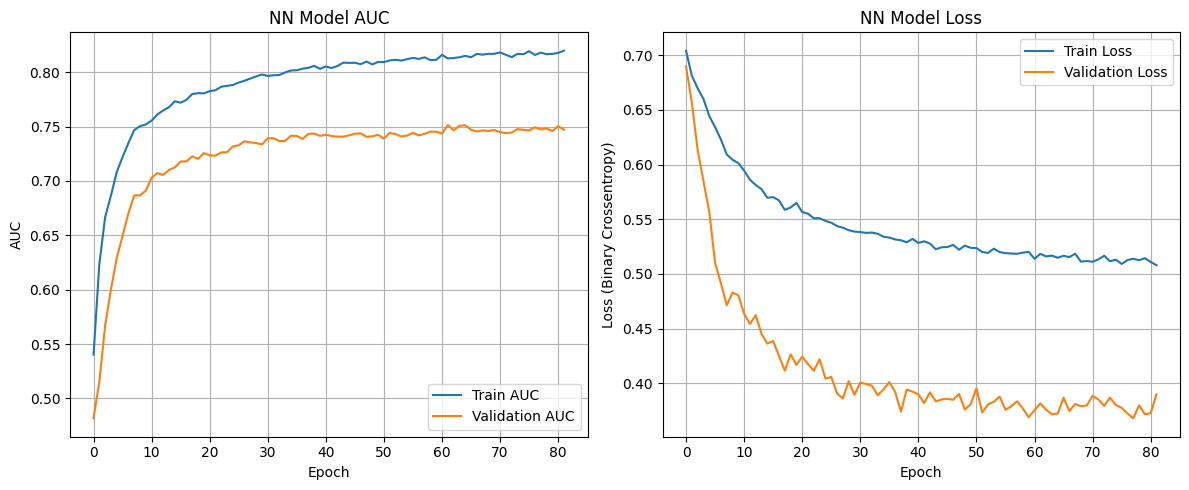


--- Evaluating NN Model ---
Predicting on training data (NN)...
1776/1776 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Predicting on test data (NN)...
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

[Simple NN (MLP) with Conv-VAE Embeddings] Train AUC: 0.83030
[Simple NN (MLP) with Conv-VAE Embeddings] Test  AUC: 0.75145


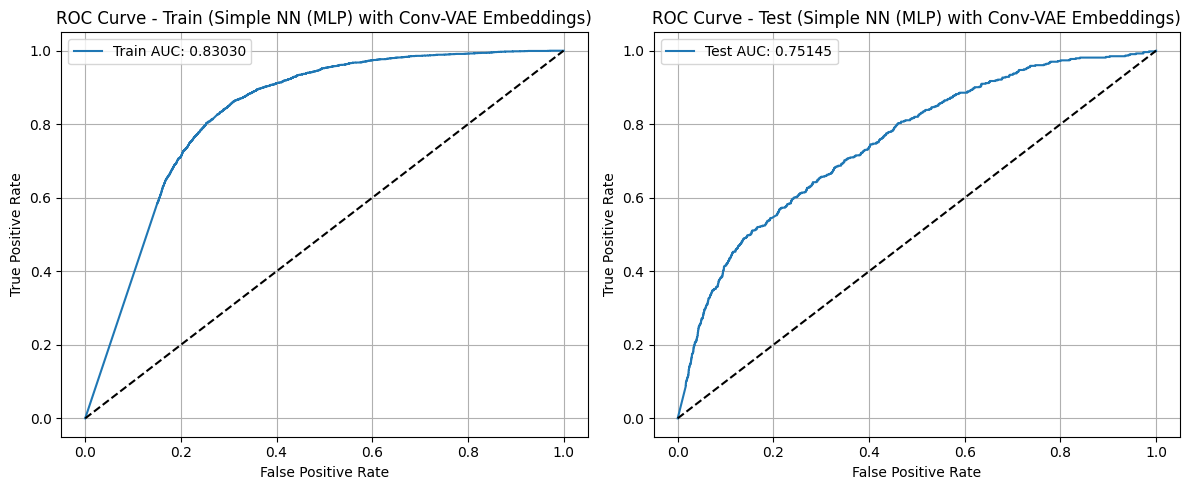

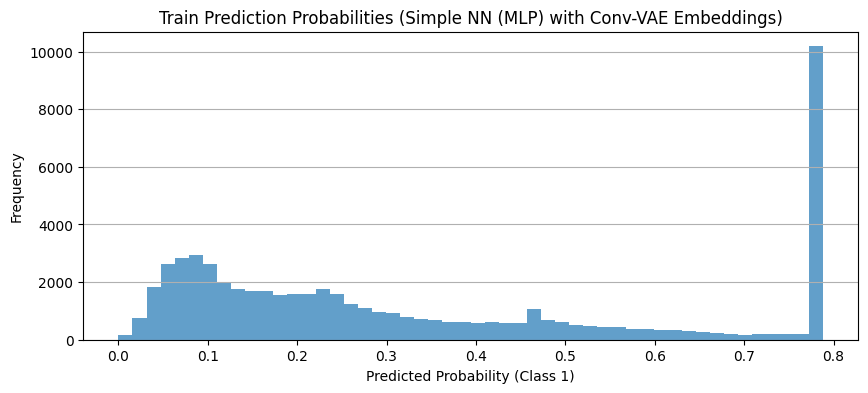

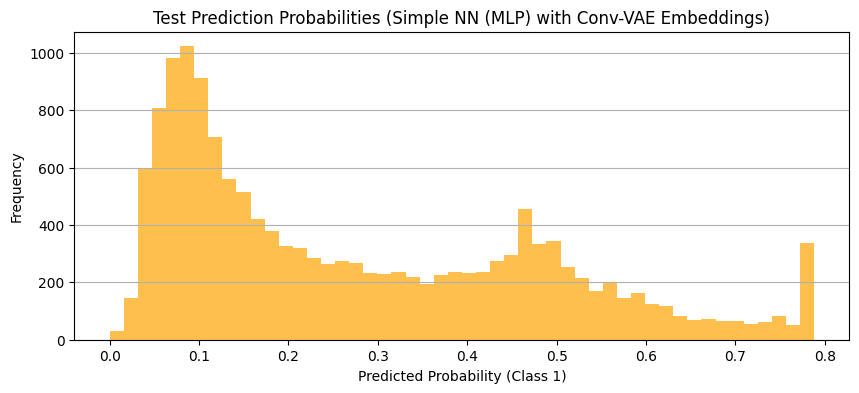

Script finished.


In [ ]:
import pandas as pd
import numpy as np
# Tensorflow / Keras Imports
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
# >>> MODIFICATION START: Added/Removed Layers for Conv-VAE <<<
from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, TimeDistributed, Reshape, Lambda # Removed MHA, GlobalAvgPool, Embedding
from tensorflow.keras.layers import Conv1D, Conv1DTranspose, Flatten, MaxPooling1D # Added Conv layers
import tensorflow.keras.backend as K # Added for VAE loss
# >>> MODIFICATION END <<<
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

# --- Sections 1-8 remain exactly the same as your original code ---
# (File Loading, Date Preprocessing, Feature Engineering, Settings, Sequence Generation, Train/Test Split, Scaling, Seed Fixing)
# Make sure these sections run correctly before proceeding.
# ... (Assume sections 1-8 are present and executed here) ...

############################################################
# 1) 파일 로드 (변경 없음)
############################################################
# 경로를 실제 환경에 맞게 수정해야 합니다.
try:
    stock_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet')
    fin_df   = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_fin_result_with_vkospi_all.parquet')
    print("Successfully loaded data from Parquet files.")
except FileNotFoundError:
    print("Warning: Parquet files not found. Please ensure the path is correct or provide dummy data.")
    # Create dummy data if needed for testing structure
    dates_dummy = pd.to_datetime(pd.date_range(start='2021-01-01', end='2024-06-30', freq='B'))
    codes_dummy = [f'A{i:05d}' for i in range(5)]
    stock_data_dummy = []
    fin_data_dummy = []
    for code in codes_dummy:
        for date in dates_dummy:
            stock_data_dummy.append({'BSOP_DATE': date, 'SHRN_ISCD': code, 'STCK_PRPR': np.random.rand() * 10000 + 50000})
            if date.day == 1: # Sample financial data monthly
                 fin_data_dummy.append({
                     'BSOP_DATE': date, 'SHRN_ISCD': code, 'ROE': np.random.rand() * 20 - 5,
                     'windowdrop': np.random.randint(0, 2), 'W52_HGPR': 100000, 'W52_LWPR': 40000,
                     'STCK_PRPR': stock_data_dummy[-1]['STCK_PRPR'], 'NET_INCOME': np.random.rand()*1e9, 'MARKET_CAP': np.random.rand()*1e11,
                     'PS': np.random.rand()*1e10, 'NET_DEBT': np.random.rand()*5e10, 'DEBT_COST': np.random.rand()*1e9,
                     'SCRT_GRP_CLS_CODE': str(np.random.randint(1,5)), 'MRKT_DIV_CLS_CODE': str(np.random.randint(1,3)),
                     'VKOSPI': np.random.rand()*10+15, 'FN_ACML_TR_PBMN': np.random.rand()*1e12, 'ORGN_NTBY_QTY': np.random.randn()*1e5,
                     'DR': np.random.rand()*150+50, 'ROE_INC': np.random.rand()*5-2.5, 'DEBT_DEPENDENCY': np.random.rand()*100,
                     'ICR': np.random.rand()*10, 'F70': np.random.rand(), 'F71': np.random.rand()
                 })
    stock_df = pd.DataFrame(stock_data_dummy)
    fin_df = pd.DataFrame(fin_data_dummy)
    print("Using dummy data.")
    # pass # Allow the script to continue, potentially failing later if files are truly missing.


############################################################
# 2) 날짜 전처리 (변경 없음)
############################################################
stock_df['BSOP_DATE'] = pd.to_datetime(stock_df['BSOP_DATE'], errors='coerce')
fin_df['BSOP_DATE']   = pd.to_datetime(fin_df['BSOP_DATE'],   errors='coerce')

# 코로나 기간 제외 + 2024-07-01 이전 데이터
stock_df = stock_df[(stock_df['BSOP_DATE'].dt.year != 2020) & (stock_df['BSOP_DATE'] < '2024-07-01')].copy()
fin_df   = fin_df[(fin_df['BSOP_DATE'].dt.year != 2020) & (fin_df['BSOP_DATE']   < '2024-07-01')].copy()

############################################################
# 3) ROE 결측치 제거 및 피처 생성 (변경 없음)
############################################################
# Ensure ROE exists before filtering
if 'ROE' in fin_df.columns:
    mask_fin = fin_df.groupby('SHRN_ISCD')['ROE'].transform('count') > 0
    fin_df = fin_df[mask_fin].copy()
    valid_codes = fin_df['SHRN_ISCD'].unique()
    stock_df = stock_df[stock_df['SHRN_ISCD'].isin(valid_codes)].copy()
else:
    print("Warning: 'ROE' column not found in fin_df. Skipping ROE-based filtering.")
    valid_codes = fin_df['SHRN_ISCD'].unique() # Still get valid codes

# Check if stock_df might be empty after filtering
if stock_df.empty:
     raise ValueError("stock_df is empty after filtering based on fin_df codes. Check data alignment.")


print("Stock DF Columns:", stock_df.columns.tolist())

# Ensure 'windowdrop' exists before dropping NaNs
if 'windowdrop' in fin_df.columns:
    fin_df = fin_df.dropna(subset=['windowdrop']).copy()
else:
    print("Warning: 'windowdrop' column not found in fin_df. Cannot drop NaNs based on it.")
    # Add dummy windowdrop if it's missing and needed later (e.g., for target)
    if 'windowdrop' not in fin_df.columns:
        fin_df['windowdrop'] = 0 # Assign a default value


fin_df['MONTH'] = fin_df['BSOP_DATE'].dt.month

# Check for necessary columns before creating features
required_cols_fin = ['STCK_PRPR', 'W52_HGPR', 'W52_LWPR', 'NET_INCOME', 'MARKET_CAP', 'PS', 'NET_DEBT', 'DEBT_COST', 'SCRT_GRP_CLS_CODE', 'MRKT_DIV_CLS_CODE']
missing_cols = [col for col in required_cols_fin if col not in fin_df.columns]
if missing_cols:
    print(f"Warning: Missing required columns in fin_df: {missing_cols}. Features involving them will be skipped or might error.")
    # Handle missing columns, e.g., by creating them with default values if appropriate
    for col in missing_cols:
        if col not in fin_df.columns: fin_df[col] = 0 # Example: Add missing columns with 0

# Use .loc for assignment and check column existence before division
if 'W52_HGPR' in fin_df.columns and 'STCK_PRPR' in fin_df.columns:
    fin_df.loc[:, 'PRICE_TO_52W_HIGH'] = (fin_df['STCK_PRPR'] / fin_df['W52_HGPR'].replace(0, np.nan)).fillna(0) # Avoid division by zero
if 'W52_LWPR' in fin_df.columns and 'STCK_PRPR' in fin_df.columns:
    fin_df.loc[:, 'PRICE_TO_52W_LOW'] = (fin_df['STCK_PRPR'] / fin_df['W52_LWPR'].replace(0, np.nan)).fillna(0) # Avoid division by zero
if 'NET_INCOME' in fin_df.columns and 'MARKET_CAP' in fin_df.columns:
    fin_df.loc[:, 'PER'] = (fin_df['NET_INCOME'] / fin_df['MARKET_CAP'].replace(0, np.nan)).fillna(0).replace([np.inf, -np.inf], 0)
if 'PS' in fin_df.columns and 'STCK_PRPR' in fin_df.columns:
    fin_df.loc[:, 'PSR'] = (fin_df['PS'] / fin_df['STCK_PRPR'].replace(0, np.nan)).fillna(0).replace([np.inf, -np.inf], 0)
if 'PS' in fin_df.columns and 'NET_INCOME' in fin_df.columns:
    fin_df.loc[:, 'FTRUTH'] = (fin_df['PS'] / fin_df['NET_INCOME'].replace(0, np.nan)).fillna(0).replace([np.inf, -np.inf], 0)
if 'NET_DEBT' in fin_df.columns and 'MARKET_CAP' in fin_df.columns:
    fin_df.loc[:, 'NET_DEBT'] = (fin_df['NET_DEBT'] / fin_df['MARKET_CAP'].replace(0, np.nan)).fillna(0).replace([np.inf, -np.inf], 0)
if 'DEBT_COST' in fin_df.columns and 'MARKET_CAP' in fin_df.columns:
    fin_df.loc[:, 'DEBT_COST'] = (fin_df['DEBT_COST'] / fin_df['MARKET_CAP'].replace(0, np.nan)).fillna(0).replace([np.inf, -np.inf], 0)


le_scrt = LabelEncoder()
le_mrkt = LabelEncoder()
if 'SCRT_GRP_CLS_CODE' in fin_df.columns:
    fin_df['SCRT_GRP_CLS_CODE'] = fin_df['SCRT_GRP_CLS_CODE'].astype(str)
    fin_df['SCRT_GRP_CLS_CODE'] = le_scrt.fit_transform(fin_df['SCRT_GRP_CLS_CODE'])
if 'MRKT_DIV_CLS_CODE' in fin_df.columns:
    fin_df['MRKT_DIV_CLS_CODE'] = fin_df['MRKT_DIV_CLS_CODE'].astype(str)
    fin_df['MRKT_DIV_CLS_CODE'] = le_mrkt.fit_transform(fin_df['MRKT_DIV_CLS_CODE'])

############################################################
# 4) 주요 설정값 (변경 없음)
############################################################
sequence_length = 60

stock_features = [
    'STCK_PRPR',
]
# Ensure stock_features are in stock_df
stock_features = [f for f in stock_features if f in stock_df.columns]
if not stock_features:
    raise ValueError("None of the specified stock_features are present in stock_df.")
n_stock_features = len(stock_features)


fin_features = [
    'PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW',
    'SCRT_GRP_CLS_CODE', # Categorical - Will be treated as numerical by NN scaler unless handled differently
    # 'MRKT_DIV_CLS_CODE', # Categorical - Uncomment if used and available
    'MONTH', # Consider treating as categorical if using embeddings, otherwise scaler treats as numerical
    'VKOSPI',
    'FN_ACML_TR_PBMN',
    'ORGN_NTBY_QTY',
    'DR', 'PSR', 'ROE', 'ROE_INC',
    'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH',
    'F70', 'F71',
]
# Ensure fin_features exist in fin_df after potential modifications
fin_features = [f for f in fin_features if f in fin_df.columns]
print("Using Fin Features:", fin_features)


############################################################
# 5) 시퀀스 데이터 생성 (변경 없음)
############################################################
stock_series_data   = []
stock_current_data = [] # Not used in NN input combination later, but kept for consistency
fin_series_data     = []
matched_targets     = []
dates               = []

stock_groups = stock_df.groupby('SHRN_ISCD')

# Handle potential NaN/Inf before loop
fin_df = fin_df.replace([np.inf, -np.inf], np.nan)
stock_df = stock_df.replace([np.inf, -np.inf], np.nan)
# Fill NaNs more carefully - consider median or forward fill for some columns
fin_df.fillna(0, inplace=True) # Simple fill with 0 for now
stock_df.fillna(0, inplace=True)

print("Starting sequence generation...")
processed_count = 0
skipped_short_seq = 0
skipped_no_today = 0
skipped_target_missing = 0 # Track missing target

# Ensure 'windowdrop' target column exists
if 'windowdrop' not in fin_df.columns:
     raise ValueError("'windowdrop' target column is missing from fin_df. Cannot generate sequences.")

for stock_code, fin_group in fin_df.groupby('SHRN_ISCD'):
    if stock_code not in stock_groups.groups:
        continue
    stock_history_group = stock_groups.get_group(stock_code).sort_values('BSOP_DATE')

    if len(stock_history_group) < sequence_length:
        continue

    for row in fin_group.itertuples():
        date = row.BSOP_DATE
        target_value = row.windowdrop

        # Check if target is NaN before proceeding
        if pd.isna(target_value):
            skipped_target_missing += 1
            continue

        end_index = stock_history_group['BSOP_DATE'].searchsorted(date, side='left')
        start_index = max(0, end_index - sequence_length)
        stock_history = stock_history_group.iloc[start_index:end_index]

        if len(stock_history) != sequence_length:
            skipped_short_seq += 1
            continue

        today_data_row = stock_history_group[stock_history_group['BSOP_DATE'] == date]
        if len(today_data_row) == 0:
            skipped_no_today += 1
            continue
        # Ensure all stock_features exist in the row before accessing
        if not all(f in today_data_row.columns for f in stock_features):
             print(f"Warning: Missing stock features in today_data_row for {stock_code} on {date}. Skipping.")
             skipped_no_today += 1 # Or handle differently
             continue
        today_data = today_data_row[stock_features].iloc[0].values

        # Ensure all fin_features exist in the row before accessing
        current_fin_features = []
        valid_row = True
        for f in fin_features:
            if hasattr(row, f):
                current_fin_features.append(getattr(row, f))
            else:
                print(f"Warning: Missing financial feature '{f}' in row for {stock_code} on {date}. Skipping.")
                valid_row = False
                break
        if not valid_row:
             continue # Skip this row if any fin_feature is missing


        stock_series_data.append(stock_history[stock_features].values)
        stock_current_data.append(today_data)
        fin_series_data.append(current_fin_features)
        matched_targets.append(target_value) # Use the checked target value
        dates.append(date)
        processed_count += 1

print(f"Finished sequence generation. Processed: {processed_count}, Skipped (short seq): {skipped_short_seq}, Skipped (no today data): {skipped_no_today}, Skipped (target NaN): {skipped_target_missing}")


if not stock_series_data:
     raise ValueError("No sequences generated. Check data, preprocessing steps, and feature availability.")

stock_series_data   = np.array(stock_series_data)
stock_current_data = np.array(stock_current_data)
fin_series_data     = np.array(fin_series_data)
matched_targets     = np.array(matched_targets)
dates               = np.array(dates)

print("stock_series_data.shape :", stock_series_data.shape)
# print("stock_current_data.shape:", stock_current_data.shape) # Not directly used in final NN input
print("fin_series_data.shape   :", fin_series_data.shape)
print("matched_targets.shape :", matched_targets.shape)
print("dates.shape           :", dates.shape)


############################################################
# 6) Train/Test 분할 (변경 없음)
############################################################
train_mask = dates < pd.Timestamp('2023-01-01')
test_mask  = dates >= pd.Timestamp('2023-01-01')

if not np.any(train_mask) or not np.any(test_mask):
    raise ValueError(f"Data splitting error: Train samples={np.sum(train_mask)}, Test samples={np.sum(test_mask)}. Check date range and data.")

# AE data
X_stock_train_seq  = stock_series_data[train_mask]
X_stock_test_seq   = stock_series_data[test_mask]

# Financial data (for final NN)
X_fin_train = fin_series_data[train_mask]
X_fin_test  = fin_series_data[test_mask]

# Target variable
y_train = matched_targets[train_mask]
y_test  = matched_targets[test_mask]

# Current stock data (Not used later)
# X_stock_train_curr = stock_current_data[train_mask]
# X_stock_test_curr  = stock_current_data[test_mask]


print("Train size (AE & Final Target):", len(y_train))
print("Test size  (AE & Final Target):", len(y_test))
# Check for sufficient samples in each class for AUC calculation
if len(np.unique(y_train)) < 2: print("Warning: Training data has only one class.")
if len(np.unique(y_test)) < 2: print("Warning: Test data has only one class. AUC will be undefined or 0.5.")

# Avoid division by zero if y_train or y_test is empty or has only one class
if len(y_train) > 0 and len(np.unique(y_train)) > 1:
    print("Train target distribution (Class 1):", np.mean(y_train))
else:
    print("Train target distribution not available (empty or single class).")

if len(y_test) > 0 and len(np.unique(y_test)) > 1:
    print("Test target distribution  (Class 1):", np.mean(y_test))
else:
    print("Test target distribution not available (empty or single class).")


############################################################
# 7) 데이터 정규화 (AE 시퀀스 데이터만 - 변경 없음)
############################################################
# (1) 펼침
n_train_samples, seq_len, n_features = X_stock_train_seq.shape
n_test_samples = X_stock_test_seq.shape[0]
if n_features != n_stock_features:
     raise ValueError(f"Feature count mismatch: X_stock_train_seq has {n_features} features, expected {n_stock_features}")
temp_train = X_stock_train_seq.reshape(-1, n_stock_features)
temp_test  = X_stock_test_seq.reshape(-1, n_stock_features)

# Ensure non-negativity for log1p more robustly
temp_train = np.maximum(temp_train, 0)
temp_test = np.maximum(temp_test, 0)


# (2) 로그 변환
temp_train_log = np.log1p(temp_train)
temp_test_log  = np.log1p(temp_test)
# Check for infinities which can result from log1p(large_number) although less likely than log(0)
temp_train_log = np.nan_to_num(temp_train_log, nan=0.0, posinf=np.log1p(np.finfo(temp_train.dtype).max), neginf=0.0) # Replace inf with large finite number
temp_test_log = np.nan_to_num(temp_test_log, nan=0.0, posinf=np.log1p(np.finfo(temp_test.dtype).max), neginf=0.0)

# (3) StandardScaler 적용
stock_scaler_seq = StandardScaler()
temp_train_scaled = stock_scaler_seq.fit_transform(temp_train_log)
temp_test_scaled  = stock_scaler_seq.transform(temp_test_log)
if np.isnan(temp_train_scaled).any() or np.isnan(temp_test_scaled).any():
    print("Warning: NaNs detected after AE sequence scaling.")
    temp_train_scaled = np.nan_to_num(temp_train_scaled, nan=0.0) # Fill NaNs with 0 after scaling
    temp_test_scaled = np.nan_to_num(temp_test_scaled, nan=0.0)

# (4) 복구
X_stock_train_seq_scaled = temp_train_scaled.reshape(n_train_samples, seq_len, n_features)
X_stock_test_seq_scaled  = temp_test_scaled.reshape(n_test_samples, seq_len, n_features)

print("Scaled AE train sequence shape:", X_stock_train_seq_scaled.shape)
print("Scaled AE test sequence shape:", X_stock_test_seq_scaled.shape)

# Note: Financial data (X_fin_train, X_fin_test) is NOT scaled here.
# It will be scaled AFTER combining with embeddings in Section 12.

############################################################
# 8) 오버샘플링 제거 (변경 없음)
############################################################
print("Skipping oversampling step.")


############################################################
# 시드 고정 (변경 없음)
############################################################
import random
import os
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
print(f"Set random seeds to {seed_value}")

#################################################################
# 9) >>> MODIFICATION START: VAE 클래스 내부에 레이어 정의 <<<
#################################################################
latent_dim = 2
kl_weight = 1.0 # Weight for the KL divergence loss term (can be tuned)

# --- Define Sampling layer ---
class Sampling(tf.keras.layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a sequence."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = K.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# --- Define VAE Model Class ---
class VAE(Model):
    def __init__(self, sequence_length, n_stock_features, latent_dim, kl_weight, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.seq_len = sequence_length
        self.n_feat = n_stock_features
        self.latent_dim = latent_dim
        self.kl_weight = kl_weight

        # --- Define Encoder Layers Internally ---
        encoder_inputs = Input(shape=(self.seq_len, self.n_feat), name='encoder_input_internal')
        x = Conv1D(32, kernel_size=5, activation='relu', padding='causal', strides=1)(encoder_inputs)
        x = Conv1D(64, kernel_size=5, activation='relu', padding='causal', strides=2)(x) # Stride 2 for downsampling
        x = Flatten()(x)
        x = Dense(32, activation='relu')(x)
        # z_mean, z_log_var 레이어를 내부적으로 정의하고 저장
        self.z_mean_layer = Dense(self.latent_dim, name='z_mean')
        self.z_log_var_layer = Dense(self.latent_dim, name='z_log_var')
        self.sampling_layer = Sampling()

        # 내부 사용 및 예측 접근을 위한 함수형 인코더 모델 구축
        z_mean = self.z_mean_layer(x)
        z_log_var = self.z_log_var_layer(x)
        z = self.sampling_layer([z_mean, z_log_var])
        # 이제 인코더는 train/test step에서 필요한 모든 것을 출력합니다.
        self.encoder = Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder_internal')

        # --- Define Decoder Layers Internally ---
        latent_inputs = Input(shape=(self.latent_dim,), name='decoder_latent_input_internal')
        # Assuming only stride=2 in the second Conv1D of encoder:
        shape_before_flatten = (self.seq_len // 2, 64)
        dense_units_needed = np.prod(shape_before_flatten)
        x_dec = Dense(dense_units_needed, activation='relu')(latent_inputs)
        x_dec = Reshape(shape_before_flatten)(x_dec)
        x_dec = Conv1DTranspose(64, kernel_size=5, activation='relu', padding='same', strides=2)(x_dec)
        x_dec = Conv1DTranspose(32, kernel_size=5, activation='relu', padding='same', strides=1)(x_dec)
        decoder_outputs = Conv1DTranspose(self.n_feat, kernel_size=5, activation='linear', padding='same')(x_dec)
        self.decoder = Model(latent_inputs, decoder_outputs, name='decoder_internal')

        # --- Loss Trackers ---
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    # VAE 모델 자체의 call 메서드 정의 (재구성 반환)
    def call(self, inputs, training=False):
        z_mean, z_log_var, z = self.encoder(inputs, training=training)
        reconstruction = self.decoder(z, training=training)
        return reconstruction

    def train_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data # Assume data is just the input

        with tf.GradientTape() as tape:
            # 이제 내부 인코더를 사용하여 필요한 모든 텐서를 직접 얻습니다. (get_layer 불필요)
            z_mean_train, z_log_var_train, z_train = self.encoder(x, training=True)
            reconstruction = self.decoder(z_train, training=True) # 샘플링된 z 사용

            # Reconstruction Loss 계산 (이전과 동일)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.mse(x, reconstruction), axis=-1
                )
            )
            # KL Divergence Loss 계산 (이전과 동일, tf.reduce_mean 위치 변경 가능)
            kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(
                1 + z_log_var_train - tf.square(z_mean_train) - tf.exp(z_log_var_train), axis=1
            ))
            total_loss = reconstruction_loss + self.kl_weight * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        if isinstance(data, tuple):
            x = data[0]
        else:
            x = data # Assume data is just the input

        # 내부 인코더 사용 (get_layer 불필요)
        z_mean_val, z_log_var_val, z_val = self.encoder(x, training=False)
        reconstruction = self.decoder(z_val, training=False) # 샘플링된 z 사용

        # Loss 계산 (이전과 동일)
        reconstruction_loss = tf.reduce_mean(
            tf.reduce_sum(
                tf.keras.losses.mse(x, reconstruction), axis=-1
            )
        )
        kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(
            1 + z_log_var_val - tf.square(z_mean_val) - tf.exp(z_log_var_val), axis=1
        ))
        total_loss = reconstruction_loss + self.kl_weight * kl_loss

        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

# --- Instantiate the VAE ---
# 이제 필요한 차원들을 VAE 생성자에 직접 전달합니다.
vae = VAE(sequence_length, n_stock_features, latent_dim, kl_weight, name='conv_vae')

# Compile the VAE (Optimizer만 지정, 손실은 내부적으로 처리)
vae.compile(optimizer=Adam(learning_rate=0.001))

print("\n--- Conv-VAE Model Instantiated (Layers defined internally) ---")
# Optional: 모델 요약 보기 (fit 호출 시 자동으로 빌드됨)
# vae.encoder.summary()
# vae.decoder.summary()

#################################################################
# 9) <<< MODIFICATION END <<<
#################################################################


############################################################
# 10) >>> MODIFICATION START: 오토인코더 학습 (VAE 사용) <<<
############################################################
include_embeddings = True # Set to True to include embeddings

if include_embeddings:
    # >>> MODIFICATION START: Monitor total validation loss <<<
    # Note: Keras monitors 'val_loss' by default if validation_data is provided.
    # Our VAE reports 'loss', 'reconstruction_loss', 'kl_loss' and their val_ equivalents.
    early_stop_ae = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, mode='min', verbose=1)
    # >>> MODIFICATION END <<<

    print("\n--- Starting Conv-VAE Training ---")
    # Ensure data shapes are correct before fitting
    print(f"Training VAE with input shape: {X_stock_train_seq_scaled.shape}")

    history_ae = vae.fit(
        X_stock_train_seq_scaled, X_stock_train_seq_scaled, # Input is used as target for reconstruction
        epochs=50,
        batch_size=64,
        shuffle=True,
        validation_split=0.2, # Use validation_split to automatically create validation data
        # validation_data=(X_stock_test_seq_scaled, X_stock_test_seq_scaled), # Alternatively provide test set
        callbacks=[early_stop_ae],
        verbose=1 # Show progress
    )

    # --- Plot VAE Training History ---
    plt.figure(figsize=(12, 5))

    # >>> MODIFICATION START: history 키 값 변경 <<<
    # Plot Total Loss
    plt.subplot(1, 2, 1)
    # 'loss' 대신 'total_loss' 사용
    plt.plot(history_ae.history['total_loss'], label='Train Total Loss')
    # 'val_loss' 대신 'val_total_loss' 사용
    plt.plot(history_ae.history['val_total_loss'], label='Validation Total Loss')
    plt.title('Conv-VAE Model Total Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.grid(True)

    # Plot Reconstruction and KL Loss
    # 이 키들은 이미 메트릭 추적기 이름과 일치하므로 그대로 둡니다.
    plt.subplot(1, 2, 2)
    plt.plot(history_ae.history['reconstruction_loss'], label='Train Reconstruction Loss', linestyle='--')
    plt.plot(history_ae.history['val_reconstruction_loss'], label='Val Reconstruction Loss', linestyle='--')
    plt.plot(history_ae.history['kl_loss'], label='Train KL Loss', linestyle=':')
    plt.plot(history_ae.history['val_kl_loss'], label='Val KL Loss', linestyle=':')
    plt.title('Conv-VAE Loss Components')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='center right')
    plt.grid(True)
    # >>> MODIFICATION END <<<

    plt.tight_layout()
    plt.show()


############################################################
# 10) >>> MODIFICATION END <<<
############################################################


############################################################
# 11) >>> MODIFICATION START: 중간 임베딩 추출 (내부 Encoder 사용) <<<
############################################################
    print("\n--- Extracting Embeddings using trained Conv-VAE Encoder ---")
    # 내부 encoder는 [z_mean, z_log_var, z] 리스트를 출력합니다.
    # 임베딩으로 사용할 z_mean (첫 번째 요소)을 선택합니다.
    train_outputs = vae.encoder.predict(X_stock_train_seq_scaled)
    test_outputs = vae.encoder.predict(X_stock_test_seq_scaled)
    train_embedding = train_outputs[0] # Index 0 corresponds to z_mean
    test_embedding = test_outputs[0]  # Index 0 corresponds to z_mean

    print("train_embedding.shape:", train_embedding.shape)
    print("test_embedding.shape :", test_embedding.shape)

############################################################
# 11) <<< MODIFICATION END <<<
############################################################


# --- Sections 12 and 13 remain exactly the same as your modified code ---
# (Combine features, Scale combined features, Define/Train NN, Evaluate NN)
# They will now use the embeddings generated by the Conv-VAE if include_embeddings=True
# ... (Assume sections 12 and 13 are present and executed here) ...
############################################################
# 12) >>> MODIFICATION START: (임베딩 + 재무데이터) 결합 -> 스케일링 -> NN 모델 정의 및 학습 <<<
############################################################
print("\n--- Preparing Data for NN Classifier ---")

# -- Combine Features --
print(f"Include Autoencoder Embeddings in NN Features: {include_embeddings}")

if include_embeddings:
    # Check if embeddings were successfully created
    if 'train_embedding' not in locals() or 'test_embedding' not in locals():
         raise NameError("Embeddings ('train_embedding', 'test_embedding') not found. Ensure AE training and prediction ran successfully.")

    # Check shapes before concatenating
    print(f"Shape check: train_embedding {train_embedding.shape}, X_fin_train {X_fin_train.shape}")
    print(f"Shape check: test_embedding {test_embedding.shape}, X_fin_test {X_fin_test.shape}")
    if train_embedding.shape[0] != X_fin_train.shape[0]:
        raise ValueError(f"Row count mismatch: train_embedding ({train_embedding.shape[0]}) vs X_fin_train ({X_fin_train.shape[0]})")
    if test_embedding.shape[0] != X_fin_test.shape[0]:
         raise ValueError(f"Row count mismatch: test_embedding ({test_embedding.shape[0]}) vs X_fin_test ({X_fin_test.shape[0]})")

    train_features_unscaled = np.concatenate([
        train_embedding, # AE Embeddings
        X_fin_train      # Financial features (UNSCALED at this point)
    ], axis=1)
    test_features_unscaled = np.concatenate([
        test_embedding, # AE Embeddings
        X_fin_test       # Financial features (UNSCALED at this point)
    ], axis=1)
else:
    # Only use financial features if embeddings are excluded
    train_features_unscaled = X_fin_train
    test_features_unscaled = X_fin_test

print("Combined Train Features (unscaled) shape:", train_features_unscaled.shape)
print("Combined Test Features (unscaled) shape:", test_features_unscaled.shape)

# -- Scale Combined Features (CRUCIAL FOR NN) --
print("Scaling combined features for NN...")
combined_scaler = StandardScaler()
train_features_scaled = combined_scaler.fit_transform(train_features_unscaled)
test_features_scaled = combined_scaler.transform(test_features_unscaled)

# Handle potential NaNs after scaling combined features
if np.isnan(train_features_scaled).any() or np.isnan(test_features_scaled).any():
    print("Warning: NaNs detected after scaling combined features. Filling with 0.")
    train_features_scaled = np.nan_to_num(train_features_scaled, nan=0.0)
    test_features_scaled = np.nan_to_num(test_features_scaled, nan=0.0)

print("Scaled Train Features shape:", train_features_scaled.shape)
print("Scaled Test Features shape:", test_features_scaled.shape)


# -- Define Simple NN (MLP) Model ---
print("\n--- Defining Simple NN (MLP) Model ---")
nn_input_dim = train_features_scaled.shape[1]

nn_model = Sequential([
    Input(shape=(nn_input_dim,), name='combined_input'),
    Dense(32, activation='relu', name='nn_dense_1'),
    Dropout(0.3, name='nn_dropout_1'), # Increased dropout slightly
    Dense(16, activation='relu', name='nn_dense_2'),
    Dropout(0.3, name='nn_dropout_2'), # Increased dropout slightly
    Dense(4, activation='relu', name='nn_dense_3'),
    # Removed dropout before final layer based on common practice
    Dense(1, activation='sigmoid', name='output_layer') # Sigmoid for binary classification
], name='simple_nn_classifier')

# --- Compile NN Model ---
nn_model.compile(
    optimizer=Adam(learning_rate=0.0005), # Slightly adjusted learning rate
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc')] # Use AUC metric
)

print("\n--- Simple NN (MLP) Model Summary ---")
nn_model.summary(line_length=120)


# --- Calculate Class Weights for Keras ---
print("\nCalculating class weights for Keras...")
unique_classes = np.unique(y_train)
# Ensure there are multiple classes before calculating weights
if len(unique_classes) < 2:
    print("Warning: Only one class present in y_train. Class weights cannot be calculated effectively.")
    class_weights = None # Do not use class weights
else:
    class_weights_array = compute_class_weight(class_weight='balanced', classes=unique_classes, y=y_train)
    # Keras expects a dictionary mapping class indices (0 and 1) to weights
    class_weights = dict(zip(unique_classes, class_weights_array))
    print(f"Calculated Class Weights for Keras: {class_weights}")


# --- Train NN Model ---
print("\n--- Starting Simple NN (MLP) Training ---")
early_stop_nn = EarlyStopping(
    monitor='val_auc', # Monitor validation AUC
    patience=20,       # Increased patience
    mode='max',        # Maximize AUC
    restore_best_weights=True,
    verbose=1
)

# Check if validation data has multiple classes before training
if len(np.unique(y_test)) < 2:
    print("Warning: Validation data (y_test) has only one class. AUC metric might be misleading. Monitoring 'val_loss' instead.")
    early_stop_nn = EarlyStopping( # Redefine early stopping
         monitor='val_loss',
         patience=20,
         mode='min', # Minimize loss
         restore_best_weights=True,
         verbose=1
     )


history_nn = nn_model.fit(
    train_features_scaled, y_train,
    validation_data=(test_features_scaled, y_test),
    epochs=150,        # Increased epochs, early stopping will handle duration
    batch_size=128,      # Adjusted batch size
    shuffle=True,       # Shuffle training data each epoch (Changed from False)
    callbacks=[early_stop_nn],
    class_weight=class_weights, # Apply class weights (will be None if only one class)
    verbose=1            # Show progress
)

# --- Plot NN Training History ---
plt.figure(figsize=(12, 5))

# Plot AUC if available, otherwise plot accuracy or skip
if 'auc' in history_nn.history and 'val_auc' in history_nn.history:
    plt.subplot(1, 2, 1)
    plt.plot(history_nn.history['auc'], label='Train AUC')
    plt.plot(history_nn.history['val_auc'], label='Validation AUC')
    plt.title('NN Model AUC')
    plt.ylabel('AUC')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')
    plt.grid(True)
elif 'accuracy' in history_nn.history: # Fallback to accuracy if AUC isn't available/reliable
     plt.subplot(1, 2, 1)
     plt.plot(history_nn.history['accuracy'], label='Train Accuracy')
     plt.plot(history_nn.history['val_accuracy'], label='Validation Accuracy')
     plt.title('NN Model Accuracy')
     plt.ylabel('Accuracy')
     plt.xlabel('Epoch')
     plt.legend(loc='lower right')
     plt.grid(True)
else:
    # Skip AUC/Accuracy plot if neither is reliable
     plt.subplot(1, 2, 1)
     plt.text(0.5, 0.5, 'AUC/Accuracy Plot Skipped\n(Single Class in Validation Data)', ha='center', va='center')
     plt.title('NN Model Performance')


plt.subplot(1, 2, 2)
plt.plot(history_nn.history['loss'], label='Train Loss')
plt.plot(history_nn.history['val_loss'], label='Validation Loss')
plt.title('NN Model Loss')
plt.ylabel('Loss (Binary Crossentropy)')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

############################################################
# 12) >>> MODIFICATION END <<<
############################################################


############################################################
# 13) >>> MODIFICATION START: 최종 평가 (NN 모델 사용) <<<
############################################################
print("\n--- Evaluating NN Model ---")

# --- Get Predictions from NN Model ---
# Use the SCALED features for prediction
print("Predicting on training data (NN)...")
pred_train_proba = nn_model.predict(train_features_scaled).squeeze()
print("Predicting on test data (NN)...")
pred_test_proba  = nn_model.predict(test_features_scaled).squeeze()

# Ensure probabilities are within [0, 1] range after potential squeezing/activation
pred_train_proba = np.clip(pred_train_proba, 0.0, 1.0)
pred_test_proba = np.clip(pred_test_proba, 0.0, 1.0)


# --- Calculate AUC Scores ---
# Check for multi-class labels before calculating AUC
roc_auc_train = np.nan # Default to NaN
roc_auc_test = np.nan

if len(np.unique(y_train)) > 1:
     try:
          roc_auc_train = roc_auc_score(y_train, pred_train_proba)
     except ValueError as e:
          print(f"Could not calculate Train AUC: {e}")
else:
     print("Train AUC not calculated (single class in y_train).")

if len(np.unique(y_test)) > 1:
     try:
          roc_auc_test = roc_auc_score(y_test, pred_test_proba)
     except ValueError as e:
          print(f"Could not calculate Test AUC: {e}")
else:
     print("Test AUC not calculated (single class in y_test).")


# Determine title based on whether embeddings were used
# >>> MODIFICATION START: Changed "Transformer AE" to "Conv-VAE" <<<
ae_status = "with Conv-VAE Embeddings" if include_embeddings else "without AE Embeddings"
# >>> MODIFICATION END <<<
model_name = "Simple NN (MLP)" # Updated model name
print(f'\n[{model_name} {ae_status}] Train AUC: {roc_auc_train:.5f}')
print(f'[{model_name} {ae_status}] Test  AUC: {roc_auc_test:.5f}')

# --- ROC Curve 시각화 ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
if len(np.unique(y_train)) > 1 and not np.isnan(roc_auc_train):
    fpr_train, tpr_train, _ = roc_curve(y_train, pred_train_proba)
    plt.plot(fpr_train, tpr_train, label=f'Train AUC: {roc_auc_train:.5f}')
else:
     plt.text(0.5, 0.5, 'Train ROC Skipped\n(Single Class or Error)', ha='center', va='center')
plt.plot([0,1],[0,1],'k--')
# >>> MODIFICATION START: Changed "Transformer AE" to "Conv-VAE" <<<
plt.title(f'ROC Curve - Train ({model_name} {ae_status})') # Updated title
# >>> MODIFICATION END <<<
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
if len(np.unique(y_test)) > 1 and not np.isnan(roc_auc_test):
    fpr_test,  tpr_test,  _ = roc_curve(y_test, pred_test_proba)
    plt.plot(fpr_test, tpr_test, label=f'Test AUC: {roc_auc_test:.5f}')
else:
     plt.text(0.5, 0.5, 'Test ROC Skipped\n(Single Class or Error)', ha='center', va='center')
plt.plot([0,1],[0,1],'k--')
# >>> MODIFICATION START: Changed "Transformer AE" to "Conv-VAE" <<<
plt.title(f'ROC Curve - Test ({model_name} {ae_status})') # Updated title
# >>> MODIFICATION END <<<
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# --- 예측 확률 히스토그램 ---
plt.figure(figsize=(10, 4))
plt.hist(pred_train_proba, bins=50, alpha=0.7)
# >>> MODIFICATION START: Changed "Transformer AE" to "Conv-VAE" <<<
plt.title(f'Train Prediction Probabilities ({model_name} {ae_status})') # Updated title
# >>> MODIFICATION END <<<
plt.xlabel('Predicted Probability (Class 1)')
plt.ylabel('Frequency')
plt.grid(True, axis='y')
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(pred_test_proba, bins=50, alpha=0.7, color='orange')
# >>> MODIFICATION START: Changed "Transformer AE" to "Conv-VAE" <<<
plt.title(f'Test Prediction Probabilities ({model_name} {ae_status})') # Updated title
# >>> MODIFICATION END <<<
plt.xlabel('Predicted Probability (Class 1)')
plt.ylabel('Frequency')
plt.grid(True, axis='y')
plt.show()

############################################################
# 13) >>> MODIFICATION END <<<
############################################################

print("Script finished.")

### transformer

## 앙상블

### stacking

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)          │ (None, 60, 9)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_10 (Conv1D)                   │ (None, 56, 64)              │           2,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 56, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_11 (Conv1D)                   │ (None, 54, 32)              │           6,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 54, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 1728)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 8)                   │          13,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,961 (89.69 KB)

 Trainable params: 22,961 (89.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - auc: 0.7669 - loss: 0.5585 - val_auc: 0.7686 - val_loss: 0.3058
Epoch 2/30
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - auc: 0.8921 - loss: 0.4206 - val_auc: 0.7870 - val_loss: 0.1527
Epoch 3/30
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - auc: 0.8993 - loss: 0.4083 - val_auc: 0.7858 - val_loss: 0.2153
Epoch 4/30
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - auc: 0.9057 - loss: 0.3959 - val_auc: 0.7918 - val_loss: 0.3050
Epoch 5/30
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - auc: 0.9079 - loss: 0.3929 - val_auc: 0.7644 - val_loss: 0.2484
Epoch 6/30
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - auc: 0.9098 - loss: 0.3882 - val_auc: 0.6662 - val_loss: 0.1898
Epoch 7/30
1341/1341 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - auc: 0.9140 - loss: 0.3785 - val_auc: 0.7541 - val_loss: 0.2300
1475/1475 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
344/344 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
0:	test: 0.7098514	best: 0.7098514 (0)	total: 28.6ms	remaining

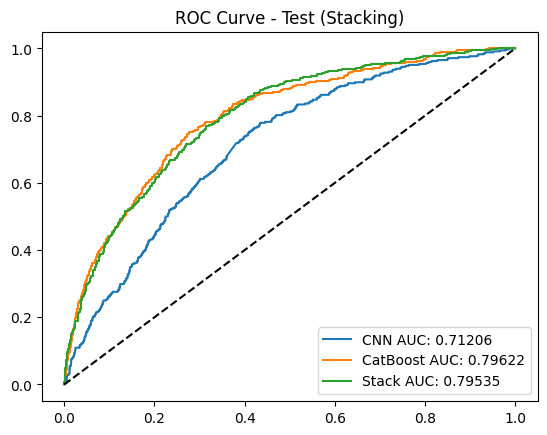

In [ ]:
import numpy as np
from packaging import version
import sys
import subprocess
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import os
import pandas as pd
from catboost import CatBoostClassifier
from imblearn.over_sampling import RandomOverSampler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# numpy 버전 확인
required_version = "1.26.4"
if version.parse(np.__version__) >= version.parse("2.0.0"):
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"numpy=={required_version}"])
    print("재설치 완료. 런타임을 재시작하세요.")

# 데이터 로드
stock_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet')
fin_df   = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/fin_result.parquet')

# 날짜 처리
stock_df['BSOP_DATE'] = pd.to_datetime(stock_df['BSOP_DATE'], errors='coerce')
fin_df['BSOP_DATE']   = pd.to_datetime(fin_df['BSOP_DATE'],   errors='coerce')

stock_df = stock_df[(stock_df['BSOP_DATE'].dt.year != 2020) & (stock_df['BSOP_DATE'] < '2024-07-01')]
fin_df   = fin_df[(fin_df['BSOP_DATE'].dt.year != 2020) & (fin_df['BSOP_DATE']   < '2024-07-01')]

# 결측 제거
roe_missing_stocks = fin_df[fin_df['ROE'].isna()]['SHRN_ISCD'].unique()
stock_df = stock_df[~stock_df['SHRN_ISCD'].isin(roe_missing_stocks)]
fin_df   = fin_df[~fin_df['SHRN_ISCD'].isin(roe_missing_stocks)]
fin_df = fin_df.dropna(subset=['windowdrop'])

# 설정
sequence_length = 60
stock_features = ['STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR', 'FN_ACML_TR_PBMN',
                   'MARKET_CAP', 'vkospi', 'ks200', 'fx']
fin_features = ['ROE', 'DR', 'ROE_INC', 'PS', 'SHORT_DEBT', 'DEBT_COST_RATIO', 'EQUITY',
                'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY', 'NET_INCOME', 'ICR', 'CF']

# 시계열 + 현재 + 재무 + 타겟 생성
stock_series_data = []
stock_current_data = []
fin_series_data = []
matched_targets = []
dates = []
stock_groups = stock_df.groupby('SHRN_ISCD')
for stock_code, fin_group in fin_df.groupby('SHRN_ISCD'):
    if stock_code not in stock_groups.groups:
        continue
    stock_history_group = stock_groups.get_group(stock_code)
    for row in fin_group.itertuples():
        date = row.BSOP_DATE
        stock_history = (stock_history_group[stock_history_group['BSOP_DATE'] < date].sort_values('BSOP_DATE', ascending=False).head(sequence_length))
        if len(stock_history) != sequence_length:
            continue
        today_data_row = stock_history_group[stock_history_group['BSOP_DATE'] == date]
        if len(today_data_row) == 0:
            continue
        today_data = today_data_row[stock_features].iloc[0].values
        stock_series_data.append(stock_history[stock_features].values)
        stock_current_data.append(today_data)
        fin_series_data.append([getattr(row, f) for f in fin_features])
        matched_targets.append(row.windowdrop)
        dates.append(date)

stock_series_data = np.array(stock_series_data)
stock_current_data = np.array(stock_current_data)
fin_series_data = np.array(fin_series_data)
matched_targets = np.array(matched_targets)
dates = np.array(dates)

# Train/Test 분리
train_mask = dates < pd.Timestamp('2023-01-01')
test_mask  = dates >= pd.Timestamp('2023-01-01')

X_stock_train_seq = stock_series_data[train_mask]
X_stock_test_seq  = stock_series_data[test_mask]
X_stock_train_curr = stock_current_data[train_mask]
X_stock_test_curr  = stock_current_data[test_mask]
X_fin_train = fin_series_data[train_mask]
X_fin_test  = fin_series_data[test_mask]
y_train = matched_targets[train_mask]
y_test  = matched_targets[test_mask]
dates_train = dates[train_mask]
dates_test  = dates[test_mask]

# 스케일링
temp_train = X_stock_train_seq.reshape(-1, len(stock_features))
temp_test = X_stock_test_seq.reshape(-1, len(stock_features))
temp_train_log = np.log1p(temp_train)
temp_test_log  = np.log1p(temp_test)
stock_scaler_seq = StandardScaler()
temp_train_scaled = stock_scaler_seq.fit_transform(temp_train_log)
temp_test_scaled  = stock_scaler_seq.transform(temp_test_log)
X_stock_train_seq = temp_train_scaled.reshape(X_stock_train_seq.shape)
X_stock_test_seq  = temp_test_scaled.reshape(X_stock_test_seq.shape)
curr_scaler = StandardScaler()
X_stock_train_curr = curr_scaler.fit_transform(X_stock_train_curr)
X_stock_test_curr  = curr_scaler.transform(X_stock_test_curr)

# CNN Validation 분리
val_cutoff = pd.Timestamp('2022-10-01')
val_mask = (dates_train >= val_cutoff)
train_mask_cnn = ~val_mask
X_train_seq_cnn = X_stock_train_seq[train_mask_cnn]
y_train_cnn = y_train[train_mask_cnn]
X_val_seq_cnn = X_stock_train_seq[val_mask]
y_val_cnn = y_train[val_mask]

# CNN Oversampling
ros = RandomOverSampler(random_state=42)
train_idx_cnn = np.arange(len(y_train_cnn)).reshape(-1,1)
resampled_idx_cnn, y_train_res_cnn = ros.fit_resample(train_idx_cnn, y_train_cnn)
resampled_idx_cnn = resampled_idx_cnn.flatten()
X_train_seq_res_cnn = X_train_seq_cnn[resampled_idx_cnn]

# CNN 모델
sequence_input = Input(shape=(sequence_length, len(stock_features)), name='sequence_input')
x = Conv1D(filters=64, kernel_size=5, activation='relu')(sequence_input)
x = Dropout(0.4)(x)
x = Conv1D(filters=32, kernel_size=3, activation='relu')(x)
x = Dropout(0.4)(x)
x = Flatten()(x)
x = Dense(8, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(1, activation='sigmoid')(x)
model_cnn = Model(inputs=sequence_input, outputs=output_layer)
model_cnn.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])
model_cnn.summary()

from tensorflow.keras.metrics import AUC

# CNN 모델 컴파일 (AUC metric 포함)
model_cnn.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=[AUC(name='auc')]  # ✅ AUC을 여기서 넣기
)

# EarlyStopping 콜백 (val_auc 기준)
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=3,
    mode='max',
    restore_best_weights=True
)

# CNN 학습
history_cnn = model_cnn.fit(
    X_train_seq_res_cnn, y_train_res_cnn,
    epochs=30,
    batch_size=64,
    validation_data=(X_val_seq_cnn, y_val_cnn),
    callbacks=[early_stop],
    verbose=1
)

# CNN 예측
cnn_pred_train_proba = model_cnn.predict(X_stock_train_seq).ravel()
cnn_pred_test_proba  = model_cnn.predict(X_stock_test_seq).ravel()

# CatBoost Validation 분리
val_mask_cat = (dates_train >= val_cutoff)
train_mask_cat = ~val_mask_cat
X_cat_train_all = np.concatenate([X_stock_train_curr, X_fin_train], axis=1)
X_cat_test  = np.concatenate([X_stock_test_curr,  X_fin_test],  axis=1)
X_cat_train_c = X_cat_train_all[train_mask_cat]
y_cat_train_c = y_train[train_mask_cat]
X_cat_val_c = X_cat_train_all[val_mask_cat]
y_cat_val_c = y_train[val_mask_cat]

# CatBoost Oversampling
train_idx_cat = np.arange(len(y_cat_train_c)).reshape(-1,1)
resampled_idx_cat, y_train_res_cat = ros.fit_resample(train_idx_cat, y_cat_train_c)
resampled_idx_cat = resampled_idx_cat.flatten()
X_cat_train_res = X_cat_train_c[resampled_idx_cat]

# CatBoost 학습
cat_model = CatBoostClassifier(iterations=10000, depth=6, learning_rate=0.01, eval_metric='AUC', early_stopping_rounds=100, use_best_model=True, verbose=100)
cat_model.fit(X_cat_train_res, y_train_res_cat, eval_set=(X_cat_val_c, y_cat_val_c))

# CatBoost 예측
cat_pred_train_proba = cat_model.predict_proba(X_cat_train_all)[:,1]
cat_pred_test_proba  = cat_model.predict_proba(X_cat_test)[:,1]

# Blending
from sklearn.linear_model import LogisticRegression

stack_train = np.vstack([cnn_pred_train_proba, cat_pred_train_proba]).T
stack_test = np.vstack([cnn_pred_test_proba, cat_pred_test_proba]).T

stack_model = LogisticRegression()
stack_model.fit(stack_train, y_train)

stack_pred_test = stack_model.predict_proba(stack_test)[:, 1]
stack_auc = roc_auc_score(y_test, stack_pred_test)
print(f"[Stacking] Test AUC: {stack_auc:.5f}")


# ROC Curve
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, cnn_pred_test_proba)
fpr_cat, tpr_cat, _ = roc_curve(y_test, cat_pred_test_proba)
fpr_bld, tpr_bld, _ = roc_curve(y_test, stack_pred_test)

auc_cnn = roc_auc_score(y_test, cnn_pred_test_proba)
auc_cat = roc_auc_score(y_test, cat_pred_test_proba)
auc_bld = roc_auc_score(y_test, stack_pred_test)

plt.figure()
plt.plot(fpr_cnn, tpr_cnn, label=f'CNN AUC: {auc_cnn:.5f}')
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost AUC: {auc_cat:.5f}')
plt.plot(fpr_bld, tpr_bld, label=f'Stack AUC: {auc_bld:.5f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Test (Stacking)')
plt.legend()
plt.show()

In [ ]:
# prompt: '/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet') 이 파일의 컬럼들을 출력해줘

import pandas as pd

# 데이터 로드
stock_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet')

# 컬럼 출력
stock_df.columns


Index(['BSOP_DATE', 'STND_ISCD', 'SHRN_ISCD', 'SCRT_GRP_CLS_CODE',
       'MRKT_DIV_CLS_CODE', 'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR',
       'FN_ACML_TR_PBMN', 'CRDT_RMND_RATE', 'MARKET_CAP', 'FRGN_HLDN_RATE',
       'FRGN_NTBY_QTY', 'ORGN_NTBY_QTY', 'vkospi', 'ks200', 'fx'],
      dtype='object')

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)          │ (None, 60, 9)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_36 (Conv1D)                   │ (None, 56, 64)              │           2,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_20               │ (None, 56, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_55 (Dropout)                 │ (None, 56, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_37 (Conv1D)                   │ (None, 54, 32)              │           6,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_21               │ (None, 54, 32)              │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_56 (Dropout)                 │ (None, 54, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_18 (Flatten)                 │ (None, 1728)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_44 (Dense)                     │ (None, 8)                   │          13,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_57 (Dropout)                 │ (None, 8)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_45 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,345 (91.19 KB)

 Trainable params: 23,153 (90.44 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
1340/1340 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - auc: 0.7863 - loss: 0.6123 - val_auc: 0.3208 - val_loss: 2.1625
Epoch 2/30
1340/1340 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - auc: 0.8934 - loss: 0.4171 - val_auc: 0.4278 - val_loss: 0.5635
Epoch 3/30
1340/1340 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - auc: 0.9026 - loss: 0.4009 - val_auc: 0.4595 - val_loss: 0.4966
Epoch 4/30
1340/1340 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - auc: 0.9076 - loss: 0.3879 - val_auc: 0.4636 - val_loss: 0.4840
Epoch 5/30
1340/1340 ━━━━━━━━━━━━━━━━━━━━ 31s 23ms/step - auc: 0.9107 - loss: 0.3834 - val_auc: 0.5328 - val_loss: 0.4137
Epoch 6/30
1340/1340 ━━━━━━━━━━━━━━━━━━━━ 30s 22ms/step - auc: 0.9138 - loss: 0.3757 - val_auc: 0.4999 - val_loss: 0.4465
Epoch 7/30
1340/1340 ━━━━━━━━━━━━━━━━━━━━ 40s 22ms/step - auc: 0.9178 - loss: 0.3682 - val_auc: 0.5681 - val_loss: 0.3557
Epoch 8/30
1340/1340 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - auc: 0.9198 - loss: 0.3647 - val_auc: 0.5875 - val_loss: 0.3489
Epoch 9/30
1340/1340 ━━━

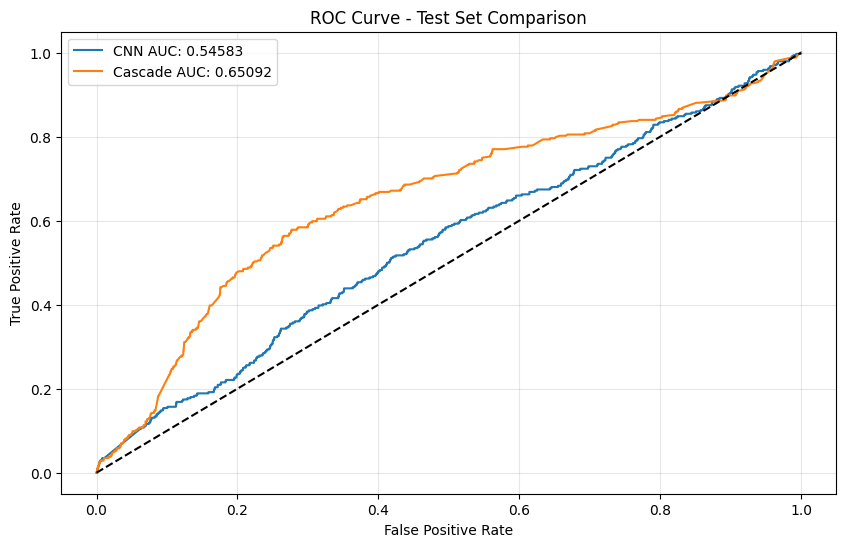

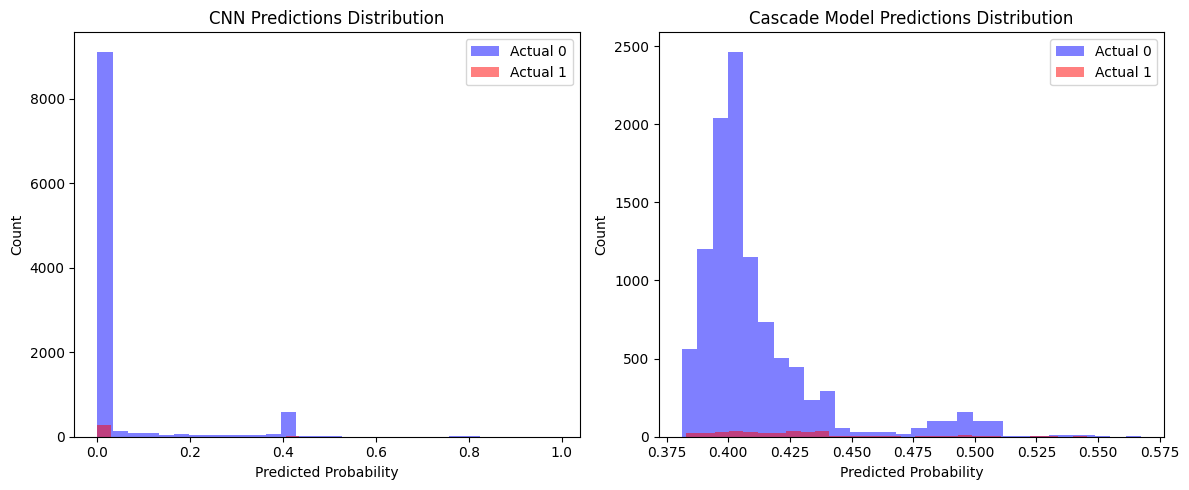

0:	test: 0.6473368	best: 0.6473368 (0)	total: 30.2ms	remaining: 2m 31s
100:	test: 0.6816804	best: 0.6865871 (9)	total: 2.8s	remaining: 2m 15s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.6865870681
bestIteration = 9

Shrink model to first 10 iterations.
[Finance Only] Test AUC: 0.68083
0:	test: 0.5522730	best: 0.5522730 (0)	total: 17.5ms	remaining: 1m 27s
100:	test: 0.6881948	best: 0.6894157 (98)	total: 1.71s	remaining: 1m 23s
200:	test: 0.7251788	best: 0.7262806 (198)	total: 3.42s	remaining: 1m 21s
300:	test: 0.7381968	best: 0.7384284 (297)	total: 5.12s	remaining: 1m 19s
400:	test: 0.7441067	best: 0.7441067 (400)	total: 6.88s	remaining: 1m 18s
500:	test: 0.7520382	best: 0.7520391 (499)	total: 9.16s	remaining: 1m 22s
600:	test: 0.7537834	best: 0.7540840 (596)	total: 12.7s	remaining: 1m 33s
700:	test: 0.7577969	best: 0.7578327 (699)	total: 14.4s	remaining: 1m 28s
800:	test: 0.7586440	best: 0.7594167 (787)	total: 16.2s	remaining: 1m 25s
Stopped by overfitting dete

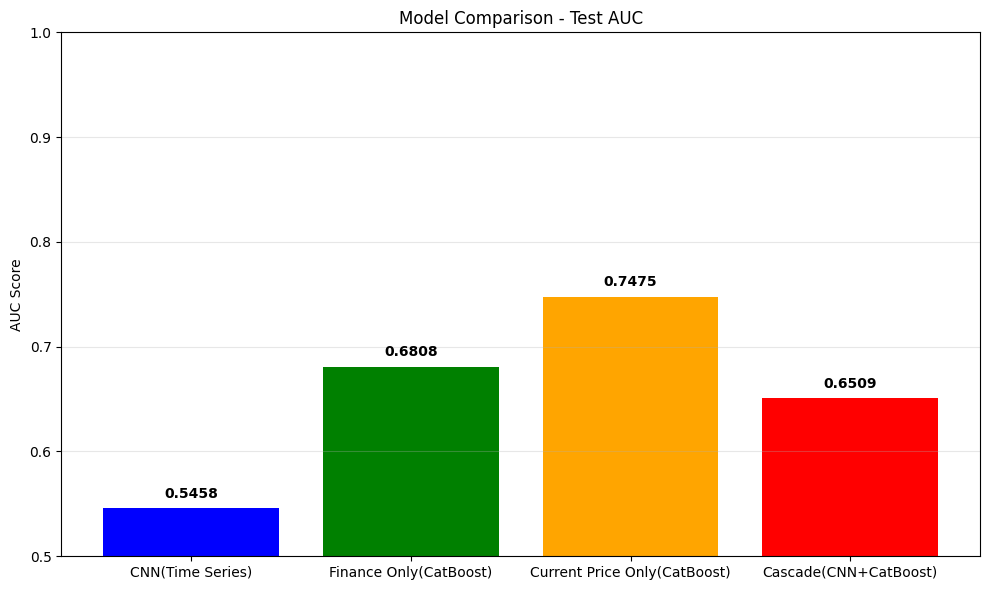

In [ ]:
import numpy as np
from packaging import version
import sys
import subprocess
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import os
import pandas as pd
from catboost import CatBoostClassifier
from imblearn.over_sampling import RandomOverSampler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC

# numpy 버전 확인
required_version = "1.26.4"
if version.parse(np.__version__) >= version.parse("2.0.0"):
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"numpy=={required_version}"])
    print("재설치 완료. 런타임을 재시작하세요.")

# 데이터 로드
stock_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet')
fin_df   = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/result/fin_result.parquet')

# 날짜 처리
stock_df['BSOP_DATE'] = pd.to_datetime(stock_df['BSOP_DATE'], errors='coerce')
fin_df['BSOP_DATE']   = pd.to_datetime(fin_df['BSOP_DATE'],   errors='coerce')

stock_df = stock_df[(stock_df['BSOP_DATE']!= '2020-03-31') & (stock_df['BSOP_DATE'] < '2024-07-01')]
fin_df   = fin_df[(fin_df['BSOP_DATE'] != '2020-03-31') & (fin_df['BSOP_DATE']   < '2024-07-01')]

# 결측 제거
roe_missing_stocks = fin_df[fin_df['ROE'].isna()]['SHRN_ISCD'].unique()
stock_df = stock_df[~stock_df['SHRN_ISCD'].isin(roe_missing_stocks)]
fin_df   = fin_df[~fin_df['SHRN_ISCD'].isin(roe_missing_stocks)]
fin_df = fin_df.dropna(subset=['windowdrop'])

# 설정
sequence_length = 60
stock_features = ['STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR', 'FN_ACML_TR_PBMN',
                  #'SCRT_GRP_CLS_CODE', 'MRKT_DIV_CLS_CODE',
                   'MARKET_CAP', 'vkospi', 'ks200', 'fx' ]
fin_features = ['ROE', 'DR', 'ROE_INC', 'PS', 'SHORT_DEBT', 'DEBT_COST_RATIO', 'EQUITY',
                'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY', 'NET_INCOME', 'ICR', 'CF']

# 시계열 + 현재 + 재무 + 타겟 생성
stock_series_data = []
stock_current_data = []
fin_series_data = []
matched_targets = []
dates = []
stock_groups = stock_df.groupby('SHRN_ISCD')
for stock_code, fin_group in fin_df.groupby('SHRN_ISCD'):
    if stock_code not in stock_groups.groups:
        continue
    stock_history_group = stock_groups.get_group(stock_code)
    for row in fin_group.itertuples():
        date = row.BSOP_DATE
        stock_history = (stock_history_group[stock_history_group['BSOP_DATE'] < date].sort_values('BSOP_DATE', ascending=False).head(sequence_length))
        if len(stock_history) != sequence_length:
            continue
        today_data_row = stock_history_group[stock_history_group['BSOP_DATE'] == date]
        if len(today_data_row) == 0:
            continue
        today_data = today_data_row[stock_features].iloc[0].values
        stock_series_data.append(stock_history[stock_features].values)
        stock_current_data.append(today_data)
        fin_series_data.append([getattr(row, f) for f in fin_features])
        matched_targets.append(row.windowdrop)
        dates.append(date)

stock_series_data = np.array(stock_series_data)
stock_current_data = np.array(stock_current_data)
fin_series_data = np.array(fin_series_data)
matched_targets = np.array(matched_targets)
dates = np.array(dates)

# Train/Test 분리
train_mask = dates < pd.Timestamp('2023-01-01')
test_mask  = dates >= pd.Timestamp('2023-01-01')

X_stock_train_seq = stock_series_data[train_mask]
X_stock_test_seq  = stock_series_data[test_mask]
X_stock_train_curr = stock_current_data[train_mask]
X_stock_test_curr  = stock_current_data[test_mask]
X_fin_train = fin_series_data[train_mask]
X_fin_test  = fin_series_data[test_mask]
y_train = matched_targets[train_mask]
y_test  = matched_targets[test_mask]
dates_train = dates[train_mask]
dates_test  = dates[test_mask]

# 스케일링
temp_train = X_stock_train_seq.reshape(-1, len(stock_features))
temp_test = X_stock_test_seq.reshape(-1, len(stock_features))
temp_train_log = np.log1p(temp_train)
temp_test_log  = np.log1p(temp_test)
stock_scaler_seq = StandardScaler()
temp_train_scaled = stock_scaler_seq.fit_transform(temp_train_log)
temp_test_scaled  = stock_scaler_seq.transform(temp_test_log)
X_stock_train_seq = temp_train_scaled.reshape(X_stock_train_seq.shape)
X_stock_test_seq  = temp_test_scaled.reshape(X_stock_test_seq.shape)
curr_scaler = StandardScaler()
#X_stock_train_curr = curr_scaler.fit_transform(X_stock_train_curr)
#X_stock_test_curr  = curr_scaler.transform(X_stock_test_curr)

# CNN Validation 분리
val_cutoff = pd.Timestamp('2022-01-01')
val_mask = (dates_train >= val_cutoff)
train_mask_cnn = ~val_mask
X_train_seq_cnn = X_stock_train_seq[train_mask_cnn]
y_train_cnn = y_train[train_mask_cnn]
X_val_seq_cnn = X_stock_train_seq[val_mask]
y_val_cnn = y_train[val_mask]

# CNN Oversampling
ros = RandomOverSampler(random_state=42)
train_idx_cnn = np.arange(len(y_train_cnn)).reshape(-1,1)
resampled_idx_cnn, y_train_res_cnn = ros.fit_resample(train_idx_cnn, y_train_cnn)
resampled_idx_cnn = resampled_idx_cnn.flatten()
X_train_seq_res_cnn = X_train_seq_cnn[resampled_idx_cnn]


from tensorflow.keras.layers import Input, Conv1D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.models import Model

sequence_input = Input(shape=(sequence_length, len(stock_features)), name='sequence_input')
x = Conv1D(filters=64, kernel_size=5, activation='relu')(sequence_input)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Conv1D(filters=32, kernel_size=3, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Flatten()(x)
x = Dense(8, activation='relu')(x)
x = Dropout(0.5)(x)

output_layer = Dense(1, activation='sigmoid')(x)

model_cnn = Model(inputs=sequence_input, outputs=output_layer)
# CNN 모델 컴파일 (AUC metric 포함)
model_cnn.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=[AUC(name='auc')]
)
model_cnn.summary()

# EarlyStopping 콜백 (val_auc 기준)
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=3,
    mode='max',
    restore_best_weights=True
)

# CNN 학습
history_cnn = model_cnn.fit(
    X_train_seq_res_cnn, y_train_res_cnn,
    epochs=30,
    batch_size=64,
    validation_data=(X_val_seq_cnn, y_val_cnn),
    callbacks=[early_stop],
    verbose=1
)

# CNN으로 모든 데이터에 대한 예측 생성
cnn_pred_train_proba = model_cnn.predict(X_stock_train_seq).ravel()
cnn_pred_test_proba = model_cnn.predict(X_stock_test_seq).ravel()

# CatBoost의 입력 데이터로 CNN 예측값을 추가 (핵심 변경 부분)
X_cat_train_all = np.concatenate([X_stock_train_curr, X_fin_train, cnn_pred_train_proba.reshape(-1, 1)], axis=1)
X_cat_test = np.concatenate([X_stock_test_curr, X_fin_test, cnn_pred_test_proba.reshape(-1, 1)], axis=1)

# CatBoost Validation 분리
val_mask_cat = (dates_train >= val_cutoff)
train_mask_cat = ~val_mask_cat
X_cat_train_c = X_cat_train_all[train_mask_cat]
y_cat_train_c = y_train[train_mask_cat]
X_cat_val_c = X_cat_train_all[val_mask_cat]
y_cat_val_c = y_train[val_mask_cat]

# CatBoost Oversampling
train_idx_cat = np.arange(len(y_cat_train_c)).reshape(-1,1)
resampled_idx_cat, y_train_res_cat = ros.fit_resample(train_idx_cat, y_cat_train_c)
resampled_idx_cat = resampled_idx_cat.flatten()
X_cat_train_res = X_cat_train_c[resampled_idx_cat]

# CatBoost 학습
cat_model = CatBoostClassifier(
    iterations=10000,
    depth=5,
    learning_rate=0.01,
    eval_metric='AUC',
    early_stopping_rounds=100,
    use_best_model=True,
    random_strength=1,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    l2_leaf_reg=5,
    verbose=100
)
cat_model.fit(X_cat_train_res,
              y_train_res_cat,
              eval_set=(X_cat_val_c,y_cat_val_c))

# CatBoost 예측
cat_pred_train_proba = cat_model.predict_proba(X_cat_train_all)[:,1]
cat_pred_test_proba = cat_model.predict_proba(X_cat_test)[:,1]

# CNN 모델의 테스트 AUC 계산
cnn_auc = roc_auc_score(y_test, cnn_pred_test_proba)
print(f"[CNN] Test AUC: {cnn_auc:.5f}")

# 캐스케이드 모델(CNN+CatBoost)의 테스트 AUC 계산
cascade_auc = roc_auc_score(y_test, cat_pred_test_proba)
print(f"[Cascade CNN+CatBoost] Test AUC: {cascade_auc:.5f}")

# 특성 중요도 확인
feature_names = [f'stock_{i}' for i in range(len(stock_features))] + \
               [f'fin_{i}' for i in range(len(fin_features))] + \
               ['cnn_pred']
feature_importances = cat_model.get_feature_importance()
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("\nFeature Importances:")
print(importance_df.head(10))

# ROC Curve 그리기
plt.figure(figsize=(10, 6))
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, cnn_pred_test_proba)
fpr_cascade, tpr_cascade, _ = roc_curve(y_test, cat_pred_test_proba)

plt.plot(fpr_cnn, tpr_cnn, label=f'CNN AUC: {cnn_auc:.5f}')
plt.plot(fpr_cascade, tpr_cascade, label=f'Cascade AUC: {cascade_auc:.5f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test Set Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 모델 성능 비교를 위한 추가 분석
# 예측 분포 확인
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(cnn_pred_test_proba[y_test==0], bins=30, alpha=0.5, label='Actual 0', color='blue')
plt.hist(cnn_pred_test_proba[y_test==1], bins=30, alpha=0.5, label='Actual 1', color='red')
plt.title('CNN Predictions Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(cat_pred_test_proba[y_test==0], bins=30, alpha=0.5, label='Actual 0', color='blue')
plt.hist(cat_pred_test_proba[y_test==1], bins=30, alpha=0.5, label='Actual 1', color='red')
plt.title('Cascade Model Predictions Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.legend()

plt.tight_layout()
plt.show()

# 베이스라인 모델과 비교
# 오직 재무 데이터만 사용한 모델
X_fin_only_train = X_fin_train
X_fin_only_test = X_fin_test

fin_only_model = CatBoostClassifier(
    iterations=5000,
    depth=4,
    learning_rate=0.02,
    eval_metric='AUC',
    early_stopping_rounds=100,
    use_best_model=True,
    verbose=100
)

# 재무 데이터 분할 및 학습
X_fin_train_c = X_fin_only_train[train_mask_cat]
X_fin_val_c = X_fin_only_train[val_mask_cat]

# 오버샘플링
fin_train_idx = np.arange(len(y_cat_train_c)).reshape(-1,1)
fin_resampled_idx, fin_y_train_res = ros.fit_resample(fin_train_idx, y_cat_train_c)
fin_resampled_idx = fin_resampled_idx.flatten()
X_fin_train_res = X_fin_train_c[fin_resampled_idx]

# 재무 전용 모델 훈련 및 평가
fin_only_model.fit(X_fin_train_res, fin_y_train_res, eval_set=(X_fin_val_c, y_cat_val_c))
fin_only_pred_test = fin_only_model.predict_proba(X_fin_only_test)[:, 1]
fin_only_auc = roc_auc_score(y_test, fin_only_pred_test)
print(f"[Finance Only] Test AUC: {fin_only_auc:.5f}")

# 현재가만 사용한 모델
X_current_only_train = X_stock_train_curr
X_current_only_test = X_stock_test_curr

current_only_model = CatBoostClassifier(
    iterations=5000,
    depth=4,
    learning_rate=0.02,
    eval_metric='AUC',
    early_stopping_rounds=100,
    use_best_model=True,
    verbose=100
)

# 현재가 데이터 분할 및 학습
X_current_train_c = X_current_only_train[train_mask_cat]
X_current_val_c = X_current_only_train[val_mask_cat]

# 오버샘플링
current_train_idx = np.arange(len(y_cat_train_c)).reshape(-1,1)
current_resampled_idx, current_y_train_res = ros.fit_resample(current_train_idx, y_cat_train_c)
current_resampled_idx = current_resampled_idx.flatten()
X_current_train_res = X_current_train_c[current_resampled_idx]

# 현재가 전용 모델 훈련 및 평가
current_only_model.fit(X_current_train_res, current_y_train_res, eval_set=(X_current_val_c, y_cat_val_c))
current_only_pred_test = current_only_model.predict_proba(X_current_only_test)[:, 1]
current_only_auc = roc_auc_score(y_test, current_only_pred_test)
print(f"[Current Price Only] Test AUC: {current_only_auc:.5f}")

# 최종 모델 결과 비교
models = ['CNN(Time Series)', 'Finance Only(CatBoost)', 'Current Price Only(CatBoost)', 'Cascade(CNN+CatBoost)']
aucs = [cnn_auc, fin_only_auc, current_only_auc, cascade_auc]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, aucs, color=['blue', 'green', 'orange', 'red'])
plt.ylim(0.5, 1.0)
plt.title('Model Comparison - Test AUC')
plt.ylabel('AUC Score')
plt.grid(axis='y', alpha=0.3)

# 각 막대 위에 AUC 값 표기
for bar, auc in zip(bars, aucs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{auc:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader

# 영업일 기준으로 정렬
stock_df = stock_df.sort_values(by=['SHRN_ISCD', 'BSOP_DATE']).reset_index(drop=True)

# 선택된 종목 100개
unique_stock_codes = stock_df['SHRN_ISCD'].unique()
selected_stock_codes = np.random.choice(unique_stock_codes, size=100, replace=False)
selected_stock_df = stock_df[stock_df['SHRN_ISCD'].isin(selected_stock_codes)].copy()

# 종목별로 60영업일 이후의 vkospi를 오른쪽으로 shift
selected_stock_df['target_vkospi'] = selected_stock_df.groupby('SHRN_ISCD')['vkospi'].shift(-60)

# target_vkospi가 있는 행만 남김 (60영업일 후 존재하는 경우만)
final_df = selected_stock_df[selected_stock_df['target_vkospi'].notnull()].copy()

# vkospi 컬럼은 drop (현재 시점의 vkospi는 사용 안 한다고 가정)
final_df = final_df.drop(columns=['vkospi'])

# 컬럼 순서 정리 (선택적으로 수행)
cols = ['SHRN_ISCD', 'BSOP_DATE'] + [col for col in final_df.columns if col not in ['SHRN_ISCD', 'BSOP_DATE']]
final_df = final_df[cols]

# 결과 확인
print(final_df.head())

# BSOP_DATE를 datetime으로 변환
final_df['BSOP_DATE'] = pd.to_datetime(final_df['BSOP_DATE'])

# 범주형 데이터 변환 (SCRT_GRP_CLS_CODE, MRKT_DIV_CLS_CODE를 원-핫 인코딩)
final_df = pd.get_dummies(final_df, columns=['SCRT_GRP_CLS_CODE', 'MRKT_DIV_CLS_CODE'], prefix=['SCRT', 'MRKT'])

# 데이터 분할 (년도 기준)
train_df = final_df[final_df['BSOP_DATE'].dt.year <= 2021]
val_df = final_df[final_df['BSOP_DATE'].dt.year == 2022]
test_df = final_df[final_df['BSOP_DATE'].dt.year >= 2023]

# 숫자형 피처와 범주형 피처 분리
numeric_cols = ['STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR', 'FN_ACML_TR_PBMN',
                'CRDT_RMND_RATE', 'MARKET_CAP', 'FRGN_HLDN_RATE', 'FRGN_NTBY_QTY',
                'ORGN_NTBY_QTY', 'ks200', 'fx']
categorical_cols = [col for col in final_df.columns if col.startswith('SCRT_') or col.startswith('MRKT_')]

# 데이터 정규화 (숫자형 피처만)
scaler = MinMaxScaler()
train_numeric = scaler.fit_transform(train_df[numeric_cols])
val_numeric = scaler.transform(val_df[numeric_cols])
test_numeric = scaler.transform(test_df[numeric_cols])

# 범주형 데이터는 그대로 사용 (0과 1로 이미 인코딩됨)
train_categorical = train_df[categorical_cols].to_numpy()
val_categorical = val_df[categorical_cols].to_numpy()
test_categorical = test_df[categorical_cols].to_numpy()

# 숫자형 + 범주형 + 타겟 데이터 결합
train_data = np.hstack([train_numeric, train_categorical, train_df[['target_vkospi']].to_numpy()])
val_data = np.hstack([val_numeric, val_categorical, val_df[['target_vkospi']].to_numpy()])
test_data = np.hstack([test_numeric, test_categorical, test_df[['target_vkospi']].to_numpy()])

# 시계열 데이터셋 클래스 정의
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_length, :-1]  # 마지막 열(target_vkospi) 제외
        y = self.data[idx+self.seq_length-1, -1]    # target_vkospi
        return torch.FloatTensor(x), torch.FloatTensor([y])

# 트랜스포머 모델 정의
class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super(TransformerModel, self).__init__()
        self.input_linear = nn.Linear(input_dim, d_model)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=256, dropout=dropout),
            num_layers=n_layers
        )
        self.output_linear = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_linear(x)  # (batch, seq_len, input_dim) -> (batch, seq_len, d_model)
        x = x.permute(1, 0, 2)    # (seq_len, batch, d_model) for transformer
        x = self.transformer(x)
        x = x[-1, :, :]           # 마지막 시점만 사용
        x = self.output_linear(x)
        return x

# 하이퍼파라미터 설정
seq_length = 60
batch_size = 32
input_dim = train_data.shape[1] - 1  # target_vkospi 제외
epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 데이터 로더 생성
train_dataset = TimeSeriesDataset(train_data, seq_length)
val_dataset = TimeSeriesDataset(val_data, seq_length)
test_dataset = TimeSeriesDataset(test_data, seq_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 모델, 손실 함수, 옵티마이저 정의
model = TransformerModel(input_dim).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 학습 루프
best_val_loss = float('inf')
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # 검증
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            output = model(x_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(val_loader)
    print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # 최적 모델 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pth')

# 테스트 데이터로 평가
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
test_loss = 0
predictions = []
actuals = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        output = model(x_batch)
        loss = criterion(output, y_batch)
        test_loss += loss.item()
        predictions.extend(output.cpu().numpy().flatten())
        actuals.extend(y_batch.cpu().numpy().flatten())

test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

# 결과 출력 (예측값과 실제값 비교)
results_df = pd.DataFrame({
    'Actual': actuals,
    'Predicted': predictions
})
print(results_df.head())

      SHRN_ISCD  BSOP_DATE     STND_ISCD SCRT_GRP_CLS_CODE MRKT_DIV_CLS_CODE  \
24348   A000210 2015-01-02  KR7000210005                ST                 1   
24349   A000210 2015-01-05  KR7000210005                ST                 1   
24350   A000210 2015-01-06  KR7000210005                ST                 1   
24351   A000210 2015-01-07  KR7000210005                ST                 1   
24352   A000210 2015-01-08  KR7000210005                ST                 1   

       STCK_PRPR  ADJ_PRPR  W52_HGPR  W52_LWPR  FN_ACML_TR_PBMN  \
24348  58282.845   64500.0   96000.0   62700.0     1.422224e+10   
24349  56023.820   62000.0   94700.0   62700.0     2.755447e+10   
24350  52590.102   58200.0   94700.0   61400.0     4.058912e+10   
24351  52590.102   58200.0   94700.0   57300.0     1.390696e+10   
24352  53041.907   58700.0   94700.0   57300.0     9.326763e+09   

       CRDT_RMND_RATE    MARKET_CAP  FRGN_HLDN_RATE  FRGN_NTBY_QTY  \
24348            0.82  2.028243e+12        29.

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch 1/50, Train Loss: 24.1929, Val Loss: 36.4595
Epoch 2/50, Train Loss: 17.6683, Val Loss: 18.0320
Epoch 3/50, Train Loss: 11.9822, Val Loss: 16.8396
Epoch 4/50, Train Loss: 6.5487, Val Loss: 32.6357
Epoch 5/50, Train Loss: 6.3469, Val Loss: 35.3017
Epoch 6/50, Train Loss: 5.7356, Val Loss: 45.0261
Epoch 7/50, Train Loss: 5.3214, Val Loss: 73.9006
Epoch 8/50, Train Loss: 5.1865, Val Loss: 63.0975


## catboost

### CatBoost origin

numpy 버전이 호환됩니다.
ROE가 한 번도 존재하지 않는 종목 제외 후 2854개 종목 데이터 남음.
원본 학습 데이터의 클래스 분포:
windowdrop
0    65033
1     3453
Name: count, dtype: int64

=== 원본 데이터로 CatBoost 학습 ===
Training original CatBoost...


<ipython-input-21-bc18d126ce65>:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'PRICE_TO_52W_HIGH'] = df['STCK_PRPR'] / df['W52_HGPR']
<ipython-input-21-bc18d126ce65>:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'PRICE_TO_52W_LOW'] = df['STCK_PRPR'] / df['W52_LWPR']
<ipython-input-21-bc18d126ce65>:99: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documenta

0:	test: 0.6227944	best: 0.6227944 (0)	total: 12.6ms	remaining: 1m 2s
100:	test: 0.8127520	best: 0.8127520 (100)	total: 1.54s	remaining: 1m 14s
200:	test: 0.8188133	best: 0.8195797 (169)	total: 3.27s	remaining: 1m 17s
300:	test: 0.8242113	best: 0.8242566 (296)	total: 4.73s	remaining: 1m 13s
400:	test: 0.8262084	best: 0.8262084 (400)	total: 5.98s	remaining: 1m 8s
500:	test: 0.8276794	best: 0.8276794 (500)	total: 7.39s	remaining: 1m 6s
600:	test: 0.8293225	best: 0.8293225 (600)	total: 8.63s	remaining: 1m 3s
700:	test: 0.8312007	best: 0.8312007 (700)	total: 9.95s	remaining: 1m 1s
800:	test: 0.8314679	best: 0.8317030 (757)	total: 11.5s	remaining: 1m
900:	test: 0.8316529	best: 0.8318047 (884)	total: 12.8s	remaining: 58.2s
1000:	test: 0.8319070	best: 0.8321401 (965)	total: 14.3s	remaining: 57.2s
1100:	test: 0.8320688	best: 0.8321568 (1045)	total: 15.7s	remaining: 55.7s
1200:	test: 0.8316937	best: 0.8323736 (1164)	total: 17.1s	remaining: 54.2s
1300:	test: 0.8310536	best: 0.8323736 (1164)	tota

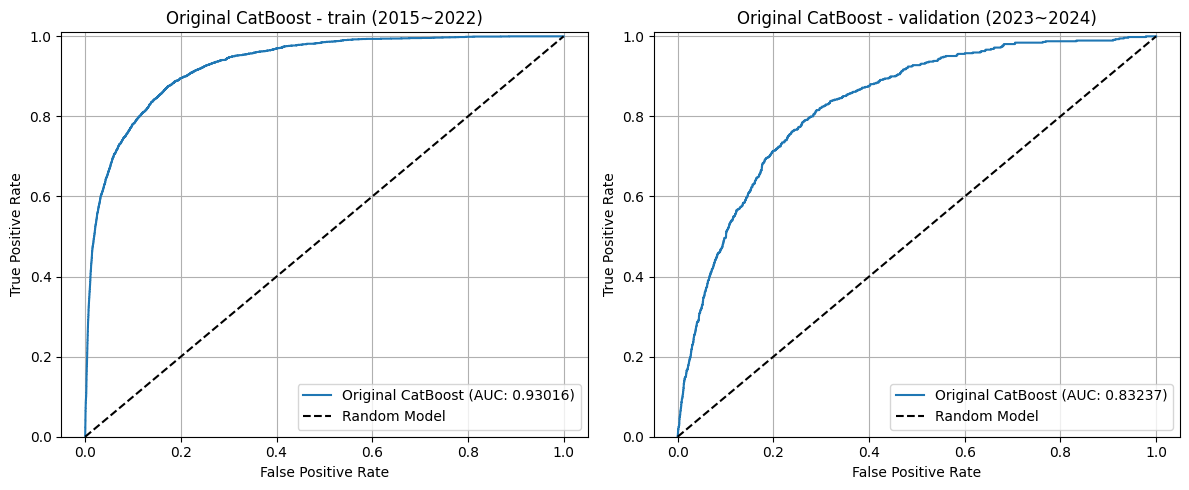

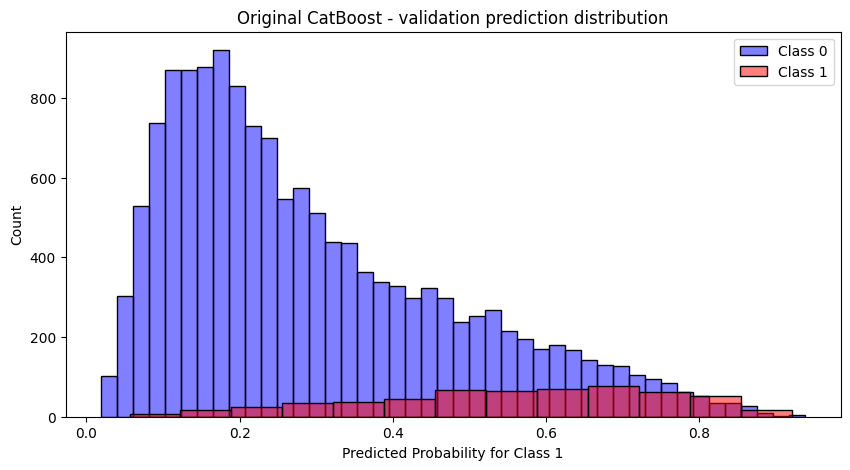


Original CatBoost - Feature Importance:
              feature  importance
4              VKOSPI   50.206320
3               MONTH   11.176117
1    PRICE_TO_52W_LOW    6.879710
5     FN_ACML_TR_PBMN    4.599579
8                 PSR    3.766473
0   PRICE_TO_52W_HIGH    3.084741
9                 ROE    2.690938
18                F71    2.685230
17                F70    2.478697
14                PER    1.771353
16             FTRUTH    1.762376
10            ROE_INC    1.592853
15                ICR    1.357031
6       ORGN_NTBY_QTY    1.278927
13    DEBT_DEPENDENCY    1.275694
11           NET_DEBT    1.196674
7                  DR    1.152204
12          DEBT_COST    1.020189
2   SCRT_GRP_CLS_CODE    0.024895

[검증 세트] Target Distribution:
  Class 0: 14515 samples
  Class 1: 570 samples

[Test Set] 맞은 종목과 틀린 종목 개수:
Correct
True     12526
False     2559
Name: count, dtype: int64

[정답 그룹] 각 feature의 기술 통계량:
       PRICE_TO_52W_HIGH  PRICE_TO_52W_LOW  SCRT_GRP_CLS_CODE         MONTH  \
c

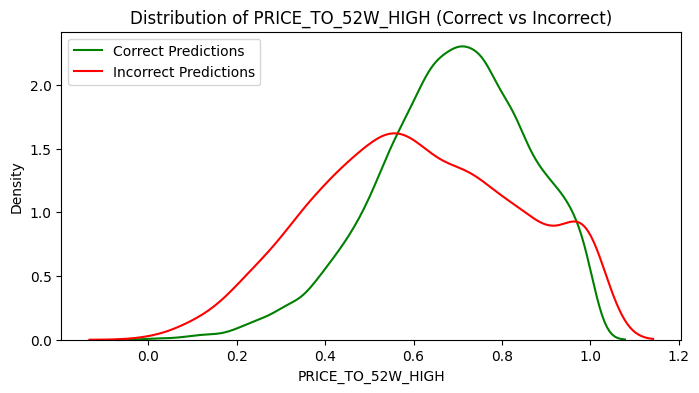

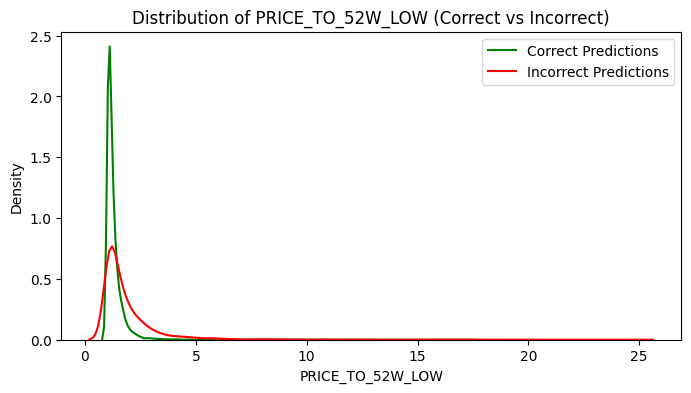

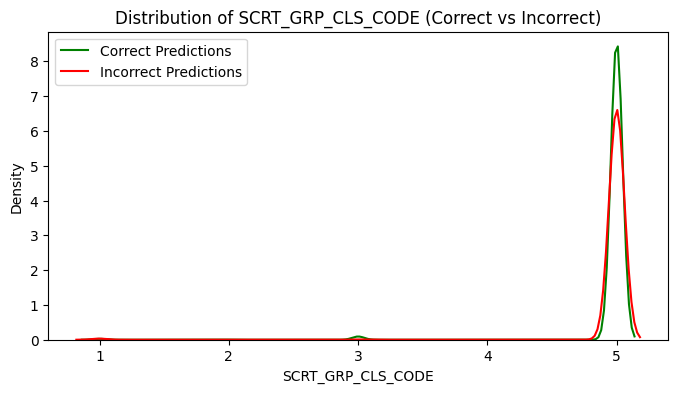

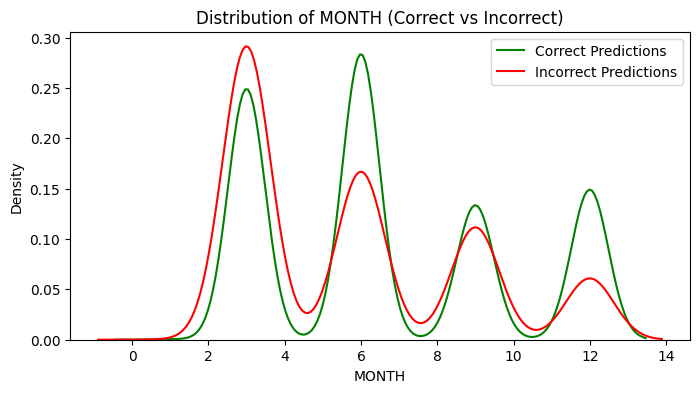

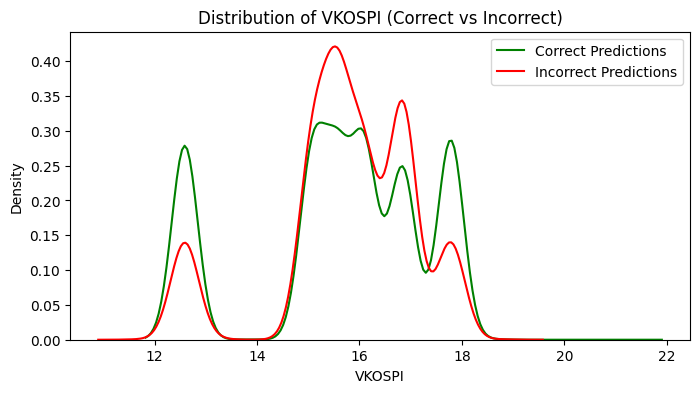

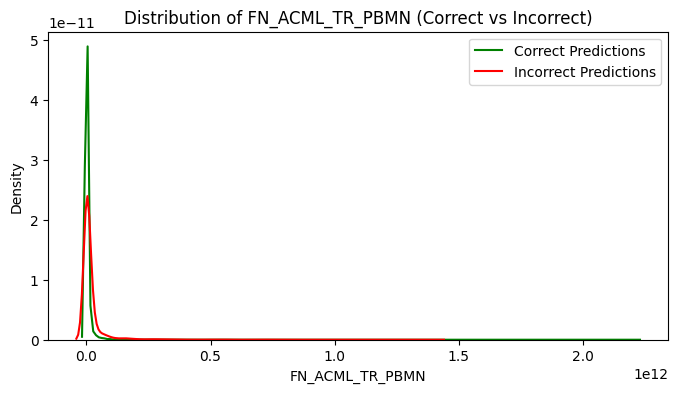

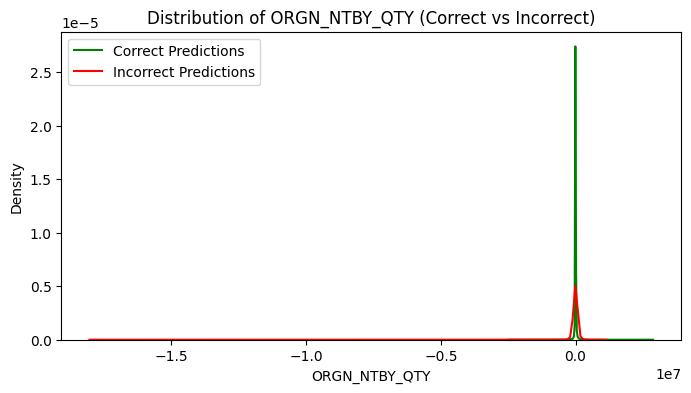

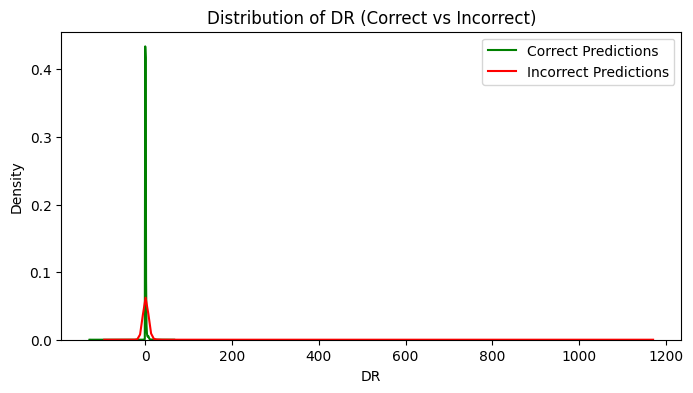

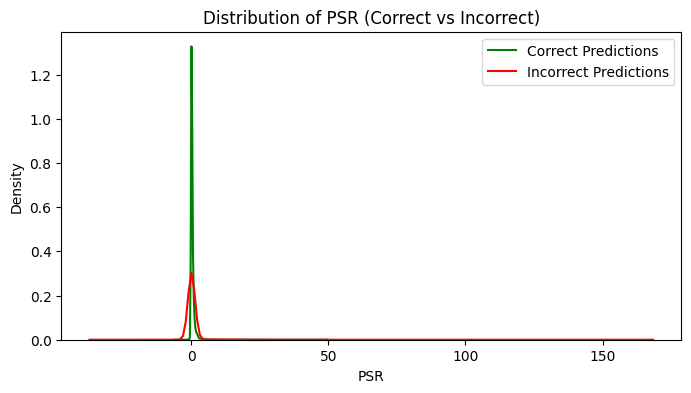

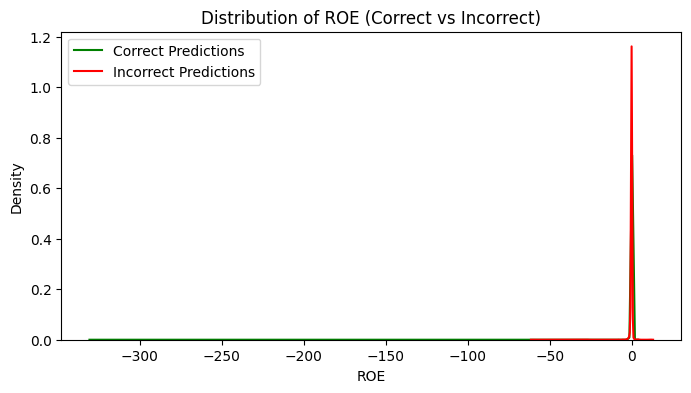

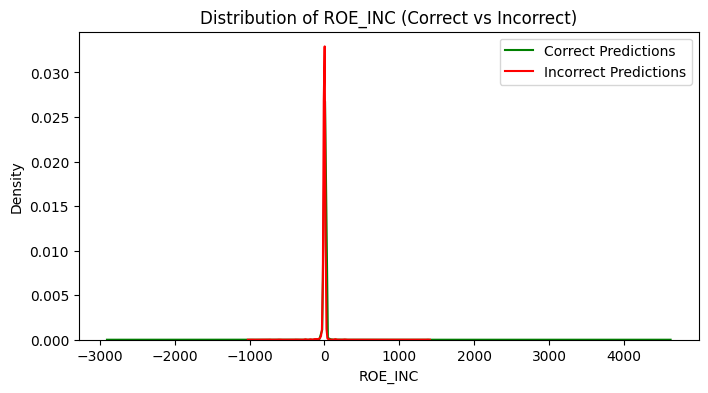

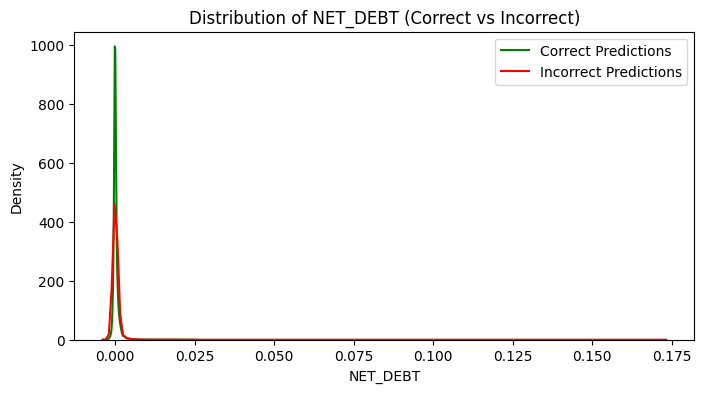

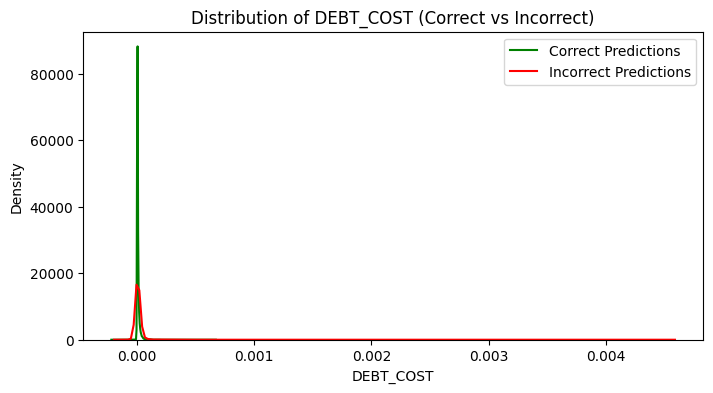

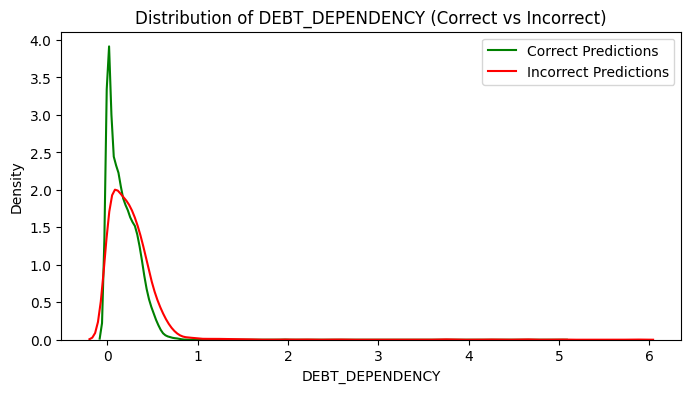

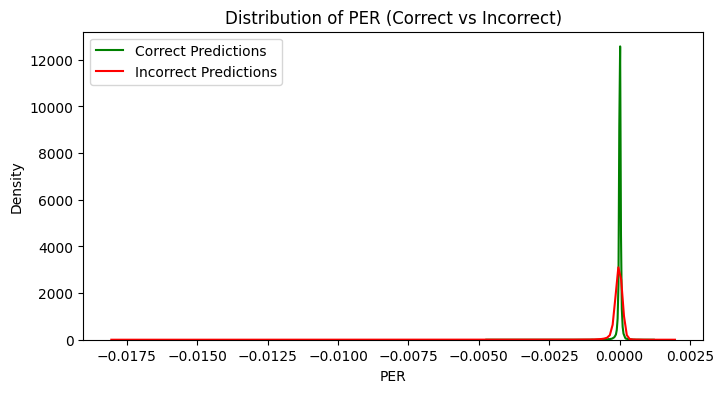

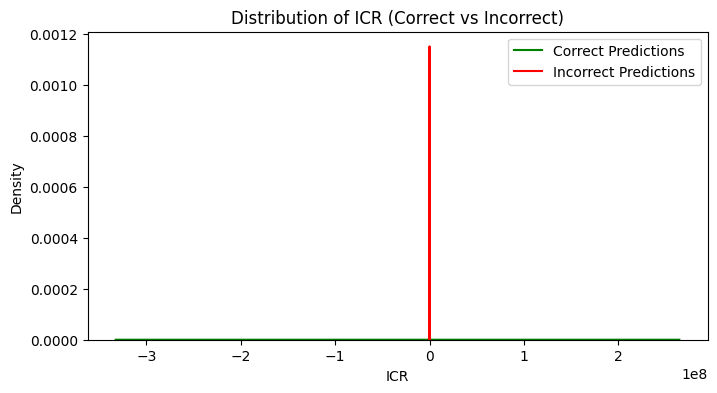

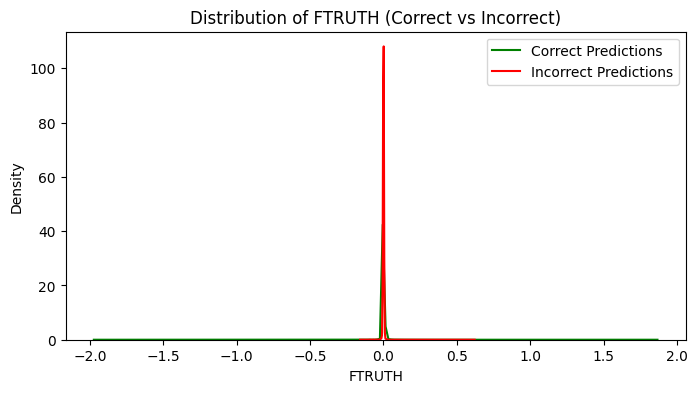

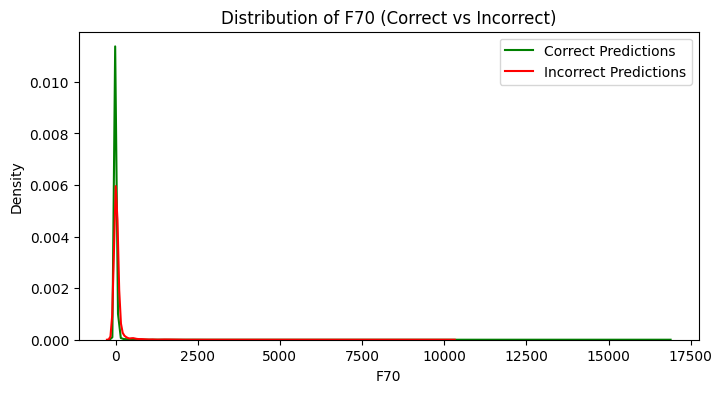

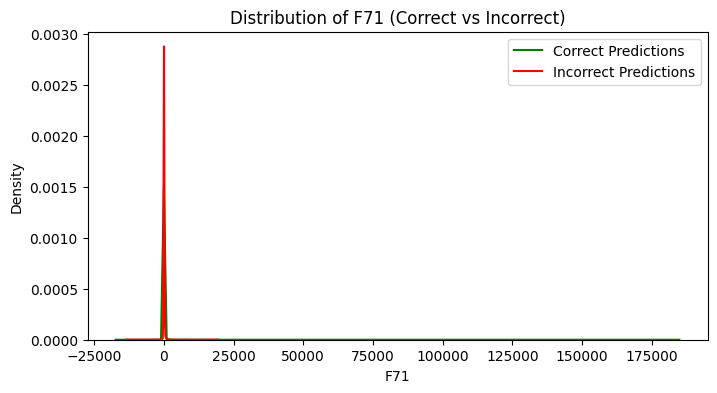


[Roll] Train: 2015~2019, Val: 2020, Test: [2021]
0:	test: 0.5791835	best: 0.5791835 (0)	total: 9.59ms	remaining: 1m 35s
100:	test: 0.8135334	best: 0.8352859 (33)	total: 1.19s	remaining: 1m 56s
200:	test: 0.8113213	best: 0.8352859 (33)	total: 2.37s	remaining: 1m 55s
300:	test: 0.8170047	best: 0.8352859 (33)	total: 3.3s	remaining: 1m 46s
400:	test: 0.8188757	best: 0.8352859 (33)	total: 4.41s	remaining: 1m 45s
500:	test: 0.8177437	best: 0.8352859 (33)	total: 5.39s	remaining: 1m 42s
600:	test: 0.8163523	best: 0.8352859 (33)	total: 6.41s	remaining: 1m 40s
700:	test: 0.8170459	best: 0.8352859 (33)	total: 7.69s	remaining: 1m 42s
800:	test: 0.8165167	best: 0.8352859 (33)	total: 8.96s	remaining: 1m 42s
900:	test: 0.8172326	best: 0.8352859 (33)	total: 10.2s	remaining: 1m 42s
1000:	test: 0.8189145	best: 0.8352859 (33)	total: 11.3s	remaining: 1m 41s
Stopped by overfitting detector  (1000 iterations wait)

bestTest = 0.8352858606
bestIteration = 33

Shrink model to first 34 iterations.
-> Test AUC

In [ ]:
# 필요한 numpy 버전 지정

import subprocess
import sys
import numpy as np
from packaging import version  # ← 이 부분이 누락됨
required_version = "1.26.4"

# 현재 numpy 버전 확인 (예: 2.2.4는 호환되지 않음)
if version.parse(np.__version__) >= version.parse("2.0.0"):
    print(f"현재 numpy 버전: {np.__version__} - 호환되지 않습니다. {required_version}로 재설치합니다.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"numpy=={required_version}"])
    print("재설치 완료. 런타임을 재시작하세요.")
else:
    print("numpy 버전이 호환됩니다.")


!pip install catboost
from catboost import CatBoostClassifier

import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# 파일 경로 설정
file_path = "/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_fin_result_with_vkospi_all.parquet"

# 중요도가 높은 특성만 선택
features = [
    'PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW', 'SCRT_GRP_CLS_CODE',
    #'SEASONALITY',
    'MONTH',
    #'YEAR',
    'VKOSPI',   #'ks200',
    #'PRDY_VRSS_SIGN',
    #'MARKET_CAP',
    'FN_ACML_TR_PBMN',
    'ORGN_NTBY_QTY',
    'DR', 'PSR', 'ROE', 'ROE_INC',
    'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH',
    'F70', 'F71',  #   '자본금증가율(YoY)': 'F70','총자본증가율(YoY)': 'F71',
    #,'F8','F9','F10','F11','F12','F13','F14','F15','F16','F17','F18','F19','F20','F21',
]
target = 'windowdrop'

try:
    # 데이터 로드
    df = pd.read_parquet(file_path)
    # BSOP_DATE 컬럼을 datetime 형식으로 변환
    df['BSOP_DATE'] = pd.to_datetime(df['BSOP_DATE'], errors='coerce')

    #계절성 반영
    #df['MONTH'] = df['BSOP_DATE'].dt.month
    df['MONTH'] = df['BSOP_DATE'].dt.month
    #df['SEASONALITY'] = np.sin(2 * np.pi * df['BSOP_DATE'].dt.month / 12)

    #간접적 시간가중치 반영
    #df['YEAR'] = (df['BSOP_DATE'].dt.year-2020)

    # ROE 값이 없는 종목 제거
    # roe_missing_stocks = df[df['ROE'].isna()]['SHRN_ISCD'].unique()
    # df = df[~df['SHRN_ISCD'].isin(roe_missing_stocks)].copy()
    # print(f"ROE 결측 종목 제거 후 {len(df['SHRN_ISCD'].unique())}개 종목 데이터 남음.")

    # 1) 종목별로 ROE non-null 개수를 구해서
    non_missing_counts = df.groupby('SHRN_ISCD')['ROE'].transform('count')
    # 2) non_missing_counts > 0 인 종목만 남기기
    df = df[non_missing_counts > 0].copy()
    print(f"ROE가 한 번도 존재하지 않는 종목 제외 후 {df['SHRN_ISCD'].nunique()}개 종목 데이터 남음.")


    #라벨 인코더
    le_scrt = LabelEncoder()
    le_mrkt = LabelEncoder()
    df['SCRT_GRP_CLS_CODE'] = le_scrt.fit_transform(df['SCRT_GRP_CLS_CODE'].astype(str))
    df['MRKT_DIV_CLS_CODE'] = le_mrkt.fit_transform(df['MRKT_DIV_CLS_CODE'].astype(str))

    # 재무데이터와 결과데이터가 있는 구간까지만 (예: 2024-07-01 이전까지만)
    df = df[df['BSOP_DATE'] < '2024-07-01']

    #코로나 기간 제외
    # df = df[df['BSOP_DATE'] != '2020-09-30']
    # df = df[df['BSOP_DATE'] != '2020-06-30']
    # df = df[df['BSOP_DATE'] != '2020-03-31']
    # df = df[df['BSOP_DATE'] != '2019-12-31']

    # Feature Engineering
    df.loc[:, 'PRICE_TO_52W_HIGH'] = df['STCK_PRPR'] / df['W52_HGPR']
    df.loc[:, 'PRICE_TO_52W_LOW'] = df['STCK_PRPR'] / df['W52_LWPR']
    df.loc[:, 'PER'] = df['NET_INCOME'] / df['MARKET_CAP']
    df.loc[:, 'PSR'] = df['PS'] / df['STCK_PRPR']
    df.loc[:, 'FTRUTH'] = df['PS'] / df['NET_INCOME']

    df.loc[:, 'NET_DEBT'] = df['NET_DEBT'] / df['MARKET_CAP']
    df.loc[:, 'DEBT_COST'] = df['DEBT_COST'] / df['MARKET_CAP']
    #df.loc[:, 'ORGN_NTBY_QTY'] = df['ORGN_NTBY_QTY'] / df['MARKET_CAP']
    #df.loc[:, 'FN_ACML_TR_PBMN'] = df['FN_ACML_TR_PBMN'] / df['MARKET_CAP']



    # 데이터 분할 (시계열 특성 고려)
    train_df = df[df['BSOP_DATE'].dt.year < 2023]  # 학습: 2015~2022
    test_df = df[df['BSOP_DATE'].dt.year >= 2023]  # 검증: 2023~2024 상반기

    X_train, y_train = train_df[features], train_df[target]
    X_test, y_test = test_df[features], test_df[target]

    # 클래스 불균형 확인
    print("원본 학습 데이터의 클래스 분포:")
    print(y_train.value_counts())

    # 기존 CatBoost와 GAN 적용 CatBoost의 성능을 비교하기 위한 함수
    def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
        # 예측 확률
        y_train_pred_proba = model.predict_proba(X_train)[:, 1]
        y_test_pred_proba = model.predict_proba(X_test)[:, 1]

        # ROC AUC 계산
        roc_auc_train = roc_auc_score(y_train, y_train_pred_proba)
        roc_auc_test = roc_auc_score(y_test, y_test_pred_proba)

        print(f"\n[{model_name} - 학습 데이터 AUC] {roc_auc_train:.5f}")
        print(f"[{model_name} - 검증 데이터 AUC] {roc_auc_test:.5f}")

        # ROC 곡선 시각화
        fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
        fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)

        plt.figure(figsize=(12, 5))

        # 왼쪽: 학습 ROC
        plt.subplot(1, 2, 1)
        plt.plot(fpr_train, tpr_train, label=f"{model_name} (AUC: {roc_auc_train:.5f})")
        plt.plot([0,1], [0,1], '--', color='black', label='Random Model')
        plt.title(f"{model_name} - train (2015~2022)")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc='lower right')
        plt.ylim([0,1.01])

        # 오른쪽: 검증 ROC
        plt.subplot(1, 2, 2)
        plt.plot(fpr_test, tpr_test, label=f"{model_name} (AUC: {roc_auc_test:.5f})")
        plt.plot([0,1], [0,1], '--', color='black', label='Random Model')
        plt.title(f"{model_name} - validation (2023~2024)")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc='lower right')
        plt.ylim([0,1.01])

        plt.tight_layout()
        plt.show()

        # 예측 확률 분포 시각화
        plt.figure(figsize=(10,5))
        sns.histplot(y_test_pred_proba[y_test == 0], label='Class 0', color='blue', alpha=0.5)
        sns.histplot(y_test_pred_proba[y_test == 1], label='Class 1', color='red', alpha=0.5)
        plt.legend()
        plt.xlabel('Predicted Probability for Class 1')
        plt.ylabel('Count')
        plt.title(f"{model_name} - validation prediction distribution")
        plt.show()

        # 특성 중요도 출력
        feature_importance = pd.DataFrame({'feature': features, 'importance': model.feature_importances_})
        print(f"\n{model_name} - Feature Importance:")
        print(feature_importance.sort_values('importance', ascending=False))

        return roc_auc_test

    def evaluate_model_style(model, X_train, y_train, X_test, y_test, model_name="Model"):
        # 예측 확률
        y_train_pred_proba = model.predict_proba(X_train)[:, 1]
        y_test_pred_proba = model.predict_proba(X_test)[:, 1]

        # ROC AUC 계산
        roc_auc_train = roc_auc_score(y_train, y_train_pred_proba)
        roc_auc_test = roc_auc_score(y_test, y_test_pred_proba)

        print(f"\n[{model_name} - 학습 데이터 AUC] {roc_auc_train:.5f}")
        print(f"[{model_name} - 검증 데이터 AUC] {roc_auc_test:.5f}")

        # ROC 곡선 데이터 생성
        fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
        fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)

        # --- ROC 곡선 시각화 (스타일 수정) ---
        plt.figure(figsize=(12, 5))

        # 왼쪽: 학습 ROC
        plt.subplot(1, 2, 1)
        plt.plot(fpr_train, tpr_train, label=f"{model_name} (AUC: {roc_auc_train:.5f})")
        plt.plot([0,1], [0,1], 'k--', label='Random Model') # 'k--' 스타일 적용 (검정색 점선)
        plt.title(f"{model_name} - train (2015~2022)")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc='lower right')
        plt.grid(True) # 격자 추가
        plt.ylim([0,1.01])

        # 오른쪽: 검증 ROC
        plt.subplot(1, 2, 2)
        plt.plot(fpr_test, tpr_test, label=f"{model_name} (AUC: {roc_auc_test:.5f})")
        plt.plot([0,1], [0,1], 'k--', label='Random Model') # 'k--' 스타일 적용 (검정색 점선)
        plt.title(f"{model_name} - validation (2023~2024)")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc='lower right')
        plt.grid(True) # 격자 추가
        plt.ylim([0,1.01])

        plt.tight_layout() # 그래프 간 간격 자동 조정
        plt.show()
        # --- 시각화 수정 끝 ---

        # 예측 확률 분포 시각화 (기존 코드 유지)
        plt.figure(figsize=(10,5))
        sns.histplot(y_test_pred_proba[y_test == 0], label='Class 0', color='blue', alpha=0.5)
        sns.histplot(y_test_pred_proba[y_test == 1], label='Class 1', color='red', alpha=0.5)
        plt.legend()
        plt.xlabel('Predicted Probability for Class 1')
        plt.ylabel('Count')
        plt.title(f"{model_name} - validation prediction distribution")
        plt.show()

        # --- 특성 중요도 출력 (사용자 원본 코드 유지) ---
        # !! 주의: 이 코드는 'features' 리스트가 함수 호출 전에 정의되어 있고,
        # !!        'model' 객체가 'feature_importances_' 속성을 가지고 있다고 가정합니다.
        # !!        만약 해당 조건이 충족되지 않으면 오류가 발생할 수 있습니다.
        feature_importance = pd.DataFrame({'feature': features, 'importance': model.feature_importances_})
        print(f"\n{model_name} - Feature Importance:")
        print(feature_importance.sort_values('importance', ascending=False))
        # --- 특성 중요도 코드 끝 ---

        return roc_auc_test

    # 클래스 불균형 처리를 위한 가중치 계산
    scale = 1
    class_ratio = (y_train == 0).sum() / (y_train == 1).sum()
    class_weights = {0: 1, 1: class_ratio * scale}

    # 1. 원본 데이터로 CatBoost 학습 (기존 코드)
    # CatBoost Pool 객체 생성
    train_pool = Pool(X_train, y_train)
    eval_pool = Pool(X_test, y_test)

    print("\n=== 원본 데이터로 CatBoost 학습 ===")

    #0.855/ 0.957
    # cat = CatBoostClassifier(
    #     iterations=10000,
    #     depth=5,
    #     learning_rate=0.01,
    #     random_seed=42,
    #     verbose=100,
    #     loss_function='Logloss',
    #     class_weights=class_weights,
    #     early_stopping_rounds=1000,
    #     l2_leaf_reg=100,
    #     random_strength=50,
    #     # bootstrap_type='Bernoulli',
    #     # subsample=0.7,
    #     bootstrap_type='Bayesian',  # Bernoulli -> Bayesian으로 변경
    #     bagging_temperature=10.0,    # Bayesian에 맞는 파라미터 추가 (기본값 1.0)
    #     eval_metric='AUC',
    #     use_best_model=True
    # )
    cat = CatBoostClassifier(
        iterations=5000,
        depth=7,
        learning_rate=0.01,
        random_seed=42,
        verbose=100,
        loss_function='Logloss',
        class_weights=class_weights,
        early_stopping_rounds=500,
        l2_leaf_reg=100,
        random_strength=10,
        # bootstrap_type='Bernoulli',
        # subsample=0.8,
        bootstrap_type='Bayesian',  # Bernoulli -> Bayesian으로 변경
        bagging_temperature=10.0,    # Bayesian에 맞는 파라미터 추가 (기본값 1.0)
        eval_metric='AUC',
        use_best_model=True,

    )


    print("Training original CatBoost...")
    cat.fit(train_pool, eval_set=eval_pool, verbose=100   )
    print("Original CatBoost trained.")

    # 원본 모델 평가
    original_auc = evaluate_model_style(cat, X_train, y_train, X_test, y_test, "Original CatBoost")

    # 타겟 분포 확인 (검증 세트)
    unique, counts = np.unique(y_test, return_counts=True)
    print("\n[검증 세트] Target Distribution:")
    for val, cnt in zip(unique, counts):
        print(f"  Class {val}: {cnt} samples")


    # 6. 모델 예측 결과를 기반으로 "맞은" 종목과 "틀린" 종목의 feature 특성 분석

    # 테스트 세트에 대한 예측값 생성 (원본 CatBoost 모델 사용)
    y_test_pred = cat.predict(X_test)

    # 테스트 데이터에 실제 label, 예측 label, 정답 여부 추가
    test_analysis_df = X_test.copy()
    test_analysis_df['Actual'] = y_test.values
    test_analysis_df['Predicted'] = y_test_pred
    test_analysis_df['Correct'] = test_analysis_df['Actual'] == test_analysis_df['Predicted']

    # 맞은 종목과 틀린 종목의 개수 출력
    print("\n[Test Set] 맞은 종목과 틀린 종목 개수:")
    print(test_analysis_df['Correct'].value_counts())

    # 맞은 종목과 틀린 종목의 기술 통계량 출력
    print("\n[정답 그룹] 각 feature의 기술 통계량:")
    print(test_analysis_df[test_analysis_df['Correct'] == True][features].describe())

    print("\n[오답 그룹] 각 feature의 기술 통계량:")
    print(test_analysis_df[test_analysis_df['Correct'] == False][features].describe())

    # 각 feature별 분포 시각화 (맞은 vs 틀린)
    for feature in features:
        plt.figure(figsize=(8, 4))
        sns.kdeplot(data=test_analysis_df[test_analysis_df['Correct'] == True], x=feature,
                    label='Correct Predictions', color='green')
        sns.kdeplot(data=test_analysis_df[test_analysis_df['Correct'] == False], x=feature,
                    label='Incorrect Predictions', color='red')
        plt.title(f'Distribution of {feature} (Correct vs Incorrect)')
        plt.xlabel(feature)
        plt.ylabel('Density')
        plt.legend()
        plt.show()

except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")


valid_rolls = [
    (2016, 2018, 2019, 2021),
    (2017, 2019, 2021, 2022)
]

def fixed_roll_evaluation(df, features, target):
    # 명시적으로 원하는 구간만 지정
    valid_rolls = [
        (2015, 2019, 2020, [2021]),  # Train: 2016~2018, Val: 2019, Test: 2021
        (2016, 2020, 2021, [2022]),  # Train: 2016~2018, Val: 2019, Test: 2021
        (2017, 2021, 2022, [2023]),  # Train: 2016~2018, Val: 2019, Test: 2021
        (2018, 2022, 2023, [2024]),  # Train: 2016~2018, Val: 2019, Test: 2021
    ]

    results = []

    for train_start, train_end, val_year, test_year in valid_rolls:
        print(f"\n[Roll] Train: {train_start}~{train_end}, Val: {val_year}, Test: {test_year}")

        # 데이터 분리
        train_df = df[(df['BSOP_DATE'].dt.year >= train_start) & (df['BSOP_DATE'].dt.year <= train_end)]
        val_df = df[df['BSOP_DATE'].dt.year == val_year]
        test_df = df[df['BSOP_DATE'].dt.year.isin(test_year)]

        if len(train_df) == 0 or len(val_df) == 0 or len(test_df) == 0:
            print("-> 데이터 부족으로 스킵")
            continue

        X_train, y_train = train_df[features], train_df[target]
        X_val, y_val = val_df[features], val_df[target]
        X_test, y_test = test_df[features], test_df[target]

        # 클래스 가중치
        class_ratio = (y_train == 0).sum() / (y_train == 1).sum()
        class_weights = {0: 1, 1: class_ratio}

        model = CatBoostClassifier(
            iterations=10000,
            depth=7,
            learning_rate=0.01,
            random_seed=42,
            verbose=100,
            loss_function='Logloss',
            class_weights=class_weights,
            early_stopping_rounds=1000,
            l2_leaf_reg=100,
            random_strength=50,
            # bootstrap_type='Bernoulli',
            # subsample=0.8,
            bootstrap_type='Bayesian',  # Bernoulli -> Bayesian으로 변경
            bagging_temperature=10.0,    # Bayesian에 맞는 파라미터 추가 (기본값 1.0)
            eval_metric='AUC',
            use_best_model=True,
        )

        model.fit(Pool(X_train, y_train), eval_set=Pool(X_val, y_val))

        y_test_pred_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_test_pred_proba)

        print(f"-> Test AUC: {roc_auc:.4f}")

        results.append({
            'train_year': f'{train_start}-{train_end}',
            'val_year': f'{val_year}',
            'test_year': f'{test_year}',
            'test_auc': roc_auc
        })

    return pd.DataFrame(results)


# 실행 (예시)
results_df = fixed_roll_evaluation(df_eval, features_for_eval, target_for_eval




Successfully loaded data from Parquet files.
Stock DF Columns: ['BSOP_DATE', 'STND_ISCD', 'SHRN_ISCD', 'SCRT_GRP_CLS_CODE', 'MRKT_DIV_CLS_CODE', 'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR', 'FN_ACML_TR_PBMN', 'CRDT_RMND_RATE', 'MARKET_CAP', 'FRGN_HLDN_RATE', 'FRGN_NTBY_QTY', 'ORGN_NTBY_QTY', 'vkospi', 'ks200', 'fx']
Using Fin Features: ['PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW', 'SCRT_GRP_CLS_CODE', 'MONTH', 'VKOSPI', 'FN_ACML_TR_PBMN', 'ORGN_NTBY_QTY', 'DR', 'PSR', 'ROE', 'ROE_INC', 'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH', 'F70', 'F71']
Starting sequence generation...
Finished sequence generation. Processed: 80701, Skipped (short seq): 2812, Skipped (no today data): 0
stock_series_data.shape : (80701, 60, 1)
stock_current_data.shape: (80701, 1)
fin_series_data.shape   : (80701, 19)
matched_targets.shape : (80701,)
dates.shape           : (80701,)
Train sequence shape (before scaling): (65806, 60, 1)
Test sequence shape (before scaling): (14895, 60, 1)
Trai

<ipython-input-13-224b4e2214ad>:34: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  try: return stats.skew(a)
<ipython-input-13-224b4e2214ad>:37: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  try: return stats.kurtosis(a)


Calculating Wavelet features using: wavelet='db4', level=3, stats=['energy', 'std', 'skew', 'kurt']
Finished calculating wavelet features. Shape: (65806, 16)
Calculating standard deviations...
Finished calculating standard deviations.
train_stat_features (wavelet+std).shape: (65806, 17)
test_stat_features (wavelet+std).shape : (14895, 17)

--- Section 12: Preparing Features for CatBoost using Wavelet Features ---
Include Statistical Features (Wavelet Features + Std) in CatBoost Features: True
train_features.shape: (65806, 36)
test_features.shape : (14895, 36)
Calculated scale_pos_weight: 18.6906

--- Scaling Combined Features for All Models ---

--- Starting CatBoost Training ---
0:	test: 0.6756902	best: 0.6756902 (0)	total: 35.7ms	remaining: 2m 58s
100:	test: 0.7937270	best: 0.7937270 (100)	total: 3.08s	remaining: 2m 29s
200:	test: 0.8000953	best: 0.8005471 (193)	total: 6.14s	remaining: 2m 26s
300:	test: 0.8035168	best: 0.8036982 (292)	total: 9.37s	remaining: 2m 26s
400:	test: 0.80764

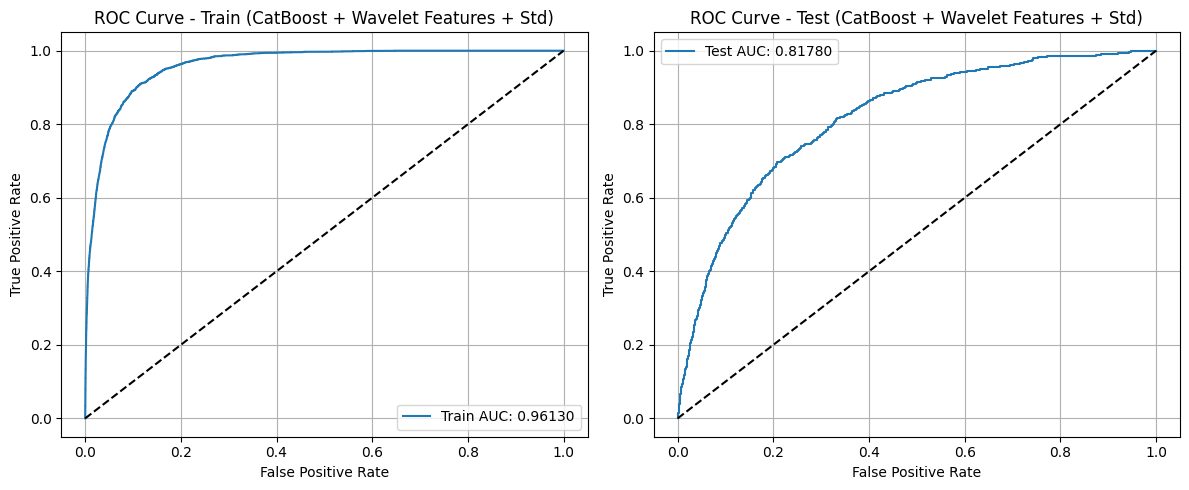

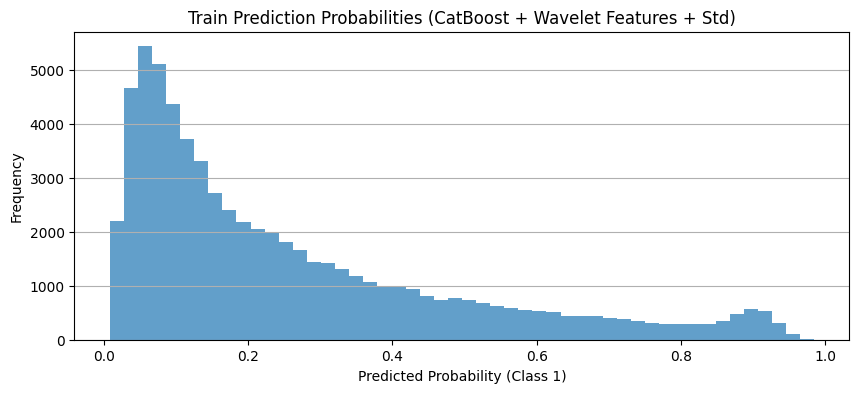

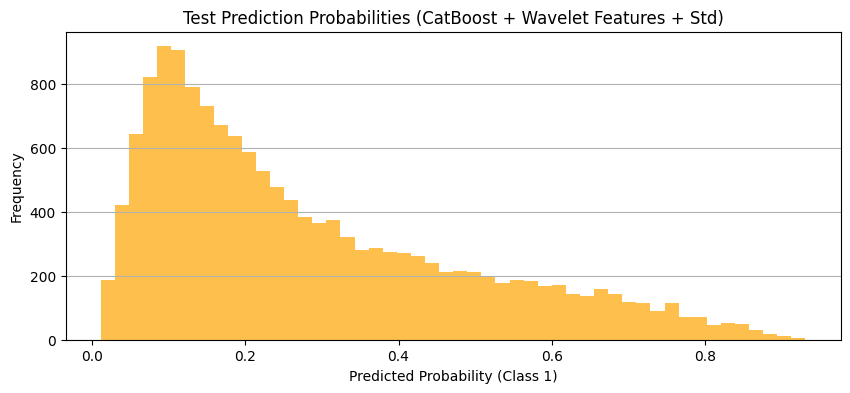


[Roll] Train: 2015~2019, Val: 2020, Test: [2021]
0:	test: 0.6553907	best: 0.6553907 (0)	total: 26.1ms	remaining: 4m 21s
100:	test: 0.7905734	best: 0.7916160 (98)	total: 2.74s	remaining: 4m 28s
200:	test: 0.8131626	best: 0.8138848 (198)	total: 5.53s	remaining: 4m 29s


KeyboardInterrupt: 

In [ ]:
import pandas as pd
import numpy as np
# Tensorflow / Keras Imports - Modify for Transformer (Keep TF for seed)
import tensorflow as tf
# from tensorflow.keras.models import Model # No longer needed for AE
# >>> MODIFICATION START: Remove Transformer/AE specific layers <<<
# from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D, TimeDistributed, Reshape, Embedding
# >>> MODIFICATION END <<<
# from tensorflow.keras.optimizers import Adam # No longer needed for AE
# from tensorflow.keras.callbacks import EarlyStopping # No longer needed for AE
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
# >>> MODIFICATION START: Import specific scipy modules if needed (stats already used later) <<<
from scipy import stats # For skew, kurtosis if added later
# 라인 15: pywt 라이브러리 import 추가
import pywt
# >>> MODIFICATION END <<<

# CatBoost
# !pip install catboost imblearn pywavelets # imblearn은 이제 필요 없음, pywavelets 설치 필요
from catboost import CatBoostClassifier
# from imblearn.over_sampling import RandomOverSampler # 삭제

# >>> MODIFICATION START: Helper function replaced with wavelet feature calculation <<<
# 라인 18-39: calculate_poly_coeffs 함수를 calculate_wavelet_features 함수로 교체
def calculate_wavelet_features(sequences, wavelet='db4', level=3, feature_stats=['energy', 'std', 'skew', 'kurt']):
    """Calculates statistical features from DWT coefficients for each sequence."""
    n_samples, _, n_features = sequences.shape
    feature_list = []

    # Define stats functions safely
    def safe_skew(a):
        try: return stats.skew(a)
        except ValueError: return 0
    def safe_kurtosis(a):
        try: return stats.kurtosis(a)
        except ValueError: return 0
    def safe_std(a):
        try: return np.std(a)
        except ValueError: return 0
    def safe_energy(a):
        return np.sum(a**2)
    def safe_entropy(a):
      try:
        sq_coeffs = a**2
        coeff_sum = np.sum(sq_coeffs)
        if coeff_sum == 0: return 0
        probs = sq_coeffs / coeff_sum
        return stats.entropy(probs)
      except ValueError: return 0

    stat_funcs = {'energy': safe_energy, 'std': safe_std, 'skew': safe_skew, 'kurt': safe_kurtosis, 'entropy': safe_entropy}
    valid_feature_stats = [s for s in feature_stats if s in stat_funcs] # Ensure only valid stats are used

    print(f"Calculating Wavelet features using: wavelet='{wavelet}', level={level}, stats={valid_feature_stats}")

    for i in range(n_samples):
        sample_features = []
        for j in range(n_features):
            sequence = sequences[i, :, j]
            sequence = np.nan_to_num(sequence) # Ensure no NaNs/Infs before DWT

            try:
                # Perform multilevel DWT
                coeffs = pywt.wavedec(sequence, wavelet, level=level) # List: [cA_n, cD_n, ..., cD_1]

                # Calculate stats for each coefficient array
                for coeff_array in coeffs:
                    if len(coeff_array) == 0: # Handle potential empty arrays
                       for stat_name in valid_feature_stats:
                           sample_features.append(0)
                       continue

                    for stat_name in valid_feature_stats:
                        func = stat_funcs[stat_name]
                        stat_value = func(coeff_array)
                        sample_features.append(stat_value)

            except Exception as e:
                print(f"Warning: Wavelet decomposition failed for sample {i}, feature {j}. Error: {e}. Appending zeros.")
                # Calculate expected number of features per stock feature
                num_coeff_arrays = level + 1
                num_expected_features = num_coeff_arrays * len(valid_feature_stats)
                sample_features.extend([0] * num_expected_features) # Append zeros if DWT fails

        feature_list.append(sample_features)

    return np.array(feature_list)
# >>> MODIFICATION END <<<
# --------------------------------------------


############################################################
# 1) 파일 로드 (변경 없음)
############################################################
# 경로를 실제 환경에 맞게 수정해야 합니다.
try:
    stock_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet')
    fin_df   = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_fin_result_with_vkospi_all.parquet')
    print("Successfully loaded data from Parquet files.")
except FileNotFoundError:
    print("Warning: Parquet files not found. Please ensure the path is correct or provide dummy data.")
    pass # Allow the script to continue, potentially failing later if files are truly missing.


############################################################
# 2) 날짜 전처리 (변경 없음)
############################################################
stock_df['BSOP_DATE'] = pd.to_datetime(stock_df['BSOP_DATE'], errors='coerce')
fin_df['BSOP_DATE']   = pd.to_datetime(fin_df['BSOP_DATE'],   errors='coerce')

# 2024-07-01 이전 데이터
stock_df = stock_df[stock_df['BSOP_DATE'] < '2024-07-01'].copy()
fin_df   = fin_df[fin_df['BSOP_DATE']   < '2024-07-01'].copy()

############################################################
# 3) ROE 결측치 제거 및 피처 생성 (변경 없음)
############################################################
mask_fin = fin_df.groupby('SHRN_ISCD')['ROE'].transform('count') > 0
fin_df = fin_df[mask_fin].copy()
valid_codes = fin_df['SHRN_ISCD'].unique()
stock_df = stock_df[stock_df['SHRN_ISCD'].isin(valid_codes)].copy()
print("Stock DF Columns:", stock_df.columns.tolist())
fin_df = fin_df.dropna(subset=['windowdrop']).copy()
fin_df['MONTH'] = fin_df['BSOP_DATE'].dt.month
fin_df.loc[:, 'PRICE_TO_52W_HIGH'] = fin_df['STCK_PRPR'] / fin_df['W52_HGPR']
fin_df.loc[:, 'PRICE_TO_52W_LOW'] = fin_df['STCK_PRPR'] / fin_df['W52_LWPR']
fin_df.loc[:, 'PER'] = fin_df['NET_INCOME'] / fin_df['MARKET_CAP']
fin_df.loc[:, 'PSR'] = fin_df['PS'] / fin_df['STCK_PRPR']
fin_df.loc[:, 'FTRUTH'] = fin_df['PS'] / fin_df['NET_INCOME']
fin_df.loc[:, 'NET_DEBT'] = fin_df['NET_DEBT'] / fin_df['MARKET_CAP']
fin_df.loc[:, 'DEBT_COST'] = fin_df['DEBT_COST'] / fin_df['MARKET_CAP']
le_scrt = LabelEncoder()
le_mrkt = LabelEncoder()
fin_df['SCRT_GRP_CLS_CODE'] = fin_df['SCRT_GRP_CLS_CODE'].astype(str)
fin_df['MRKT_DIV_CLS_CODE'] = fin_df['MRKT_DIV_CLS_CODE'].astype(str)
fin_df['SCRT_GRP_CLS_CODE'] = le_scrt.fit_transform(fin_df['SCRT_GRP_CLS_CODE'])
fin_df['MRKT_DIV_CLS_CODE'] = le_mrkt.fit_transform(fin_df['MRKT_DIV_CLS_CODE'])

############################################################
# 4) 주요 설정값 (변경 없음)
############################################################
sequence_length = 60
stock_features = [
    'STCK_PRPR',
    #'vkospi',
]
n_stock_features = len(stock_features)
fin_features = [
    'PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW', 'SCRT_GRP_CLS_CODE',
    'MONTH', 'VKOSPI',
    'FN_ACML_TR_PBMN', 'ORGN_NTBY_QTY', 'DR', 'PSR', 'ROE', 'ROE_INC',
    'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH', 'F70', 'F71',
]
fin_features = [f for f in fin_features if f in fin_df.columns]
print("Using Fin Features:", fin_features)

############################################################
# 5) 시퀀스 데이터 생성 (변경 없음)
############################################################
stock_series_data   = []
stock_current_data = []
fin_series_data     = []
matched_targets     = []
dates               = []
stock_groups = stock_df.groupby('SHRN_ISCD')
fin_df = fin_df.replace([np.inf, -np.inf], np.nan)
stock_df = stock_df.replace([np.inf, -np.inf], np.nan)
fin_df.fillna(0, inplace=True)
stock_df.fillna(0, inplace=True)
print("Starting sequence generation...")
processed_count = 0
skipped_short_seq = 0
skipped_no_today = 0
for stock_code, fin_group in fin_df.groupby('SHRN_ISCD'):
    if stock_code not in stock_groups.groups: continue
    stock_history_group = stock_groups.get_group(stock_code).sort_values('BSOP_DATE')
    if len(stock_history_group) < sequence_length: continue
    for row in fin_group.itertuples():
        date = row.BSOP_DATE
        end_index = stock_history_group['BSOP_DATE'].searchsorted(date, side='left')
        start_index = max(0, end_index - sequence_length)
        stock_history = stock_history_group.iloc[start_index:end_index]
        if len(stock_history) != sequence_length:
            skipped_short_seq += 1
            continue
        today_data_row = stock_history_group[stock_history_group['BSOP_DATE'] == date]
        if len(today_data_row) == 0:
            skipped_no_today += 1
            continue
        today_data = today_data_row[stock_features].iloc[0].values
        stock_series_data.append(stock_history[stock_features].values)
        stock_current_data.append(today_data)
        fin_series_data.append([getattr(row, f) for f in fin_features])
        matched_targets.append(row.windowdrop)
        dates.append(date)
        processed_count += 1

print(f"Finished sequence generation. Processed: {processed_count}, Skipped (short seq): {skipped_short_seq}, Skipped (no today data): {skipped_no_today}")
if not stock_series_data: raise ValueError("No sequences generated.")
stock_series_data   = np.array(stock_series_data)
stock_current_data = np.array(stock_current_data)
fin_series_data     = np.array(fin_series_data)
matched_targets     = np.array(matched_targets)
dates               = np.array(dates)
print("stock_series_data.shape :", stock_series_data.shape)
print("stock_current_data.shape:", stock_current_data.shape)
print("fin_series_data.shape   :", fin_series_data.shape)
print("matched_targets.shape :", matched_targets.shape)
print("dates.shape           :", dates.shape)

############################################################
# 6) Train/Test 분할 (변경 없음)
############################################################
train_mask = dates < pd.Timestamp('2023-01-01')
test_mask  = dates >= pd.Timestamp('2023-01-01')
if not np.any(train_mask) or not np.any(test_mask): raise ValueError(f"Data splitting error: Train samples={np.sum(train_mask)}, Test samples={np.sum(test_mask)}.")
X_stock_train_seq   = stock_series_data[train_mask]   # Input for scaling & stats feature extraction
X_stock_test_seq    = stock_series_data[test_mask]    # Input for scaling & stats feature extraction
X_stock_train_curr = stock_current_data[train_mask]
X_stock_test_curr  = stock_current_data[test_mask]
X_fin_train = fin_series_data[train_mask]
X_fin_test  = fin_series_data[test_mask]
y_train = matched_targets[train_mask]
y_test  = matched_targets[test_mask]
print("Train sequence shape (before scaling):", X_stock_train_seq.shape)
print("Test sequence shape (before scaling):", X_stock_test_seq.shape)
print("Train size (for CatBoost target):", len(y_train))
print("Test size  (for CatBoost target):", len(y_test))
print("Train target distribution (Class 1):", np.mean(y_train))
print("Test target distribution  (Class 1):", np.mean(y_test))

############################################################
# 7) 데이터 정규화 (변경 없음 - 이 정규화된 데이터를 통계 피처 계산에 사용)
############################################################
n_train_samples, seq_len, n_features = X_stock_train_seq.shape
n_test_samples = X_stock_test_seq.shape[0]
if n_features != n_stock_features: raise ValueError(f"Feature count mismatch: X_stock_train_seq has {n_features} features, expected {n_stock_features}")
temp_train = X_stock_train_seq.reshape(-1, n_stock_features)
temp_test  = X_stock_test_seq.reshape(-1, n_stock_features)
temp_train[temp_train < 0] = 0
temp_test[temp_test < 0] = 0
temp_train_log = np.log1p(temp_train)
temp_test_log  = np.log1p(temp_test)
temp_train_log = np.nan_to_num(temp_train_log, nan=0.0, posinf=0.0, neginf=0.0)
temp_test_log = np.nan_to_num(temp_test_log, nan=0.0, posinf=0.0, neginf=0.0)
stock_scaler_seq = StandardScaler()
temp_train_scaled = stock_scaler_seq.fit_transform(temp_train_log)
temp_test_scaled  = stock_scaler_seq.transform(temp_test_log)
if np.isnan(temp_train_scaled).any() or np.isnan(temp_test_scaled).any():
    print("Warning: NaNs detected after scaling. Check for constant features in training data.")
    temp_train_scaled = np.nan_to_num(temp_train_scaled)
    temp_test_scaled = np.nan_to_num(temp_test_scaled)
X_stock_train_seq_scaled = temp_train_scaled.reshape(n_train_samples, seq_len, n_features)
X_stock_test_seq_scaled  = temp_test_scaled.reshape(n_test_samples, seq_len, n_features)
print("Scaled train sequence shape:", X_stock_train_seq_scaled.shape)
print("Scaled test sequence shape:", X_stock_test_seq_scaled.shape)

############################################################
# 8) 오버샘플링 제거 (변경 없음)
############################################################
print("Skipping oversampling step as per previous modification.")

#시드 고정 (변경 없음)
import random
import os
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
print(f"Set random seeds to {seed_value}")

#################################################################
# 9) >>> MODIFICATION START: Transformer 오토인코더 모델 정의 제거 <<<
#################################################################
print("\n--- Section 9: Skipping Transformer Autoencoder Definition ---")
# --- (Code for TransformerBlock, PositionEmbedding, Model Definition REMOVED) ---
#################################################################
# 9) >>> MODIFICATION END <<<
#################################################################


############################################################
# 10) >>> MODIFICATION START: 오토인코더 학습 제거 <<<
############################################################
print("\n--- Section 10: Skipping Autoencoder Training ---")
# --- (Code for autoencoder.fit, EarlyStopping, loss plotting REMOVED) ---
############################################################
# 10) >>> MODIFICATION END <<<
############################################################


############################################################
# 11) >>> MODIFICATION START: 통계 피처 계산 (웨이블릿 피처 + 표준편차) <<<
# 라인 218: Section 주석 변경
print("\n--- Section 11: Calculating Statistical Features (Wavelet Features + Std Dev) ---")

# (11a) 각 시퀀스의 각 피처에 대한 웨이블릿 변환 기반 통계 피처 계산
# 라인 221: (11a) 주석 및 print 문 변경
print("Calculating wavelet features (energy, std, skew, kurt) using pywt.wavedec...")
# 라인 222: calculate_wavelet_features 함수 호출 및 변수명 변경
# 예시: db4 웨이블릿, 레벨 3, 에너지/표준편차/왜도/첨도 통계량 사용
train_wavelet_features = calculate_wavelet_features(X_stock_train_seq_scaled, wavelet='db4', level=3, feature_stats=['energy', 'std', 'skew', 'kurt'])
#train_wavelet_features = calculate_wavelet_features(X_stock_train_seq_scaled, wavelet='db4', level=3, feature_stats=['energy', 'std'])
# 라인 223: calculate_wavelet_features 함수 호출 및 변수명 변경
test_wavelet_features = calculate_wavelet_features(X_stock_test_seq_scaled, wavelet='db4', level=3, feature_stats=['energy', 'std', 'skew', 'kurt'])
#test_wavelet_features = calculate_wavelet_features(X_stock_test_seq_scaled, wavelet='db4', level=3, feature_stats=['energy', 'std'])
# 라인 224: 웨이블릿 피처 NaN/Inf 처리 (helper 함수 내에서 처리 안될 경우 대비)
train_wavelet_features = np.nan_to_num(train_wavelet_features, nan=0.0, posinf=0.0, neginf=0.0)
# 라인 225: 웨이블릿 피처 NaN/Inf 처리
test_wavelet_features = np.nan_to_num(test_wavelet_features, nan=0.0, posinf=0.0, neginf=0.0)
# 라인 226: 출력 메시지 및 변수명 변경
print(f"Finished calculating wavelet features. Shape: {train_wavelet_features.shape}")


# (11b) 각 시퀀스의 각 피처에 대한 표준편차 계산 (변경 없음)
print("Calculating standard deviations...")
# axis=1은 sequence_length 차원에 해당
train_stds = np.std(X_stock_train_seq_scaled, axis=1)
test_stds = np.std(X_stock_test_seq_scaled, axis=1)
# NaN/Inf 처리 (예: 스케일링 후 시퀀스 조각이 상수인 경우)
train_stds = np.nan_to_num(train_stds, nan=0.0, posinf=0.0, neginf=0.0)
test_stds = np.nan_to_num(test_stds, nan=0.0, posinf=0.0, neginf=0.0)
print("Finished calculating standard deviations.")


# (11c) 웨이블릿 피처와 표준편차 피처 결합
# 라인 236: (11c) 주석 및 Shape 설명 변경
# Shape will be (n_samples, n_wavelet_features_per_stock * n_stock_features + n_stock_features)
# 라인 237: 결합 변수명 변경 (wavelet 사용)
train_stat_features = np.concatenate([train_wavelet_features, train_stds], axis=1)
# 라인 238: 결합 변수명 변경 (wavelet 사용)
test_stat_features = np.concatenate([test_wavelet_features, test_stds], axis=1)

#테스트
# train_stat_features = train_wavelet_features
# # 라인 238: 결합 변수명 변경 (wavelet 사용)
# test_stat_features = test_wavelet_features


# *** 오버샘플링 적용 안 함 *** (변경 없음)

# 라인 242: 출력 레이블 변경
print("train_stat_features (wavelet+std).shape:", train_stat_features.shape)
# 라인 243: 출력 레이블 변경
print("test_stat_features (wavelet+std).shape :", test_stat_features.shape)
############################################################
# 11) >>> MODIFICATION END <<<
############################################################


############################################################
# 12) >>> MODIFICATION START: (웨이블릿+표준편차 + 재무데이터) 결합 -> CatBoost 준비 <<<
# 라인 250: Section 주석 변경
print("\n--- Section 12: Preparing Features for CatBoost using Wavelet Features ---")

# 새로 계산된 통계 피처(웨이블릿 + 표준편차)를 포함할지 여부 결정
# 라인 254: include_stat_features 주석 변경
include_stat_features = True # <<< 제어: 통계 피처 제외하려면 False로 설정
print(f"Include Statistical Features (Wavelet Features + Std) in CatBoost Features: {include_stat_features}")

# -- Train Data --
feature_list_train = []
if include_stat_features:
    # 이전: train_coeffs, train_stds 사용 -> 현재: train_wavelet_features, train_stds가 결합된 train_stat_features 사용
    feature_list_train.append(train_stat_features)
feature_list_train.append(X_fin_train)
# feature_list_train.append(X_stock_train_curr) # 필요시 포함

if not feature_list_train: raise ValueError("No features selected for CatBoost training!")
train_features = np.concatenate(feature_list_train, axis=1)

# -- Test Data --
feature_list_test = []
if include_stat_features:
     # 이전: test_coeffs, test_stds 사용 -> 현재: test_wavelet_features, test_stds가 결합된 test_stat_features 사용
    feature_list_test.append(test_stat_features)
feature_list_test.append(X_fin_test)
# feature_list_test.append(X_stock_test_curr) # 필요시 포함

if not feature_list_test: raise ValueError("No features selected for CatBoost testing!")
test_features = np.concatenate(feature_list_test, axis=1)

print("train_features.shape:", train_features.shape)
print("test_features.shape :", test_features.shape)
############################################################
# 12) >>> MODIFICATION END <<<
############################################################

# --- 클래스 가중치 계산 --- (변경 없음)
n_negatives = np.sum(y_train == 0)
n_positives = np.sum(y_train == 1)
if n_positives == 0 or n_negatives == 0:
    print("Warning: One class is missing in the training data. Setting scale_pos_weight=1.0")
    scale_pos_weight_value = 1.0
else:
    scale_pos_weight_value = n_negatives / n_positives
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.4f}")


# CatBoost 모델 선언 (Bayesian 파라미터 유지 - 변경 없음, 단 파라미터 값 일부 조정됨)
cat_model = CatBoostClassifier(
        iterations=5000,
        depth=9,             # 이전과 동일 (혹은 실험에 따라 조정 가능)
        learning_rate=0.01,  # 이전과 동일 (혹은 실험에 따라 조정 가능)
        random_seed=42,
        verbose=100,
        loss_function='Logloss',
        early_stopping_rounds=500,
        l2_leaf_reg=100,     # 이전과 동일
        random_strength=10,   # 이전과 동일 (혹은 실험에 따라 조정 가능)
        bootstrap_type='Bernoulli',
        subsample=0.9,
        # bootstrap_type='Bayesian',
        # bagging_temperature=10.0,
        eval_metric='AUC',
        use_best_model=True,
        scale_pos_weight=scale_pos_weight_value
)

print("\n--- Scaling Combined Features for All Models ---")
# feature_scaler = StandardScaler()
# train_features = feature_scaler.fit_transform(train_features)
# test_features = feature_scaler.transform(test_features)

# CatBoost 학습 (입력 데이터 변경됨 -> train_features 사용)
print("\n--- Starting CatBoost Training ---")
eval_set = (test_features, y_test)
cat_model.fit(train_features, y_train, eval_set=eval_set, verbose=100)

############################################################
# 13) 최종 평가 (입력 데이터는 변경되었으나, 평가 로직 자체는 변경 없음)
############################################################
pred_train_proba = cat_model.predict_proba(train_features)[:, 1]
pred_test_proba  = cat_model.predict_proba(test_features)[:, 1]
roc_auc_train = roc_auc_score(y_train, pred_train_proba)
roc_auc_test  = roc_auc_score(y_test, pred_test_proba)

# >>> MODIFICATION START: 통계 피처 종류에 따라 제목 업데이트 <<<
# 라인 334: feature_type 변수 내용 변경
feature_type = "Wavelet Features + Std" if include_stat_features else "Financial Features Only"
print(f'\n[CatBoost with {feature_type}] Train AUC: {roc_auc_train:.5f}')
print(f'[CatBoost with {feature_type}] Test  AUC: {roc_auc_test:.5f}')
# >>> MODIFICATION END <<<

# ROC Curve 시각화 (제목만 변경)
fpr_train, tpr_train, _ = roc_curve(y_train, pred_train_proba)
fpr_test,  tpr_test,  _ = roc_curve(y_test, pred_test_proba)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr_train, tpr_train, label=f'Train AUC: {roc_auc_train:.5f}')
plt.plot([0,1],[0,1],'k--')
plt.title(f'ROC Curve - Train (CatBoost + {feature_type})') # 업데이트된 제목
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(fpr_test, tpr_test, label=f'Test AUC: {roc_auc_test:.5f}')
plt.plot([0,1],[0,1],'k--')
plt.title(f'ROC Curve - Test (CatBoost + {feature_type})') # 업데이트된 제목
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

# 예측 확률 히스토그램 (제목만 변경)
plt.figure(figsize=(10, 4))
plt.hist(pred_train_proba, bins=50, alpha=0.7)
plt.title(f'Train Prediction Probabilities (CatBoost + {feature_type})') # 업데이트된 제목
plt.xlabel('Predicted Probability (Class 1)'); plt.ylabel('Frequency'); plt.grid(True, axis='y'); plt.show()
plt.figure(figsize=(10, 4))
plt.hist(pred_test_proba, bins=50, alpha=0.7, color='orange')
plt.title(f'Test Prediction Probabilities (CatBoost + {feature_type})') # 업데이트된 제목
plt.xlabel('Predicted Probability (Class 1)'); plt.ylabel('Frequency'); plt.grid(True, axis='y'); plt.show()



def fixed_roll_evaluation(df, features, target):
    # 명시적으로 원하는 구간만 지정
    valid_rolls = [
        (2015, 2019, 2020, [2021]),  # Train: 2016~2018, Val: 2019, Test: 2021
        (2016, 2020, 2021, [2022]),  # Train: 2016~2018, Val: 2019, Test: 2021
        (2017, 2021, 2022, [2023]),  # Train: 2016~2018, Val: 2019, Test: 2021
        (2018, 2022, 2023, [2024]),  # Train: 2016~2018, Val: 2019, Test: 2021
        ]

    results = []

    for train_start, train_end, val_year, test_year in valid_rolls:
        print(f"\n[Roll] Train: {train_start}~{train_end}, Val: {val_year}, Test: {test_year}")

        # 데이터 분리
        train_df = df[(df['BSOP_DATE'].dt.year >= train_start) & (df['BSOP_DATE'].dt.year <= train_end)]
        val_df = df[df['BSOP_DATE'].dt.year == val_year]
        test_df = df[df['BSOP_DATE'].dt.year.isin(test_year)]

        if len(train_df) == 0 or len(val_df) == 0 or len(test_df) == 0:
            print("-> 데이터 부족으로 스킵")
            continue

        X_train, y_train = train_df[features], train_df[target]
        X_val, y_val = val_df[features], val_df[target]
        X_test, y_test = test_df[features], test_df[target]

        # 클래스 가중치
        class_ratio = (y_train == 0).sum() / (y_train == 1).sum()
        class_weights = {0: 1, 1: class_ratio}

        model = CatBoostClassifier(
            iterations=10000,
            depth=9,
            learning_rate=0.01,
            random_seed=42,
            verbose=100,
            loss_function='Logloss',
            class_weights=class_weights,
            early_stopping_rounds=1000,
            l2_leaf_reg=100,
            random_strength=10,
            bootstrap_type='Bernoulli',
            subsample=0.8,
            # bootstrap_type='Bayesian',  # Bernoulli -> Bayesian으로 변경
            # bagging_temperature=10.0,    # Bayesian에 맞는 파라미터 추가 (기본값 1.0)
            eval_metric='AUC',
            use_best_model=True,
        )

        eval_set = (X_test, y_test)
        model.fit(X_train, y_train, eval_set=eval_set, verbose=100)

        y_test_pred_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_test_pred_proba)

        print(f"-> Test AUC: {roc_auc:.4f}")

        results.append({
            'train_year': f'{train_start}-{train_end}',
            'val_year': f'{val_year}',
            'test_year': f'{test_year}',
            'test_auc': roc_auc
        })

    return pd.DataFrame(results)

# 1. 최종 피처 이름 리스트 생성
n_stat_features = train_stat_features.shape[1]
if include_stat_features:
  features_for_eval = [f'stat_{i}' for i in range(n_stat_features)] + fin_features
else:
  features_for_eval = fin_features

# 2. 최종 타겟 이름 정의
target_for_eval = 'target'

# 3. 스케일링된 피처와 타겟 합치기 (원본 순서 유지)
all_features_combined_scaled = np.zeros((len(dates), train_features.shape[1]))
all_targets = np.zeros(len(dates))
all_features_combined_scaled[train_mask] = train_features
all_features_combined_scaled[test_mask] = test_features
all_targets[train_mask] = y_train
all_targets[test_mask] = y_test

# 4. DataFrame 생성
df_eval = pd.DataFrame(all_features_combined_scaled, columns=features_for_eval)
df_eval['BSOP_DATE'] = dates # 날짜 추가
df_eval[target_for_eval] = all_targets # 타겟 추가
df_eval['BSOP_DATE'] = pd.to_datetime(df_eval['BSOP_DATE']) # 날짜 타입 변환

# 이제 df_eval, features_for_eval, target_for_eval 변수가 준비되었습니다.
# 바로 아래에 fixed_roll_evaluation 함수를 호출하면 됩니다.
# 예: results_df = fixed_roll_evaluation(df_eval, features_for_eval, target_for_eval)
# (주의: fixed_roll_evaluation 함수 내부에 스케일링 코드가 없어야 함)

results_df = fixed_roll_evaluation(df_eval, features_for_eval, target_for_eval)

print("Script finished.")

### catboost + cubic

In [ ]:
import pandas as pd
import numpy as np
# Tensorflow / Keras Imports - Modify for Transformer (Keep TF for seed)
import tensorflow as tf
# from tensorflow.keras.models import Model # No longer needed for AE
# >>> MODIFICATION START: Remove Transformer/AE specific layers <<<
# from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D, TimeDistributed, Reshape, Embedding
# >>> MODIFICATION END <<<
# from tensorflow.keras.optimizers import Adam # No longer needed for AE
# from tensorflow.keras.callbacks import EarlyStopping # No longer needed for AE
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
# >>> MODIFICATION START: Import specific scipy modules if needed (stats already used later) <<<
from scipy import stats # For skew, kurtosis if added later
# from scipy import signal # For find_peaks if added later
# >>> MODIFICATION END <<<

# CatBoost
# !pip install catboost imblearn # imblearn은 이제 필요 없음
from catboost import CatBoostClassifier
# from imblearn.over_sampling import RandomOverSampler # 삭제

# >>> MODIFICATION START: Helper function to calculate polynomial coefficients <<<
# 라인 18: 함수 이름 변경 및 degree 파라미터 추가 (기본값 3)
def calculate_poly_coeffs(sequences, sequence_length, degree=3):
    """Calculates polynomial regression coefficients for each feature in each sequence."""
    n_samples, _, n_features = sequences.shape
    # 라인 21: 저장할 계수 개수 정의 (degree=3 -> 3개)
    num_coeffs_to_keep = degree
    # 라인 22: 계수 저장 배열 초기화 shape 변경
    coeffs_array = np.zeros((n_samples, n_features, num_coeffs_to_keep))
    time_steps = np.arange(sequence_length) # X values for regression (0, 1, ..., 59)

    for i in range(n_samples):
        for j in range(n_features):
            sequence_slice = sequences[i, :, j] # Y values for regression
            valid_indices = ~np.isnan(sequence_slice) & ~np.isinf(sequence_slice)

            # 라인 29: 다항식 피팅을 위한 최소 포인트 수 조건 변경
            if np.sum(valid_indices) > degree:
                 # Use only valid time steps and corresponding sequence values
                 # 라인 32: polyfit 차수 변경 (degree 사용)
                coeffs = np.polyfit(time_steps[valid_indices], sequence_slice[valid_indices], degree)
                # 라인 33: 상수항 제외한 계수 저장 (a, b, c)
                coeffs_array[i, j, :] = coeffs[:num_coeffs_to_keep]
            else:
                # 라인 35: else 조건 값 할당 대상 변경
                 coeffs_array[i, j, :] = 0 # Assign 0 if not enough valid points

    # 라인 37: 결과 배열 reshape 및 반환
    return coeffs_array.reshape(n_samples, -1)
# >>> MODIFICATION END <<<
# --------------------------------------------


############################################################
# 1) 파일 로드 (변경 없음)
############################################################
# 경로를 실제 환경에 맞게 수정해야 합니다.
try:
    stock_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet')
    fin_df   = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_fin_result_with_vkospi_all.parquet')
    print("Successfully loaded data from Parquet files.")
except FileNotFoundError:
    print("Warning: Parquet files not found. Please ensure the path is correct or provide dummy data.")
    pass # Allow the script to continue, potentially failing later if files are truly missing.


############################################################
# 2) 날짜 전처리 (변경 없음)
############################################################
stock_df['BSOP_DATE'] = pd.to_datetime(stock_df['BSOP_DATE'], errors='coerce')
fin_df['BSOP_DATE']   = pd.to_datetime(fin_df['BSOP_DATE'],   errors='coerce')

# 코로나 기간 제외 + 2024-07-01 이전 데이터
stock_df = stock_df[(stock_df['BSOP_DATE'].dt.year != 2020) & (stock_df['BSOP_DATE'] < '2024-07-01')].copy()
fin_df   = fin_df[(fin_df['BSOP_DATE'].dt.year != 2020) & (fin_df['BSOP_DATE']   < '2024-07-01')].copy()

############################################################
# 3) ROE 결측치 제거 및 피처 생성 (변경 없음)
############################################################
mask_fin = fin_df.groupby('SHRN_ISCD')['ROE'].transform('count') > 0
fin_df = fin_df[mask_fin].copy()
valid_codes = fin_df['SHRN_ISCD'].unique()
stock_df = stock_df[stock_df['SHRN_ISCD'].isin(valid_codes)].copy()
print("Stock DF Columns:", stock_df.columns.tolist())
fin_df = fin_df.dropna(subset=['windowdrop']).copy()
fin_df['MONTH'] = fin_df['BSOP_DATE'].dt.month
fin_df.loc[:, 'PRICE_TO_52W_HIGH'] = fin_df['STCK_PRPR'] / fin_df['W52_HGPR']
fin_df.loc[:, 'PRICE_TO_52W_LOW'] = fin_df['STCK_PRPR'] / fin_df['W52_LWPR']
fin_df.loc[:, 'PER'] = fin_df['NET_INCOME'] / fin_df['MARKET_CAP']
fin_df.loc[:, 'PSR'] = fin_df['PS'] / fin_df['STCK_PRPR']
fin_df.loc[:, 'FTRUTH'] = fin_df['PS'] / fin_df['NET_INCOME']
fin_df.loc[:, 'NET_DEBT'] = fin_df['NET_DEBT'] / fin_df['MARKET_CAP']
fin_df.loc[:, 'DEBT_COST'] = fin_df['DEBT_COST'] / fin_df['MARKET_CAP']
le_scrt = LabelEncoder()
le_mrkt = LabelEncoder()
fin_df['SCRT_GRP_CLS_CODE'] = fin_df['SCRT_GRP_CLS_CODE'].astype(str)
fin_df['MRKT_DIV_CLS_CODE'] = fin_df['MRKT_DIV_CLS_CODE'].astype(str)
fin_df['SCRT_GRP_CLS_CODE'] = le_scrt.fit_transform(fin_df['SCRT_GRP_CLS_CODE'])
fin_df['MRKT_DIV_CLS_CODE'] = le_mrkt.fit_transform(fin_df['MRKT_DIV_CLS_CODE'])

############################################################
# 4) 주요 설정값 (변경 없음)
############################################################
sequence_length = 60
stock_features = [
    'STCK_PRPR',
    #'vkospi',
]
n_stock_features = len(stock_features)
fin_features = [
    'PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW', 'SCRT_GRP_CLS_CODE', 'MONTH', 'VKOSPI',
    'FN_ACML_TR_PBMN', 'ORGN_NTBY_QTY', 'DR', 'PSR', 'ROE', 'ROE_INC',
    'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH', 'F70', 'F71',
]
fin_features = [f for f in fin_features if f in fin_df.columns]
print("Using Fin Features:", fin_features)

############################################################
# 5) 시퀀스 데이터 생성 (변경 없음)
############################################################
stock_series_data   = []
stock_current_data = []
fin_series_data     = []
matched_targets     = []
dates               = []
stock_groups = stock_df.groupby('SHRN_ISCD')
fin_df = fin_df.replace([np.inf, -np.inf], np.nan)
stock_df = stock_df.replace([np.inf, -np.inf], np.nan)
fin_df.fillna(0, inplace=True)
stock_df.fillna(0, inplace=True)
print("Starting sequence generation...")
processed_count = 0
skipped_short_seq = 0
skipped_no_today = 0
for stock_code, fin_group in fin_df.groupby('SHRN_ISCD'):
    if stock_code not in stock_groups.groups: continue
    stock_history_group = stock_groups.get_group(stock_code).sort_values('BSOP_DATE')
    if len(stock_history_group) < sequence_length: continue
    for row in fin_group.itertuples():
        date = row.BSOP_DATE
        end_index = stock_history_group['BSOP_DATE'].searchsorted(date, side='left')
        start_index = max(0, end_index - sequence_length)
        stock_history = stock_history_group.iloc[start_index:end_index]
        if len(stock_history) != sequence_length:
            skipped_short_seq += 1
            continue
        today_data_row = stock_history_group[stock_history_group['BSOP_DATE'] == date]
        if len(today_data_row) == 0:
            skipped_no_today += 1
            continue
        today_data = today_data_row[stock_features].iloc[0].values
        stock_series_data.append(stock_history[stock_features].values)
        stock_current_data.append(today_data)
        fin_series_data.append([getattr(row, f) for f in fin_features])
        matched_targets.append(row.windowdrop)
        dates.append(date)
        processed_count += 1
print(f"Finished sequence generation. Processed: {processed_count}, Skipped (short seq): {skipped_short_seq}, Skipped (no today data): {skipped_no_today}")
if not stock_series_data: raise ValueError("No sequences generated.")
stock_series_data   = np.array(stock_series_data)
stock_current_data = np.array(stock_current_data)
fin_series_data     = np.array(fin_series_data)
matched_targets     = np.array(matched_targets)
dates               = np.array(dates)
print("stock_series_data.shape :", stock_series_data.shape)
print("stock_current_data.shape:", stock_current_data.shape)
print("fin_series_data.shape   :", fin_series_data.shape)
print("matched_targets.shape :", matched_targets.shape)
print("dates.shape           :", dates.shape)

############################################################
# 6) Train/Test 분할 (변경 없음)
############################################################
train_mask = dates < pd.Timestamp('2023-01-01')
test_mask  = dates >= pd.Timestamp('2023-01-01')
if not np.any(train_mask) or not np.any(test_mask): raise ValueError(f"Data splitting error: Train samples={np.sum(train_mask)}, Test samples={np.sum(test_mask)}.")
X_stock_train_seq   = stock_series_data[train_mask]   # Input for scaling & stats feature extraction
X_stock_test_seq    = stock_series_data[test_mask]    # Input for scaling & stats feature extraction
X_stock_train_curr = stock_current_data[train_mask]
X_stock_test_curr  = stock_current_data[test_mask]
X_fin_train = fin_series_data[train_mask]
X_fin_test  = fin_series_data[test_mask]
y_train = matched_targets[train_mask]
y_test  = matched_targets[test_mask]
print("Train sequence shape (before scaling):", X_stock_train_seq.shape)
print("Test sequence shape (before scaling):", X_stock_test_seq.shape)
print("Train size (for CatBoost target):", len(y_train))
print("Test size  (for CatBoost target):", len(y_test))
print("Train target distribution (Class 1):", np.mean(y_train))
print("Test target distribution  (Class 1):", np.mean(y_test))

############################################################
# 7) 데이터 정규화 (변경 없음 - 이 정규화된 데이터를 통계 피처 계산에 사용)
############################################################
n_train_samples, seq_len, n_features = X_stock_train_seq.shape
n_test_samples = X_stock_test_seq.shape[0]
if n_features != n_stock_features: raise ValueError(f"Feature count mismatch: X_stock_train_seq has {n_features} features, expected {n_stock_features}")
temp_train = X_stock_train_seq.reshape(-1, n_stock_features)
temp_test  = X_stock_test_seq.reshape(-1, n_stock_features)
temp_train[temp_train < 0] = 0
temp_test[temp_test < 0] = 0
temp_train_log = np.log1p(temp_train)
temp_test_log  = np.log1p(temp_test)
temp_train_log = np.nan_to_num(temp_train_log, nan=0.0, posinf=0.0, neginf=0.0)
temp_test_log = np.nan_to_num(temp_test_log, nan=0.0, posinf=0.0, neginf=0.0)
stock_scaler_seq = StandardScaler()
temp_train_scaled = stock_scaler_seq.fit_transform(temp_train_log)
temp_test_scaled  = stock_scaler_seq.transform(temp_test_log)
if np.isnan(temp_train_scaled).any() or np.isnan(temp_test_scaled).any():
    print("Warning: NaNs detected after scaling. Check for constant features in training data.")
    temp_train_scaled = np.nan_to_num(temp_train_scaled)
    temp_test_scaled = np.nan_to_num(temp_test_scaled)
X_stock_train_seq_scaled = temp_train_scaled.reshape(n_train_samples, seq_len, n_features)
X_stock_test_seq_scaled  = temp_test_scaled.reshape(n_test_samples, seq_len, n_features)
print("Scaled train sequence shape:", X_stock_train_seq_scaled.shape)
print("Scaled test sequence shape:", X_stock_test_seq_scaled.shape)

############################################################
# 8) 오버샘플링 제거 (변경 없음)
############################################################
print("Skipping oversampling step as per previous modification.")

#시드 고정 (변경 없음)
import random
import os
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
print(f"Set random seeds to {seed_value}")

#################################################################
# 9) >>> MODIFICATION START: Transformer 오토인코더 모델 정의 제거 <<<
#################################################################
print("\n--- Section 9: Skipping Transformer Autoencoder Definition ---")
# --- (Code for TransformerBlock, PositionEmbedding, Model Definition REMOVED) ---
#################################################################
# 9) >>> MODIFICATION END <<<
#################################################################


############################################################
# 10) >>> MODIFICATION START: 오토인코더 학습 제거 <<<
############################################################
print("\n--- Section 10: Skipping Autoencoder Training ---")
# --- (Code for autoencoder.fit, EarlyStopping, loss plotting REMOVED) ---
############################################################
# 10) >>> MODIFICATION END <<<
############################################################


############################################################
# 11) >>> MODIFICATION START: 통계 피처 계산 (3차 다항식 계수 + 표준편차) <<<
# 라인 218: Section 주석 변경
print("\n--- Section 11: Calculating Statistical Features (Cubic Poly Coeffs + Std Dev) ---")

# (11a) 각 시퀀스의 각 피처에 대한 3차 다항식 계수(a, b, c) 계산
# 라인 221: (11a) 주석 변경
print("Calculating cubic polynomial coefficients (a, b, c) using np.polyfit(deg=3)...")
# 라인 222: calculate_poly_coeffs 함수 호출 (degree=3) 및 변수명 변경
train_coeffs = calculate_poly_coeffs(X_stock_train_seq_scaled, sequence_length, degree=3)
# 라인 223: calculate_poly_coeffs 함수 호출 (degree=3) 및 변수명 변경
test_coeffs = calculate_poly_coeffs(X_stock_test_seq_scaled, sequence_length, degree=3)
# polyfit 결과에서 발생할 수 있는 NaN/Inf 처리
train_coeffs = np.nan_to_num(train_coeffs, nan=0.0, posinf=0.0, neginf=0.0)
test_coeffs = np.nan_to_num(test_coeffs, nan=0.0, posinf=0.0, neginf=0.0)
# 라인 226: 출력 메시지 및 변수명 변경
print(f"Finished calculating coefficients. Shape: {train_coeffs.shape}")


# (11b) 각 시퀀스의 각 피처에 대한 표준편차 계산 (변경 없음)
# 라인 233: (11b) 주석 유지
print("Calculating standard deviations...")
# axis=1은 sequence_length 차원에 해당
train_stds = np.std(X_stock_train_seq_scaled, axis=1)
test_stds = np.std(X_stock_test_seq_scaled, axis=1)
# NaN/Inf 처리 (예: 스케일링 후 시퀀스 조각이 상수인 경우)
train_stds = np.nan_to_num(train_stds, nan=0.0, posinf=0.0, neginf=0.0)
test_stds = np.nan_to_num(test_stds, nan=0.0, posinf=0.0, neginf=0.0)
print("Finished calculating standard deviations.")


# (11c) 3차 다항식 계수(a,b,c)와 표준편차 피처 결합
# 라인 236: (11c) 주석 및 Shape 설명 변경
# Shape will be (n_samples, n_stock_features * 3 + n_stock_features) = (n_samples, n_stock_features * 4)
# 라인 237: 결합 변수명 변경 (coeffs 사용)
train_stat_features = np.concatenate([train_coeffs, train_stds], axis=1)
# 라인 238: 결합 변수명 변경 (coeffs 사용)
test_stat_features = np.concatenate([test_coeffs, test_stds], axis=1)

# *** 오버샘플링 적용 안 함 *** (변경 없음)

# 라인 242: 출력 레이블 변경
print("train_stat_features (coeffs+std).shape:", train_stat_features.shape)
# 라인 243: 출력 레이블 변경
print("test_stat_features (coeffs+std).shape :", test_stat_features.shape)
############################################################
# 11) >>> MODIFICATION END <<<
############################################################


############################################################
# 12) >>> MODIFICATION START: (3차계수+표준편차 + 재무데이터) 결합 -> CatBoost 준비 <<<
# 라인 250: Section 주석 변경
print("\n--- Section 12: Preparing Features for CatBoost using Cubic Fit Features ---")

# 새로 계산된 통계 피처(3차 계수 + 표준편차)를 포함할지 여부 결정
# 라인 254: include_stat_features 주석 변경
include_stat_features = True # <<< 제어: 통계 피처 제외하려면 False로 설정
print(f"Include Statistical Features (Cubic Coeffs + Std) in CatBoost Features: {include_stat_features}")

# -- Train Data --
feature_list_train = []
if include_stat_features:
    # 이전: train_slopes, train_stds 사용 -> 현재: train_coeffs, train_stds가 결합된 train_stat_features 사용
    feature_list_train.append(train_stat_features)
feature_list_train.append(X_fin_train)
# feature_list_train.append(X_stock_train_curr) # 필요시 포함

if not feature_list_train: raise ValueError("No features selected for CatBoost training!")
train_features = np.concatenate(feature_list_train, axis=1)

# -- Test Data --
feature_list_test = []
if include_stat_features:
     # 이전: test_slopes, test_stds 사용 -> 현재: test_coeffs, test_stds가 결합된 test_stat_features 사용
    feature_list_test.append(test_stat_features)
feature_list_test.append(X_fin_test)
# feature_list_test.append(X_stock_test_curr) # 필요시 포함

if not feature_list_test: raise ValueError("No features selected for CatBoost testing!")
test_features = np.concatenate(feature_list_test, axis=1)

print("train_features.shape:", train_features.shape)
print("test_features.shape :", test_features.shape)
############################################################
# 12) >>> MODIFICATION END <<<
############################################################

# --- 클래스 가중치 계산 --- (변경 없음)
n_negatives = np.sum(y_train == 0)
n_positives = np.sum(y_train == 1)
if n_positives == 0 or n_negatives == 0:
    print("Warning: One class is missing in the training data. Setting scale_pos_weight=1.0")
    scale_pos_weight_value = 1.0
else:
    scale_pos_weight_value = n_negatives / n_positives
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.4f}")


# CatBoost 모델 선언 (이전과 동일한 Bayesian 파라미터 유지 - 변경 없음)
cat_model = CatBoostClassifier(
        iterations=5000,
        depth=7,
        learning_rate=0.01,
        random_seed=42,
        verbose=100,
        loss_function='Logloss',
        early_stopping_rounds=500,
        l2_leaf_reg=100,
        random_strength=50,
        bootstrap_type='Bayesian',
        bagging_temperature=10.0,
        eval_metric='AUC',
        use_best_model=True,
        scale_pos_weight=scale_pos_weight_value
)

# CatBoost 학습 (입력 데이터 변경됨 -> train_features 사용)
print("\n--- Starting CatBoost Training ---")
eval_set = (test_features, y_test)
cat_model.fit(train_features, y_train, eval_set=eval_set, verbose=100)

############################################################
# 13) 최종 평가 (입력 데이터는 변경되었으나, 평가 로직 자체는 변경 없음)
############################################################
pred_train_proba = cat_model.predict_proba(train_features)[:, 1]
pred_test_proba  = cat_model.predict_proba(test_features)[:, 1]
roc_auc_train = roc_auc_score(y_train, pred_train_proba)
roc_auc_test  = roc_auc_score(y_test, pred_test_proba)

# >>> MODIFICATION START: 통계 피처 종류에 따라 제목 업데이트 <<<
# 라인 334: feature_type 변수 내용 변경
feature_type = "Cubic Fit Features (a,b,c) + Std" if include_stat_features else "Financial Features Only"
print(f'\n[CatBoost with {feature_type}] Train AUC: {roc_auc_train:.5f}')
print(f'[CatBoost with {feature_type}] Test  AUC: {roc_auc_test:.5f}')
# >>> MODIFICATION END <<<

# ROC Curve 시각화 (제목만 변경)
fpr_train, tpr_train, _ = roc_curve(y_train, pred_train_proba)
fpr_test,  tpr_test,  _ = roc_curve(y_test, pred_test_proba)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr_train, tpr_train, label=f'Train AUC: {roc_auc_train:.5f}')
plt.plot([0,1],[0,1],'k--')
plt.title(f'ROC Curve - Train (CatBoost + {feature_type})') # 업데이트된 제목
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(fpr_test, tpr_test, label=f'Test AUC: {roc_auc_test:.5f}')
plt.plot([0,1],[0,1],'k--')
plt.title(f'ROC Curve - Test (CatBoost + {feature_type})') # 업데이트된 제목
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

# 예측 확률 히스토그램 (제목만 변경)
plt.figure(figsize=(10, 4))
plt.hist(pred_train_proba, bins=50, alpha=0.7)
plt.title(f'Train Prediction Probabilities (CatBoost + {feature_type})') # 업데이트된 제목
plt.xlabel('Predicted Probability (Class 1)'); plt.ylabel('Frequency'); plt.grid(True, axis='y'); plt.show()
plt.figure(figsize=(10, 4))
plt.hist(pred_test_proba, bins=50, alpha=0.7, color='orange')
plt.title(f'Test Prediction Probabilities (CatBoost + {feature_type})') # 업데이트된 제목
plt.xlabel('Predicted Probability (Class 1)'); plt.ylabel('Frequency'); plt.grid(True, axis='y'); plt.show()

print("Script finished.")

Successfully loaded data from Parquet files.
Stock DF Columns: ['BSOP_DATE', 'STND_ISCD', 'SHRN_ISCD', 'SCRT_GRP_CLS_CODE', 'MRKT_DIV_CLS_CODE', 'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR', 'FN_ACML_TR_PBMN', 'CRDT_RMND_RATE', 'MARKET_CAP', 'FRGN_HLDN_RATE', 'FRGN_NTBY_QTY', 'ORGN_NTBY_QTY', 'vkospi', 'ks200', 'fx']
Using Fin Features: ['PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW', 'SCRT_GRP_CLS_CODE', 'MONTH', 'VKOSPI', 'FN_ACML_TR_PBMN', 'ORGN_NTBY_QTY', 'DR', 'PSR', 'ROE', 'ROE_INC', 'NET_DEBT', 'DEBT_COST', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH', 'F70', 'F71']


KeyboardInterrupt: 

### catboost with wavelet

Successfully loaded data from Parquet files.
Stock DF Columns: ['BSOP_DATE', 'STND_ISCD', 'SHRN_ISCD', 'SCRT_GRP_CLS_CODE', 'MRKT_DIV_CLS_CODE', 'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR', 'FN_ACML_TR_PBMN', 'CRDT_RMND_RATE', 'MARKET_CAP', 'FRGN_HLDN_RATE', 'FRGN_NTBY_QTY', 'ORGN_NTBY_QTY', 'vkospi', 'ks200', 'fx']
Using Fin Features: ['PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW', 'SCRT_GRP_CLS_CODE', 'MONTH', 'VKOSPI', 'FN_ACML_TR_PBMN', 'ORGN_NTBY_QTY', 'DR', 'PSR', 'ROE', 'ROE_INC', 'NET_DEBT_RATIO', 'DEBT_COST_RATIO', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH', 'F70', 'F71']
Starting sequence generation...
Finished sequence generation. Processed: 82530, Skipped (short seq): 983, Skipped (no today data): 0
stock_series_data.shape : (82530, 60, 1)
fin_series_data.shape   : (82530, 19)
matched_targets.shape : (82530,)
dates.shape           : (82530,)
Train sequence shape (before scaling): (67633, 60, 1)
Val sequence shape (before scaling): (9834, 60, 1)
Test sequence shape (before scal

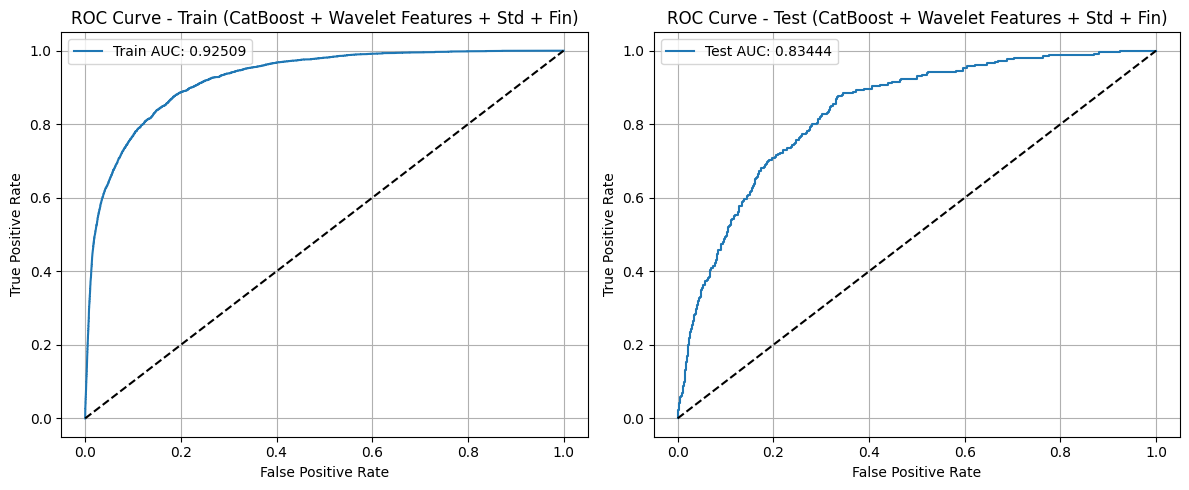

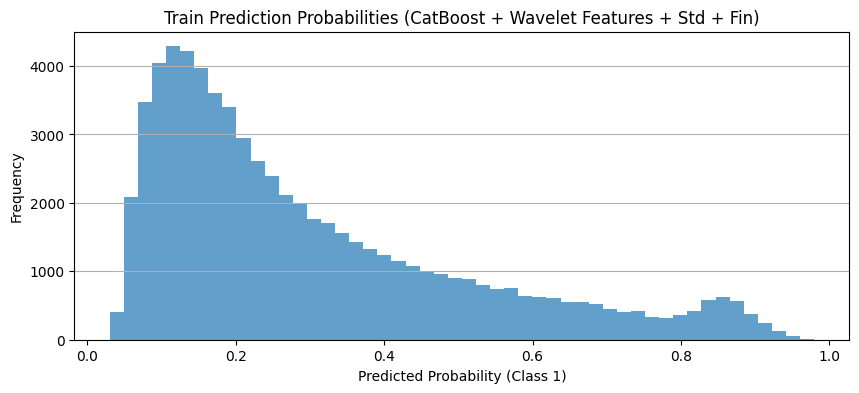

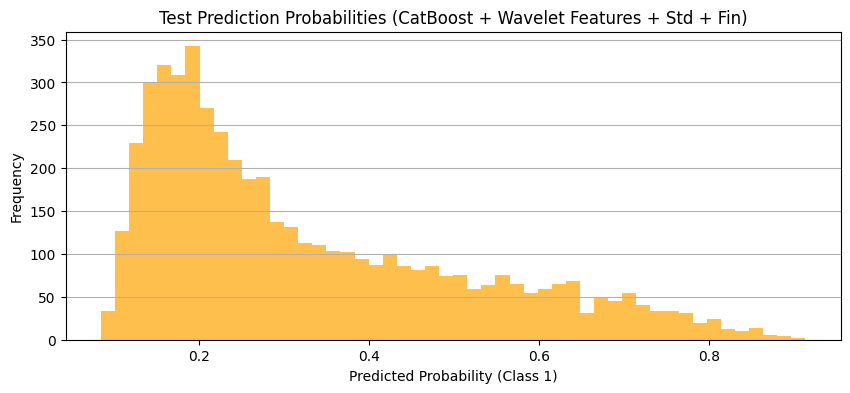


--- Section 16: CatBoost Feature Importance ---

Top 20 CatBoost Feature Importances:
              Feature  Importance
0              VKOSPI   50.342082
1               MONTH   12.811754
2                 PSR    3.496107
3    PRICE_TO_52W_LOW    2.934043
4     FN_ACML_TR_PBMN    2.156683
5                 F70    2.151780
6   PRICE_TO_52W_HIGH    2.006082
7                 F71    1.986909
8           WavFeat_7    1.705897
9           WavFeat_1    1.665861
10          WavFeat_6    1.483620
11          WavFeat_5    1.442443
12      Std_STCK_PRPR    1.313502
13                ICR    1.290417
14                ROE    1.256488
15          WavFeat_4    1.126566
16                PER    1.101975
17          WavFeat_3    1.085529
18            ROE_INC    1.084380
19          WavFeat_0    1.045941


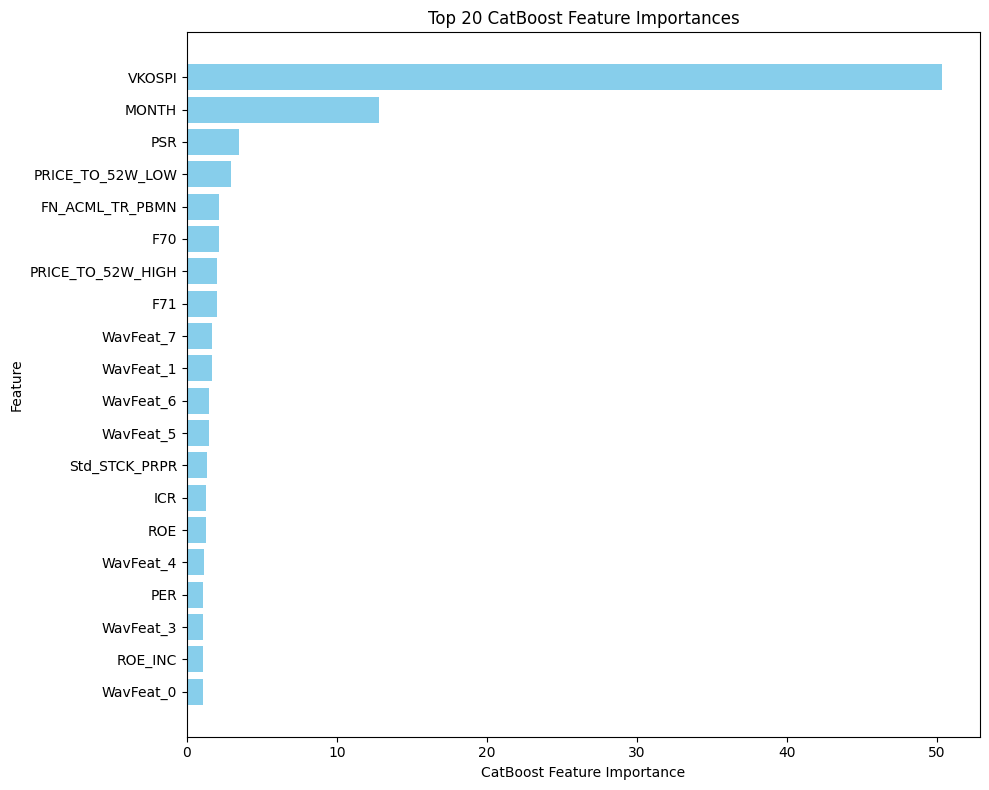


--- Generating Feature Names for Rolling Evaluation ---
Generated 8 wavelet feature names.
Generated 1 std deviation feature names.
Added 19 financial feature names.
Total generated feature names: 28 (Matches scaled feature count)
Target column name set to: 'target'
Combining SCALED features and targets for rolling evaluation...
Combined scaled features shape: (82530, 28)
Combined targets shape: (82530,)
Creating DataFrame for rolling evaluation...
DataFrame created successfully with columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82530 entries, 0 to 82529
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   WavFeat_0          82530 non-null  float64       
 1   WavFeat_1          82530 non-null  float64       
 2   WavFeat_2          82530 non-null  float64       
 3   WavFeat_3          82530 non-null  float64       
 4   WavFeat_4          82530 non-null  float64       
 5   Wa

In [ ]:
import pandas as pd
import numpy as np
# Tensorflow / Keras Imports - Modify for Transformer (Keep TF for seed)
import tensorflow as tf
# from tensorflow.keras.models import Model # No longer needed for AE
# >>> MODIFICATION START: Remove Transformer/AE specific layers <<<
# from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D, TimeDistributed, Reshape, Embedding
# >>> MODIFICATION END <<<
# from tensorflow.keras.optimizers import Adam # No longer needed for AE
# from tensorflow.keras.callbacks import EarlyStopping # No longer needed for AE
# >>> MODIFICATION START: Import MSE <<<
# 라인 20 수정: log_loss, brier_score_loss 추가
from sklearn.metrics import roc_auc_score, roc_curve, mean_squared_error, log_loss, brier_score_loss # MSE, LogLoss, Brier 추가
# >>> MODIFICATION END <<<
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
# >>> MODIFICATION START: Import specific scipy modules if needed (stats already used later) <<<
from scipy import stats # For skew, kurtosis if added later
# 라인 15: pywt 라이브러리 import 추가
import pywt
# >>> MODIFICATION END <<<

# CatBoost
# !pip install catboost imblearn pywavelets # imblearn은 이제 필요 없음, pywavelets 설치 필요
from catboost import CatBoostClassifier
# from imblearn.over_sampling import RandomOverSampler # 삭제

# >>> MODIFICATION START: Import other models <<<
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
# >>> MODIFICATION END <<<


# --- KS Statistic Calculation Function ---
def calculate_ks(y_true, y_prob):
    """
    Calculates the Kolmogorov-Smirnov statistic for binary classification predictions.

    Args:
        y_true: Array-like of true binary labels (0 or 1).
        y_prob: Array-like of predicted probabilities for the positive class.

    Returns:
        The KS statistic (float). Returns np.nan if calculation is not possible.
    """
    try:
        # Combine actual values (0/1) and predicted probabilities
        data = pd.DataFrame({'y_true': y_true, 'y_prob': y_prob})

        # Separate probabilities for actual positive (1) and negative (0) cases
        prob_positive = data[data['y_true'] == 1]['y_prob']
        prob_negative = data[data['y_true'] == 0]['y_prob']

        # Check if either class is empty
        if len(prob_positive) == 0 or len(prob_negative) == 0:
            # print("Warning: One class is empty, KS statistic cannot be calculated reliably.")
            return np.nan # Or 0, depending on desired behavior

        # Use scipy's ks_2samp which directly compares the distributions
        # It returns KS statistic and p-value. We only need the statistic.
        ks_stat, p_value = stats.ks_2samp(prob_positive, prob_negative)

        return ks_stat
    except Exception as e:
        print(f"Error calculating KS statistic: {e}")
        return np.nan
# --- End KS Function ---

# >>> MODIFICATION START: Helper function replaced with wavelet feature calculation <<<
# 라인 18-39: calculate_poly_coeffs 함수를 calculate_wavelet_features 함수로 교체
def calculate_wavelet_features(sequences, wavelet='db4', level=3, feature_stats=['energy', 'std', 'skew', 'kurt']):
    """Calculates statistical features from DWT coefficients for each sequence."""
    n_samples, _, n_features = sequences.shape
    feature_list = []

    # Define stats functions safely
    def safe_skew(a):
        try: return stats.skew(a)
        except ValueError: return 0
    def safe_kurtosis(a):
        try: return stats.kurtosis(a)
        except ValueError: return 0
    def safe_std(a):
        try: return np.std(a)
        except ValueError: return 0
    def safe_energy(a):
        return np.sum(a**2)
    def safe_entropy(a):
      try:
        sq_coeffs = a**2
        coeff_sum = np.sum(sq_coeffs)
        if coeff_sum == 0: return 0
        probs = sq_coeffs / coeff_sum
        return stats.entropy(probs)
      except ValueError: return 0

    stat_funcs = {'energy': safe_energy, 'std': safe_std, 'skew': safe_skew, 'kurt': safe_kurtosis, 'entropy': safe_entropy}
    valid_feature_stats = [s for s in feature_stats if s in stat_funcs] # Ensure only valid stats are used

    print(f"Calculating Wavelet features using: wavelet='{wavelet}', level={level}, stats={valid_feature_stats}")

    for i in range(n_samples):
        sample_features = []
        for j in range(n_features):
            sequence = sequences[i, :, j]
            sequence = np.nan_to_num(sequence) # Ensure no NaNs/Infs before DWT

            try:
                # Perform multilevel DWT
                coeffs = pywt.wavedec(sequence, wavelet, level=level) # List: [cA_n, cD_n, ..., cD_1]

                # Calculate stats for each coefficient array
                for coeff_array in coeffs:
                    if len(coeff_array) == 0: # Handle potential empty arrays
                        for stat_name in valid_feature_stats:
                            sample_features.append(0)
                        continue

                    for stat_name in valid_feature_stats:
                        func = stat_funcs[stat_name]
                        stat_value = func(coeff_array)
                        sample_features.append(stat_value)

            except Exception as e:
                print(f"Warning: Wavelet decomposition failed for sample {i}, feature {j}. Error: {e}. Appending zeros.")
                # Calculate expected number of features per stock feature
                num_coeff_arrays = level + 1
                num_expected_features = num_coeff_arrays * len(valid_feature_stats)
                sample_features.extend([0] * num_expected_features) # Append zeros if DWT fails

        feature_list.append(sample_features)

    return np.array(feature_list)
# >>> MODIFICATION END <<<
# --------------------------------------------


############################################################
# 1) 파일 로드 (변경 없음)
############################################################
# 경로를 실제 환경에 맞게 수정해야 합니다.
try:
    stock_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet')
    fin_df   = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_fin_result_with_vkospi_all.parquet')
    print("Successfully loaded data from Parquet files.")
except FileNotFoundError:
    print("Warning: Parquet files not found. Please ensure the path is correct or provide dummy data.")
    # Try loading from a local path as a fallback (adjust as needed)
    try:
        stock_df = pd.read_parquet('stock_all_vkospi.parquet')
        fin_df   = pd.read_parquet('stock_fin_result_with_vkospi_all.parquet')
        print("Loaded data from local Parquet files.")
    except FileNotFoundError:
        print("Error: Could not load data from Drive or local path. Exiting.")
        exit()
except Exception as e:
    print(f"An error occurred during file loading: {e}")
    exit()


############################################################
# 2) 날짜 전처리 (변경 없음)
############################################################
stock_df['BSOP_DATE'] = pd.to_datetime(stock_df['BSOP_DATE'], errors='coerce')
fin_df['BSOP_DATE']   = pd.to_datetime(fin_df['BSOP_DATE'],   errors='coerce')

# 2024-07-01 이전 데이터
stock_df = stock_df[stock_df['BSOP_DATE'] < '2024-07-01'].copy()
fin_df   = fin_df[fin_df['BSOP_DATE']   < '2024-07-01'].copy()

############################################################
# 3) ROE 결측치 제거 및 피처 생성 (변경 없음)
############################################################
mask_fin = fin_df.groupby('SHRN_ISCD')['ROE'].transform('count') > 0
fin_df = fin_df[mask_fin].copy()
valid_codes = fin_df['SHRN_ISCD'].unique()
stock_df = stock_df[stock_df['SHRN_ISCD'].isin(valid_codes)].copy()
print("Stock DF Columns:", stock_df.columns.tolist())
fin_df = fin_df.dropna(subset=['windowdrop']).copy() # Ensure target is not NaN
fin_df['MONTH'] = fin_df['BSOP_DATE'].dt.month
# Calculate features safely, avoiding division by zero or near-zero
fin_df.loc[:, 'PRICE_TO_52W_HIGH'] = np.where(fin_df['W52_HGPR'] != 0, fin_df['STCK_PRPR'] / fin_df['W52_HGPR'], 0)
fin_df.loc[:, 'PRICE_TO_52W_LOW'] = np.where(fin_df['W52_LWPR'] != 0, fin_df['STCK_PRPR'] / fin_df['W52_LWPR'], 0)
fin_df.loc[:, 'PER'] = np.where(fin_df['MARKET_CAP'] != 0, fin_df['NET_INCOME'] / fin_df['MARKET_CAP'], 0)
fin_df.loc[:, 'PSR'] = np.where(fin_df['STCK_PRPR'] != 0, fin_df['PS'] / fin_df['STCK_PRPR'], 0)
fin_df.loc[:, 'FTRUTH'] = np.where(fin_df['NET_INCOME'] != 0, fin_df['PS'] / fin_df['NET_INCOME'], 0)
fin_df.loc[:, 'NET_DEBT_RATIO'] = np.where(fin_df['MARKET_CAP'] != 0, fin_df['NET_DEBT'] / fin_df['MARKET_CAP'], 0) # Renamed to avoid conflict
fin_df.loc[:, 'DEBT_COST_RATIO'] = np.where(fin_df['MARKET_CAP'] != 0, fin_df['DEBT_COST'] / fin_df['MARKET_CAP'], 0) # Renamed to avoid conflict

le_scrt = LabelEncoder()
le_mrkt = LabelEncoder()
fin_df['SCRT_GRP_CLS_CODE'] = fin_df['SCRT_GRP_CLS_CODE'].astype(str)
fin_df['MRKT_DIV_CLS_CODE'] = fin_df['MRKT_DIV_CLS_CODE'].astype(str)
fin_df['SCRT_GRP_CLS_CODE'] = le_scrt.fit_transform(fin_df['SCRT_GRP_CLS_CODE'])
fin_df['MRKT_DIV_CLS_CODE'] = le_mrkt.fit_transform(fin_df['MRKT_DIV_CLS_CODE'])

############################################################
# 4) 주요 설정값 (변경 없음 - NET_DEBT, DEBT_COST 이름 변경 반영)
############################################################
sequence_length = 60
stock_features = [
    'STCK_PRPR',
    #'vkospi', # If VKOSPI is only daily, consider adding it to fin_features instead
]
n_stock_features = len(stock_features)
fin_features = [
    'PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW', 'SCRT_GRP_CLS_CODE',
    'MONTH', 'VKOSPI',
    'FN_ACML_TR_PBMN', 'ORGN_NTBY_QTY', 'DR', 'PSR', 'ROE', 'ROE_INC',
    'NET_DEBT_RATIO', 'DEBT_COST_RATIO', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH', 'F70', 'F71', # Updated names
]
fin_features = [f for f in fin_features if f in fin_df.columns] # Ensure features exist
print("Using Fin Features:", fin_features)

############################################################
# 5) 시퀀스 데이터 생성 (변경 없음)
############################################################
stock_series_data   = []
stock_current_data = []
fin_series_data     = []
matched_targets     = []
dates               = []
stock_groups = stock_df.groupby('SHRN_ISCD')

# Handle potential division by zero or inf/NaN before processing
numeric_cols_fin = fin_df.select_dtypes(include=np.number).columns
fin_df[numeric_cols_fin] = fin_df[numeric_cols_fin].replace([np.inf, -np.inf], np.nan)
numeric_cols_stock = stock_df.select_dtypes(include=np.number).columns
stock_df[numeric_cols_stock] = stock_df[numeric_cols_stock].replace([np.inf, -np.inf], np.nan)

# Fill NaNs - consider more sophisticated methods if appropriate (e.g., ffill, mean/median)
fin_df.fillna(0, inplace=True)
stock_df.fillna(0, inplace=True)

print("Starting sequence generation...")
processed_count = 0
skipped_short_seq = 0
skipped_no_today = 0
for stock_code, fin_group in fin_df.groupby('SHRN_ISCD'):
    if stock_code not in stock_groups.groups: continue
    stock_history_group = stock_groups.get_group(stock_code).sort_values('BSOP_DATE')
    if len(stock_history_group) < sequence_length: continue

    for row in fin_group.itertuples():
        date = row.BSOP_DATE
        # Find the index *before* or *at* the current fin_date in the stock history
        end_index = stock_history_group['BSOP_DATE'].searchsorted(date, side='right') # Use 'right' to include the day itself if present
        start_index = max(0, end_index - sequence_length)
        stock_history = stock_history_group.iloc[start_index:end_index]

        if len(stock_history) != sequence_length:
            # Pad if necessary and feasible, or skip
            # For simplicity, we skip here
            skipped_short_seq += 1
            continue

        # Get 'today's' stock data (corresponding to the fin_date)
        # It should be the last row of the extracted sequence
        today_data = stock_history[stock_features].iloc[-1].values

        # Check if today_data contains NaNs (might happen if last day had missing stock data)
        if np.isnan(today_data).any():
            skipped_no_today +=1
            continue

        stock_series_data.append(stock_history[stock_features].values)
        # stock_current_data.append(today_data) # This might not be needed if not used later
        fin_series_data.append([getattr(row, f) for f in fin_features])
        matched_targets.append(row.windowdrop)
        dates.append(date)
        processed_count += 1

print(f"Finished sequence generation. Processed: {processed_count}, Skipped (short seq): {skipped_short_seq}, Skipped (no today data): {skipped_no_today}")
if not stock_series_data: raise ValueError("No sequences generated.")

stock_series_data   = np.array(stock_series_data)
# stock_current_data = np.array(stock_current_data)
fin_series_data     = np.array(fin_series_data)
matched_targets     = np.array(matched_targets)
dates               = np.array(dates)

print("stock_series_data.shape :", stock_series_data.shape)
# print("stock_current_data.shape:", stock_current_data.shape)
print("fin_series_data.shape   :", fin_series_data.shape)
print("matched_targets.shape :", matched_targets.shape)
print("dates.shape           :", dates.shape)

############################################################
# 6) Train/Test 분할 (변경 없음)
############################################################
train_mask = (dates <= pd.Timestamp('2022-12-31'))
val_mask = (dates >= pd.Timestamp('2023-01-01')) & (dates <= pd.Timestamp('2023-12-31'))
test_mask  = dates >= pd.Timestamp(pd.Timestamp('2024-01-01'))

if not np.any(train_mask): raise ValueError("No training data after split.")
if not np.any(val_mask): raise ValueError("No val data after split.")
if not np.any(test_mask): raise ValueError("No test data after split.")

X_stock_train_seq   = stock_series_data[train_mask]      # Input for scaling & stats feature extraction
X_stock_val_seq    = stock_series_data[val_mask]
X_stock_test_seq    = stock_series_data[test_mask]       # Input for scaling & stats feature extraction

# X_stock_train_curr = stock_current_data[train_mask] # Not used currently
# X_stock_test_curr  = stock_current_data[test_mask]  # Not used currently
X_fin_train = fin_series_data[train_mask]
X_fin_val   = fin_series_data[val_mask]
X_fin_test  = fin_series_data[test_mask]

y_train = matched_targets[train_mask]
y_val   = matched_targets[val_mask]
y_test  = matched_targets[test_mask]

print("Train sequence shape (before scaling):", X_stock_train_seq.shape)
print("Val sequence shape (before scaling):", X_stock_val_seq.shape)
print("Test sequence shape (before scaling):", X_stock_test_seq.shape)
print("Train fin shape:", X_fin_train.shape)
print("Val fin shape:", X_fin_val.shape)
print("Test fin shape:", X_fin_test.shape)
print("Train target size:", len(y_train))
print("Val target size:", len(y_val))
print("Test target size :", len(y_test))
print("Train target distribution (Class 1):", np.mean(y_train))
print("val target distribution (Class 1):", np.mean(y_val))
print("Test target distribution  (Class 1):", np.mean(y_test))

############################################################
# 7) 데이터 정규화 (Stock Sequence Only)
############################################################
n_train_samples, seq_len, n_features = X_stock_train_seq.shape
n_val_samples = X_stock_val_seq.shape[0]
n_test_samples = X_stock_test_seq.shape[0]

if n_features != n_stock_features: raise ValueError(f"Feature count mismatch: X_stock_train_seq has {n_features} features, expected {n_stock_features}")

# Reshape for scaling (scale across all samples and time steps for each feature)
temp_train = X_stock_train_seq.reshape(-1, n_stock_features)
temp_val   = X_stock_val_seq.reshape(-1, n_stock_features)
temp_test  = X_stock_test_seq.reshape(-1, n_stock_features)

# Apply log1p transformation (handle potential zeros)
temp_train_log = np.log1p(np.maximum(temp_train, 0)) # Ensure non-negative before log
temp_val_log = np.log1p(np.maximum(temp_val, 0)) # Ensure non-negative before log
temp_test_log  = np.log1p(np.maximum(temp_test, 0))

# Handle any resulting NaNs/Infs after log (though maximum should prevent log(0))
temp_train_log = np.nan_to_num(temp_train_log, nan=0.0, posinf=0.0, neginf=0.0)
temp_val_log = np.nan_to_num(temp_val_log, nan=0.0, posinf=0.0, neginf=0.0)
temp_test_log = np.nan_to_num(temp_test_log, nan=0.0, posinf=0.0, neginf=0.0)

stock_scaler_seq = StandardScaler()
temp_train_scaled = stock_scaler_seq.fit_transform(temp_train_log)
temp_val_scaled = stock_scaler_seq.fit_transform(temp_val_log)
temp_test_scaled  = stock_scaler_seq.transform(temp_test_log)

# Handle potential NaNs from StandardScaler (if a feature is constant in train)
if np.isnan(temp_train_scaled).any() or np.isinf(temp_train_scaled).any():
    print("Warning: NaNs/Infs detected after scaling train data. Check for constant features. Filling with 0.")
    temp_train_scaled = np.nan_to_num(temp_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
if np.isnan(temp_val_scaled).any() or np.isinf(temp_val_scaled).any():
    print("Warning: NaNs/Infs detected after scaling test data. Filling with 0.")
    temp_val_scaled = np.nan_to_num(temp_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
if np.isnan(temp_test_scaled).any() or np.isinf(temp_test_scaled).any():
    print("Warning: NaNs/Infs detected after scaling test data. Filling with 0.")
    temp_test_scaled = np.nan_to_num(temp_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)

# Reshape back to (n_samples, seq_len, n_features)
X_stock_train_seq_scaled = temp_train_scaled.reshape(n_train_samples, seq_len, n_features)
X_stock_val_seq_scaled = temp_val_scaled.reshape(n_val_samples, seq_len, n_features)
X_stock_test_seq_scaled  = temp_test_scaled.reshape(n_test_samples, seq_len, n_features)

print("Scaled train sequence shape:", X_stock_train_seq_scaled.shape)
print("Scaled val sequence shape:", X_stock_val_seq_scaled.shape)
print("Scaled test sequence shape:", X_stock_test_seq_scaled.shape)

############################################################
# 8) 오버샘플링 제거 (변경 없음)
############################################################
print("Skipping oversampling step as per previous modification.")

#시드 고정 (변경 없음)
import random
import os
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
print(f"Set random seeds to {seed_value}")

#################################################################
# 9) >>> MODIFICATION START: Transformer 오토인코더 모델 정의 제거 <<<
#################################################################
print("\n--- Section 9: Skipping Transformer Autoencoder Definition ---")
# --- (Code for TransformerBlock, PositionEmbedding, Model Definition REMOVED) ---
#################################################################
# 9) >>> MODIFICATION END <<<
#################################################################


############################################################
# 10) >>> MODIFICATION START: 오토인코더 학습 제거 <<<
############################################################
print("\n--- Section 10: Skipping Autoencoder Training ---")
# --- (Code for autoencoder.fit, EarlyStopping, loss plotting REMOVED) ---
############################################################
# 10) >>> MODIFICATION END <<<
############################################################


############################################################
# 11) >>> MODIFICATION START: 통계 피처 계산 (웨이블릿 피처 + 표준편차) <<<
# 라인 218: Section 주석 변경
print("\n--- Section 11: Calculating Statistical Features (Wavelet Features + Std Dev) ---")

# (11a) 각 시퀀스의 각 피처에 대한 웨이블릿 변환 기반 통계 피처 계산
# 라인 221: (11a) 주석 및 print 문 변경
print("Calculating wavelet features (energy, std, skew, kurt) using pywt.wavedec...")
# 라인 222: calculate_wavelet_features 함수 호출 및 변수명 변경
# 예시: db4 웨이블릿, 레벨 3, 에너지/표준편차/왜도/첨도 통계량 사용
#train_wavelet_features = calculate_wavelet_features(X_stock_train_seq_scaled, wavelet='db4', level=3, feature_stats=['energy', 'std', 'skew', 'kurt'])
train_wavelet_features = calculate_wavelet_features(X_stock_train_seq_scaled, wavelet='db4', level=3, feature_stats=['energy', 'std'])
#val_wavelet_features = calculate_wavelet_features(X_stock_val_seq_scaled, wavelet='db4', level=3, feature_stats=['energy', 'std', 'skew', 'kurt'])
val_wavelet_features = calculate_wavelet_features(X_stock_val_seq_scaled, wavelet='db4', level=3, feature_stats=['energy', 'std'])
#test_wavelet_features = calculate_wavelet_features(X_stock_test_seq_scaled, wavelet='db4', level=3, feature_stats=['energy', 'std', 'skew', 'kurt'])
test_wavelet_features = calculate_wavelet_features(X_stock_test_seq_scaled, wavelet='db4', level=3, feature_stats=['energy', 'std'])
# 라인 224: 웨이블릿 피처 NaN/Inf 처리 (helper 함수 내에서 처리 안될 경우 대비)
train_wavelet_features = np.nan_to_num(train_wavelet_features, nan=0.0, posinf=0.0, neginf=0.0)
# 라인 224: 웨이블릿 피처 NaN/Inf 처리 (helper 함수 내에서 처리 안될 경우 대비)
val_wavelet_features = np.nan_to_num(val_wavelet_features, nan=0.0, posinf=0.0, neginf=0.0)
# 라인 225: 웨이블릿 피처 NaN/Inf 처리
test_wavelet_features = np.nan_to_num(test_wavelet_features, nan=0.0, posinf=0.0, neginf=0.0)
# 라인 226: 출력 메시지 및 변수명 변경
print(f"Finished calculating wavelet features. Train Shape: {train_wavelet_features.shape}, Val Shape: {val_wavelet_features.shape}, Test Shape: {test_wavelet_features.shape}")


# (11b) 각 시퀀스의 각 피처에 대한 표준편차 계산 (변경 없음)
print("Calculating standard deviations...")
# axis=1은 sequence_length 차원에 해당
train_stds = np.std(X_stock_train_seq_scaled, axis=1)
val_stds = np.std(X_stock_val_seq_scaled, axis=1)
test_stds = np.std(X_stock_test_seq_scaled, axis=1)
# NaN/Inf 처리 (예: 스케일링 후 시퀀스 조각이 상수인 경우)
train_stds = np.nan_to_num(train_stds, nan=0.0, posinf=0.0, neginf=0.0)
val_stds = np.nan_to_num(val_stds, nan=0.0, posinf=0.0, neginf=0.0)
test_stds = np.nan_to_num(test_stds, nan=0.0, posinf=0.0, neginf=0.0)
print("Finished calculating standard deviations.")


# (11c) 웨이블릿 피처와 표준편차 피처 결합
# 라인 236: (11c) 주석 및 Shape 설명 변경
# Shape will be (n_samples, n_wavelet_features_per_stock * n_stock_features + n_stock_features)
# 라인 237: 결합 변수명 변경 (wavelet 사용)
train_stat_features = np.concatenate([train_wavelet_features, train_stds], axis=1)
val_stat_features = np.concatenate([val_wavelet_features, val_stds], axis=1)
test_stat_features = np.concatenate([test_wavelet_features, test_stds], axis=1)

# *** 오버샘플링 적용 안 함 *** (변경 없음)

# 라인 242: 출력 레이블 변경
print("train_stat_features (wavelet+std).shape:", train_stat_features.shape)
print("val_stat_features (wavelet+std).shape:", val_stat_features.shape)
print("test_stat_features (wavelet+std).shape :", test_stat_features.shape)
############################################################
# 11) >>> MODIFICATION END <<<
############################################################


############################################################
# 12) >>> MODIFICATION START: (통계 피처 + 재무데이터) 결합 -> 최종 피처셋 준비 <<<
# 라인 250: Section 주석 변경
print("\n--- Section 12: Preparing Final Features for Models ---")

# 새로 계산된 통계 피처(웨이블릿 + 표준편차)를 포함할지 여부 결정
# 라인 254: include_stat_features 주석 변경
include_stat_features = True # <<< 제어: 통계 피처 제외하려면 False로 설정
print(f"Include Statistical Features (Wavelet Features + Std) in Final Features: {include_stat_features}")

# -- Train Data --
feature_list_train = []
if include_stat_features:
    # 현재: train_wavelet_features, train_stds가 결합된 train_stat_features 사용
    feature_list_train.append(train_stat_features)
# 재무 피처 추가
if X_fin_train.size > 0: # Check if financial features exist
    feature_list_train.append(X_fin_train)
# feature_list_train.append(X_stock_train_curr) # 필요시 포함

if not feature_list_train: raise ValueError("No features selected for model training!")
train_features = np.concatenate(feature_list_train, axis=1)

# -- Val Data --
feature_list_val = []
if include_stat_features:
     # 현재: test_wavelet_features, test_stds가 결합된 test_stat_features 사용
    feature_list_val.append(val_stat_features)
# 재무 피처 추가
if X_fin_val.size > 0: # Check if financial features exist
    feature_list_val.append(X_fin_val)
# feature_list_test.append(X_stock_test_curr) # 필요시 포함

if not feature_list_val: raise ValueError("No features selected for model testing!")
val_features = np.concatenate(feature_list_val, axis=1)

# -- Test Data --
feature_list_test = []
if include_stat_features:
     # 현재: test_wavelet_features, test_stds가 결합된 test_stat_features 사용
    feature_list_test.append(test_stat_features)
# 재무 피처 추가
if X_fin_test.size > 0: # Check if financial features exist
    feature_list_test.append(X_fin_test)
# feature_list_test.append(X_stock_test_curr) # 필요시 포함

if not feature_list_test: raise ValueError("No features selected for model testing!")
test_features = np.concatenate(feature_list_test, axis=1)

print("Combined train_features shape (before scaling):", train_features.shape)
print("Combined val_features shape (before scaling):"  , val_features.shape)
print("Combined test_features shape  (before scaling):", test_features.shape)

# >>> MODIFICATION START: Scale Combined Features <<<
print("\n--- Scaling Combined Features for All Models ---")
feature_scaler = StandardScaler()
train_features_scaled = feature_scaler.fit_transform(train_features)
val_features_scaled = feature_scaler.transform(val_features)
test_features_scaled = feature_scaler.transform(test_features)

# Handle potential NaNs/Infs after scaling combined features
train_features_scaled = np.nan_to_num(train_features_scaled, nan=0.0, posinf=0.0, neginf=0.0)
val_features_scaled = np.nan_to_num(val_features_scaled, nan=0.0, posinf=0.0, neginf=0.0)
test_features_scaled = np.nan_to_num(test_features_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print("Scaled combined train features shape:", train_features_scaled.shape)
print("Scaled combined val features shape:", val_features_scaled.shape)
print("Scaled combined test features shape:", test_features_scaled.shape)
# >>> MODIFICATION END <<<

############################################################
# 12) >>> MODIFICATION END <<<
############################################################

# --- 클래스 가중치 계산 --- (변경 없음)
n_negatives = np.sum(y_train == 0)
n_positives = np.sum(y_train == 1)
if n_positives == 0 or n_negatives == 0:
    print("Warning: One class is missing in the training data. Setting scale_pos_weight=1.0")
    scale_pos_weight_value = 1.0
else:
    # Ensure n_positives is not zero before division
    scale_pos_weight_value = n_negatives / n_positives if n_positives > 0 else 1.0
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.4f}")


############################################################
# 13) CatBoost 모델 학습 및 평가 (MSE 추가 및 Scaled Features 사용)
############################################################
print("\n--- Section 13: Training and Evaluating CatBoost ---")

# CatBoost 모델 선언 (Bayesian 파라미터 유지 - 변경 없음)
cat_model = CatBoostClassifier(
        iterations=5000,
        depth=7,          # 이전과 동일 (혹은 실험에 따라 조정 가능)
        learning_rate=0.01, # 이전과 동일 (혹은 실험에 따라 조정 가능)
        random_seed=seed_value,
        verbose=100,
        loss_function='Logloss',
        early_stopping_rounds=500,
        l2_leaf_reg=100,      # 이전과 동일
        random_strength=10,   # 이전과 동일 (혹은 실험에 따라 조정 가능)
        bootstrap_type='Bayesian',
        bagging_temperature=10.0,
        eval_metric='AUC',
        use_best_model=True,
        scale_pos_weight=scale_pos_weight_value
)

# CatBoost 학습 (Scaled Features 사용)
print("--- Starting CatBoost Training ---")
# >>> MODIFICATION START: Use scaled features for eval_set <<<
eval_set = (val_features_scaled, y_val)
cat_model.fit(train_features_scaled, y_train, eval_set=eval_set, verbose=100)
# >>> MODIFICATION END <<<

# 최종 평가
# >>> MODIFICATION START: Use scaled features for prediction <<<
pred_train_proba_cat = cat_model.predict_proba(train_features_scaled)[:, 1]
pred_test_proba_cat  = cat_model.predict_proba(test_features_scaled)[:, 1]
# >>> MODIFICATION END <<<

roc_auc_train_cat = roc_auc_score(y_train, pred_train_proba_cat)
roc_auc_test_cat  = roc_auc_score(y_test, pred_test_proba_cat)
ks_train_cat = calculate_ks(y_train, pred_train_proba_cat) # Changed variable name for clarity
ks_test_cat = calculate_ks(y_test, pred_test_proba_cat)   # Changed variable name for clarity

# 라인 371, 372: Log Loss 및 Brier Score 계산 추가
logloss_train_cat = log_loss(y_train, pred_train_proba_cat)
logloss_test_cat = log_loss(y_test, pred_test_proba_cat)
brier_train_cat = brier_score_loss(y_train, pred_train_proba_cat)
brier_test_cat = brier_score_loss(y_test, pred_test_proba_cat)


# 라인 370: 결과 딕셔너리에 LogLoss, Brier Score 추가
results = {} # Initialize results dictionary here
results['CatBoost'] = {'train_auc': roc_auc_train_cat, 'test_auc': roc_auc_test_cat,
                       'train_ks': ks_train_cat, 'test_ks': ks_test_cat,
                       'train_logloss': logloss_train_cat, 'test_logloss': logloss_test_cat,
                       'train_brier': brier_train_cat, 'test_brier': brier_test_cat}


# 통계 피처 종류에 따라 제목 업데이트
feature_type = "Wavelet Features + Std + Fin" if include_stat_features else "Financial Features Only"
# 라인 377, 378: 출력문에 LogLoss, Brier Score 추가
print(f'\n[CatBoost with {feature_type}] Train AUC: {roc_auc_train_cat:.5f} | Train KS: {ks_train_cat:.5f} | Train LogLoss: {logloss_train_cat:.5f} | Train Brier: {brier_train_cat:.5f}')
print(f'[CatBoost with {feature_type}] Test  AUC: {roc_auc_test_cat:.5f}  | Test KS: {ks_test_cat:.5f}  | Test LogLoss: {logloss_test_cat:.5f}  | Test Brier: {brier_test_cat:.5f}')


# ROC Curve 시각화 (CatBoost)
fpr_train_cat, tpr_train_cat, _ = roc_curve(y_train, pred_train_proba_cat)
fpr_test_cat,  tpr_test_cat,  _ = roc_curve(y_test, pred_test_proba_cat)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr_train_cat, tpr_train_cat, label=f'Train AUC: {roc_auc_train_cat:.5f}')
plt.plot([0,1],[0,1],'k--')
plt.title(f'ROC Curve - Train (CatBoost + {feature_type})')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(fpr_test_cat, tpr_test_cat, label=f'Test AUC: {roc_auc_test_cat:.5f}')
plt.plot([0,1],[0,1],'k--')
plt.title(f'ROC Curve - Test (CatBoost + {feature_type})')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

# 예측 확률 히스토그램 (CatBoost)
plt.figure(figsize=(10, 4))
plt.hist(pred_train_proba_cat, bins=50, alpha=0.7)
plt.title(f'Train Prediction Probabilities (CatBoost + {feature_type})')
plt.xlabel('Predicted Probability (Class 1)'); plt.ylabel('Frequency'); plt.grid(True, axis='y'); plt.show()
plt.figure(figsize=(10, 4))
plt.hist(pred_test_proba_cat, bins=50, alpha=0.7, color='orange')
plt.title(f'Test Prediction Probabilities (CatBoost + {feature_type})')
plt.xlabel('Predicted Probability (Class 1)'); plt.ylabel('Frequency'); plt.grid(True, axis='y'); plt.show()


############################################################
# 16) CatBoost Feature Importance (추가)
############################################################
print("\n--- Section 16: CatBoost Feature Importance ---")

try:
    # 1. 피처 이름 생성
    feature_names = []
    if include_stat_features:
        # 웨이블릿 피처 이름 (Generic) - 개수만 맞춰서 생성
        num_wavelet_features = train_wavelet_features.shape[1]
        wavelet_names = [f'WavFeat_{i}' for i in range(num_wavelet_features)]
        feature_names.extend(wavelet_names)

        # 표준편차 피처 이름 (Specific if possible, stock_features 리스트 사용)
        if train_stds.shape[1] == len(stock_features):
             std_names = [f'Std_{f}' for f in stock_features]
        else: # Fallback to generic names if dimensions mismatch
             print(f"Warning: Mismatch between std feature count ({train_stds.shape[1]}) and stock_features count ({len(stock_features)}). Using generic std names.")
             std_names = [f'StdFeat_{i}' for i in range(train_stds.shape[1])]
        feature_names.extend(std_names)

    if X_fin_train.size > 0: # Check if financial features exist
        # 재무 피처 이름 (fin_features 리스트 사용)
        feature_names.extend(fin_features)

    # 최종 피처 이름 개수와 실제 학습 피처 개수 확인
    if len(feature_names) != train_features_scaled.shape[1]:
        print(f"Error: Final feature name count ({len(feature_names)}) does not match training feature count ({train_features_scaled.shape[1]}). Cannot reliably show feature importances.")
        # 에러 발생 시 더 이상 진행하지 않음
    else:
        # 2. 변수 중요도 추출
        importances = cat_model.feature_importances_

        # 3. DataFrame 생성 및 정렬
        importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

        # 4. 결과 출력 (상위 20개)
        print("\nTop 20 CatBoost Feature Importances:")
        print(importance_df.head(20))

        # 5. 결과 시각화 (상위 20개)
        plt.figure(figsize=(10, 8))
        plt.barh(importance_df['Feature'][:20], importance_df['Importance'][:20], color='skyblue')
        plt.xlabel("CatBoost Feature Importance")
        plt.ylabel("Feature")
        plt.title("Top 20 CatBoost Feature Importances")
        plt.gca().invert_yaxis() # 중요도 높은 피처를 위로
        plt.tight_layout()
        plt.show()

except AttributeError:
     print("Error: Could not retrieve feature importances. Was the CatBoost model trained successfully?")
except NameError as e:
     print(f"Error: A required variable for feature importance generation is not defined: {e}")
except Exception as e:
    print(f"An error occurred while calculating/displaying CatBoost feature importances: {e}")




def fixed_roll_evaluation(df, features, target):
    # 명시적으로 원하는 구간만 지정
    valid_rolls = [
        (2015, 2019, 2020, [2021]),  # Train: 2016~2018, Val: 2019, Test: 2021
        (2016, 2020, 2021, [2022]),  # Train: 2016~2018, Val: 2019, Test: 2021
        (2017, 2021, 2022, [2023]),  # Train: 2016~2018, Val: 2019, Test: 2021
        (2018, 2022, 2023, [2024]),  # Train: 2016~2018, Val: 2019, Test: 2021
        ]

    results = []

    for train_start, train_end, val_year, test_year in valid_rolls:
        print(f"\n[Roll] Train: {train_start}~{train_end}, Val: {val_year}, Test: {test_year}")

        # 데이터 분리
        train_df = df[(df['BSOP_DATE'].dt.year >= train_start) & (df['BSOP_DATE'].dt.year <= train_end)]
        val_df = df[df['BSOP_DATE'].dt.year == val_year]
        test_df = df[df['BSOP_DATE'].dt.year.isin(test_year)]

        if len(train_df) == 0 or len(val_df) == 0 or len(test_df) == 0:
            print("-> 데이터 부족으로 스킵")
            continue

        X_train, y_train = train_df[features], train_df[target]
        X_val, y_val = val_df[features], val_df[target]
        X_test, y_test = test_df[features], test_df[target]

        # 클래스 가중치
        class_ratio = (y_train == 0).sum() / (y_train == 1).sum()
        class_weights = {0: 1, 1: class_ratio}

        model = CatBoostClassifier(
            iterations=10000,
            depth=7,
            learning_rate=0.01,
            random_seed=42,
            verbose=100,
            loss_function='Logloss',
            class_weights=class_weights,
            early_stopping_rounds=1000,
            l2_leaf_reg=100,
            random_strength=10,
            # bootstrap_type='Bernoulli',
            # subsample=0.8,
            bootstrap_type='Bayesian',  # Bernoulli -> Bayesian으로 변경
            bagging_temperature=10.0,    # Bayesian에 맞는 파라미터 추가 (기본값 1.0)
            eval_metric='AUC',
            use_best_model=True,
        )

        eval_set = (X_val, y_val)
        model.fit(X_train, y_train, eval_set=eval_set, verbose=100)

        y_test_pred_proba = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_test_pred_proba)

        print(f"-> Test AUC: {roc_auc:.4f}")

        results.append({
            'train_year': f'{train_start}-{train_end}',
            'val_year': f'{val_year}',
            'test_year': f'{test_year}',
            'test_auc': roc_auc
        })

    return pd.DataFrame(results)

# 1. 최종 피처 이름 리스트 생성 (섹션 16의 로직 재활용)
print("\n--- Generating Feature Names for Rolling Evaluation ---")
features_for_eval = []
if include_stat_features:
    # 웨이블릿 피처 이름 (Generic) - 개수만 맞춰서 생성
    num_wavelet_features = train_wavelet_features.shape[1]
    wavelet_names = [f'WavFeat_{i}' for i in range(num_wavelet_features)]
    features_for_eval.extend(wavelet_names)
    print(f"Generated {len(wavelet_names)} wavelet feature names.")

    # 표준편차 피처 이름 (Specific if possible, stock_features 리스트 사용)
    if train_stds.shape[1] == len(stock_features):
          std_names = [f'Std_{f}' for f in stock_features]
    else: # Fallback to generic names if dimensions mismatch
          print(f"Warning: Mismatch between std feature count ({train_stds.shape[1]}) and stock_features count ({len(stock_features)}). Using generic std names.")
          std_names = [f'StdFeat_{i}' for i in range(train_stds.shape[1])]
    features_for_eval.extend(std_names)
    print(f"Generated {len(std_names)} std deviation feature names.")

if X_fin_train.size > 0: # Check if financial features exist
    # 재무 피처 이름 (fin_features 리스트 사용)
    features_for_eval.extend(fin_features)
    print(f"Added {len(fin_features)} financial feature names.")

# 최종 피처 이름 개수 확인 (디버깅 목적)
expected_feature_count = train_features_scaled.shape[1] # 스케일링된 피처 개수 기준
if len(features_for_eval) != expected_feature_count:
     print(f"Error/Warning: Generated feature name count ({len(features_for_eval)}) does not match scaled feature count ({expected_feature_count}). Check logic.")
     # 필요시 여기서 중단하거나, generic 이름으로 대체하는 로직 추가 가능
else:
     print(f"Total generated feature names: {len(features_for_eval)} (Matches scaled feature count)")


# 2. 최종 타겟 이름 정의 (변경 없음)
target_for_eval = 'target'
print(f"Target column name set to: '{target_for_eval}'")

# 3. 스케일링된 피처와 타겟 합치기 (!!! 중요: 스케일링된 데이터 사용 !!!)
print("Combining SCALED features and targets for rolling evaluation...")
# 배열 크기는 스케일링된 피처의 차원(train_features_scaled.shape[1])을 사용
all_features_combined_scaled = np.zeros((len(dates), train_features_scaled.shape[1]))
all_targets = np.zeros(len(dates))

# 마스크를 사용하여 스케일링된(!!!) 학습 및 테스트 피처 할당
all_features_combined_scaled[train_mask] = train_features_scaled
all_features_combined_scaled[val_mask] = val_features_scaled
all_features_combined_scaled[test_mask] = test_features_scaled

# 타겟 할당 (변경 없음)
all_targets[train_mask] = y_train
all_targets[val_mask] = y_val
all_targets[test_mask] = y_test
print(f"Combined scaled features shape: {all_features_combined_scaled.shape}")
print(f"Combined targets shape: {all_targets.shape}")


# 4. DataFrame 생성 (스케일링된 데이터와 생성된 피처 이름 사용)
print("Creating DataFrame for rolling evaluation...")
# 스케일링된 데이터와 위에서 생성한 features_for_eval 리스트를 사용
df_eval = pd.DataFrame(all_features_combined_scaled, columns=features_for_eval)
df_eval['BSOP_DATE'] = dates # 날짜 추가
df_eval[target_for_eval] = all_targets # 타겟 추가
df_eval['BSOP_DATE'] = pd.to_datetime(df_eval['BSOP_DATE']) # 날짜 타입 변환
print("DataFrame created successfully with columns:")
print(df_eval.info()) # DataFrame 정보 출력

# 이제 df_eval (스케일링된 피처 포함), features_for_eval, target_for_eval 변수가 준비되었습니다.
# fixed_roll_evaluation 함수는 내부적으로 스케일링을 수행하지 않아야 합니다.
print("\n--- Starting Fixed Rolling Evaluation with SCALED data ---")
# 예: results_df = fixed_roll_evaluation(df_eval, features_for_eval, target_for_eval)
# (주의: fixed_roll_evaluation 함수 내부에 스케일링 코드가 없어야 함 - 이 조건 충족됨)
results_df = fixed_roll_evaluation(df_eval, features_for_eval, target_for_eval)

print("Script finished.")

print("\nScript finished.")


## compare model

### tree models

Successfully loaded data from Parquet files.
Stock DF Columns: ['BSOP_DATE', 'STND_ISCD', 'SHRN_ISCD', 'SCRT_GRP_CLS_CODE', 'MRKT_DIV_CLS_CODE', 'STCK_PRPR', 'ADJ_PRPR', 'W52_HGPR', 'W52_LWPR', 'FN_ACML_TR_PBMN', 'CRDT_RMND_RATE', 'MARKET_CAP', 'FRGN_HLDN_RATE', 'FRGN_NTBY_QTY', 'ORGN_NTBY_QTY', 'vkospi', 'ks200', 'fx']
Using Fin Features: ['PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW', 'SCRT_GRP_CLS_CODE', 'MONTH', 'VKOSPI', 'FN_ACML_TR_PBMN', 'ORGN_NTBY_QTY', 'DR', 'PSR', 'ROE', 'ROE_INC', 'NET_DEBT_RATIO', 'DEBT_COST_RATIO', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH']
Starting sequence generation...
Finished sequence generation. Processed: 82530, Skipped (short seq): 983, Skipped (no today data): 0
stock_series_data.shape : (82530, 60, 1)
fin_series_data.shape   : (82530, 17)
matched_targets.shape : (82530,)
dates.shape           : (82530,)
Train sequence shape (before scaling): (52881, 60, 1)
Val sequence shape (before scaling): (9931, 60, 1)
Test sequence shape (before scaling): (2539, 6

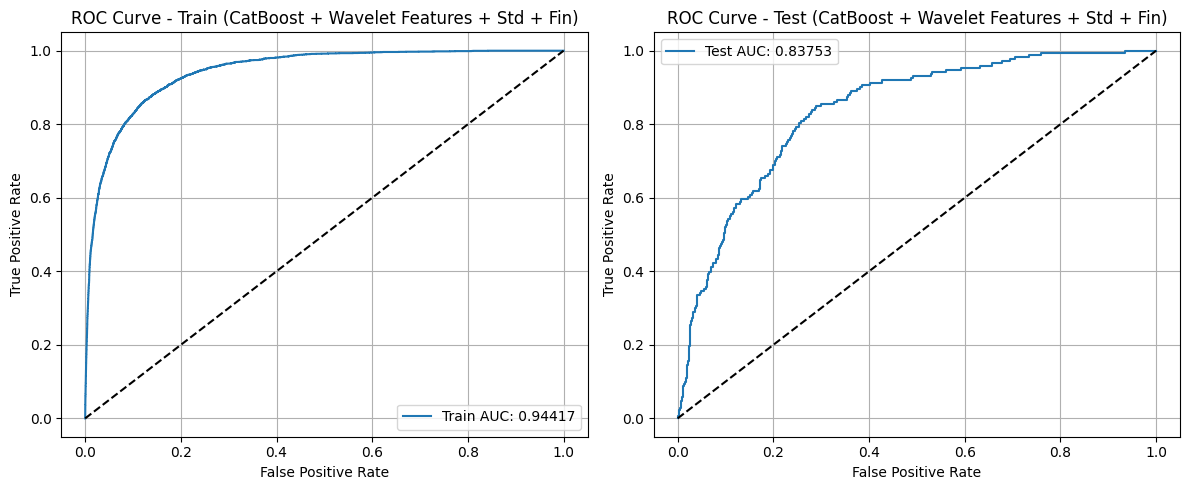

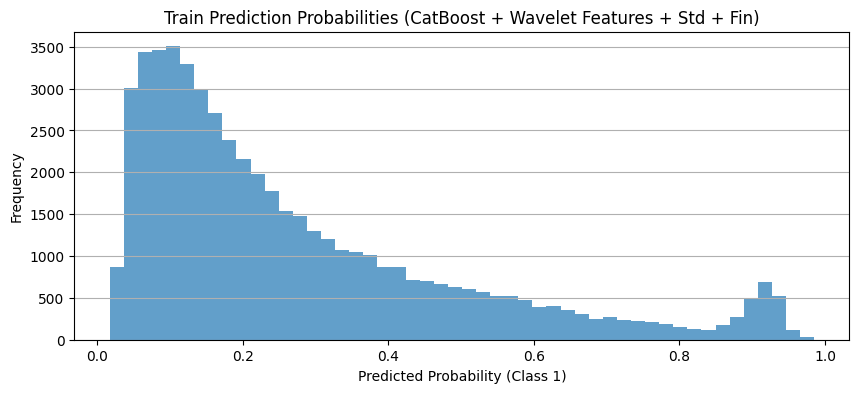

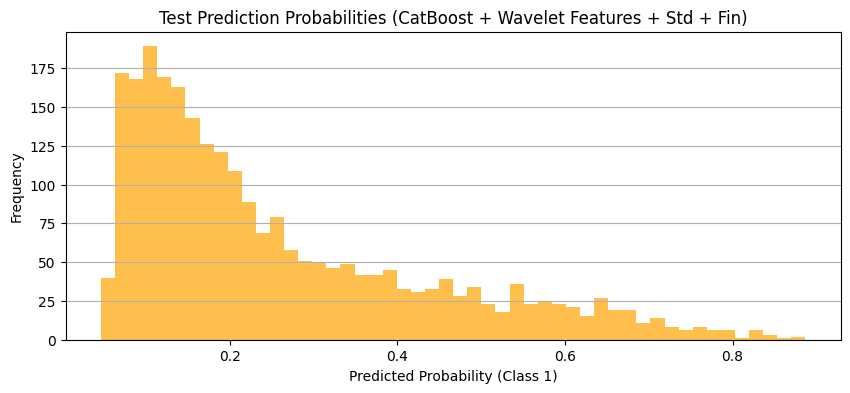


--- Section 14: Training and Evaluating Other Models ---

--- Training and Evaluating Logistic Regression ---
[LR] Train AUC: 0.75321 | Train KS: 0.42368 | Train LogLoss: 0.60022 | Train Brier: 0.20631
[LR] Test  AUC: 0.81188  | Test KS: 0.53402  | Test LogLoss: 0.52884  | Test Brier: 0.16632

--- Training and Evaluating Random Forest ---
[RF] Train AUC: 0.93664 | Train KS: 0.72357 | Train LogLoss: 0.36938 | Train Brier: 0.10661
[RF] Test  AUC: 0.83538  | Test KS: 0.57680  | Test LogLoss: 0.34178  | Test Brier: 0.09853

--- Training and Evaluating XGBoost ---
[0]	validation_0-auc:0.74138


/usr/local/lib/python3.11/dist-packages/xgboost/callback.py:386: UserWarning: [03:41:50] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-auc:0.85033
[163]	validation_0-auc:0.84946
[XGB] Train AUC: 0.96206 | Train KS: 0.79891 | Train LogLoss: 0.28090 | Train Brier: 0.08023
[XGB] Test  AUC: 0.83365  | Test KS: 0.54228  | Test LogLoss: 0.27285  | Test Brier: 0.07677

--- Training and Evaluating LightGBM ---
[LightGBM] [Info] Number of positive: 2879, number of negative: 50002
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.072939 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5965
[LightGBM] [Info] Number of data points in the train set: 52881, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.054443 -> initscore=-2.854620
[LightGBM] [Info] Start training from score -2.854620
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[151]	valid_0's auc: 0.847667
[LGBM] Train AUC: 0.97644 | Train KS: 0.86096 | Train LogLoss: 0.23749 | Train Brier: 0.069

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


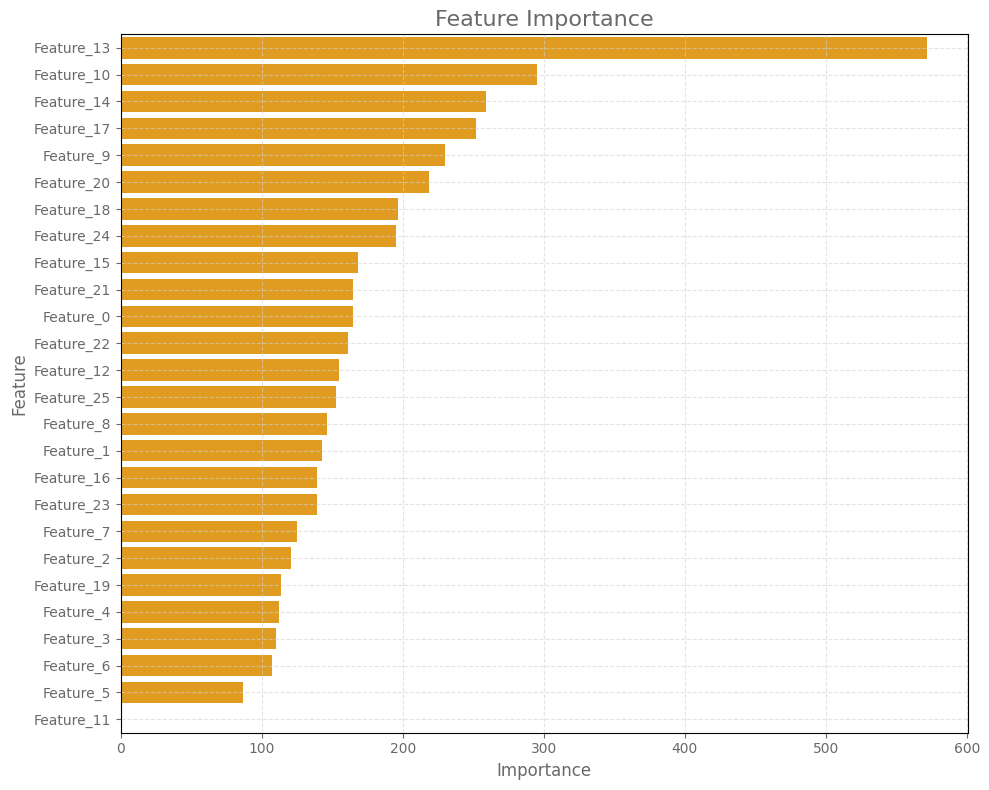


--- Section 15: Model Performance Summary ---
          train_auc  test_auc  train_ks   test_ks  train_logloss  test_logloss  train_brier  test_brier
CatBoost   0.944175  0.837530  0.739889  0.561461       0.337918      0.343018     0.098067    0.100042
LR         0.753206  0.811885  0.423680  0.534025       0.600217      0.528841     0.206306    0.166321
RF         0.936639  0.835385  0.723571  0.576801       0.369377      0.341784     0.106609    0.098535
XGB        0.962062  0.833648  0.798915  0.542280       0.280896      0.272847     0.080234    0.076768
LGBM       0.976443  0.812395  0.860958  0.507933       0.237490      0.251750     0.069857    0.075509

--- Section 16: lightGBM Feature Importance ---

Top 20 CatBoost Feature Importances:
              Feature  Importance
0              VKOSPI         572
1    PRICE_TO_52W_LOW         295
2     FN_ACML_TR_PBMN         259
3                 PSR         252
4   PRICE_TO_52W_HIGH         230
5      NET_DEBT_RATIO         219
6   

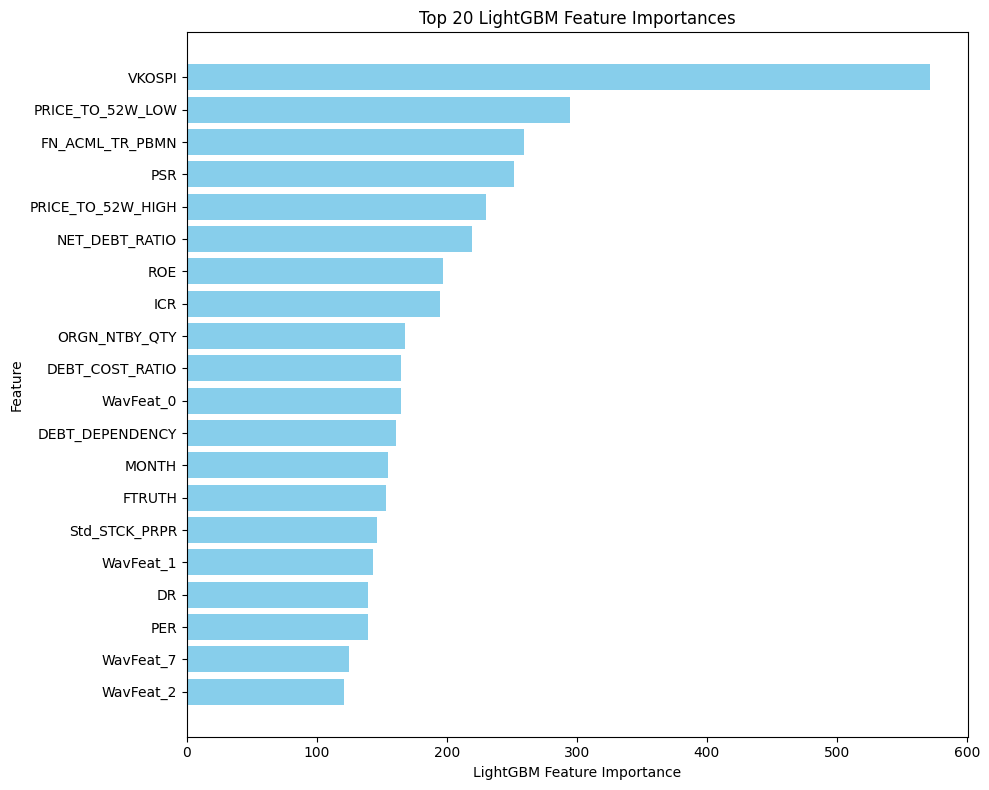


Script finished.


In [ ]:
import pandas as pd
import numpy as np
# Tensorflow / Keras Imports - Modify for Transformer (Keep TF for seed)
import tensorflow as tf
# from tensorflow.keras.models import Model # No longer needed for AE
# >>> MODIFICATION START: Remove Transformer/AE specific layers <<<
# from tensorflow.keras.layers import Input, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D, TimeDistributed, Reshape, Embedding
# >>> MODIFICATION END <<<
# from tensorflow.keras.optimizers import Adam # No longer needed for AE
# from tensorflow.keras.callbacks import EarlyStopping # No longer needed for AE
# >>> MODIFICATION START: Import MSE <<<
# 라인 20 수정: log_loss, brier_score_loss 추가
from sklearn.metrics import roc_auc_score, roc_curve, mean_squared_error, log_loss, brier_score_loss # MSE, LogLoss, Brier 추가
# >>> MODIFICATION END <<<
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
# >>> MODIFICATION START: Import specific scipy modules if needed (stats already used later) <<<
from scipy import stats # For skew, kurtosis if added later
# 라인 15: pywt 라이브러리 import 추가
import pywt
# >>> MODIFICATION END <<<

# CatBoost
# !pip install catboost imblearn pywavelets # imblearn은 이제 필요 없음, pywavelets 설치 필요
from catboost import CatBoostClassifier
# from imblearn.over_sampling import RandomOverSampler # 삭제

# >>> MODIFICATION START: Import other models <<<
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
# >>> MODIFICATION END <<<


# --- KS Statistic Calculation Function ---
def calculate_ks(y_true, y_prob):
    """
    Calculates the Kolmogorov-Smirnov statistic for binary classification predictions.

    Args:
        y_true: Array-like of true binary labels (0 or 1).
        y_prob: Array-like of predicted probabilities for the positive class.

    Returns:
        The KS statistic (float). Returns np.nan if calculation is not possible.
    """
    try:
        # Combine actual values (0/1) and predicted probabilities
        data = pd.DataFrame({'y_true': y_true, 'y_prob': y_prob})

        # Separate probabilities for actual positive (1) and negative (0) cases
        prob_positive = data[data['y_true'] == 1]['y_prob']
        prob_negative = data[data['y_true'] == 0]['y_prob']

        # Check if either class is empty
        if len(prob_positive) == 0 or len(prob_negative) == 0:
            # print("Warning: One class is empty, KS statistic cannot be calculated reliably.")
            return np.nan # Or 0, depending on desired behavior

        # Use scipy's ks_2samp which directly compares the distributions
        # It returns KS statistic and p-value. We only need the statistic.
        ks_stat, p_value = stats.ks_2samp(prob_positive, prob_negative)

        return ks_stat
    except Exception as e:
        print(f"Error calculating KS statistic: {e}")
        return np.nan
# --- End KS Function ---

# >>> MODIFICATION START: Helper function replaced with wavelet feature calculation <<<
# 라인 18-39: calculate_poly_coeffs 함수를 calculate_wavelet_features 함수로 교체
def calculate_wavelet_features(sequences, wavelet='db4', level=3, feature_stats=['energy', 'std', 'skew', 'kurt']):
    """Calculates statistical features from DWT coefficients for each sequence."""
    n_samples, _, n_features = sequences.shape
    feature_list = []

    # Define stats functions safely
    def safe_skew(a):
        try: return stats.skew(a)
        except ValueError: return 0
    def safe_kurtosis(a):
        try: return stats.kurtosis(a)
        except ValueError: return 0
    def safe_std(a):
        try: return np.std(a)
        except ValueError: return 0
    def safe_energy(a):
        return np.sum(a**2)
    def safe_entropy(a):
      try:
        sq_coeffs = a**2
        coeff_sum = np.sum(sq_coeffs)
        if coeff_sum == 0: return 0
        probs = sq_coeffs / coeff_sum
        return stats.entropy(probs)
      except ValueError: return 0

    stat_funcs = {'energy': safe_energy, 'std': safe_std, 'skew': safe_skew, 'kurt': safe_kurtosis, 'entropy': safe_entropy}
    valid_feature_stats = [s for s in feature_stats if s in stat_funcs] # Ensure only valid stats are used

    print(f"Calculating Wavelet features using: wavelet='{wavelet}', level={level}, stats={valid_feature_stats}")

    for i in range(n_samples):
        sample_features = []
        for j in range(n_features):
            sequence = sequences[i, :, j]
            sequence = np.nan_to_num(sequence) # Ensure no NaNs/Infs before DWT

            try:
                # Perform multilevel DWT
                coeffs = pywt.wavedec(sequence, wavelet, level=level) # List: [cA_n, cD_n, ..., cD_1]

                # Calculate stats for each coefficient array
                for coeff_array in coeffs:
                    if len(coeff_array) == 0: # Handle potential empty arrays
                        for stat_name in valid_feature_stats:
                            sample_features.append(0)
                        continue

                    for stat_name in valid_feature_stats:
                        func = stat_funcs[stat_name]
                        stat_value = func(coeff_array)
                        sample_features.append(stat_value)

            except Exception as e:
                print(f"Warning: Wavelet decomposition failed for sample {i}, feature {j}. Error: {e}. Appending zeros.")
                # Calculate expected number of features per stock feature
                num_coeff_arrays = level + 1
                num_expected_features = num_coeff_arrays * len(valid_feature_stats)
                sample_features.extend([0] * num_expected_features) # Append zeros if DWT fails

        feature_list.append(sample_features)

    return np.array(feature_list)
# >>> MODIFICATION END <<<
# --------------------------------------------


############################################################
# 1) 파일 로드 (변경 없음)
############################################################
# 경로를 실제 환경에 맞게 수정해야 합니다.
try:
    stock_df = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_all_vkospi.parquet')
    fin_df   = pd.read_parquet('/content/drive/MyDrive/Colab Notebooks/hana_stock/data_stock/stock_fin_result_with_vkospi_all.parquet')
    print("Successfully loaded data from Parquet files.")
except FileNotFoundError:
    print("Warning: Parquet files not found. Please ensure the path is correct or provide dummy data.")
    # Try loading from a local path as a fallback (adjust as needed)
    try:
        stock_df = pd.read_parquet('stock_all_vkospi.parquet')
        fin_df   = pd.read_parquet('stock_fin_result_with_vkospi_all.parquet')
        print("Loaded data from local Parquet files.")
    except FileNotFoundError:
        print("Error: Could not load data from Drive or local path. Exiting.")
        exit()
except Exception as e:
    print(f"An error occurred during file loading: {e}")
    exit()


############################################################
# 2) 날짜 전처리 (변경 없음)
############################################################
stock_df['BSOP_DATE'] = pd.to_datetime(stock_df['BSOP_DATE'], errors='coerce')
fin_df['BSOP_DATE']   = pd.to_datetime(fin_df['BSOP_DATE'],   errors='coerce')

# 2024-07-01 이전 데이터
stock_df = stock_df[stock_df['BSOP_DATE'] < '2024-07-01'].copy()
fin_df   = fin_df[fin_df['BSOP_DATE']   < '2024-07-01'].copy()

############################################################
# 3) ROE 결측치 제거 및 피처 생성 (변경 없음)
############################################################
mask_fin = fin_df.groupby('SHRN_ISCD')['ROE'].transform('count') > 0
fin_df = fin_df[mask_fin].copy()
valid_codes = fin_df['SHRN_ISCD'].unique()
stock_df = stock_df[stock_df['SHRN_ISCD'].isin(valid_codes)].copy()
print("Stock DF Columns:", stock_df.columns.tolist())
fin_df = fin_df.dropna(subset=['windowdrop']).copy() # Ensure target is not NaN
fin_df['MONTH'] = fin_df['BSOP_DATE'].dt.month
# Calculate features safely, avoiding division by zero or near-zero
fin_df.loc[:, 'PRICE_TO_52W_HIGH'] = np.where(fin_df['W52_HGPR'] != 0, fin_df['STCK_PRPR'] / fin_df['W52_HGPR'], 0)
fin_df.loc[:, 'PRICE_TO_52W_LOW'] = np.where(fin_df['W52_LWPR'] != 0, fin_df['STCK_PRPR'] / fin_df['W52_LWPR'], 0)
fin_df.loc[:, 'PER'] = np.where(fin_df['MARKET_CAP'] != 0, fin_df['NET_INCOME'] / fin_df['MARKET_CAP'], 0)
fin_df.loc[:, 'PSR'] = np.where(fin_df['STCK_PRPR'] != 0, fin_df['PS'] / fin_df['STCK_PRPR'], 0)
fin_df.loc[:, 'FTRUTH'] = np.where(fin_df['NET_INCOME'] != 0, fin_df['PS'] / fin_df['NET_INCOME'], 0)
fin_df.loc[:, 'NET_DEBT_RATIO'] = np.where(fin_df['MARKET_CAP'] != 0, fin_df['NET_DEBT'] / fin_df['MARKET_CAP'], 0) # Renamed to avoid conflict
fin_df.loc[:, 'DEBT_COST_RATIO'] = np.where(fin_df['MARKET_CAP'] != 0, fin_df['DEBT_COST'] / fin_df['MARKET_CAP'], 0) # Renamed to avoid conflict

le_scrt = LabelEncoder()
le_mrkt = LabelEncoder()
fin_df['SCRT_GRP_CLS_CODE'] = fin_df['SCRT_GRP_CLS_CODE'].astype(str)
fin_df['MRKT_DIV_CLS_CODE'] = fin_df['MRKT_DIV_CLS_CODE'].astype(str)
fin_df['SCRT_GRP_CLS_CODE'] = le_scrt.fit_transform(fin_df['SCRT_GRP_CLS_CODE'])
fin_df['MRKT_DIV_CLS_CODE'] = le_mrkt.fit_transform(fin_df['MRKT_DIV_CLS_CODE'])

############################################################
# 4) 주요 설정값 (변경 없음 - NET_DEBT, DEBT_COST 이름 변경 반영)
############################################################
sequence_length = 60
stock_features = [
    'STCK_PRPR',
    #'vkospi', # If VKOSPI is only daily, consider adding it to fin_features instead
]
n_stock_features = len(stock_features)
fin_features = [
    'PRICE_TO_52W_HIGH', 'PRICE_TO_52W_LOW', 'SCRT_GRP_CLS_CODE',
    'MONTH', 'VKOSPI',
    'FN_ACML_TR_PBMN', 'ORGN_NTBY_QTY', 'DR', 'PSR', 'ROE', 'ROE_INC',
    'NET_DEBT_RATIO', 'DEBT_COST_RATIO', 'DEBT_DEPENDENCY', 'PER', 'ICR', 'FTRUTH', 'ASSET_GROWTH', 'TOTAL_ASSET_GROWTH', # Updated names
]
fin_features = [f for f in fin_features if f in fin_df.columns] # Ensure features exist
print("Using Fin Features:", fin_features)

############################################################
# 5) 시퀀스 데이터 생성 (변경 없음)
############################################################
stock_series_data   = []
stock_current_data = []
fin_series_data     = []
matched_targets     = []
dates               = []
stock_groups = stock_df.groupby('SHRN_ISCD')

# Handle potential division by zero or inf/NaN before processing
numeric_cols_fin = fin_df.select_dtypes(include=np.number).columns
fin_df[numeric_cols_fin] = fin_df[numeric_cols_fin].replace([np.inf, -np.inf], np.nan)
numeric_cols_stock = stock_df.select_dtypes(include=np.number).columns
stock_df[numeric_cols_stock] = stock_df[numeric_cols_stock].replace([np.inf, -np.inf], np.nan)

# Fill NaNs - consider more sophisticated methods if appropriate (e.g., ffill, mean/median)
fin_df.fillna(0, inplace=True)
stock_df.fillna(0, inplace=True)

print("Starting sequence generation...")
processed_count = 0
skipped_short_seq = 0
skipped_no_today = 0
for stock_code, fin_group in fin_df.groupby('SHRN_ISCD'):
    if stock_code not in stock_groups.groups: continue
    stock_history_group = stock_groups.get_group(stock_code).sort_values('BSOP_DATE')
    if len(stock_history_group) < sequence_length: continue

    for row in fin_group.itertuples():
        date = row.BSOP_DATE
        # Find the index *before* or *at* the current fin_date in the stock history
        end_index = stock_history_group['BSOP_DATE'].searchsorted(date, side='right') # Use 'right' to include the day itself if present
        start_index = max(0, end_index - sequence_length)
        stock_history = stock_history_group.iloc[start_index:end_index]

        if len(stock_history) != sequence_length:
            # Pad if necessary and feasible, or skip
            # For simplicity, we skip here
            skipped_short_seq += 1
            continue

        # Get 'today's' stock data (corresponding to the fin_date)
        # It should be the last row of the extracted sequence
        today_data = stock_history[stock_features].iloc[-1].values

        # Check if today_data contains NaNs (might happen if last day had missing stock data)
        if np.isnan(today_data).any():
            skipped_no_today +=1
            continue

        stock_series_data.append(stock_history[stock_features].values)
        # stock_current_data.append(today_data) # This might not be needed if not used later
        fin_series_data.append([getattr(row, f) for f in fin_features])
        matched_targets.append(row.windowdrop)
        dates.append(date)
        processed_count += 1

print(f"Finished sequence generation. Processed: {processed_count}, Skipped (short seq): {skipped_short_seq}, Skipped (no today data): {skipped_no_today}")
if not stock_series_data: raise ValueError("No sequences generated.")

stock_series_data   = np.array(stock_series_data)
# stock_current_data = np.array(stock_current_data)
fin_series_data     = np.array(fin_series_data)
matched_targets     = np.array(matched_targets)
dates               = np.array(dates)

print("stock_series_data.shape :", stock_series_data.shape)
# print("stock_current_data.shape:", stock_current_data.shape)
print("fin_series_data.shape   :", fin_series_data.shape)
print("matched_targets.shape :", matched_targets.shape)
print("dates.shape           :", dates.shape)

############################################################
# 6) Train/Test 분할 (변경 없음)
############################################################
# (2015, 2019, 2020, [2021]),  # Train: 2016~2018, Val: 2019, Test: 2021
# (2016, 2020, 2021, [2022]),  # Train: 2016~2018, Val: 2019, Test: 2021
# (2017, 2021, 2022, [2023]),  # Train: 2016~2018, Val: 2019, Test: 2021
# (2018, 2022, 2023, [2024]),  # Train: 2016~2018, Val: 2019, Test: 2021
# train_mask = (dates <= pd.Timestamp('2022-12-31'))
# val_mask = (dates >= pd.Timestamp('2023-01-01')) & (dates <= pd.Timestamp('2023-12-31'))
# test_mask  = dates >= pd.Timestamp(pd.Timestamp('2024-01-01'))

#feature importance
# train_mask = (dates >= pd.Timestamp('2015-01-01')) & (dates <= pd.Timestamp('2021-12-31'))
# val_mask = (dates >= pd.Timestamp('2022-01-01')) & (dates <= pd.Timestamp('2022-12-31'))
# test_mask = (dates >= pd.Timestamp('2023-01-01')) & (dates <= pd.Timestamp('2024-06-30'))

# --- 10개 기간(Fold)을 하드코딩하여 리스트에 저장 ---
folds = [
    # Fold 0
    {'train_start': pd.to_datetime('2015-01-01'), 'train_end': pd.to_datetime('2020-12-31'),
     'val_start'  : pd.to_datetime('2021-01-01'), 'val_end'  : pd.to_datetime('2021-12-31'),
     'test_start' : pd.to_datetime('2022-01-01'), 'test_end' : pd.to_datetime('2022-03-31')},
    # Fold 1
    {'train_start': pd.to_datetime('2015-04-01'), 'train_end': pd.to_datetime('2021-03-31'),
     'val_start'  : pd.to_datetime('2021-04-01'), 'val_end'  : pd.to_datetime('2022-03-31'),
     'test_start' : pd.to_datetime('2022-04-01'), 'test_end' : pd.to_datetime('2022-06-30')},
    # Fold 2
    {'train_start': pd.to_datetime('2015-07-01'), 'train_end': pd.to_datetime('2021-06-30'),
     'val_start'  : pd.to_datetime('2021-07-01'), 'val_end'  : pd.to_datetime('2022-06-30'),
     'test_start' : pd.to_datetime('2022-07-01'), 'test_end' : pd.to_datetime('2022-09-30')},
    # Fold 3
    {'train_start': pd.to_datetime('2015-10-01'), 'train_end': pd.to_datetime('2021-09-30'),
     'val_start'  : pd.to_datetime('2021-10-01'), 'val_end'  : pd.to_datetime('2022-09-30'),
     'test_start' : pd.to_datetime('2022-10-01'), 'test_end' : pd.to_datetime('2022-12-31')},
    # Fold 4
    {'train_start': pd.to_datetime('2016-01-01'), 'train_end': pd.to_datetime('2021-12-31'),
     'val_start'  : pd.to_datetime('2022-01-01'), 'val_end'  : pd.to_datetime('2022-12-31'),
     'test_start' : pd.to_datetime('2023-01-01'), 'test_end' : pd.to_datetime('2023-03-31')},
    # Fold 5
    {'train_start': pd.to_datetime('2016-04-01'), 'train_end': pd.to_datetime('2022-03-31'),
     'val_start'  : pd.to_datetime('2022-04-01'), 'val_end'  : pd.to_datetime('2023-03-31'),
     'test_start' : pd.to_datetime('2023-04-01'), 'test_end' : pd.to_datetime('2023-06-30')},
    # Fold 6
    {'train_start': pd.to_datetime('2016-07-01'), 'train_end': pd.to_datetime('2022-06-30'),
     'val_start'  : pd.to_datetime('2022-07-01'), 'val_end'  : pd.to_datetime('2023-06-30'),
     'test_start' : pd.to_datetime('2023-07-01'), 'test_end' : pd.to_datetime('2023-09-30')},
    # Fold 7
    {'train_start': pd.to_datetime('2016-10-01'), 'train_end': pd.to_datetime('2022-09-30'),
     'val_start'  : pd.to_datetime('2022-10-01'), 'val_end'  : pd.to_datetime('2023-09-30'),
     'test_start' : pd.to_datetime('2023-10-01'), 'test_end' : pd.to_datetime('2023-12-31')},
    # Fold 8
    {'train_start': pd.to_datetime('2017-01-01'), 'train_end': pd.to_datetime('2022-12-31'),
     'val_start'  : pd.to_datetime('2023-01-01'), 'val_end'  : pd.to_datetime('2023-12-31'),
     'test_start' : pd.to_datetime('2024-01-01'), 'test_end' : pd.to_datetime('2024-03-31')},
    # Fold 9
    {'train_start': pd.to_datetime('2017-04-01'), 'train_end': pd.to_datetime('2023-03-31'),
     'val_start'  : pd.to_datetime('2023-04-01'), 'val_end'  : pd.to_datetime('2024-03-31'),
     'test_start' : pd.to_datetime('2024-04-01'), 'test_end' : pd.to_datetime('2024-06-30')},
]

# --- 설정 (이 숫자만 수정하여 폴드 선택) ---
fold_index = 9  # <<< 0부터 9까지의 숫자로 원하는 폴드를 선택

# --- 선택된 폴드의 날짜로 마스크 자동 생성 ---
selected_fold = folds[fold_index]

train_mask = (dates >= selected_fold['train_start']) & (dates <= selected_fold['train_end'])
val_mask   = (dates >= selected_fold['val_start'])   & (dates <= selected_fold['val_end'])
test_mask  = (dates >= selected_fold['test_start'])  & (dates <= selected_fold['test_end'])

if not np.any(train_mask): raise ValueError("No training data after split.")
if not np.any(val_mask): raise ValueError("No val data after split.")
if not np.any(test_mask): raise ValueError("No test data after split.")

X_stock_train_seq   = stock_series_data[train_mask]      # Input for scaling & stats feature extraction
X_stock_val_seq    = stock_series_data[val_mask]
X_stock_test_seq    = stock_series_data[test_mask]       # Input for scaling & stats feature extraction

# X_stock_train_curr = stock_current_data[train_mask] # Not used currently
# X_stock_test_curr  = stock_current_data[test_mask]  # Not used currently
X_fin_train = fin_series_data[train_mask]
X_fin_val   = fin_series_data[val_mask]
X_fin_test  = fin_series_data[test_mask]

y_train = matched_targets[train_mask]
y_val   = matched_targets[val_mask]
y_test  = matched_targets[test_mask]

print("Train sequence shape (before scaling):", X_stock_train_seq.shape)
print("Val sequence shape (before scaling):", X_stock_val_seq.shape)
print("Test sequence shape (before scaling):", X_stock_test_seq.shape)
print("Train fin shape:", X_fin_train.shape)
print("Val fin shape:", X_fin_val.shape)
print("Test fin shape:", X_fin_test.shape)
print("Train target size:", len(y_train))
print("Val target size:", len(y_val))
print("Test target size :", len(y_test))
print("Train target distribution (Class 1):", np.mean(y_train))
print("val target distribution (Class 1):", np.mean(y_val))
print("Test target distribution  (Class 1):", np.mean(y_test))

############################################################
# 7) 데이터 정규화 (Stock Sequence Only)
############################################################
n_train_samples, seq_len, n_features = X_stock_train_seq.shape
n_val_samples = X_stock_val_seq.shape[0]
n_test_samples = X_stock_test_seq.shape[0]

if n_features != n_stock_features: raise ValueError(f"Feature count mismatch: X_stock_train_seq has {n_features} features, expected {n_stock_features}")

# Reshape for scaling (scale across all samples and time steps for each feature)
temp_train = X_stock_train_seq.reshape(-1, n_stock_features)
temp_val   = X_stock_val_seq.reshape(-1, n_stock_features)
temp_test  = X_stock_test_seq.reshape(-1, n_stock_features)

# Apply log1p transformation (handle potential zeros)
temp_train_log = np.log1p(np.maximum(temp_train, 0)) # Ensure non-negative before log
temp_val_log = np.log1p(np.maximum(temp_val, 0)) # Ensure non-negative before log
temp_test_log  = np.log1p(np.maximum(temp_test, 0))

# Handle any resulting NaNs/Infs after log (though maximum should prevent log(0))
temp_train_log = np.nan_to_num(temp_train_log, nan=0.0, posinf=0.0, neginf=0.0)
temp_val_log = np.nan_to_num(temp_val_log, nan=0.0, posinf=0.0, neginf=0.0)
temp_test_log = np.nan_to_num(temp_test_log, nan=0.0, posinf=0.0, neginf=0.0)

stock_scaler_seq = StandardScaler()
temp_train_scaled = stock_scaler_seq.fit_transform(temp_train_log)
temp_val_scaled = stock_scaler_seq.fit_transform(temp_val_log)
temp_test_scaled  = stock_scaler_seq.transform(temp_test_log)

# Handle potential NaNs from StandardScaler (if a feature is constant in train)
if np.isnan(temp_train_scaled).any() or np.isinf(temp_train_scaled).any():
    print("Warning: NaNs/Infs detected after scaling train data. Check for constant features. Filling with 0.")
    temp_train_scaled = np.nan_to_num(temp_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
if np.isnan(temp_val_scaled).any() or np.isinf(temp_val_scaled).any():
    print("Warning: NaNs/Infs detected after scaling test data. Filling with 0.")
    temp_val_scaled = np.nan_to_num(temp_val_scaled, nan=0.0, posinf=0.0, neginf=0.0)
if np.isnan(temp_test_scaled).any() or np.isinf(temp_test_scaled).any():
    print("Warning: NaNs/Infs detected after scaling test data. Filling with 0.")
    temp_test_scaled = np.nan_to_num(temp_test_scaled, nan=0.0, posinf=0.0, neginf=0.0)


# Reshape back to (n_samples, seq_len, n_features)
X_stock_train_seq_scaled = temp_train_scaled.reshape(n_train_samples, seq_len, n_features)
X_stock_val_seq_scaled = temp_val_scaled.reshape(n_val_samples, seq_len, n_features)
X_stock_test_seq_scaled  = temp_test_scaled.reshape(n_test_samples, seq_len, n_features)

print("Scaled train sequence shape:", X_stock_train_seq_scaled.shape)
print("Scaled test sequence shape:", X_stock_test_seq_scaled.shape)

############################################################
# 8) 오버샘플링 제거 (변경 없음)
############################################################
print("Skipping oversampling step as per previous modification.")

#시드 고정 (변경 없음)
import random
import os
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
print(f"Set random seeds to {seed_value}")

#################################################################
# 9) >>> MODIFICATION START: Transformer 오토인코더 모델 정의 제거 <<<
#################################################################
print("\n--- Section 9: Skipping Transformer Autoencoder Definition ---")
# --- (Code for TransformerBlock, PositionEmbedding, Model Definition REMOVED) ---
#################################################################
# 9) >>> MODIFICATION END <<<
#################################################################


############################################################
# 10) >>> MODIFICATION START: 오토인코더 학습 제거 <<<
############################################################
print("\n--- Section 10: Skipping Autoencoder Training ---")
# --- (Code for autoencoder.fit, EarlyStopping, loss plotting REMOVED) ---
############################################################
# 10) >>> MODIFICATION END <<<
############################################################


############################################################
# 11) >>> MODIFICATION START: 통계 피처 계산 (웨이블릿 피처 + 표준편차) <<<
# 라인 218: Section 주석 변경
print("\n--- Section 11: Calculating Statistical Features (Wavelet Features + Std Dev) ---")

# (11a) 각 시퀀스의 각 피처에 대한 웨이블릿 변환 기반 통계 피처 계산
print("Calculating wavelet features (energy, std, skew, kurt) using pywt.wavedec...")
# 라인 222: calculate_wavelet_features 함수 호출 및 변수명 변경
# 예시: db4 웨이블릿, 레벨 3, 에너지/표준편차/왜도/첨도 통계량 사용
#train_wavelet_features = calculate_wavelet_features(X_stock_train_seq_scaled, wavelet='db4', level=3, feature_stats=['energy', 'std', 'skew', 'kurt'])
train_wavelet_features = calculate_wavelet_features(X_stock_train_seq_scaled, wavelet='db4', level=3, feature_stats=['energy', 'std'])
#val_wavelet_features = calculate_wavelet_features(X_stock_val_seq_scaled, wavelet='db4', level=3, feature_stats=['energy', 'std', 'skew', 'kurt'])
val_wavelet_features = calculate_wavelet_features(X_stock_val_seq_scaled, wavelet='db4', level=3, feature_stats=['energy', 'std'])
#test_wavelet_features = calculate_wavelet_features(X_stock_test_seq_scaled, wavelet='db4', level=3, feature_stats=['energy', 'std', 'skew', 'kurt'])
test_wavelet_features = calculate_wavelet_features(X_stock_test_seq_scaled, wavelet='db4', level=3, feature_stats=['energy', 'std'])
# 라인 224: 웨이블릿 피처 NaN/Inf 처리 (helper 함수 내에서 처리 안될 경우 대비)
train_wavelet_features = np.nan_to_num(train_wavelet_features, nan=0.0, posinf=0.0, neginf=0.0)
# 라인 224: 웨이블릿 피처 NaN/Inf 처리 (helper 함수 내에서 처리 안될 경우 대비)
val_wavelet_features = np.nan_to_num(val_wavelet_features, nan=0.0, posinf=0.0, neginf=0.0)
# 라인 225: 웨이블릿 피처 NaN/Inf 처리
test_wavelet_features = np.nan_to_num(test_wavelet_features, nan=0.0, posinf=0.0, neginf=0.0)
# 라인 226: 출력 메시지 및 변수명 변경
print(f"Finished calculating wavelet features. Train Shape: {train_wavelet_features.shape}, Val Shape: {val_wavelet_features.shape}, Test Shape: {test_wavelet_features.shape}")

# (11b) 각 시퀀스의 각 피처에 대한 표준편차 계산 (변경 없음)
print("Calculating standard deviations...")
# axis=1은 sequence_length 차원에 해당
train_stds = np.std(X_stock_train_seq_scaled, axis=1)
val_stds = np.std(X_stock_val_seq_scaled, axis=1)
test_stds = np.std(X_stock_test_seq_scaled, axis=1)
# NaN/Inf 처리 (예: 스케일링 후 시퀀스 조각이 상수인 경우)
train_stds = np.nan_to_num(train_stds, nan=0.0, posinf=0.0, neginf=0.0)
val_stds = np.nan_to_num(val_stds, nan=0.0, posinf=0.0, neginf=0.0)
test_stds = np.nan_to_num(test_stds, nan=0.0, posinf=0.0, neginf=0.0)
print("Finished calculating standard deviations.")

train_stat_features = np.concatenate([train_wavelet_features, train_stds], axis=1)
val_stat_features = np.concatenate([val_wavelet_features, val_stds], axis=1)
test_stat_features = np.concatenate([test_wavelet_features, test_stds], axis=1)

# *** 오버샘플링 적용 안 함 *** (변경 없음)

# 라인 242: 출력 레이블 변경
print("train_stat_features (wavelet+std).shape:", train_stat_features.shape)
# 라인 243: 출력 레이블 변경
print("test_stat_features (wavelet+std).shape :", test_stat_features.shape)
############################################################
# 11) >>> MODIFICATION END <<<
############################################################



############################################################
# 12) >>> MODIFICATION START: (통계 피처 + 재무데이터) 결합 -> 최종 피처셋 준비 <<<
# 라인 250: Section 주석 변경
print("\n--- Section 12: Preparing Final Features for Models ---")

# 새로 계산된 통계 피처(웨이블릿 + 표준편차)를 포함할지 여부 결정
# 라인 254: include_stat_features 주석 변경
include_stat_features = True # <<< 제어: 통계 피처 제외하려면 False로 설정
print(f"Include Statistical Features (Wavelet Features + Std) in Final Features: {include_stat_features}")

# -- Train Data --
feature_list_train = []
if include_stat_features:
    # 현재: train_wavelet_features, train_stds가 결합된 train_stat_features 사용
    feature_list_train.append(train_stat_features)
# 재무 피처 추가
if X_fin_train.size > 0: # Check if financial features exist
    feature_list_train.append(X_fin_train)
# feature_list_train.append(X_stock_train_curr) # 필요시 포함

if not feature_list_train: raise ValueError("No features selected for model training!")
train_features = np.concatenate(feature_list_train, axis=1)

# -- Val Data --
feature_list_val = []
if include_stat_features:
     # 현재: test_wavelet_features, test_stds가 결합된 test_stat_features 사용
    feature_list_val.append(val_stat_features)
# 재무 피처 추가
if X_fin_val.size > 0: # Check if financial features exist
    feature_list_val.append(X_fin_val)
# feature_list_test.append(X_stock_test_curr) # 필요시 포함

if not feature_list_val: raise ValueError("No features selected for model testing!")
val_features = np.concatenate(feature_list_val, axis=1)

# -- Test Data --
feature_list_test = []
if include_stat_features:
     # 현재: test_wavelet_features, test_stds가 결합된 test_stat_features 사용
    feature_list_test.append(test_stat_features)
# 재무 피처 추가
if X_fin_test.size > 0: # Check if financial features exist
    feature_list_test.append(X_fin_test)
# feature_list_test.append(X_stock_test_curr) # 필요시 포함

if not feature_list_test: raise ValueError("No features selected for model testing!")
test_features = np.concatenate(feature_list_test, axis=1)

print("Combined train_features shape (before scaling):", train_features.shape)
print("Combined val_features shape (before scaling):"  , val_features.shape)
print("Combined test_features shape  (before scaling):", test_features.shape)

# >>> MODIFICATION START: Scale Combined Features <<<
print("\n--- Scaling Combined Features for All Models ---")
feature_scaler = StandardScaler()
train_features_scaled = feature_scaler.fit_transform(train_features)
val_features_scaled = feature_scaler.transform(val_features)
test_features_scaled = feature_scaler.transform(test_features)

# Handle potential NaNs/Infs after scaling combined features
train_features_scaled = np.nan_to_num(train_features_scaled, nan=0.0, posinf=0.0, neginf=0.0)
val_features_scaled = np.nan_to_num(val_features_scaled, nan=0.0, posinf=0.0, neginf=0.0)
test_features_scaled = np.nan_to_num(test_features_scaled, nan=0.0, posinf=0.0, neginf=0.0)

print("Scaled combined train features shape:", train_features_scaled.shape)
print("Scaled combined val features shape:", val_features_scaled.shape)
print("Scaled combined test features shape:", test_features_scaled.shape)
# >>> MODIFICATION END <<<

############################################################
# 12) >>> MODIFICATION END <<<
############################################################

# --- 클래스 가중치 계산 --- (변경 없음)
n_negatives = np.sum(y_train == 0)
n_positives = np.sum(y_train == 1)
if n_positives == 0 or n_negatives == 0:
    print("Warning: One class is missing in the training data. Setting scale_pos_weight=1.0")
    scale_pos_weight_value = 1.0
else:
    # Ensure n_positives is not zero before division
    scale_pos_weight_value = n_negatives / n_positives if n_positives > 0 else 1.0
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.4f}")


############################################################
# 13) CatBoost 모델 학습 및 평가 (MSE 추가 및 Scaled Features 사용)
############################################################
print("\n--- Section 13: Training and Evaluating CatBoost ---")

# CatBoost 모델 선언 (Bayesian 파라미터 유지 - 변경 없음)
cat_model = CatBoostClassifier(
        iterations=5000,
        depth=7,          # 이전과 동일 (혹은 실험에 따라 조정 가능)
        learning_rate=0.01, # 이전과 동일 (혹은 실험에 따라 조정 가능)
        random_seed=seed_value,
        verbose=100,
        loss_function='Logloss',
        early_stopping_rounds=1000,
        l2_leaf_reg=100,      # 이전과 동일
        random_strength=1,   # 이전과 동일 (혹은 실험에 따라 조정 가능)
        bootstrap_type='Bayesian',
        bagging_temperature=10,
        # bootstrap_type='Bernoulli',
        # subsample=0.8,
        eval_metric='AUC',
        use_best_model=True,
        scale_pos_weight=scale_pos_weight_value
)

# CatBoost 학습 (Scaled Features 사용)
print("--- Starting CatBoost Training ---")
# >>> MODIFICATION START: Use scaled features for eval_set <<<
eval_set = (val_features_scaled, y_val)
cat_model.fit(train_features_scaled, y_train, eval_set=eval_set, verbose=100)
# >>> MODIFICATION END <<<

# 최종 평가
# >>> MODIFICATION START: Use scaled features for prediction <<<
pred_train_proba_cat = cat_model.predict_proba(train_features_scaled)[:, 1]
pred_test_proba_cat  = cat_model.predict_proba(test_features_scaled)[:, 1]
# >>> MODIFICATION END <<<

roc_auc_train_cat = roc_auc_score(y_train, pred_train_proba_cat)
roc_auc_test_cat  = roc_auc_score(y_test, pred_test_proba_cat)
ks_train_cat = calculate_ks(y_train, pred_train_proba_cat) # Changed variable name for clarity
ks_test_cat = calculate_ks(y_test, pred_test_proba_cat)   # Changed variable name for clarity

# 라인 371, 372: Log Loss 및 Brier Score 계산 추가
logloss_train_cat = log_loss(y_train, pred_train_proba_cat)
logloss_test_cat = log_loss(y_test, pred_test_proba_cat)
brier_train_cat = brier_score_loss(y_train, pred_train_proba_cat)
brier_test_cat = brier_score_loss(y_test, pred_test_proba_cat)

# 라인 370: 결과 딕셔너리에 LogLoss, Brier Score 추가
results = {} # Initialize results dictionary here
results['CatBoost'] = {'train_auc': roc_auc_train_cat, 'test_auc': roc_auc_test_cat,
                       'train_ks': ks_train_cat, 'test_ks': ks_test_cat,
                       'train_logloss': logloss_train_cat, 'test_logloss': logloss_test_cat,
                       'train_brier': brier_train_cat, 'test_brier': brier_test_cat}


# 통계 피처 종류에 따라 제목 업데이트
feature_type = "Wavelet Features + Std + Fin" if include_stat_features else "Financial Features Only"
# 라인 377, 378: 출력문에 LogLoss, Brier Score 추가
print(f'\n[CatBoost with {feature_type}] Train AUC: {roc_auc_train_cat:.5f} | Train KS: {ks_train_cat:.5f} | Train LogLoss: {logloss_train_cat:.5f} | Train Brier: {brier_train_cat:.5f}')
print(f'[CatBoost with {feature_type}] Test  AUC: {roc_auc_test_cat:.5f}  | Test KS: {ks_test_cat:.5f}  | Test LogLoss: {logloss_test_cat:.5f}  | Test Brier: {brier_test_cat:.5f}')


# ROC Curve 시각화 (CatBoost)
fpr_train_cat, tpr_train_cat, _ = roc_curve(y_train, pred_train_proba_cat)
fpr_test_cat,  tpr_test_cat,  _ = roc_curve(y_test, pred_test_proba_cat)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr_train_cat, tpr_train_cat, label=f'Train AUC: {roc_auc_train_cat:.5f}')
plt.plot([0,1],[0,1],'k--')
plt.title(f'ROC Curve - Train (CatBoost + {feature_type})')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(fpr_test_cat, tpr_test_cat, label=f'Test AUC: {roc_auc_test_cat:.5f}')
plt.plot([0,1],[0,1],'k--')
plt.title(f'ROC Curve - Test (CatBoost + {feature_type})')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

# 예측 확률 히스토그램 (CatBoost)
plt.figure(figsize=(10, 4))
plt.hist(pred_train_proba_cat, bins=50, alpha=0.7)
plt.title(f'Train Prediction Probabilities (CatBoost + {feature_type})')
plt.xlabel('Predicted Probability (Class 1)'); plt.ylabel('Frequency'); plt.grid(True, axis='y'); plt.show()
plt.figure(figsize=(10, 4))
plt.hist(pred_test_proba_cat, bins=50, alpha=0.7, color='orange')
plt.title(f'Test Prediction Probabilities (CatBoost + {feature_type})')
plt.xlabel('Predicted Probability (Class 1)'); plt.ylabel('Frequency'); plt.grid(True, axis='y'); plt.show()


############################################################
# 14) 다른 모델 학습 및 평가 (LR, RF, XGB, LGBM)
############################################################
print("\n--- Section 14: Training and Evaluating Other Models ---")

# 결과 저장 딕셔너리는 Section 13에서 초기화됨

# --- Logistic Regression (LR) ---
print("\n--- Training and Evaluating Logistic Regression ---")
try:
    lr_model = LogisticRegression(random_state=seed_value, class_weight='balanced', max_iter=1000, solver='liblinear') # Use balanced weights and specify solver
    lr_model.fit(train_features_scaled, y_train) # Use scaled features

    pred_train_proba_lr = lr_model.predict_proba(train_features_scaled)[:, 1]
    pred_test_proba_lr = lr_model.predict_proba(test_features_scaled)[:, 1]

    roc_auc_train_lr = roc_auc_score(y_train, pred_train_proba_lr)
    roc_auc_test_lr = roc_auc_score(y_test, pred_test_proba_lr)
    ks_train_lr = calculate_ks(y_train, pred_train_proba_lr) # Changed variable name
    ks_test_lr = calculate_ks(y_test, pred_test_proba_lr)   # Changed variable name

    # 라인 419, 420: Log Loss 및 Brier Score 계산 추가
    logloss_train_lr = log_loss(y_train, pred_train_proba_lr)
    logloss_test_lr = log_loss(y_test, pred_test_proba_lr)
    brier_train_lr = brier_score_loss(y_train, pred_train_proba_lr)
    brier_test_lr = brier_score_loss(y_test, pred_test_proba_lr)

    # 라인 422, 423: 출력문에 LogLoss, Brier Score 추가
    print(f'[LR] Train AUC: {roc_auc_train_lr:.5f} | Train KS: {ks_train_lr:.5f} | Train LogLoss: {logloss_train_lr:.5f} | Train Brier: {brier_train_lr:.5f}')
    print(f'[LR] Test  AUC: {roc_auc_test_lr:.5f}  | Test KS: {ks_test_lr:.5f}  | Test LogLoss: {logloss_test_lr:.5f}  | Test Brier: {brier_test_lr:.5f}')

    # 라인 418: 결과 딕셔너리에 LogLoss, Brier Score 추가
    results['LR'] = {'train_auc': roc_auc_train_lr, 'test_auc': roc_auc_test_lr,
                     'train_ks': ks_train_lr, 'test_ks': ks_test_lr,
                     'train_logloss': logloss_train_lr, 'test_logloss': logloss_test_lr,
                     'train_brier': brier_train_lr, 'test_brier': brier_test_lr}
except Exception as e:
    print(f"Error training/evaluating LR: {e}")
    # 라인 427: 예외 처리 시 LogLoss, Brier Score 키 추가
    results['LR'] = {'train_auc': np.nan, 'test_auc': np.nan, 'train_ks': np.nan, 'test_ks': np.nan,
                     'train_logloss': np.nan, 'test_logloss': np.nan, 'train_brier': np.nan, 'test_brier': np.nan}


# --- Random Forest (RF) ---
print("\n--- Training and Evaluating Random Forest ---")
try:
    custom_class_weight_for_rf = {0: 1.0, 1: scale_pos_weight_value}
    rf_model = RandomForestClassifier(random_state=seed_value,
                                      class_weight=custom_class_weight_for_rf, # <--- 여기에 적용
                                      n_estimators=200,
                                      n_jobs=-1,
                                      max_depth=7,
                                      min_samples_leaf=5) # Add regularization params
    rf_model.fit(train_features_scaled, y_train) # Use scaled features (less critical but consistent)

    pred_train_proba_rf = rf_model.predict_proba(train_features_scaled)[:, 1]
    pred_test_proba_rf = rf_model.predict_proba(test_features_scaled)[:, 1]

    roc_auc_train_rf = roc_auc_score(y_train, pred_train_proba_rf)
    roc_auc_test_rf = roc_auc_score(y_test, pred_test_proba_rf)
    ks_train_rf = calculate_ks(y_train, pred_train_proba_rf) # Changed variable name
    ks_test_rf = calculate_ks(y_test, pred_test_proba_rf)   # Changed variable name

    # 라인 446, 447: Log Loss 및 Brier Score 계산 추가
    logloss_train_rf = log_loss(y_train, pred_train_proba_rf)
    logloss_test_rf = log_loss(y_test, pred_test_proba_rf)
    brier_train_rf = brier_score_loss(y_train, pred_train_proba_rf)
    brier_test_rf = brier_score_loss(y_test, pred_test_proba_rf)

    # 라인 449, 450: 출력문에 LogLoss, Brier Score 추가
    print(f'[RF] Train AUC: {roc_auc_train_rf:.5f} | Train KS: {ks_train_rf:.5f} | Train LogLoss: {logloss_train_rf:.5f} | Train Brier: {brier_train_rf:.5f}')
    print(f'[RF] Test  AUC: {roc_auc_test_rf:.5f}  | Test KS: {ks_test_rf:.5f}  | Test LogLoss: {logloss_test_rf:.5f}  | Test Brier: {brier_test_rf:.5f}')

    # 라인 445: 결과 딕셔너리에 LogLoss, Brier Score 추가
    results['RF'] = {'train_auc': roc_auc_train_rf, 'test_auc': roc_auc_test_rf,
                     'train_ks': ks_train_rf, 'test_ks': ks_test_rf,
                     'train_logloss': logloss_train_rf, 'test_logloss': logloss_test_rf,
                     'train_brier': brier_train_rf, 'test_brier': brier_test_rf}
except Exception as e:
    print(f"Error training/evaluating RF: {e}")
    # 라인 454: 예외 처리 시 LogLoss, Brier Score 키 추가
    results['RF'] = {'train_auc': np.nan, 'test_auc': np.nan, 'train_ks': np.nan, 'test_ks': np.nan,
                     'train_logloss': np.nan, 'test_logloss': np.nan, 'train_brier': np.nan, 'test_brier': np.nan}


# --- XGBoost (XGB) ---
print("\n--- Training and Evaluating XGBoost ---")
try:
    xgb_model = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        use_label_encoder=False, # Recommended
        random_state=seed_value,
        n_estimators=1000,       # Allow early stopping
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight_value, # Handle imbalance
        early_stopping_rounds=50 # Use early stopping
    )
    eval_set_xgb = [(val_features_scaled, y_val)] # Use scaled features
    xgb_model.fit(train_features_scaled, y_train, eval_set=eval_set_xgb, verbose=100) # Pass eval_set

    pred_train_proba_xgb = xgb_model.predict_proba(train_features_scaled)[:, 1]
    # Use best iteration for prediction if early stopping occurred
    best_iteration_xgb = xgb_model.best_iteration if hasattr(xgb_model, 'best_iteration') else None
    pred_test_proba_xgb = xgb_model.predict_proba(test_features_scaled, iteration_range=(0, best_iteration_xgb) if best_iteration_xgb is not None else None)[:, 1]


    roc_auc_train_xgb = roc_auc_score(y_train, pred_train_proba_xgb)
    roc_auc_test_xgb = roc_auc_score(y_test, pred_test_proba_xgb)
    ks_train_xgb = calculate_ks(y_train, pred_train_proba_xgb) # Changed variable name
    ks_test_xgb = calculate_ks(y_test, pred_test_proba_xgb)   # Changed variable name

    # 라인 489, 490: Log Loss 및 Brier Score 계산 추가
    logloss_train_xgb = log_loss(y_train, pred_train_proba_xgb)
    logloss_test_xgb = log_loss(y_test, pred_test_proba_xgb)
    brier_train_xgb = brier_score_loss(y_train, pred_train_proba_xgb)
    brier_test_xgb = brier_score_loss(y_test, pred_test_proba_xgb)

    # 라인 492, 493: 출력문에 LogLoss, Brier Score 추가
    print(f'[XGB] Train AUC: {roc_auc_train_xgb:.5f} | Train KS: {ks_train_xgb:.5f} | Train LogLoss: {logloss_train_xgb:.5f} | Train Brier: {brier_train_xgb:.5f}')
    print(f'[XGB] Test  AUC: {roc_auc_test_xgb:.5f}  | Test KS: {ks_test_xgb:.5f}  | Test LogLoss: {logloss_test_xgb:.5f}  | Test Brier: {brier_test_xgb:.5f}')

    # 라인 488: 결과 딕셔너리에 LogLoss, Brier Score 추가
    results['XGB'] = {'train_auc': roc_auc_train_xgb, 'test_auc': roc_auc_test_xgb,
                      'train_ks': ks_train_xgb, 'test_ks': ks_test_xgb,
                      'train_logloss': logloss_train_xgb, 'test_logloss': logloss_test_xgb,
                      'train_brier': brier_train_xgb, 'test_brier': brier_test_xgb}
except Exception as e:
    print(f"Error training/evaluating XGB: {e}")
    # 라인 497: 예외 처리 시 LogLoss, Brier Score 키 추가
    results['XGB'] = {'train_auc': np.nan, 'test_auc': np.nan, 'train_ks': np.nan, 'test_ks': np.nan,
                      'train_logloss': np.nan, 'test_logloss': np.nan, 'train_brier': np.nan, 'test_brier': np.nan}

# --- LightGBM (LGBM) ---
print("\n--- Training and Evaluating LightGBM ---")
try:
    lgbm_model = lgb.LGBMClassifier(
        objective='binary',
        metric='auc',
        random_state=seed_value,
        n_estimators=1000,       # Allow early stopping
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight_value, # Handle imbalance
        n_jobs=-1
    )
    eval_set_lgbm = [(val_features_scaled, y_val)] # Use scaled features
    # Need callbacks for early stopping in LGBM
    callbacks_lgbm = [lgb.early_stopping(stopping_rounds=50, verbose=100)]
    lgbm_model.fit(train_features_scaled, y_train, eval_set=eval_set_lgbm, callbacks=callbacks_lgbm) # Pass eval_set and callbacks

    pred_train_proba_lgbm = lgbm_model.predict_proba(train_features_scaled)[:, 1]
     # Use best iteration for prediction if early stopping occurred
    best_iteration_lgbm = lgbm_model.best_iteration_ if hasattr(lgbm_model, 'best_iteration_') else None
    pred_test_proba_lgbm = lgbm_model.predict_proba(test_features_scaled, num_iteration=best_iteration_lgbm if best_iteration_lgbm is not None else None)[:, 1]


    roc_auc_train_lgbm = roc_auc_score(y_train, pred_train_proba_lgbm)
    roc_auc_test_lgbm = roc_auc_score(y_test, pred_test_proba_lgbm)
    ks_train_lgbm = calculate_ks(y_train, pred_train_proba_lgbm) # Changed variable name
    ks_test_lgbm = calculate_ks(y_test, pred_test_proba_lgbm)   # Changed variable name

    # 라인 531, 532: Log Loss 및 Brier Score 계산 추가
    logloss_train_lgbm = log_loss(y_train, pred_train_proba_lgbm)
    logloss_test_lgbm = log_loss(y_test, pred_test_proba_lgbm)
    brier_train_lgbm = brier_score_loss(y_train, pred_train_proba_lgbm)
    brier_test_lgbm = brier_score_loss(y_test, pred_test_proba_lgbm)

    # 라인 534, 535: 출력문에 LogLoss, Brier Score 추가
    print(f'[LGBM] Train AUC: {roc_auc_train_lgbm:.5f} | Train KS: {ks_train_lgbm:.5f} | Train LogLoss: {logloss_train_lgbm:.5f} | Train Brier: {brier_train_lgbm:.5f}')
    print(f'[LGBM] Test  AUC: {roc_auc_test_lgbm:.5f}  | Test KS: {ks_test_lgbm:.5f}  | Test LogLoss: {logloss_test_lgbm:.5f}  | Test Brier: {brier_test_lgbm:.5f}')

    # 라인 530: 결과 딕셔너리에 LogLoss, Brier Score 추가
    results['LGBM'] = {'train_auc': roc_auc_train_lgbm, 'test_auc': roc_auc_test_lgbm,
                       'train_ks': ks_train_lgbm, 'test_ks': ks_test_lgbm,
                       'train_logloss': logloss_train_lgbm, 'test_logloss': logloss_test_lgbm,
                       'train_brier': brier_train_lgbm, 'test_brier': brier_test_lgbm}
except Exception as e:
    print(f"Error training/evaluating LGBM: {e}")
    # 라인 539: 예외 처리 시 LogLoss, Brier Score 키 추가
    results['LGBM'] = {'train_auc': np.nan, 'test_auc': np.nan, 'train_ks': np.nan, 'test_ks': np.nan,
                       'train_logloss': np.nan, 'test_logloss': np.nan, 'train_brier': np.nan, 'test_brier': np.nan}

# --- Feature Importance Visualization for LightGBM ---
import seaborn as sns # <--- Add this import!
print("\n--- Visualizing LightGBM Feature Importance ---")

try:
    # Get feature importances
    importances = lgbm_model.feature_importances_

    # Get feature names from your training data (assuming train_features_scaled is a pandas DataFrame or has .columns)
    # If train_features_scaled is a numpy array, you'll need to know the original feature names.
    # For demonstration, let's assume original_feature_names is a list of your column names.
    # Replace `train_features_scaled.columns` with your actual feature names if it's a numpy array.
    # Example: original_feature_names = ['VKOSPI', 'MONTH', 'YEAR', ...]

    # Assuming `train_features_scaled` is a pandas DataFrame for column names
    # If it's a numpy array, you'll need to define feature_names manually or get them from elsewhere.
    if hasattr(train_features_scaled, 'columns'):
        feature_names = train_features_scaled.columns
    else:
        # Fallback: If train_features_scaled is a numpy array, define dummy feature names
        # YOU MUST REPLACE THESE WITH YOUR ACTUAL FEATURE NAMES IF IT'S A NUMPY ARRAY
        feature_names = [f'Feature_{i}' for i in range(len(importances))]
        print("Warning: `train_features_scaled` does not have column names. Using generic feature names.")
        print("Please ensure `feature_names` list is correctly defined with your actual feature names for accurate plotting.")


    # Create a DataFrame for easy sorting and plotting
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    # Sort by importance in descending order
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    # Plotting
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, color='orange')
    plt.title('Feature Importance', fontsize=16, color='dimgray')
    plt.xlabel('Importance', fontsize=12, color='dimgray')
    plt.ylabel('Feature', fontsize=12, color='dimgray')
    plt.grid(axis='x', linestyle='--', alpha=0.6, color='lightgray')
    plt.grid(axis='y', linestyle='--', alpha=0.6, color='lightgray')

    # Customizing tick parameters for better visibility
    plt.tick_params(axis='x', colors='dimgray')
    plt.tick_params(axis='y', colors='dimgray')

    # Set x-axis limits to match the example image if needed, or let matplotlib decide
    # plt.xlim(0, 22)

    # Improve layout and display plot
    plt.tight_layout()
    plt.show()

    # Optional: Save the plot to a file
    # plt.savefig('lgbm_feature_importance.png', dpi=300, bbox_inches='tight')

except Exception as e:
    print(f"Error visualizing feature importance: {e}")
    print("Please ensure `lgbm_model` was trained successfully and `train_features_scaled` (or `feature_names`) is correctly defined.")


############################################################
# 15) 결과 요약
############################################################
print("\n--- Section 15: Model Performance Summary ---")
# 라인 546: 결과 DataFrame 생성 시 LogLoss, Brier Score 자동 포함됨
results_df = pd.DataFrame.from_dict(results, orient='index')
# Display all columns for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(results_df)



############################################################
# 16) CatBoost Feature Importance (추가)
############################################################
print("\n--- Section 16: lightGBM Feature Importance ---")

try:
    # 1. 피처 이름 생성
    feature_names = []
    if include_stat_features:
        # 웨이블릿 피처 이름 (Generic) - 개수만 맞춰서 생성
        num_wavelet_features = train_wavelet_features.shape[1]
        wavelet_names = [f'WavFeat_{i}' for i in range(num_wavelet_features)]
        feature_names.extend(wavelet_names)

        # 표준편차 피처 이름 (Specific if possible, stock_features 리스트 사용)
        if train_stds.shape[1] == len(stock_features):
             std_names = [f'Std_{f}' for f in stock_features]
        else: # Fallback to generic names if dimensions mismatch
             print(f"Warning: Mismatch between std feature count ({train_stds.shape[1]}) and stock_features count ({len(stock_features)}). Using generic std names.")
             std_names = [f'StdFeat_{i}' for i in range(train_stds.shape[1])]
        feature_names.extend(std_names)

    if X_fin_train.size > 0: # Check if financial features exist
        # 재무 피처 이름 (fin_features 리스트 사용)
        feature_names.extend(fin_features)

    # 최종 피처 이름 개수와 실제 학습 피처 개수 확인
    if len(feature_names) != train_features_scaled.shape[1]:
        print(f"Error: Final feature name count ({len(feature_names)}) does not match training feature count ({train_features_scaled.shape[1]}). Cannot reliably show feature importances.")
        # 에러 발생 시 더 이상 진행하지 않음
    else:
        # 2. 변수 중요도 추출
        importances =  lgbm_model.feature_importances_

        # 3. DataFrame 생성 및 정렬
        importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

        # 4. 결과 출력 (상위 20개)
        print("\nTop 20 CatBoost Feature Importances:")
        print(importance_df.head(20))

        # 5. 결과 시각화 (상위 20개)
        plt.figure(figsize=(10, 8))
        plt.barh(importance_df['Feature'][:20], importance_df['Importance'][:20], color='skyblue')
        plt.xlabel("LightGBM Feature Importance")
        plt.ylabel("Feature")
        plt.title("Top 20 LightGBM Feature Importances")
        plt.gca().invert_yaxis() # 중요도 높은 피처를 위로
        plt.tight_layout()
        plt.show()

except AttributeError:
     print("Error: Could not retrieve feature importances. Was the CatBoost model trained successfully?")
except NameError as e:
     print(f"Error: A required variable for feature importance generation is not defined: {e}")
except Exception as e:
    print(f"An error occurred while calculating/displaying CatBoost feature importances: {e}")


print("\nScript finished.")

### deep learning models

Keras class_weight: {0: 1.0, 1: 17.36783605418548}

--- Section 15: Defining Deep Learning Models (on Combined Features) ---
DL Input Shape (Flat): (26,)
DL Reshape Target: (26, 1)

--- Section 16: Training and Evaluating Deep Learning Models ---

--- Training and Evaluating CNN ---
--- CNN Model Summary ---


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Combined (InputLayer)     │ (None, 26)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reshape (Reshape)               │ (None, 26, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_1 (Conv1D)               │ (None, 24, 32)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling1D)        │ (None, 12, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_2 (Conv1D)               │ (None, 10, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GlobalAvgPool                   │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Sigmoid (Dense)          │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,561 (41.25 KB)

 Trainable params: 10,561 (41.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_Flat_Features │ (None, 26)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Reshape_for_Embedd… │ (None, 26, 1)     │          0 │ Input_Flat_Featu… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Feature_Embedding   │ (None, 26, 16)    │         32 │ Reshape_for_Embe… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 26, 16)    │         32 │ Feature_Embeddin… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 26, 16)    │      8,592 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 26, 16)    │          0 │ Feature_Embeddin… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 26, 16)    │         32 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 26, 64)    │      1,088 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 26, 16)    │      1,040 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 26, 16)    │          0 │ add_4[0][0],      │
│                     │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ GlobalAvgPool       │ (None, 16)        │          0 │ add_5[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 64)        │      1,088 │ GlobalAvgPool[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Output_Sigmoid      │ (None, 1)         │         65 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,969 (46.75 KB)

 Trainable params: 11,969 (46.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - AUC: 0.5508 - loss: 1.3052 - val_AUC: 0.7474 - val_loss: 0.7465
Epoch 2/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.5975 - loss: 1.2722 - val_AUC: 0.6975 - val_loss: 0.6803
Epoch 3/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.6458 - loss: 1.2392 - val_AUC: 0.6732 - val_loss: 0.7516
Epoch 4/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.6499 - loss: 1.2346 - val_AUC: 0.6503 - val_loss: 0.6957
Epoch 5/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.6647 - loss: 1.2195 - val_AUC: 0.6280 - val_loss: 0.7214
Epoch 6/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.6732 - loss: 1.2159 - val_AUC: 0.6172 - val_loss: 0.7565
Epoch 7/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.6792 - loss: 1.2083 - val_AUC: 0.6258 - val_loss: 0.7111
Epoch 8/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.6839 - loss: 1.2049 - val_AUC: 0.6228 - val_loss: 0.7497
Epoch 9/50
414/414 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - 

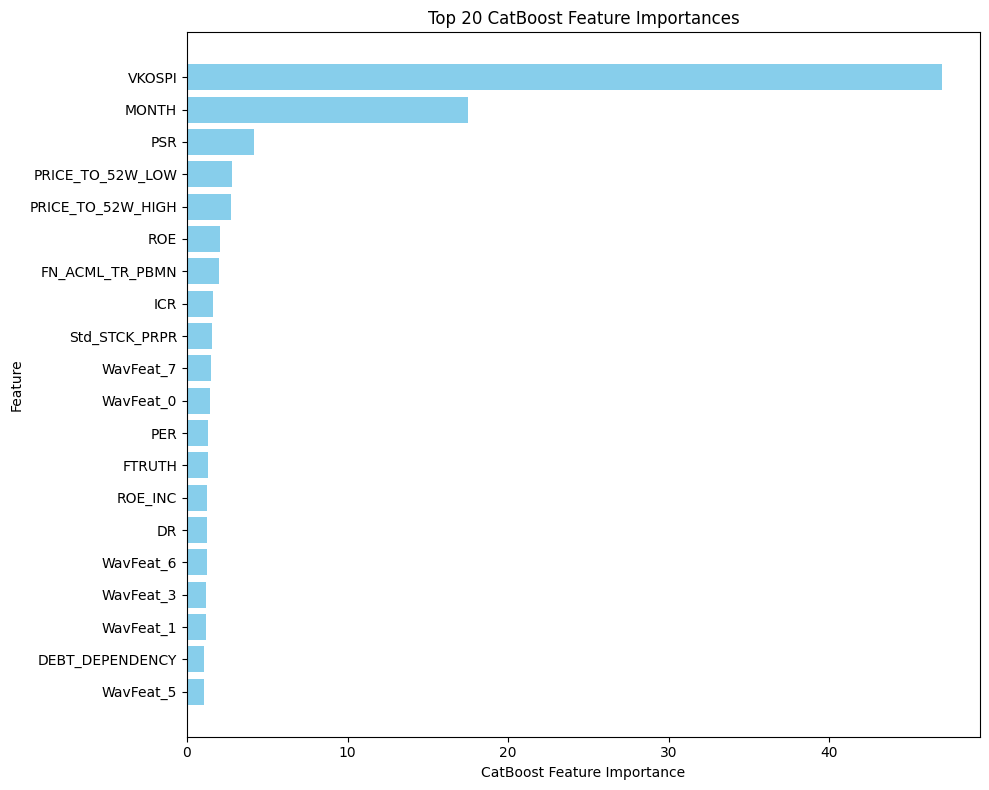


Script finished.


In [ ]:
# ############################################################
# # --- PREVIOUS CODE (Sections 1-14) ---
# # This part includes all the code you provided, ending
# # with the evaluation of LR, RF, XGB, LGBM in Section 14.
# # Assume results dictionary 'results' is initialized and
# # populated by previous models (CatBoost, LR, RF, XGB, LGBM)
# # Assume train_features_scaled, test_features_scaled,
# # y_train, y_test, and scale_pos_weight_value are available.
# ############################################################

# >>> ADDITION START: Imports needed for DL models (Add near top of script) <<<
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Reshape, Conv1D, MaxPooling1D, LSTM, GRU, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam # Keep Adam import
from tensorflow.keras.callbacks import EarlyStopping # Keep EarlyStopping import
# >>> ADDITION END <<<


# >>> ADDITION START: Calculate Class Weights for Keras (Add after Section 12 / before Section 13) <<<
# Calculate class weights for Keras models
if scale_pos_weight_value == 1.0:
    keras_class_weight = None # No weighting needed
    print("Keras class_weight: None (balanced or single class)")
else:
    # Keras expects weights for each class {class_index: weight}
    # Weight for class 0 is typically 1
    # Weight for class 1 is scale_pos_weight
    keras_class_weight = {0: 1.0, 1: scale_pos_weight_value}
    print(f"Keras class_weight: {keras_class_weight}")
# >>> ADDITION END <<<


############################################################
# 15) Deep Learning Model Definitions (Using Combined Features)
############################################################
print("\n--- Section 15: Defining Deep Learning Models (on Combined Features) ---")

# --- Define Input Shape ---
# Input shape is the number of combined features
input_shape_flat = (train_features_scaled.shape[1],)
# Reshape target for CNN/RNN layers: (batch_size, steps, features)
# We'll treat the flat features as 'steps' with 1 feature per step.
reshape_target = (train_features_scaled.shape[1], 1)
print(f"DL Input Shape (Flat): {input_shape_flat}")
print(f"DL Reshape Target: {reshape_target}")


# --- CNN Model ---
def build_cnn_model(input_shape, reshape_target_cnn, learning_rate=0.001):
    input_layer = Input(shape=input_shape, name='Input_Combined')
    # Reshape flat features into a pseudo-sequence
    reshaped = Reshape(target_shape=reshape_target_cnn, name='Reshape')(input_layer)
    # Apply Conv1D
    conv1 = Conv1D(filters=32, kernel_size=3, activation='relu', name='Conv1D_1')(reshaped)
    pool1 = MaxPooling1D(pool_size=2, name='MaxPool_1')(conv1)
    conv2 = Conv1D(filters=64, kernel_size=3, activation='relu', name='Conv1D_2')(pool1)
    # Global pooling to flatten
    gap = GlobalAveragePooling1D(name='GlobalAvgPool')(conv2)
    # Dense layers
    dense1 = Dense(64, activation='relu', name='Dense_1')(gap)
    dropout1 = Dropout(0.3, name='Dropout_1')(dense1)
    output_layer = Dense(1, activation='sigmoid', name='Output_Sigmoid')(dropout1)

    model = Model(inputs=input_layer, outputs=output_layer)
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['AUC'])
    print("--- CNN Model Summary ---")
    model.summary()
    return model

# --- LSTM Model ---
def build_lstm_model(input_shape, reshape_target_lstm, learning_rate=0.001):
    input_layer = Input(shape=input_shape, name='Input_Combined')
    reshaped = Reshape(target_shape=reshape_target_lstm, name='Reshape')(input_layer)
    # Apply LSTM
    lstm1 = LSTM(units=50, return_sequences=False, name='LSTM_1')(reshaped) # return_sequences=False for the last layer
    # Dense layers
    dense1 = Dense(32, activation='relu', name='Dense_1')(lstm1)
    dropout1 = Dropout(0.3, name='Dropout_1')(dense1)
    output_layer = Dense(1, activation='sigmoid', name='Output_Sigmoid')(dropout1)

    model = Model(inputs=input_layer, outputs=output_layer)
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['AUC'])
    print("--- LSTM Model Summary ---")
    model.summary()
    return model

# --- GRU Model ---
def build_gru_model(input_shape, reshape_target_gru, learning_rate=0.001):
    input_layer = Input(shape=input_shape, name='Input_Combined')
    reshaped = Reshape(target_shape=reshape_target_gru, name='Reshape')(input_layer)
    # Apply GRU
    gru1 = GRU(units=50, return_sequences=False, name='GRU_1')(reshaped)
    # Dense layers
    dense1 = Dense(32, activation='relu', name='Dense_1')(gru1)
    dropout1 = Dropout(0.3, name='Dropout_1')(dense1)
    output_layer = Dense(1, activation='sigmoid', name='Output_Sigmoid')(dropout1)

    model = Model(inputs=input_layer, outputs=output_layer)
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['AUC'])
    print("--- GRU Model Summary ---")
    model.summary()
    return model

# --- Transformer Encoder Block Model ---
def build_transformer_model(input_shape, reshape_target_tf, head_size=256, num_heads=4, ff_dim=4, dropout=0.2, learning_rate=0.001):
    input_layer = Input(shape=input_shape, name='Input_Combined')
    reshaped = Reshape(target_shape=reshape_target_tf, name='Reshape')(input_layer)

    # Optional: Dense projection before Attention
    # projected = Dense(head_size, activation='relu')(reshaped)

    # Simplified Transformer Block (Attention + FeedForward)
    # Layer Normalization 1
    norm1 = LayerNormalization(epsilon=1e-6, name='LayerNorm_1')(reshaped) # Apply norm on reshaped input
    # Multi-Head Attention
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=head_size // num_heads, dropout=dropout, name='MultiHeadAttention'
    )(norm1, norm1) # Self-attention
    # Skip Connection 1 (Add)
    add1 = tf.keras.layers.Add(name='Add_1')([reshaped, attn_output]) # Add attention output to original reshaped input

    # Layer Normalization 2
    norm2 = LayerNormalization(epsilon=1e-6, name='LayerNorm_2')(add1)
    # Feed Forward Network
    ffn1 = Dense(ff_dim, activation="relu", name='FFN_1')(norm2)
    ffn_dropout = Dropout(dropout, name='FFN_Dropout')(ffn1)
    ffn2 = Dense(reshape_target_tf[-1], name='FFN_2')(ffn_dropout) # Project back to original dimension
    # Skip Connection 2 (Add)
    add2 = tf.keras.layers.Add(name='Add_2')([add1, ffn2]) # Add FFN output to output of first Add layer

    # Pooling and Final Classification Layers
    pool = GlobalAveragePooling1D(name='GlobalAvgPool')(add2)
    dense_out1 = Dense(64, activation="relu", name='Dense_Out_1')(pool)
    dropout_out = Dropout(0.3, name='Dropout_Out')(dense_out1)
    output_layer = Dense(1, activation="sigmoid", name='Output_Sigmoid')(dropout_out)

    model = Model(inputs=input_layer, outputs=output_layer)
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['AUC'])
    print("--- Transformer Model Summary ---")
    model.summary()
    return model

from tensorflow.keras.layers import Layer

class PositionalEmbedding(Layer):
    def __init__(self, sequence_length, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.position_embeddings = self.add_weight(
            shape=(sequence_length, output_dim),
            initializer="uniform",
            trainable=True,
            name="position_embeddings"
        )
        self.sequence_length = sequence_length
        self.output_dim = output_dim

    def call(self, inputs):
        # 입력 텐서에 위치 임베딩을 더해줍니다.
        return inputs + self.position_embeddings

    def compute_mask(self, inputs, mask=None):
        return mask
# >>>>> 추가 끝 <<<<<

# --- Transformer Encoder Block Model ---
def build_transformer_model_pos_encoding(input_shape, reshape_target_tf, head_size=64, num_heads=4, ff_dim=4, dropout=0.2, learning_rate=0.01):
    input_layer = Input(shape=input_shape, name='Input_Combined')
    reshaped = Reshape(target_shape=reshape_target_tf, name='Reshape')(input_layer)

    # >>>>> 추가: Reshape 바로 다음에 포지셔널 인코딩 적용 <<<<<
    sequence_length = reshape_target_tf[0] # 시퀀스 길이
    output_dim = reshape_target_tf[1]      # 피처 차원
    x = Dense(64)(reshaped)  # feature_dim을 64로 확장
    x = PositionalEmbedding(sequence_length=sequence_length, output_dim=output_dim)(reshaped)


    # Simplified Transformer Block (Attention + FeedForward)
    # Layer Normalization 1
    # >>>>> 수정: 입력으로 'reshaped' 대신 포지셔널 인코딩이 추가된 'x'를 사용 <<<<<
    norm1 = LayerNormalization(epsilon=1e-6, name='LayerNorm_1')(x)
    # Multi-Head Attention
    attn_output = MultiHeadAttention(
        num_heads=num_heads, key_dim=head_size // num_heads, dropout=dropout, name='MultiHeadAttention'
    )(norm1, norm1) # Self-attention
    # Skip Connection 1 (Add)
    # >>>>> 수정: 첫 번째 입력으로 'reshaped' 대신 'x'를 사용 <<<<<
    add1 = tf.keras.layers.Add(name='Add_1')([x, attn_output])

    # (이하 코드는 동일)
    # Layer Normalization 2
    norm2 = LayerNormalization(epsilon=1e-6, name='LayerNorm_2')(add1)
    # Feed Forward Network
    ffn1 = Dense(ff_dim, activation="relu", name='FFN_1')(norm2)
    ffn_dropout = Dropout(dropout, name='FFN_Dropout')(ffn1)
    ffn2 = Dense(reshape_target_tf[-1], name='FFN_2')(ffn_dropout)
    # Skip Connection 2 (Add)
    add2 = tf.keras.layers.Add(name='Add_2')([add1, ffn2])

    # Pooling and Final Classification Layers
    pool = GlobalAveragePooling1D(name='GlobalAvgPool')(add2)
    dense_out1 = Dense(64, activation="relu", name='Dense_Out_1')(pool)
    dropout_out = Dropout(0.3, name='Dropout_Out')(dense_out1)
    output_layer = Dense(1, activation="sigmoid", name='Output_Sigmoid')(dropout_out)

    model = Model(inputs=input_layer, outputs=output_layer)
    optimizer = Adam(learning_rate=learning_rate) # 필요시 학습률 상향 조정 (e.g., 0.0005)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['AUC'])
    print("--- Transformer Model Summary (with Positional Embedding) ---")
    model.summary()
    return model

# 동일한 입력을 받되, 내부 처리 방식을 개선한 트랜스포머
def build_tabular_transformer_model(input_shape, head_size=64, num_heads=4, ff_dim=32, embedding_dim=16, dropout=0.2, learning_rate=0.001):

    # 입력은 다른 모델과 동일한 평평한 벡터
    input_layer = Input(shape=input_shape, name='Input_Flat_Features') # 예: (29,)

    # 1. 트랜스포머가 처리할 수 있도록 차원 변경
    # (None, 29) -> (None, 29, 1)
    reshaped = Reshape((input_shape[0], 1), name='Reshape_for_Embedding')(input_layer)

    # 2. 피처 임베딩 레이어 (가장 중요한 수정!)
    # 각 피처(1차원)를 embedding_dim 차원의 벡터로 변환
    # (None, 29, 1) -> (None, 29, 16)
    feature_embedding = Dense(embedding_dim, activation='relu', name='Feature_Embedding')(reshaped)

    # ** 포지셔널 인코딩은 의도적으로 삭제합니다. **

    # 3. 트랜스포머 인코더 블록 (입력으로 feature_embedding을 사용)
    norm1 = LayerNormalization(epsilon=1e-6)(feature_embedding)
    attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=head_size // num_heads, dropout=dropout)(norm1, norm1)
    add1 = tf.keras.layers.Add()([feature_embedding, attn_output])

    norm2 = LayerNormalization(epsilon=1e-6)(add1)
    ffn = Dense(ff_dim, activation="relu")(norm2)
    ffn = Dense(embedding_dim)(ffn) # 차원 맞추기
    add2 = tf.keras.layers.Add()([add1, ffn])

    # 4. 최종 예측기
    # (None, 29, 16) -> (None, 16)
    pool = GlobalAveragePooling1D(name='GlobalAvgPool')(add2)
    dense_out = Dense(64, activation="relu")(pool)
    dropout_out = Dropout(0.3)(dense_out)
    output_layer = Dense(1, activation="sigmoid", name='Output_Sigmoid')(dropout_out)

    model = Model(inputs=input_layer, outputs=output_layer)
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['AUC'])

    print("--- Tabular Transformer Model Summary ---")
    model.summary()
    return model

############################################################
# 16) Deep Learning Model Training and Evaluation
############################################################
print("\n--- Section 16: Training and Evaluating Deep Learning Models ---")

# --- Training Parameters ---
epochs = 50 # Adjust as needed
batch_size = 128 # Adjust based on memory
patience = 10 # Early stopping patience

# Common Early Stopping Callback
early_stopping = EarlyStopping(monitor='val_loss', # Monitor validation loss
                               patience=patience,
                               restore_best_weights=True, # Restore weights from the best epoch
                               verbose=1)

# --- Train and Evaluate CNN ---
print("\n--- Training and Evaluating CNN ---")
try:
    model_cnn = build_cnn_model(input_shape_flat, reshape_target)
    history_cnn = model_cnn.fit(train_features_scaled, y_train,
                                validation_data=(val_features_scaled, y_val),
                                epochs=epochs,
                                batch_size=batch_size,
                                callbacks=[early_stopping],
                                class_weight=keras_class_weight, # Use calculated class weights
                                verbose=1) # Set verbose=2 for less output per epoch

    pred_train_proba_cnn = model_cnn.predict(train_features_scaled).ravel()
    pred_test_proba_cnn = model_cnn.predict(test_features_scaled).ravel()

    roc_auc_train_cnn = roc_auc_score(y_train, pred_train_proba_cnn)
    roc_auc_test_cnn = roc_auc_score(y_test, pred_test_proba_cnn)
    ks_train_cnn = calculate_ks(y_train, pred_train_proba_cnn)
    ks_test_cnn = calculate_ks(y_test, pred_test_proba_cnn)
    logloss_train_cnn = log_loss(y_train, pred_train_proba_cnn)
    logloss_test_cnn = log_loss(y_test, pred_test_proba_cnn)
    brier_train_cnn = brier_score_loss(y_train, pred_train_proba_cnn)
    brier_test_cnn = brier_score_loss(y_test, pred_test_proba_cnn)

    print(f'[CNN] Train AUC: {roc_auc_train_cnn:.5f} | Train KS: {ks_train_cnn:.5f} | Train LogLoss: {logloss_train_cnn:.5f} | Train Brier: {brier_train_cnn:.5f}')
    print(f'[CNN] Test  AUC: {roc_auc_test_cnn:.5f}  | Test KS: {ks_test_cnn:.5f}  | Test LogLoss: {logloss_test_cnn:.5f}  | Test Brier: {brier_test_cnn:.5f}')

    results['CNN'] = {'train_auc': roc_auc_train_cnn, 'test_auc': roc_auc_test_cnn,
                      'train_ks': ks_train_cnn, 'test_ks': ks_test_cnn,
                      'train_logloss': logloss_train_cnn, 'test_logloss': logloss_test_cnn,
                      'train_brier': brier_train_cnn, 'test_brier': brier_test_cnn}
except Exception as e:
    print(f"Error training/evaluating CNN: {e}")
    results['CNN'] = {'train_auc': np.nan, 'test_auc': np.nan, 'train_ks': np.nan, 'test_ks': np.nan,
                      'train_logloss': np.nan, 'test_logloss': np.nan, 'train_brier': np.nan, 'test_brier': np.nan}


# --- Train and Evaluate LSTM ---
print("\n--- Training and Evaluating LSTM ---")
try:
    model_lstm = build_lstm_model(input_shape_flat, reshape_target)
    history_lstm = model_lstm.fit(train_features_scaled, y_train,
                                  validation_data=(val_features_scaled, y_val),
                                  epochs=epochs,
                                  batch_size=batch_size,
                                  callbacks=[early_stopping],
                                  class_weight=keras_class_weight,
                                  verbose=1)

    pred_train_proba_lstm = model_lstm.predict(train_features_scaled).ravel()
    pred_test_proba_lstm = model_lstm.predict(test_features_scaled).ravel()

    roc_auc_train_lstm = roc_auc_score(y_train, pred_train_proba_lstm)
    roc_auc_test_lstm = roc_auc_score(y_test, pred_test_proba_lstm)
    ks_train_lstm = calculate_ks(y_train, pred_train_proba_lstm)
    ks_test_lstm = calculate_ks(y_test, pred_test_proba_lstm)
    logloss_train_lstm = log_loss(y_train, pred_train_proba_lstm)
    logloss_test_lstm = log_loss(y_test, pred_test_proba_lstm)
    brier_train_lstm = brier_score_loss(y_train, pred_train_proba_lstm)
    brier_test_lstm = brier_score_loss(y_test, pred_test_proba_lstm)

    print(f'[LSTM] Train AUC: {roc_auc_train_lstm:.5f} | Train KS: {ks_train_lstm:.5f} | Train LogLoss: {logloss_train_lstm:.5f} | Train Brier: {brier_train_lstm:.5f}')
    print(f'[LSTM] Test  AUC: {roc_auc_test_lstm:.5f}  | Test KS: {ks_test_lstm:.5f}  | Test LogLoss: {logloss_test_lstm:.5f}  | Test Brier: {brier_test_lstm:.5f}')

    results['LSTM'] = {'train_auc': roc_auc_train_lstm, 'test_auc': roc_auc_test_lstm,
                       'train_ks': ks_train_lstm, 'test_ks': ks_test_lstm,
                       'train_logloss': logloss_train_lstm, 'test_logloss': logloss_test_lstm,
                       'train_brier': brier_train_lstm, 'test_brier': brier_test_lstm}
except Exception as e:
    print(f"Error training/evaluating LSTM: {e}")
    results['LSTM'] = {'train_auc': np.nan, 'test_auc': np.nan, 'train_ks': np.nan, 'test_ks': np.nan,
                       'train_logloss': np.nan, 'test_logloss': np.nan, 'train_brier': np.nan, 'test_brier': np.nan}


# --- Train and Evaluate GRU ---
print("\n--- Training and Evaluating GRU ---")
try:
    model_gru = build_gru_model(input_shape_flat, reshape_target)
    history_gru = model_gru.fit(train_features_scaled, y_train,
                                validation_data=(val_features_scaled, y_val),
                                epochs=epochs,
                                batch_size=batch_size,
                                callbacks=[early_stopping],
                                class_weight=keras_class_weight,
                                verbose=1)

    pred_train_proba_gru = model_gru.predict(train_features_scaled).ravel()
    pred_test_proba_gru = model_gru.predict(test_features_scaled).ravel()

    roc_auc_train_gru = roc_auc_score(y_train, pred_train_proba_gru)
    roc_auc_test_gru = roc_auc_score(y_test, pred_test_proba_gru)
    ks_train_gru = calculate_ks(y_train, pred_train_proba_gru)
    ks_test_gru = calculate_ks(y_test, pred_test_proba_gru)
    logloss_train_gru = log_loss(y_train, pred_train_proba_gru)
    logloss_test_gru = log_loss(y_test, pred_test_proba_gru)
    brier_train_gru = brier_score_loss(y_train, pred_train_proba_gru)
    brier_test_gru = brier_score_loss(y_test, pred_test_proba_gru)

    print(f'[GRU] Train AUC: {roc_auc_train_gru:.5f} | Train KS: {ks_train_gru:.5f} | Train LogLoss: {logloss_train_gru:.5f} | Train Brier: {brier_train_gru:.5f}')
    print(f'[GRU] Test  AUC: {roc_auc_test_gru:.5f}  | Test KS: {ks_test_gru:.5f}  | Test LogLoss: {logloss_test_gru:.5f}  | Test Brier: {brier_test_gru:.5f}')

    results['GRU'] = {'train_auc': roc_auc_train_gru, 'test_auc': roc_auc_test_gru,
                      'train_ks': ks_train_gru, 'test_ks': ks_test_gru,
                      'train_logloss': logloss_train_gru, 'test_logloss': logloss_test_gru,
                      'train_brier': brier_train_gru, 'test_brier': brier_test_gru}
except Exception as e:
    print(f"Error training/evaluating GRU: {e}")
    results['GRU'] = {'train_auc': np.nan, 'test_auc': np.nan, 'train_ks': np.nan, 'test_ks': np.nan,
                      'train_logloss': np.nan, 'test_logloss': np.nan, 'train_brier': np.nan, 'test_brier': np.nan}


# --- Train and Evaluate Transformer ---
print("\n--- Training and Evaluating Transformer ---")
try:
    # 1. 수정된 트랜스포머 모델 생성
    input_shape_flat = (train_features_scaled.shape[1],)

    # Adjust hyperparameters if needed
    model_tf = build_tabular_transformer_model(input_shape_flat,
                                              head_size=128, num_heads=4, ff_dim=64, dropout=0.25)
    history_tf = model_tf.fit(train_features_scaled, y_train,
                              validation_data=(val_features_scaled, y_val),
                              epochs=epochs,
                              batch_size=batch_size,
                              callbacks=[early_stopping],
                              class_weight=keras_class_weight,
                              verbose=1)

    pred_train_proba_tf = model_tf.predict(train_features_scaled).ravel()
    pred_test_proba_tf = model_tf.predict(test_features_scaled).ravel()

    roc_auc_train_tf = roc_auc_score(y_train, pred_train_proba_tf)
    roc_auc_test_tf = roc_auc_score(y_test, pred_test_proba_tf)
    ks_train_tf = calculate_ks(y_train, pred_train_proba_tf)
    ks_test_tf = calculate_ks(y_test, pred_test_proba_tf)
    logloss_train_tf = log_loss(y_train, pred_train_proba_tf)
    logloss_test_tf = log_loss(y_test, pred_test_proba_tf)
    brier_train_tf = brier_score_loss(y_train, pred_train_proba_tf)
    brier_test_tf = brier_score_loss(y_test, pred_test_proba_tf)

    print(f'[Transformer] Train AUC: {roc_auc_train_tf:.5f} | Train KS: {ks_train_tf:.5f} | Train LogLoss: {logloss_train_tf:.5f} | Train Brier: {brier_train_tf:.5f}')
    print(f'[Transformer] Test  AUC: {roc_auc_test_tf:.5f}  | Test KS: {ks_test_tf:.5f}  | Test LogLoss: {logloss_test_tf:.5f}  | Test Brier: {brier_test_tf:.5f}')

    results['Transformer'] = {'train_auc': roc_auc_train_tf, 'test_auc': roc_auc_test_tf,
                              'train_ks': ks_train_tf, 'test_ks': ks_test_tf,
                              'train_logloss': logloss_train_tf, 'test_logloss': logloss_test_tf,
                              'train_brier': brier_train_tf, 'test_brier': brier_test_tf}
except Exception as e:
    print(f"Error training/evaluating Transformer: {e}")
    results['Transformer'] = {'train_auc': np.nan, 'test_auc': np.nan, 'train_ks': np.nan, 'test_ks': np.nan,
                              'train_logloss': np.nan, 'test_logloss': np.nan, 'train_brier': np.nan, 'test_brier': np.nan}


############################################################
# 17) 결과 요약 (Renumbered)
############################################################
print("\n--- Section 17: Model Performance Summary ---")
# Results from DL models are now included in the 'results' dictionary
results_df = pd.DataFrame.from_dict(results, orient='index')
# Display all columns for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(results_df.sort_values(by='test_auc', ascending=False)) # Sort by test AUC


############################################################
# 18) CatBoost Feature Importance (Renumbered)
############################################################
print("\n--- Section 18: CatBoost Feature Importance ---")

try:
    # 1. 피처 이름 생성 (Code from original Section 16 is unchanged)
    feature_names = []
    if include_stat_features:
        num_wavelet_features = train_wavelet_features.shape[1]
        wavelet_names = [f'WavFeat_{i}' for i in range(num_wavelet_features)]
        feature_names.extend(wavelet_names)
        if train_stds.shape[1] == len(stock_features):
            std_names = [f'Std_{f}' for f in stock_features]
        else:
            print(f"Warning: Mismatch between std feature count ({train_stds.shape[1]}) and stock_features count ({len(stock_features)}). Using generic std names.")
            std_names = [f'StdFeat_{i}' for i in range(train_stds.shape[1])]
        feature_names.extend(std_names)

    if X_fin_train.size > 0:
        feature_names.extend(fin_features)

    # 최종 피처 이름 개수와 실제 학습 피처 개수 확인
    if len(feature_names) != train_features_scaled.shape[1]:
        print(f"Error: Final feature name count ({len(feature_names)}) does not match training feature count ({train_features_scaled.shape[1]}). Cannot reliably show feature importances.")
    else:
        # 2. 변수 중요도 추출
        importances = cat_model.feature_importances_

        # 3. DataFrame 생성 및 정렬
        importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
        importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

        # 4. 결과 출력 (상위 20개)
        print("\nTop 20 CatBoost Feature Importances:")
        print(importance_df.head(20))

        # 5. 결과 시각화 (상위 20개)
        plt.figure(figsize=(10, 8))
        plt.barh(importance_df['Feature'][:20], importance_df['Importance'][:20], color='skyblue')
        plt.xlabel("CatBoost Feature Importance")
        plt.ylabel("Feature")
        plt.title("Top 20 CatBoost Feature Importances")
        plt.gca().invert_yaxis() # 중요도 높은 피처를 위로
        plt.tight_layout()
        plt.show()

except AttributeError:
    print("Error: Could not retrieve feature importances. Was the CatBoost model trained successfully?")
except NameError as e:
    print(f"Error: A required variable for feature importance generation is not defined: {e}")
except Exception as e:
    print(f"An error occurred while calculating/displaying CatBoost feature importances: {e}")


print("\nScript finished.")

# result summary

In [ ]:
0
             train_auc  test_auc  train_ks   test_ks  train_logloss  test_logloss  train_brier  test_brier
RF            0.943451  0.721918  0.755137  0.332266       0.344787      0.382174     0.097624    0.116248
LGBM          0.975502  0.706456  0.856749  0.323570       0.235965      0.448929     0.070371    0.126626
XGB           0.968140  0.704897  0.817999  0.311230       0.256386      0.423265     0.074125    0.123355
LSTM          0.703635  0.696672  0.331358  0.307566       0.569644      0.422742     0.204056    0.135224
CatBoost      0.980036  0.687818  0.878748  0.299719       0.222728      0.428358     0.060739    0.122439
GRU           0.706835  0.687247  0.353353  0.287191       0.597214      0.438383     0.219853    0.139527
LR            0.787693  0.684916  0.484771  0.278412       0.573564      0.389665     0.194328    0.116835
CNN           0.821948  0.682321  0.535867  0.258276       0.512075      0.438082     0.172743    0.133659
Transformer   0.656518  0.646176  0.243072  0.212977       0.603520      0.511498     0.214219    0.17093

1
             train_auc  test_auc  train_ks   test_ks  train_logloss  test_logloss  train_brier  test_brier
LGBM          0.958641  0.778668  0.788590  0.461978       0.218760      0.163831     0.059606    0.040753
CatBoost      0.938864  0.776132  0.726241  0.432956       0.354965      0.206220     0.101855    0.047210
RF            0.947326  0.774012  0.768903  0.422629       0.341750      0.232494     0.096113    0.055064
XGB           0.905308  0.688662  0.682418  0.379949       0.666611      0.661366     0.236739    0.234117
Transformer   0.690792  0.677588  0.295471  0.299026       0.622331      0.672500     0.224965    0.239155
CNN           0.826001  0.654382  0.542832  0.272368       0.417014      0.300837     0.136963    0.081885
LSTM          0.821013  0.652880  0.508474  0.283612       0.506663      0.461056     0.165109    0.145247
LR            0.792611  0.645916  0.495818  0.300802       0.570437      0.325274     0.192736    0.071918
GRU           0.903867  0.604094  0.665424  0.244652       0.357754      0.301700     0.109344    0.084651

2
             train_auc  test_auc  train_ks   test_ks  train_logloss  test_logloss  train_brier  test_brier
RF            0.949801  0.833198  0.772579  0.537337       0.330271      0.195526     0.092492    0.041501
LGBM          0.961988  0.825979  0.801706  0.542274       0.212708      0.119065     0.057790    0.025243
XGB           0.945075  0.822811  0.750885  0.578153       0.457168      0.406570     0.137225    0.112860
CatBoost      0.899431  0.767091  0.647884  0.420860       0.672410      0.664570     0.239635    0.235717
CNN           0.857081  0.753212  0.559550  0.480593       0.404228      0.215955     0.131854    0.054882
GRU           0.861249  0.750414  0.594361  0.421518       0.465684      0.280248     0.142641    0.086360
LSTM          0.877058  0.737156  0.599162  0.426263       0.447587      0.219760     0.144029    0.067024
LR            0.797529  0.663616  0.509034  0.398468       0.565910      0.397223     0.190386    0.101694
Transformer   0.742399  0.523206  0.388596  0.226755       0.537745      0.839317     0.183597    0.318816

3
             train_auc  test_auc  train_ks   test_ks  train_logloss  test_logloss  train_brier  test_brier
LGBM          0.952863  0.855893  0.775406  0.570740       0.176928      0.147870     0.041616    0.026366
CatBoost      0.890748  0.779973  0.631954  0.454984       0.679407      0.680398     0.243131    0.243626
XGB           0.932588  0.761443  0.726538  0.470725       0.618186      0.631846     0.212669    0.219405
RF            0.951537  0.713336  0.776200  0.407495       0.329198      0.495636     0.091684    0.154210
LSTM          0.928641  0.702859  0.715004  0.370355       0.293397      0.168258     0.088844    0.045529
LR            0.800242  0.681440  0.516583  0.417686       0.564412      1.074342     0.189155    0.409807
CNN           0.828577  0.678300  0.542013  0.385375       0.500134      0.658279     0.167859    0.226535
Transformer   0.667472  0.673777  0.243305  0.322540       0.590429      0.613145     0.203071    0.209737
GRU           0.822394  0.634099  0.540793  0.282852       0.444698      0.491654     0.136592    0.153346

4
             train_auc  test_auc  train_ks   test_ks  train_logloss  test_logloss  train_brier  test_brier
CatBoost      0.930729  0.776230  0.697614  0.451502       0.530583      0.469627     0.170571    0.141486
LGBM          0.973760  0.771478  0.846388  0.436962       0.235702      0.157513     0.070411    0.043997
RF            0.949211  0.758186  0.756165  0.410241       0.336252      0.223465     0.095225    0.053489
XGB           0.978029  0.751924  0.862266  0.422045       0.219411      0.146391     0.062875    0.039095
CNN           0.910077  0.729764  0.677988  0.363023       0.317076      0.175930     0.098944    0.049395
LR            0.805048  0.688188  0.524084  0.351050       0.559176      0.196894     0.187329    0.040697
LSTM          0.901048  0.663874  0.629703  0.285298       0.348202      0.242367     0.106119    0.066289
Transformer   0.650078  0.657466  0.212774  0.243868       0.554127      0.466629     0.186480    0.151911
GRU           0.870916  0.645447  0.603690  0.275165       0.370442      0.320353     0.103414    0.084109

5
             train_auc  test_auc  train_ks   test_ks  train_logloss  test_logloss  train_brier  test_brier
LGBM          0.971447  0.847504  0.838833  0.572445       0.250301      0.165288     0.076285    0.046738
XGB           0.971344  0.844854  0.839852  0.557248       0.248465      0.171737     0.072658    0.047602
CatBoost      0.963818  0.841642  0.809047  0.538087       0.292081      0.246124     0.083186    0.070390
RF            0.935984  0.821484  0.726433  0.548129       0.377492      0.366184     0.111995    0.109153
CNN           0.924913  0.805592  0.693752  0.490239       0.362938      0.374190     0.114162    0.119965
LR            0.748402  0.791549  0.418822  0.488547       0.601796      0.588806     0.206429    0.189950
Transformer   0.859345  0.787115  0.547742  0.485398       0.431489      0.288737     0.137030    0.082660
GRU           0.880126  0.782796  0.595586  0.464091       0.401067      0.330266     0.125796    0.102664
LSTM          0.923898  0.758575  0.699155  0.455474       0.343290      0.314541     0.111380    0.100686

6
             train_auc  test_auc  train_ks   test_ks  train_logloss  test_logloss  train_brier  test_brier
CatBoost      0.952389  0.861127  0.770689  0.594677       0.321129      0.352262     0.092678    0.103165
XGB           0.962808  0.858545  0.802283  0.617657       0.278739      0.222046     0.080900    0.057592
LGBM          0.958286  0.853767  0.788696  0.590973       0.270309      0.183992     0.080336    0.049597
RF            0.928086  0.836854  0.707686  0.566690       0.389682      0.429654     0.117069    0.133056
LSTM          0.908385  0.814062  0.650874  0.528609       0.357415      0.313210     0.116440    0.100216
GRU           0.865760  0.798046  0.565117  0.497943       0.367383      0.334588     0.114062    0.102926
LR            0.743659  0.795029  0.407223  0.514535       0.605192      0.757134     0.207843    0.272967
CNN           0.889879  0.793624  0.618786  0.480745       0.371960      0.258060     0.118258    0.074247
Transformer   0.749993  0.743460  0.364548  0.429778       0.533838      0.360800     0.186097    0.110382

7
             train_auc  test_auc  train_ks   test_ks  train_logloss  test_logloss  train_brier  test_brier
XGB           0.964069  0.850365  0.810722  0.575186       0.275093      0.195490     0.079334    0.053322
LGBM          0.969230  0.847928  0.826995  0.624478       0.259266      0.194478     0.077829    0.053429
CatBoost      0.945886  0.841021  0.748080  0.601826       0.335872      0.263617     0.097486    0.070835
RF            0.932471  0.835775  0.723001  0.572392       0.378168      0.331942     0.112174    0.086784
LSTM          0.892515  0.799426  0.611463  0.498435       0.384441      0.236183     0.121328    0.075536
GRU           0.891058  0.789933  0.618683  0.502832       0.356945      0.225710     0.110554    0.067566
LR            0.747925  0.778450  0.419114  0.475447       0.601985      0.886636     0.206429    0.332374
CNN           0.909042  0.768979  0.655378  0.457489       0.329373      0.225111     0.102985    0.066223
Transformer   0.692944  0.648517  0.290468  0.278428       0.613220      0.813651     0.213455    0.307784

8
             train_auc  test_auc  train_ks   test_ks  train_logloss  test_logloss  train_brier  test_brier
CatBoost      0.947836  0.847061  0.751850  0.562884       0.329091      0.461976     0.095914    0.148328
LGBM          0.978453  0.833760  0.871062  0.585075       0.227718      0.292263     0.067196    0.091308
XGB           0.965369  0.829185  0.811336  0.574802       0.271065      0.306784     0.078076    0.089132
RF            0.935764  0.823355  0.727625  0.569873       0.370415      0.459993     0.108061    0.145489
GRU           0.908685  0.793311  0.660664  0.477990       0.325134      0.336134     0.101835    0.117404
CNN           0.905970  0.773110  0.636715  0.446380       0.341377      0.537007     0.107491    0.189419
LR            0.753562  0.770874  0.423945  0.499667       0.599364      0.363510     0.205793    0.096204
LSTM          0.907611  0.762571  0.656228  0.477575       0.333358      0.377195     0.106127    0.132338
Transformer   0.845877  0.745400  0.527241  0.381093       0.414399      0.388622     0.131109    0.123734

9
             train_auc  test_auc  train_ks   test_ks  train_logloss  test_logloss  train_brier  test_brier
CatBoost      0.944175  0.837530  0.739889  0.561461       0.337918      0.343018     0.098067    0.100042
RF            0.936639  0.835385  0.723571  0.576801       0.369377      0.341784     0.106609    0.098535
XGB           0.962062  0.833648  0.798915  0.542280       0.280896      0.272847     0.080234    0.076768
LGBM          0.976443  0.812395  0.860958  0.507933       0.237490      0.251750     0.069857    0.075509
LR            0.753206  0.811885  0.423680  0.534025       0.600217      0.528841     0.206306    0.166321
CNN           0.899560  0.808088  0.613072  0.534548       0.261172      0.229758     0.075712    0.066703
GRU           0.888156  0.806578  0.600699  0.514571       0.422715      0.291058     0.127414    0.083472
LSTM          0.912555  0.794070  0.660025  0.531316       0.376578      0.320543     0.117384    0.099898
Transformer   0.652161  0.703490  0.244012  0.330494       0.718119      0.591631     0.262800    0.202866

## pridman test

In [ ]:
import numpy as np
from scipy.stats import rankdata, chi2, friedmanchisquare

# 알고리즘 이름 (k=8)
#LGBM	CatBoost	XGB	RF	CNN	LSTM	LR	GRU	Transformer
algorithms = ["LGBM",	"CatBoost",	"XGB",	"RF",	"CNN",	"LSTM",	"LR",	"GRU",	"Transformer"]
k = len(algorithms)

# 기간 이름 (N=10)
periods = ["22.3", "22.6", "22.9", "22.12", "23.3", "23.6", "23.9", "23.12", "24.3", "24.6"]
N = len(periods)

# Test AUC 데이터 (이전 답변에서 추출한 값)
# 행: 기간, 열: 알고리즘 순서대로 (LGBM, CatBoost, RF, XGB, Transformer, CNN, LSTM, GRU)
data_auc = np.array([
[0.706456,	0.687818,	0.704897,	0.721918,	0.682321,	0.696672,	0.684916,	0.687247,	0.646176],
[0.778668,	0.776132,	0.688662,	0.774012,	0.654382,	0.65288,	0.645916,	0.604094,	0.677588],
[0.825979,	0.767091,	0.822811,	0.833198,	0.753212,	0.737156,	0.663616,	0.750414,	0.523206],
[0.855893,	0.779973,	0.761443,	0.713336,	0.6783,	0.702859,	0.68144,	0.634099,	0.673777],
[0.771478,	0.77623,	0.751924,	0.758186,	0.729764,	0.663874,	0.688188,	0.645447,	0.657466],
[0.847504,	0.841642,	0.844854,	0.821484,	0.805592,	0.758575,	0.791549,	0.782796,	0.787115],
[0.853767,	0.861127,	0.858545,	0.836854,	0.793624,	0.814062,	0.795029,	0.798046,	0.74346],
[0.847928,	0.841021,	0.850365,	0.835775,	0.768979,	0.799426,	0.77845,	0.789933,	0.648517],
[0.83376,	0.847061,	0.829185,	0.823355,	0.77311,	0.762571,	0.770874,	0.793311,	0.7454],
[0.812395,	0.83753,	0.833648,	0.835385,	0.808088,	0.79407,	0.811885,	0.806578,	0.70349]
])

print("--- 원본 Test AUC 데이터 ---")
print("알고리즘 순서:", algorithms)
for i, period_name in enumerate(periods):
    print(f"기간 {period_name}: {data_auc[i, :]}")

# --- 1. 수동 계산 과정 ---
print("\n--- 1. 프리드만 검정 수동 계산 과정 ---")

# 단계 2: 각 기간(행)별 순위 매기기 (rij)
# 높은 AUC가 1위가 되도록, -data_auc 값을 사용하여 순위를 매깁니다.
# rankdata는 기본적으로 가장 작은 값에 1위를 부여합니다.
ranks_table = np.zeros_like(data_auc)
for i in range(N):
    ranks_table[i, :] = rankdata(-data_auc[i, :], method='average')

print("\n--- 순위표 (rij) ---")
print("알고리즘 순서:", algorithms)
for i, period_name in enumerate(periods):
    print(f"기간 {period_name}: {ranks_table[i, :]}")

# 단계 3: 각 알고리즘의 평균 순위 계산 (Rj)
avg_ranks_Rj = np.mean(ranks_table, axis=0)
print("\n--- 각 알고리즘의 평균 순위 (Rj) ---")
for i, algo_name in enumerate(algorithms):
    print(f"{algo_name:<12}: {avg_ranks_Rj[i]:.4f}")

# 단계 4: 프리드만 통계량 (chi_F^2) 계산
# 공식: chi_F^2 = [12N / (k(k+1))] * [sum(Rj^2) - k(k+1)^2 / 4]
sum_of_squared_avg_ranks = np.sum(avg_ranks_Rj**2)
term_k_expression = (k * (k + 1)**2) / 4
scaling_factor = (12 * N) / (k * (k + 1))

chi_F_squared_manual = scaling_factor * (sum_of_squared_avg_ranks - term_k_expression)

print(f"\n평균 순위 제곱의 합 (sum(Rj^2)): {sum_of_squared_avg_ranks:.4f}")
print(f"k(k+1)^2 / 4 항: {term_k_expression:.4f}")
print(f"척도 조정 계수 (12N / (k(k+1))): {scaling_factor:.4f}")
print(f"프리드만 통계량 (수동 계산 chi_F^2): {chi_F_squared_manual:.4f}")

# 단계 5: p-값 계산
df_manual = k - 1 # 자유도
p_value_manual = chi2.sf(chi_F_squared_manual, df_manual) # sf는 survival function (1-cdf)

print(f"자유도 (k-1): {df_manual}")
print(f"P-값 (수동 계산): {p_value_manual:.6f}")

if p_value_manual < 0.05:
    print("결론 (수동 계산): 귀무가설을 기각합니다. 알고리즘 간에 통계적으로 유의미한 차이가 있습니다.")
else:
    print("결론 (수동 계산): 귀무가설을 기각하지 못합니다. 알고리즘 간에 통계적으로 유의미한 차이를 발견하지 못했습니다.")

# --- 2. scipy.stats.friedmanchisquare 함수 사용 (권장) ---
print("\n--- 2. scipy.stats.friedmanchisquare 함수 사용 ---")
# 이 함수는 각 그룹(알고리즘)의 관측치를 별도의 인자로 받습니다.
# data_auc 배열의 열을 언패킹하여 전달합니다. (data_auc를 전치한 후 각 행을 전달)
# data_auc의 형태: (N, k) -> data_auc.T의 형태: (k, N)
# *data_auc.T는 각 알고리즘의 N개 기간에 대한 성능 값을 개별 인자로 풀어줍니다.

chi_F_squared_scipy, p_value_scipy = friedmanchisquare(*data_auc.T)

print(f"프리드만 통계량 (scipy 함수): {chi_F_squared_scipy:.4f}")
print(f"P-값 (scipy 함수): {p_value_scipy:.6f}")

if p_value_scipy < 0.05:
    print("결론 (scipy 함수): 귀무가설을 기각합니다. 알고리즘 간에 통계적으로 유의미한 차이가 있습니다.")
else:
    print("결론 (scipy 함수): 귀무가설을 기각하지 못합니다. 알고리즘 간에 통계적으로 유의미한 차이를 발견하지 못했습니다.")

print("\n--- 계산 결과 검증 ---")
# 부동소수점 비교를 위해 assert_almost_equal 사용
try:
    np.testing.assert_almost_equal(chi_F_squared_manual, chi_F_squared_scipy, decimal=4)
    np.testing.assert_almost_equal(p_value_manual, p_value_scipy, decimal=6)
    print("수동 계산 결과와 scipy 함수 결과가 일치합니다.")
except AssertionError as e:
    print(f"수동 계산 결과와 scipy 함수 결과가 다릅니다: {e}")
    print(f"(수동: chi2={chi_F_squared_manual:.6f}, p={p_value_manual:.6f})")
    print(f"(scipy: chi2={chi_F_squared_scipy:.6f}, p={p_value_scipy:.6f})")

--- 원본 Test AUC 데이터 ---
알고리즘 순서: ['LGBM', 'CatBoost', 'XGB', 'RF', 'CNN', 'LSTM', 'LR', 'GRU', 'Transformer']
기간 22.3: [0.706456 0.687818 0.704897 0.721918 0.682321 0.696672 0.684916 0.687247
 0.646176]
기간 22.6: [0.778668 0.776132 0.688662 0.774012 0.654382 0.65288  0.645916 0.604094
 0.677588]
기간 22.9: [0.825979 0.767091 0.822811 0.833198 0.753212 0.737156 0.663616 0.750414
 0.523206]
기간 22.12: [0.855893 0.779973 0.761443 0.713336 0.6783   0.702859 0.68144  0.634099
 0.673777]
기간 23.3: [0.771478 0.77623  0.751924 0.758186 0.729764 0.663874 0.688188 0.645447
 0.657466]
기간 23.6: [0.847504 0.841642 0.844854 0.821484 0.805592 0.758575 0.791549 0.782796
 0.787115]
기간 23.9: [0.853767 0.861127 0.858545 0.836854 0.793624 0.814062 0.795029 0.798046
 0.74346 ]
기간 23.12: [0.847928 0.841021 0.850365 0.835775 0.768979 0.799426 0.77845  0.789933
 0.648517]
기간 24.3: [0.83376  0.847061 0.829185 0.823355 0.77311  0.762571 0.770874 0.793311
 0.7454  ]
기간 24.6: [0.812395 0.83753  0.833648 0.835385 0.808

In [ ]:
import numpy as np
import itertools # 모든 쌍을 만들기 위해 사용

# --- Nemenyi 검정 코드 ---
# 아래 변수들은 이전 프리드만 검정 코드에서 계산되었다고 가정합니다.
# 예시 값 (실제로는 이전 코드 실행 결과 사용)
# algorithms = ["LGBM", "CatBoost", "RF", "XGB", "Transformer", "CNN", "LSTM", "GRU"]
# k = 8
# N = 5
# avg_ranks_Rj = np.array([1.2, 2.8, 4.8, 3.4, 6.0, 6.0, 5.8, 6.0]) # 이전 계산된 순서대로

# 이전 프리드만 검정 코드의 마지막 부분에서 avg_ranks_Rj, k, N, algorithms를 가져옵니다.
# (실제 실행 시에는 이전 코드에 이어서 실행하거나, 필요한 변수들을 다시 정의/로드해야 합니다.)
# 여기서는 이전 코드에서 계산된 값을 직접 사용하겠습니다.
# algorithms = ["LGBM", "CatBoost", "RF", "XGB", "Transformer", "CNN", "LSTM", "GRU"]
# k = len(algorithms) # 8
# N = 5 # 기간 수
# avg_ranks_Rj = np.array([
#     (1+1+2+1+1)/5,  # LGBM
#     (2+2+3+3+4)/5,  # CatBoost
#     (3+3+7+8+3)/5,  # RF
#     (4+8+1+2+2)/5,  # XGB
#     (5+6+5+6+8)/5,  # Transformer
#     (6+4+8+7+5)/5,  # CNN
#     (7+5+6+5+6)/5,  # LSTM
#     (8+7+4+4+7)/5   # GRU
# ])
# 위의 avg_ranks_Rj는 이미 이전 코드에서 출력된 값을 사용하고 있습니다.

print("\n--- Nemenyi 사후 검정 ---")
print(f"알고리즘 수 (k): {k}")
print(f"기간/Fold 수 (N): {N}")
print("\n--- 각 알고리즘의 평균 순위 (Rj) 재확인 ---")
# 평균 순위를 기준으로 알고리즘 정렬 (결과 보기에 용이)
sorted_indices = np.argsort(avg_ranks_Rj)
sorted_algorithms = [algorithms[i] for i in sorted_indices]
sorted_avg_ranks = avg_ranks_Rj[sorted_indices]

for i in range(len(sorted_algorithms)):
    print(f"{sorted_algorithms[i]:<12}: {sorted_avg_ranks[i]:.4f}")

# 단계 2: q_alpha 값 설정
alpha = 0.05
# Demšar (2006), Appendix A, Table A.3. for two-tailed Nemenyi test
# k=8, alpha=0.05 일 때 q_alpha 값
q_alpha = 3.030 # (k=8, alpha=0.05에 해당하는 값)

print(f"\n유의수준 (alpha): {alpha}")
print(f"q_alpha 값 (k={k}, alpha={alpha}): {q_alpha}")

# 단계 3: 임계 차이 (Critical Difference, CD) 계산
# CD = q_alpha * sqrt(k*(k+1) / (6*N))
critical_difference_cd = q_alpha * np.sqrt((k * (k + 1)) / (6 * N))
print(f"임계 차이 (CD): {critical_difference_cd:.4f}")

# 단계 4: 모든 알고리즘 쌍 간의 평균 순위 차이 계산 및 비교
print("\n--- 알고리즘 쌍별 비교 ---")
significant_differences = []

# 모든 고유한 쌍 생성 (itertools.combinations 사용)
# 원본 algorithms 리스트와 avg_ranks_Rj를 사용하여 인덱스로 접근
for i, j in itertools.combinations(range(k), 2):
    algo1_name = algorithms[i]
    algo2_name = algorithms[j]

    avg_rank_algo1 = avg_ranks_Rj[i]
    avg_rank_algo2 = avg_ranks_Rj[j]

    rank_difference = np.abs(avg_rank_algo1 - avg_rank_algo2)

    is_significant = rank_difference >= critical_difference_cd

    comparison_result = (
        f"|{algo1_name} (R={avg_rank_algo1:.2f}) vs "
        f"{algo2_name} (R={avg_rank_algo2:.2f})| = "
        f"{rank_difference:.3f}"
    )

    if is_significant:
        better_algo = algo1_name if avg_rank_algo1 < avg_rank_algo2 else algo2_name
        worse_algo = algo2_name if avg_rank_algo1 < avg_rank_algo2 else algo1_name
        print(f"{comparison_result} >= CD ({critical_difference_cd:.3f}) -> 유의미한 차이 O ({better_algo} 우세)")
        significant_differences.append({
            "pair": tuple(sorted((algo1_name, algo2_name))),
            "diff": rank_difference,
            "better": better_algo
        })
    else:
        print(f"{comparison_result} <  CD ({critical_difference_cd:.3f}) -> 유의미한 차이 X")

if not significant_differences:
    print("\nNemenyi 검정 결과, 유의수준 {alpha}에서 통계적으로 유의미한 성능 차이를 보이는 알고리즘 쌍이 없습니다.")
else:
    print(f"\nNemenyi 검정 결과, 유의수준 {alpha}에서 다음 쌍들 간에 통계적으로 유의미한 성능 차이가 발견되었습니다:")
    for item in significant_differences:
        print(f"- {item['pair'][0]} vs {item['pair'][1]}: {item['better']}가 더 우수 (평균 순위 차이: {item['diff']:.3f})")

# (선택 사항) scikit-posthocs 라이브러리를 사용한 Nemenyi 검정
# 이 라이브러리를 사용하려면 먼저 설치해야 합니다: pip install scikit-posthocs
# from scikit_posthocs import posthoc_nemenyi_friedman
#
# print("\n--- (참고) scikit-posthocs 라이브러리를 사용한 Nemenyi 검정 결과 ---")
# data_for_posthoc = data_auc # 원본 데이터 (기간 x 알고리즘)
# p_values_nemenyi = posthoc_nemenyi_friedman(data_for_posthoc)
# print("쌍별 p-값 행렬 (낮을수록 유의미한 차이):")
# print(p_values_nemenyi.round(4)) # 소수점 4자리까지 반올림하여 출력


--- Nemenyi 사후 검정 ---
알고리즘 수 (k): 9
기간/Fold 수 (N): 10

--- 각 알고리즘의 평균 순위 (Rj) 재확인 ---
LGBM        : 2.0000
CatBoost    : 2.3000
XGB         : 2.8000
RF          : 3.0000
CNN         : 6.4000
LSTM        : 6.5000
LR          : 6.7000
GRU         : 7.1000
Transformer : 8.2000

유의수준 (alpha): 0.05
q_alpha 값 (k=9, alpha=0.05): 3.03
임계 차이 (CD): 3.7110

--- 알고리즘 쌍별 비교 ---
|LGBM (R=2.00) vs CatBoost (R=2.30)| = 0.300 <  CD (3.711) -> 유의미한 차이 X
|LGBM (R=2.00) vs XGB (R=2.80)| = 0.800 <  CD (3.711) -> 유의미한 차이 X
|LGBM (R=2.00) vs RF (R=3.00)| = 1.000 <  CD (3.711) -> 유의미한 차이 X
|LGBM (R=2.00) vs CNN (R=6.40)| = 4.400 >= CD (3.711) -> 유의미한 차이 O (LGBM 우세)
|LGBM (R=2.00) vs LSTM (R=6.50)| = 4.500 >= CD (3.711) -> 유의미한 차이 O (LGBM 우세)
|LGBM (R=2.00) vs LR (R=6.70)| = 4.700 >= CD (3.711) -> 유의미한 차이 O (LGBM 우세)
|LGBM (R=2.00) vs GRU (R=7.10)| = 5.100 >= CD (3.711) -> 유의미한 차이 O (LGBM 우세)
|LGBM (R=2.00) vs Transformer (R=8.20)| = 6.200 >= CD (3.711) -> 유의미한 차이 O (LGBM 우세)
|CatBoost (R=2.30) vs XGB (R=2.80

# 정리 및 논문 생각


In [ ]:
<<해야 할 일>>
0.전체적으로 흐름 생각해보기
 -예측지표로 auc를 사용
00 추가필요사항
 -검증의 타당성에 대한 논리
  Walk-Forward with Retraining
    - On the use of cross-validation for time series predictor evaluation
    -
0.결론 다듬기
   -비교 정리하기(auc 이외에 더 좋은 평가지표 찾기)
   -시간의 흐름에 따라서 정리하기
   -변수들의 의미정리(넣고/빼고 차이)
    :wavelet,vkospi(코로나 기간의 의미도 정리),month
   -향후과제 정리
1.레퍼런스
   -다른 논문의 레퍼런스 코멘트 추가하기
   -모델에 대해서 라이브러리나 파라미터설정 기준을 넣어야 할까?
   -그림 다듬기
   -표 다듬기
   -그림과 표의 생성코드들 따로 정리해놓기
2.영어
   - bypassgpt로 검사해보기



# visualization

성공! 'final_publication_table.png'와 'final_publication_table.pdf' 파일이 저장되었습니다.


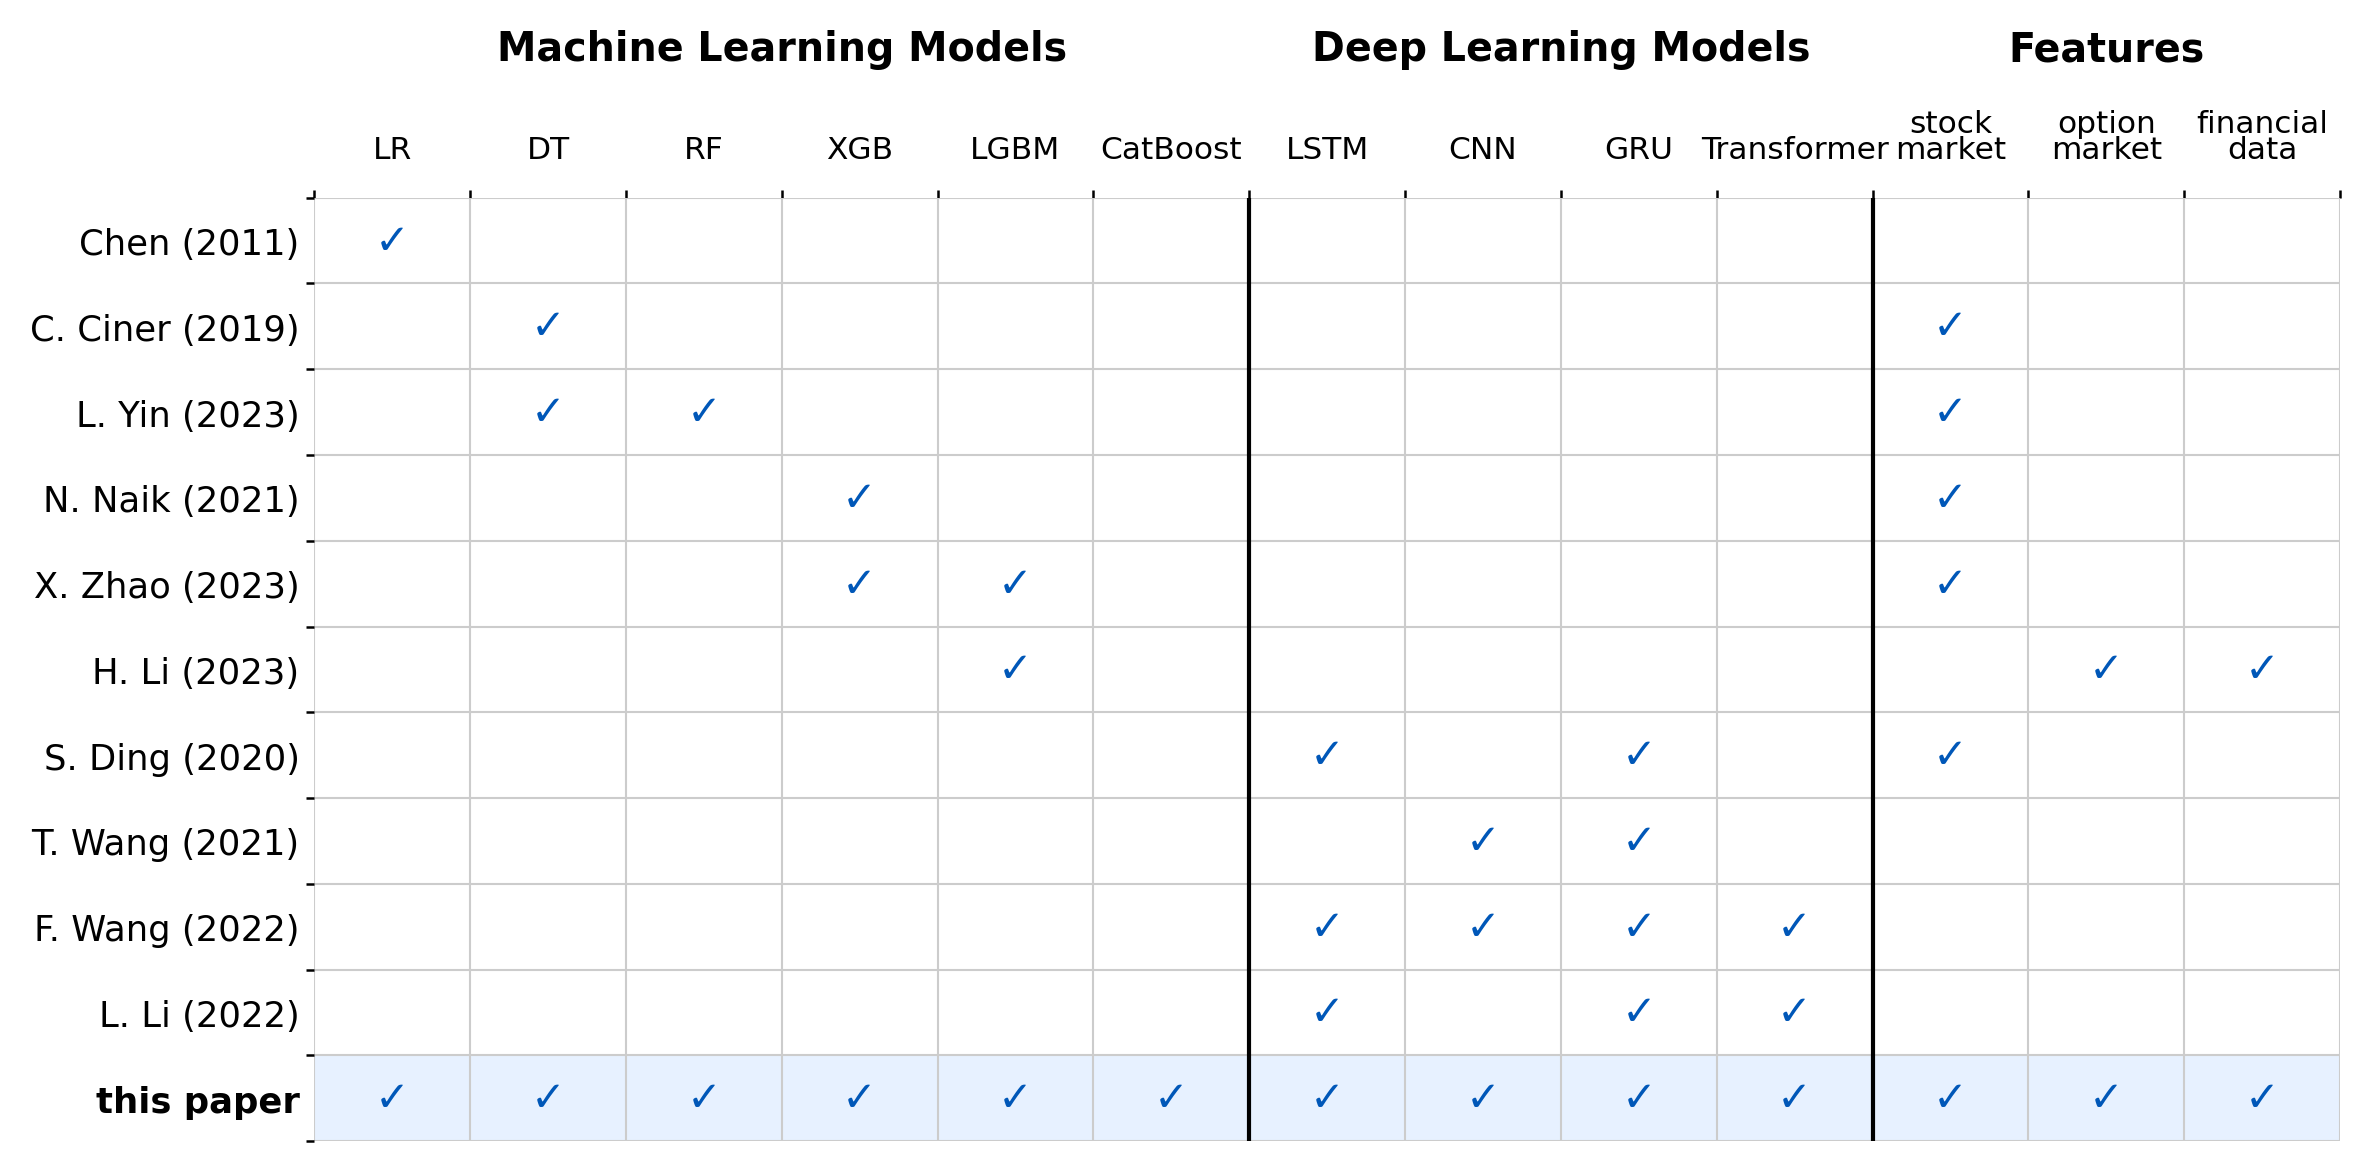

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ----- 1. 데이터 설정 (레이블 수정) --------------------------------
row_labels = [
    "Chen (2011)", "C. Ciner (2019)", "L. Yin (2023)", "N. Naik (2021)",
    "X. Zhao (2023)", "H. Li (2023)", "S. Ding (2020)", "T. Wang (2021)",
    "F. Wang (2022)", "L. Li (2022)", "this paper",
]

# 긴 레이블은 '\n'을 사용해 두 줄로 변경
cols_ml = ["LR", "DT", "RF", "XGB", "LGBM", "CatBoost"]
cols_dl = ["LSTM", "CNN", "GRU", "Transformer"]
cols_dt = ["stock\nmarket", "option\nmarket", "financial\ndata"] # 긴 레이블 수정
col_labels = cols_ml + cols_dl + cols_dt

M = np.array([
    #  LR, DT, RF, XGB,LGBM,Cat,LSTM,CNN,GRU, TF,  st, opt,fin
    [1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
    [0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0],
    [0,  1,  1,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0],
    [0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  1,  0,  0],
    [0,  0,  0,  1,  1,  0,  0,  0,  0,  0,  1,  0,  0],
    [0,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  1,  1],
    [0,  0,  0,  0,  0,  0,  1,  0,  1,  0,  1,  0,  0],
    [0,  0,  0,  0,  0,  0,  0,  1,  1,  0,  0,  0,  0],
    [0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  0,  0,  0],
    [0,  0,  0,  0,  0,  0,  1,  0,  1,  1,  0,  0,  0],
    [1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
], dtype=int)

rows, cols = M.shape

# ----- 2. 그래프 그리기 (전문가 스타일로 수정) --------------------------
fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)
fig.patch.set_facecolor('white')

# 색상 및 스타일 정의
# GRID_COLOR = '#dddddd'
# CHECK_COLOR = '#000000' # 더 진한 검정
# HIGHLIGHT_COLOR = '#f0f0f0'

GRID_COLOR='#cccccc'
CHECK_COLOR='#0057b8'
HIGHLIGHT_COLOR='#e7f1ff'

FONT_SIZE_S = 7.5
FONT_SIZE_M = 8.5
FONT_SIZE_L = 9.5

# 그리드 선
ax.set_xticks(np.arange(-.5, cols, 1), minor=True)
ax.set_yticks(np.arange(-.5, rows, 1), minor=True)
ax.grid(which="minor", color=GRID_COLOR, linestyle='-', linewidth=0.5)

# 체크 표시
for r in range(rows):
    for c in range(cols):
        if M[r, c]:
            ax.text(c, r, "✓", ha="center", va="center", fontsize=10, weight='heavy', color=CHECK_COLOR)

# Y축 (왼쪽): 연구 이름
ax.set_yticks(np.arange(rows))
ax.set_yticklabels(row_labels, fontsize=FONT_SIZE_M)

# X축 (상단): 모델 이름 (회전 없이 수평으로)
ax.set_xticks(np.arange(cols))
ax.set_xticklabels(col_labels, fontsize=FONT_SIZE_S, ha="center", linespacing=0.9)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
ax.tick_params(axis='x', which='major', pad=8)

# ----- 3. 그룹 헤더 및 구분선 -----------------------------------
# 그룹 헤더
header_y_pos = -2.0 # Y 좌표 미세 조정
ax.text(2.5, header_y_pos, "Machine Learning Models", ha="center", va="bottom", fontsize=FONT_SIZE_L, fontweight="bold")
ax.text(7.5, header_y_pos, "Deep Learning Models", ha="center", va="bottom", fontsize=FONT_SIZE_L, fontweight="bold")
ax.text(11, header_y_pos, "Features", ha="center", va="bottom", fontsize=FONT_SIZE_L, fontweight="bold")

# 그룹 구분선
ax.axvline(x=5.5, color='black', linewidth=1.0)
ax.axvline(x=9.5, color='black', linewidth=1.0)

# ----- 4. 마무리 ------------------------------------------------
# 'this paper' 행 강조
this_paper_row_idx = rows - 1
ax.get_yticklabels()[this_paper_row_idx].set_fontweight('bold')
rect = patches.Rectangle((-.5, this_paper_row_idx - 0.5), cols, 1,
                         linewidth=0, edgecolor='none',
                         facecolor=HIGHLIGHT_COLOR, zorder=-1)
ax.add_patch(rect)

# 불필요한 테두리 및 눈금 제거
ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)
ax.tick_params(length=0)

# Y축 범위 조정으로 상단 공간 확보
ax.set_ylim(rows - 0.5, -0.5)

# 레이아웃 최적화
fig.tight_layout(rect=[0, 0, 1, 0.9]) # 상단 여백 추가

# 파일 저장
fig.savefig("final_publication_table.png", pad_inches=0.1)
fig.savefig("final_publication_table.pdf", pad_inches=0.1)

print("성공! 'final_publication_table.png'와 'final_publication_table.pdf' 파일이 저장되었습니다.")

[*********************100%***********************]  1 of 1 completed


삼성전자 주가 데이터를 성공적으로 불러왔습니다.

이중 Y축 다이어그램 생성이 완료되었습니다.
'samsung_stock_wavelet_dual_axis.pdf'와 'samsung_stock_wavelet_dual_axis.png' 파일을 확인해 주세요.


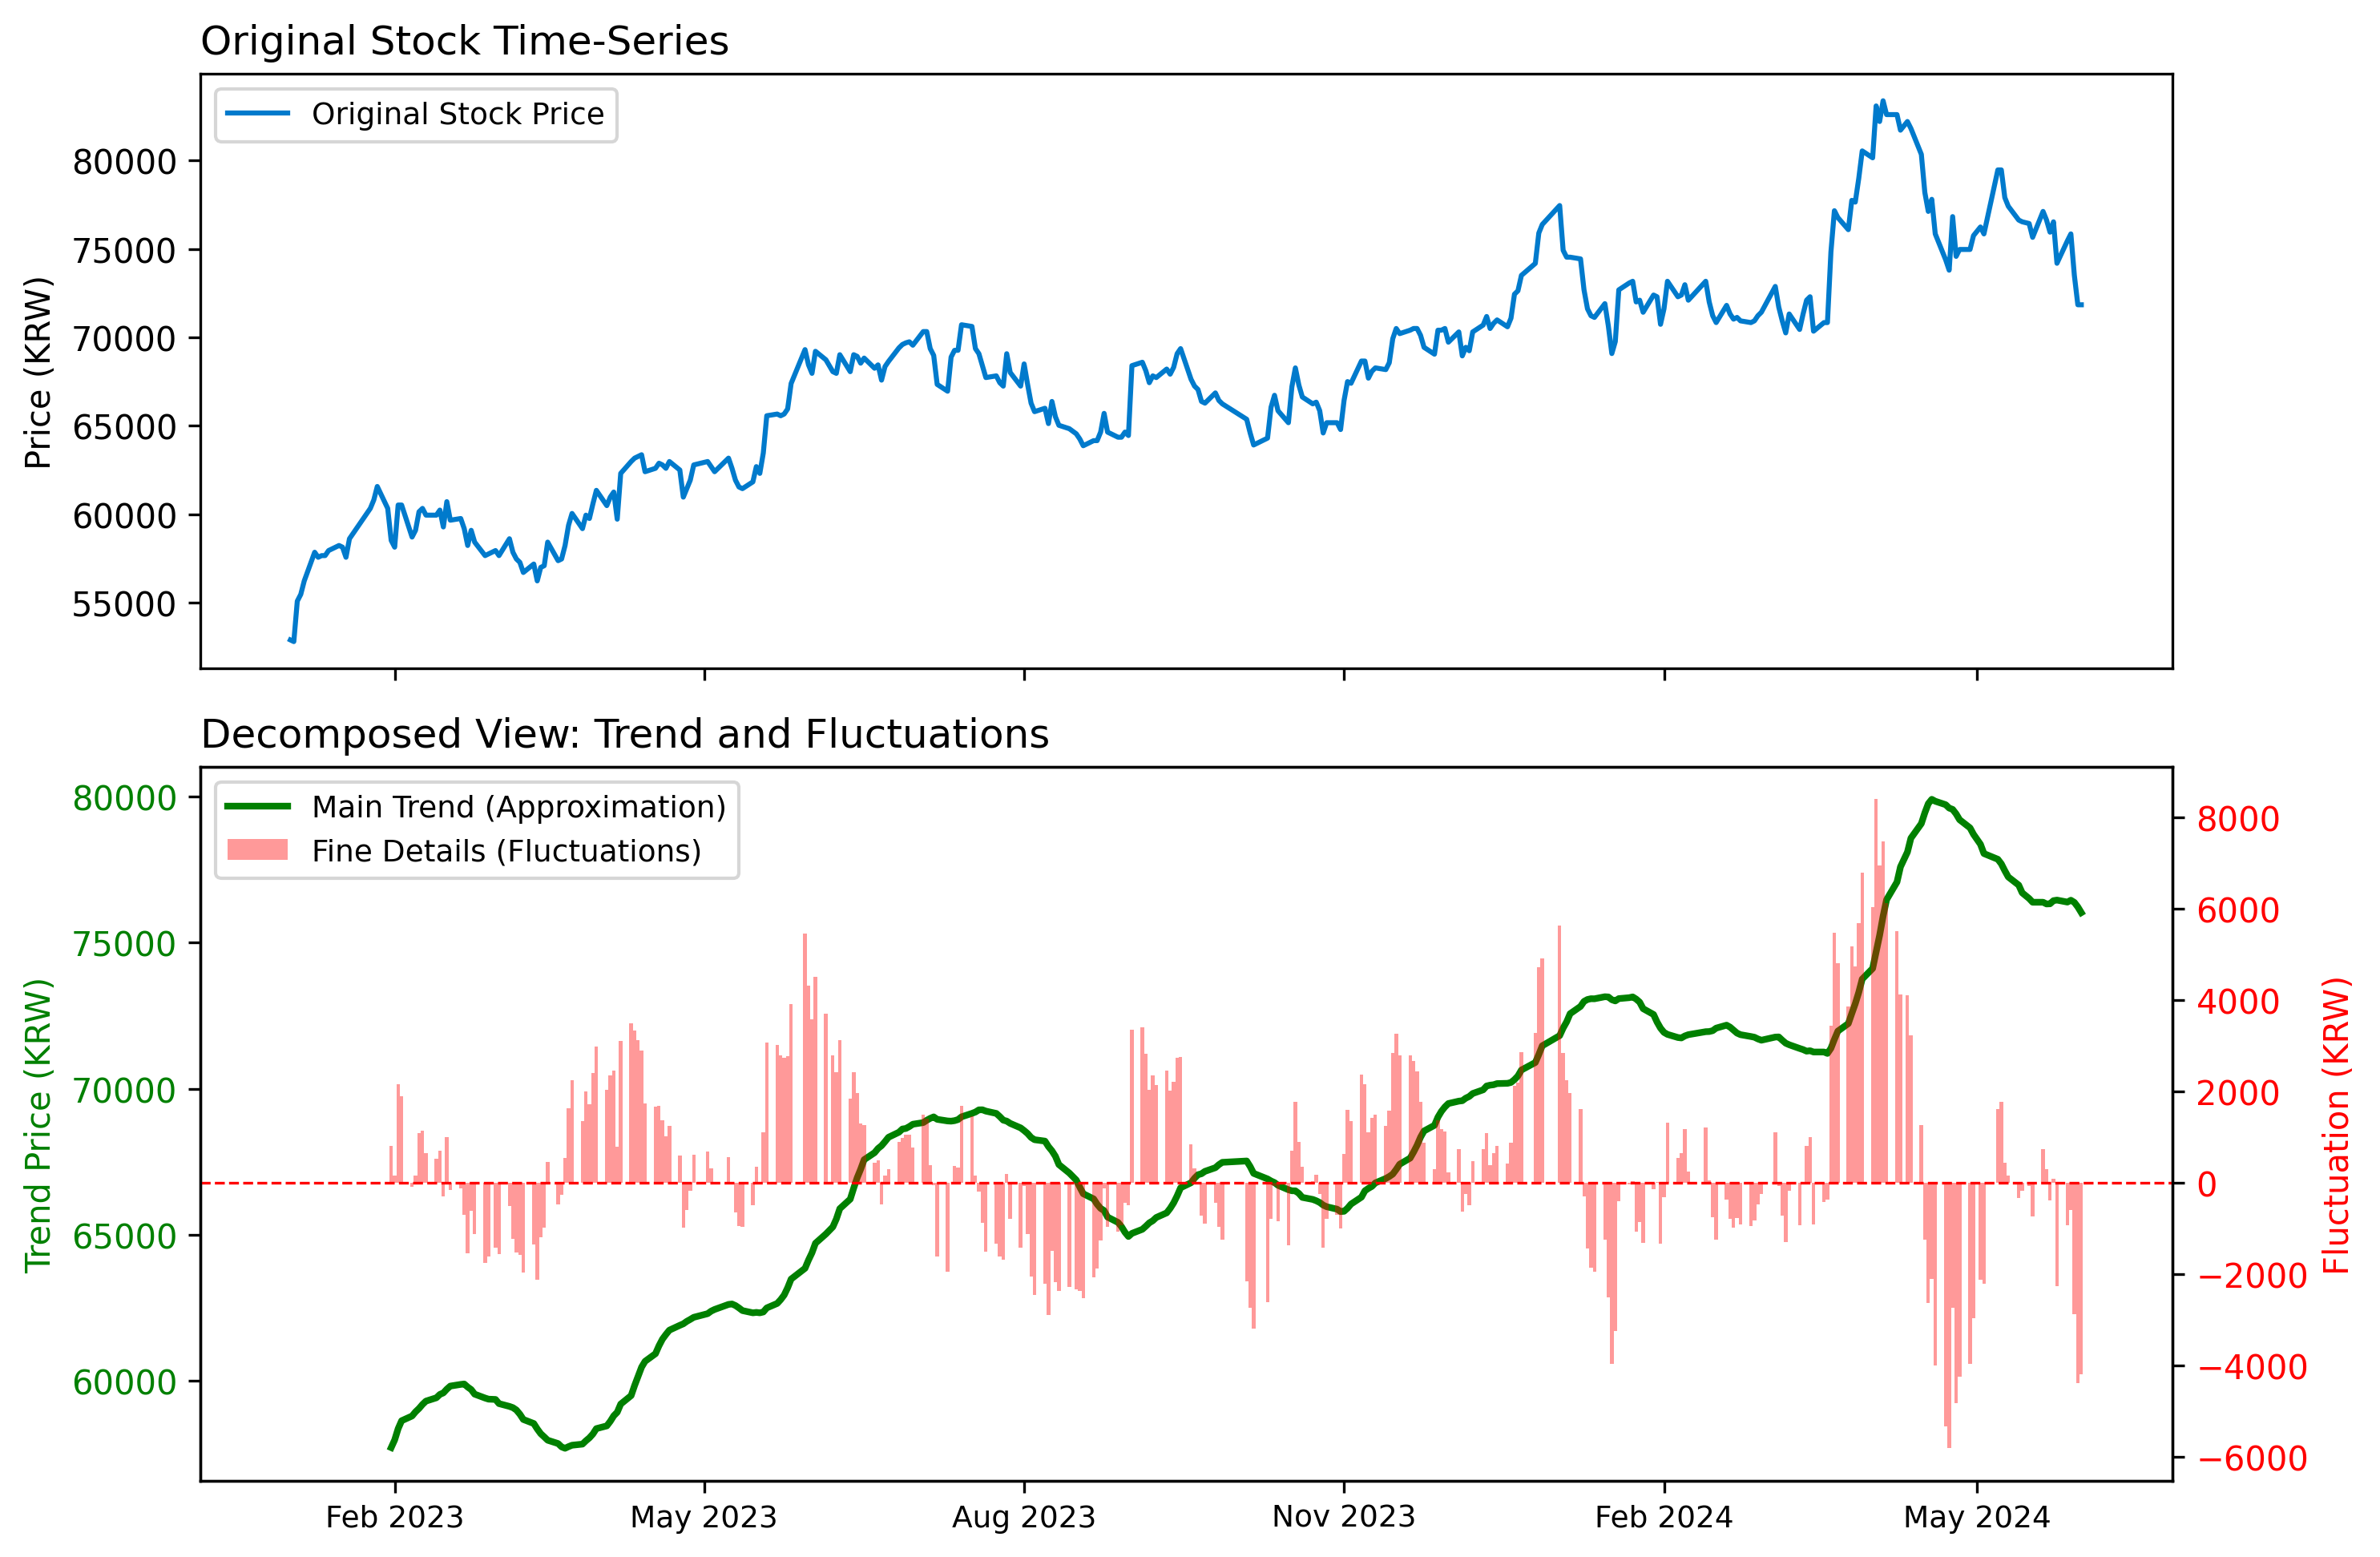

In [ ]:
# 필요한 라이브러리들을 불러옵니다.
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def create_samsung_wavelet_dual_axis():
    """
    이중 Y축을 사용하여 트렌드와 변동을 한 그래프에 겹쳐 그립니다.
    """
    # --- 1. 삼성전자 주가 데이터 불러오기 ---
    try:
        samsung_stock = yf.download('005930.KS', start='2023-01-01', end='2024-06-01', auto_adjust=True)
        if samsung_stock.empty:
            raise ValueError("Stock data could not be downloaded.")
        print("삼성전자 주가 데이터를 성공적으로 불러왔습니다.")
    except Exception as e:
        print(f"데이터 다운로드 중 오류 발생: {e}")
        print("샘플 데이터로 다이어그램을 생성합니다.")
        dates = pd.to_datetime(pd.date_range(start='2023-01-01', periods=350))
        price_data = 75000 + 8000 * np.sin(np.linspace(0, 8, 350)) + np.random.randn(350) * 2000
        samsung_stock = pd.DataFrame({'Close': price_data}, index=dates)

    # --- 2. 데이터 처리 ---
    close_prices = samsung_stock['Close']
    trend = close_prices.rolling(window=20).mean()
    detail = close_prices - trend
    samsung_stock['Trend (cA)'] = trend
    samsung_stock['Detail (cD)'] = detail

    # --- 3. 다이어그램 시각화 (이중 Y축으로 수정) ---
    fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True, dpi=300, facecolor='white',
                           gridspec_kw={'height_ratios': [1, 1.2]}) # 하단 그래프 높이 비율 조정
    #fig.suptitle("Wavelet Decomposition Concept: Samsung Electronics Stock Price", fontsize=16, y=0.98)

    # 플롯 1: 원본 주가 (변경 없음)
    axs[0].plot(samsung_stock.index, samsung_stock['Close'], label='Original Stock Price', color='#007acc', linewidth=1.5)
    axs[0].set_title('Original Stock Time-Series', fontsize=12, loc='left')
    axs[0].legend(loc='upper left', fontsize=9)
    axs[0].set_ylabel('Price (KRW)', fontsize=10)

    # --- 플롯 2: 이중 Y축을 사용한 겹쳐 그리기 ---
    ax2 = axs[1] # 명확성을 위해 변수 할당
    ax2_twin = ax2.twinx() # ax2와 X축을 공유하는 두 번째 Y축 생성

    # 왼쪽 Y축 (ax2): 장기 추세 (녹색)
    line_trend = ax2.plot(samsung_stock.index, samsung_stock['Trend (cA)'], label='Main Trend (Approximation)', color='green', linewidth=2)
    ax2.set_ylabel('Trend Price (KRW)', fontsize=10, color='green')
    ax2.tick_params(axis='y', labelcolor='green')

    # 오른쪽 Y축 (ax2_twin): 단기 변동 (빨간색)
    line_detail = ax2_twin.bar(samsung_stock.index, samsung_stock['Detail (cD)'], label='Fine Details (Fluctuations)', color='red', alpha=0.4, width=1.0)
    ax2_twin.set_ylabel('Fluctuation (KRW)', fontsize=10, color='red')
    ax2_twin.tick_params(axis='y', labelcolor='red')
    ax2_twin.axhline(0, color='red', linestyle='--', linewidth=0.8) # 0 기준선 추가

    ax2.set_title('Decomposed View: Trend and Fluctuations', fontsize=12, loc='left')

    # 범례 합치기
    lines = [line_trend[0], line_detail]
    labels = [l.get_label() for l in lines]
    ax2.legend(lines, labels, loc='upper left', fontsize=9)

    # 모든 플롯에 대한 공통 서식 적용
    for ax in fig.get_axes():
        if not isinstance(ax, type(ax2_twin)): # 쌍둥이 축 제외
             ax.grid(True, linestyle='--', alpha=0.6)
        ax.tick_params(axis='x', which='major', labelsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

    plt.tight_layout(rect=[0, 0, 1, 0.94])

    # --- 4. 파일로 저장 ---
    plt.savefig("samsung_stock_wavelet_dual_axis.pdf", bbox_inches='tight')
    plt.savefig("samsung_stock_wavelet_dual_axis.png", bbox_inches='tight')

    print("\n이중 Y축 다이어그램 생성이 완료되었습니다.")
    print("'samsung_stock_wavelet_dual_axis.pdf'와 'samsung_stock_wavelet_dual_axis.png' 파일을 확인해 주세요.")

    plt.show()

# --- 메인 함수 실행 ---
if __name__ == '__main__':
    create_samsung_wavelet_dual_axis()

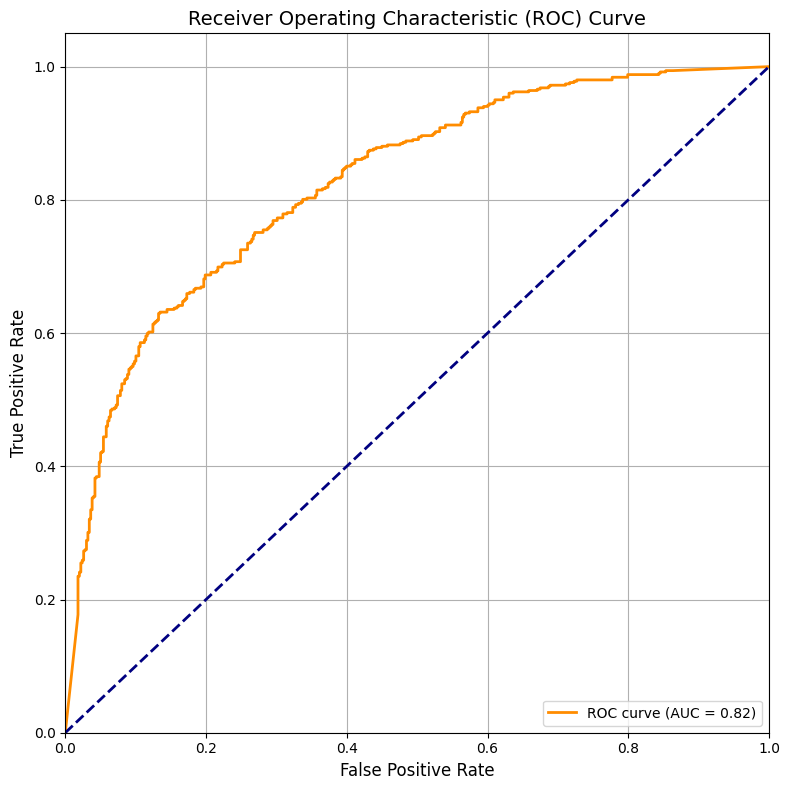

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. 데이터 생성 (Generate Data)
# 실제 레이블 (0 또는 1)
y_true = np.random.randint(0, 2, 1000)

# 예측 점수 (실제값에 따라 확률 분포를 다르게 하여 현실적인 데이터 생성)
# 점수가 덜 명확하게 구분될수록 곡선은 더 부드러워집니다.
y_scores = np.clip(np.random.normal(loc=y_true * 0.4 + 0.3, scale=0.3), 0, 1)


# 2. ROC 커브 및 AUC 계산 (Calculate ROC Curve and AUC)
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)


# 3. 플롯 생성 (Create Plot)
plt.figure(figsize=(8, 8))

# ROC 커브 플롯
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')

# 무작위 추측선 (대각선)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 축 및 제목 설정
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipython-input-1018843750.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Test AUC Score', data=df_long, order=ordered_models, palette='viridis')


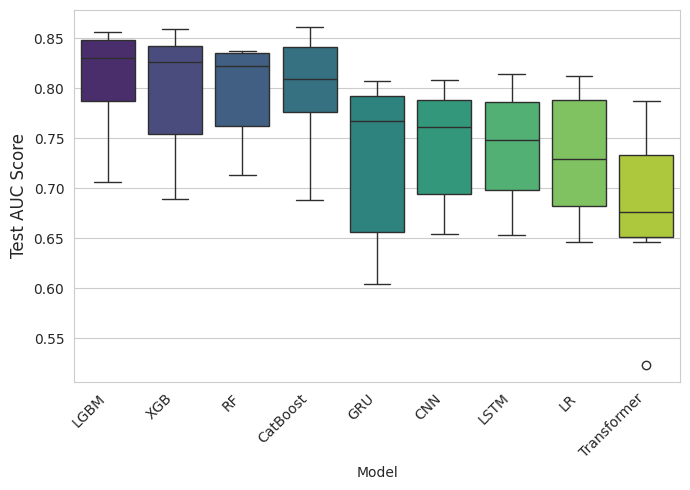

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# 1. Data Initialization: Using the provided data table.
# --------------------------------------------------------------------------
data = {
    'LGBM': [0.706456, 0.778668, 0.825979, 0.855893, 0.771478, 0.847504, 0.853767, 0.847928, 0.83376, 0.812395],
    'CatBoost': [0.687818, 0.776132, 0.767091, 0.779973, 0.77623, 0.841642, 0.861127, 0.841021, 0.847061, 0.83753],
    'XGB': [0.704897, 0.688662, 0.822811, 0.761443, 0.751924, 0.844854, 0.858545, 0.850365, 0.829185, 0.833648],
    'RF': [0.721918, 0.774012, 0.833198, 0.713336, 0.758186, 0.821484, 0.836854, 0.835775, 0.823355, 0.835385],
    'CNN': [0.682321, 0.654382, 0.753212, 0.6783, 0.729764, 0.805592, 0.793624, 0.768979, 0.77311, 0.808088],
    'LSTM': [0.696672, 0.65288, 0.737156, 0.702859, 0.663874, 0.758575, 0.814062, 0.799426, 0.762571, 0.79407],
    'LR': [0.684916, 0.645916, 0.663616, 0.68144, 0.688188, 0.791549, 0.795029, 0.77845, 0.770874, 0.811885],
    'GRU': [0.687247, 0.604094, 0.750414, 0.634099, 0.645447, 0.782796, 0.798046, 0.789933, 0.793311, 0.806578],
    'Transformer': [0.646176, 0.677588, 0.523206, 0.673777, 0.657466, 0.787115, 0.74346, 0.648517, 0.7454, 0.70349]
}

# Convert the dictionary to a Pandas DataFrame
df = pd.DataFrame(data)

# --------------------------------------------------------------------------
# 2. Data Preparation: Convert the DataFrame to a 'long' format.
# --------------------------------------------------------------------------
# The melt function reshapes the DataFrame from wide to long format
df_long = df.melt(var_name='Model', value_name='Test AUC Score')

# --------------------------------------------------------------------------
# 3. Sort Models by Performance: Sort models by their median score.
# --------------------------------------------------------------------------
# Calculate the median Test AUC for each model and sort in descending order
median_scores = df.median().sort_values(ascending=False)

# Get the model names in the new sorted order
ordered_models = median_scores.index

# --------------------------------------------------------------------------
# 4. Plotting: Create the box plot using Seaborn.
# --------------------------------------------------------------------------
# Set the overall plot style and size
sns.set_style("whitegrid")
plt.figure(figsize=(7, 5))

# Create the box plot using Seaborn
# The 'order' parameter ensures the models are plotted in descending order of their median score.
sns.boxplot(x='Model', y='Test AUC Score', data=df_long, order=ordered_models, palette='viridis')

# Set plot title and labels
#plt.title('Model Performance Comparison on Test AUC', fontsize=16, pad=20)
plt.ylabel('Test AUC Score', fontsize=12)
#plt.xlabel('Model', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Automatically adjust plot parameters for a tight layout
plt.tight_layout()

# Display the plot
plt.show()

# --------------------------------------------------------------------------
# 5. Save the plot to a file (optional)
# --------------------------------------------------------------------------
# plt.savefig('model_performance_boxplot.png', dpi=300)

In [ ]:
import numpy as np

# 알고리즘 이름 (k=8) - 실제 데이터 열 순서와 일치하도록 조정
# 원본 data_auc 배열의 열 순서: LGBM, CatBoost, RF, XGB, Transformer, CNN, LSTM, GRU, LR
algorithms_ordered = ["LGBM", "CatBoost", "RF", "XGB", "Transformer", "CNN", "LSTM", "GRU", "LR"]

# Test AUC 데이터
# 행: 기간, 열: 알고리즘 순서대로 (위 algorithms_ordered 순서와 일치)
data_auc = np.array([
    [0.732138, 0.7218, 0.713603, 0.712891, 0.701201, 0.69394, 0.685925, 0.685183, 0.684665],
    [0.635373, 0.848961, 0.836775, 0.758525, 0.713168, 0.864425, 0.679129, 0.681479, 0.682773],
    [0.839214, 0.812762, 0.821247, 0.640456, 0.729622, 0.842195, 0.78013, 0.663817, 0.654436],
    [0.635373, 0.848961, 0.836775, 0.758525, 0.713168, 0.864425, 0.679129, 0.681479, 0.682773],
    [0.754101, 0.763383, 0.753127, 0.682776, 0.675487, 0.758807, 0.723601, 0.68805, 0.701165],
    [0.806231, 0.797304, 0.82163, 0.721406, 0.7278, 0.808634, 0.743926, 0.715858, 0.748668],
    [0.832916, 0.757219, 0.834804, 0.760998, 0.778143, 0.846205, 0.793439, 0.745709, 0.761402],
    [0.731025, 0.846239, 0.842572, 0.768624, 0.763434, 0.838858, 0.7183, 0.729826, 0.766322],
    [0.68533, 0.828631, 0.843212, 0.765873, 0.762624, 0.783891, 0.692431, 0.591769, 0.739857],
    [0.819452, 0.821394, 0.82608, 0.789098, 0.787995, 0.810402, 0.808228, 0.781349, 0.772517],
])

data = {}
for i, algo_name in enumerate(algorithms_ordered):
    data[algo_name] = data_auc[:, i].tolist()

print(data)



{'LGBM': [0.732138, 0.635373, 0.839214, 0.635373, 0.754101, 0.806231, 0.832916, 0.731025, 0.68533, 0.819452], 'CatBoost': [0.7218, 0.848961, 0.812762, 0.848961, 0.763383, 0.797304, 0.757219, 0.846239, 0.828631, 0.821394], 'RF': [0.713603, 0.836775, 0.821247, 0.836775, 0.753127, 0.82163, 0.834804, 0.842572, 0.843212, 0.82608], 'XGB': [0.712891, 0.758525, 0.640456, 0.758525, 0.682776, 0.721406, 0.760998, 0.768624, 0.765873, 0.789098], 'Transformer': [0.701201, 0.713168, 0.729622, 0.713168, 0.675487, 0.7278, 0.778143, 0.763434, 0.762624, 0.787995], 'CNN': [0.69394, 0.864425, 0.842195, 0.864425, 0.758807, 0.808634, 0.846205, 0.838858, 0.783891, 0.810402], 'LSTM': [0.685925, 0.679129, 0.78013, 0.679129, 0.723601, 0.743926, 0.793439, 0.7183, 0.692431, 0.808228], 'GRU': [0.685183, 0.681479, 0.663817, 0.681479, 0.68805, 0.715858, 0.745709, 0.729826, 0.591769, 0.781349], 'LR': [0.684665, 0.682773, 0.654436, 0.682773, 0.701165, 0.748668, 0.761402, 0.766322, 0.739857, 0.772517]}


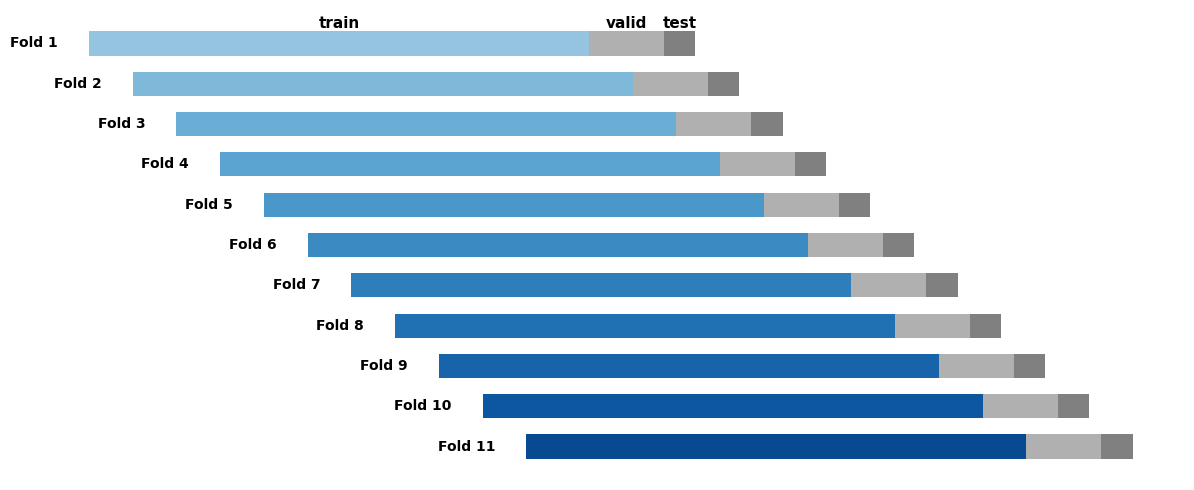

In [ ]:
import matplotlib.pyplot as plt

# 파라미터 설정
num_folds = 11
bar_height = 0.6
train_len = 8
valid_len = 1.2
test_len = 0.5
step = 0.7  # 계단 간격

# train 색상 그라데이션 (파랑 계열)
train_colors = [plt.cm.Blues(0.4 + 0.05 * i) for i in range(num_folds)]
valid_color = '#B0B0B0'  # 밝은 회색
test_color = '#808080'   # 중간 회색

fig, ax = plt.subplots(figsize=(12, 5))

# 각 fold의 막대 그리기
for i in range(num_folds):
    start = i * step
    y = num_folds - i - 1
    # train bar
    ax.barh(y, train_len, left=start, color=train_colors[i], height=bar_height)
    # valid bar
    ax.barh(y, valid_len, left=start + train_len, color=valid_color, height=bar_height)
    # test bar
    ax.barh(y, test_len, left=start + train_len + valid_len, color=test_color, height=bar_height)
    # fold 라벨
    ax.text(start - 0.5, y, f'Fold {i+1}', color='black', va='center', ha='right', fontsize=10, fontweight='bold')

# 첫 번째 바에 라벨 추가 (train, valid, test)
ax.text(train_len / 2, num_folds - 0.5, 'train', color='black', ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(train_len + valid_len / 2, num_folds - 0.5, 'valid', color='black', ha='center', va='center', fontsize=11, fontweight='bold')
ax.text(train_len + valid_len + test_len / 2, num_folds - 0.5, 'test', color='black', ha='center', va='center', fontsize=11, fontweight='bold')

# 축 제거
ax.set_yticks([])
ax.set_xticks([])
ax.axis('off')

plt.tight_layout()
plt.show()


TypeError: create_box() got an unexpected keyword argument 'text_kwargs'

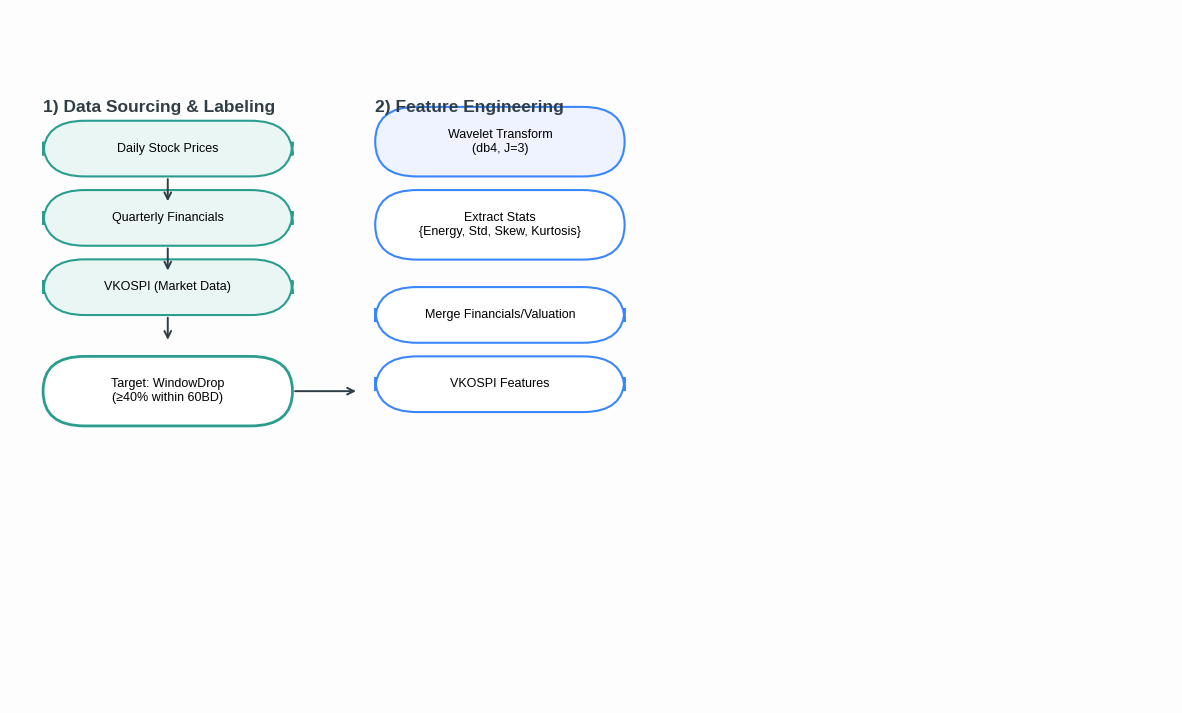

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
import matplotlib.patheffects as pe

# Set up the plot
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(15, 9), facecolor='#fdfdfd')
ax.set_xlim(0, 140)
ax.set_ylim(0, 100)
ax.axis('off')

# --- Palette and Styles ---
primary_color = "#2a9d8f"  # Teal
secondary_color = "#3a86ff" # Blue
accent_color = "#e76f51"  # Red-orange for emphasis
border_color = "#2f3e46"   # Dark grey
box_style = "round,pad=0.018,rounding_size=5"
font_kwargs = {'fontsize': 9, 'color': 'black', 'fontweight': 'regular'}
title_kwargs = {'fontsize': 12.5, 'fontweight': 'bold', 'color': border_color}
text_effect = [pe.withStroke(linewidth=1.5, foreground='white')]

# --- Drawing Functions ---
def create_box(x, y, w, h, text, facecolor='white', edgecolor=border_color, lw=1.5):
    box = FancyBboxPatch((x, y), w, h, boxstyle=box_style, linewidth=lw, edgecolor=edgecolor, facecolor=facecolor)
    ax.add_patch(box)
    ax.text(x + w / 2, y + h / 2, text, ha='center', va='center', **font_kwargs)
    return box

def create_arrow(x1, y1, x2, y2, color=border_color):
    arrow = FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->', mutation_scale=12, linewidth=1.4, color=color)
    ax.add_patch(arrow)

def create_section_title(x, y, title):
    ax.text(x, y, title, va='center', **title_kwargs)

# --- Layout ---
col_width, col_gap = 30, 10
cols = [4 + i * (col_width + col_gap) for i in range(4)]

# --- (1) Data Sourcing & Labeling ---
create_section_title(cols[0], 86, "1) Data Sourcing & Labeling")
create_box(cols[0], 76, col_width, 8, "Daily Stock Prices", facecolor='#e9f6f4', edgecolor=primary_color)
create_box(cols[0], 66, col_width, 8, "Quarterly Financials", facecolor='#e9f6f4', edgecolor=primary_color)
create_box(cols[0], 56, col_width, 8, "VKOSPI (Market Data)", facecolor='#e9f6f4', edgecolor=primary_color)
create_box(cols[0], 40, col_width, 10, "Target: WindowDrop\n(≥40% within 60BD)", edgecolor=primary_color, lw=2)

create_arrow(cols[0] + col_width / 2, 76, cols[0] + col_width / 2, 72)
create_arrow(cols[0] + col_width / 2, 66, cols[0] + col_width / 2, 62)
create_arrow(cols[0] + col_width / 2, 56, cols[0] + col_width / 2, 52)
create_arrow(cols[0] + col_width, 45, cols[1] - 2, 45)

# --- (2) Feature Engineering ---
create_section_title(cols[1], 86, "2) Feature Engineering")
create_box(cols[1], 76, col_width, 10, "Wavelet Transform\n(db4, J=3)", facecolor='#eef3ff', edgecolor=secondary_color)
create_box(cols[1], 64, col_width, 10, "Extract Stats\n{Energy, Std, Skew, Kurtosis}", edgecolor=secondary_color)
create_box(cols[1], 52, col_width, 8, "Merge Financials/Valuation", edgecolor=secondary_color)
create_box(cols[1], 42, col_width, 8, "VKOSPI Features", edgecolor=secondary_color)
create_box(cols[1], 30, col_width, 8, "Final Feature Matrix (X)", edgecolor=secondary_color, lw=2, text_kwargs={'fontweight': 'bold'})

create_arrow(cols[1] + col_width / 2, 76, cols[1] + col_width / 2, 72)
create_arrow(cols[1] + col_width / 2, 64, cols[1] + col_width / 2, 60)
create_arrow(cols[1] + col_width / 2, 52, cols[1] + col_width / 2, 48)
create_arrow(cols[1] + col_width / 2, 42, cols[1] + col_width / 2, 38)
create_arrow(cols[1] + col_width, 34, cols[2] - 2, 34)

# Oversampling Note (Red Dashed Box)
oversampling_note = FancyBboxPatch((cols[1], 16), col_width, 6, boxstyle=box_style, linewidth=2, edgecolor=accent_color, facecolor='none', linestyle=(0, (5, 3)))
ax.add_patch(oversampling_note)
ax.text(cols[1] + col_width / 2, 19, "Oversampling Applied to Train Data ONLY", ha='center', va='center', fontsize=9, fontweight='bold', color=accent_color)

# --- (3) Time-aware Split & Imbalance Handling ---
create_section_title(cols[2], 86, "3) Time-aware Split & Imbalance")
create_box(cols[2], 76, col_width, 8, "Walk-Forward Cross-Validation\n(10 Folds)", edgecolor=border_color)

x_bar_start, y_bar = cols[2] + 2, 66
bar_height, bar_spacing = 5, 0.8
segments = [("Train", 12, primary_color), ("Valid", 6, '#9ecae1'), ("Test", 6, accent_color)]
current_x = x_bar_start
for name, width, color in segments:
    rect = Rectangle((current_x, y_bar), width, bar_height, facecolor=color, edgecolor=border_color, lw=0.8)
    ax.add_patch(rect)
    ax.text(current_x + width / 2, y_bar + bar_height / 2, name, ha='center', va='center', fontsize=8, color='white' if name in ["Train", "Test"] else 'black', fontweight='bold', path_effects=text_effect)
    current_x += width + bar_spacing
    if name == "Train":
        create_arrow(current_x - bar_spacing, y_bar + bar_height / 2, current_x + col_gap / 2, y_bar + bar_height / 2)
        current_x += col_gap / 2

create_box(cols[2], 48, col_width, 8, "Input to Models: Train, Valid, Test sets", edgecolor=border_color)

flag_x, flag_y = cols[2] + col_width / 2 - 3, 38
flag_patch = FancyBboxPatch((flag_x, flag_y), 6, 6, boxstyle=box_style, linewidth=0, facecolor=accent_color)
ax.add_patch(flag_patch)
ax.text(flag_x + 3, flag_y + 3, "L", ha='center', va='center', fontsize=9, color='white', fontweight='bold', path_effects=text_effect)
ax.text(flag_x + 9, flag_y + 3, "No Leakage", fontsize=9.5, color=accent_color, va='center', fontweight='bold')

create_arrow(cols[2] + col_width / 2, 48, cols[2] + col_width / 2, 42)
create_arrow(cols[2] + col_width, 44, cols[3] - 2, 44)

# --- (4) Modeling & Evaluation ---
create_section_title(cols[3], 86, "4) Modeling & Evaluation")
create_box(cols[3], 76, col_width, 8, "Preprocessing (Impute, Scale, etc.)")
create_box(cols[3], 66, col_width, 8, "Imbalance Handling (via oversampling)")
create_box(cols[3], 52, col_width, 12, "Model Zoo:\nLR, RF, XGB, LGBM, CatBoost\nCNN, LSTM, GRU, Transformer", facecolor='#eef3ff', edgecolor=secondary_color)
create_box(cols[3], 38, col_width, 8, "Metrics Calculation:\nAUC, KS, Brier Score", edgecolor=secondary_color)
create_box(cols[3], 24, col_width, 8, "Statistical Comparison:\nFriedman → Nemenyi Post-hoc Test", edgecolor=border_color, lw=2)

create_arrow(cols[3] + col_width / 2, 76, cols[3] + col_width / 2, 72)
create_arrow(cols[3] + col_width / 2, 66, cols[3] + col_width / 2, 62)
create_arrow(cols[3] + col_width / 2, 52, cols[3] + col_width / 2, 48)
create_arrow(cols[3] + col_width / 2, 38, cols[3] + col_width / 2, 34)
create_arrow(cols[3] + col_width / 2, 24, cols[3] + col_width / 2, 20)

# Final results section
ax.text(cols[3] + col_width / 2, 16, "RESULTS", ha='center', va='center', fontsize=11, fontweight='bold', color=border_color)
create_box(cols[3], 8, col_width, 8, "LGBM showed superior performance", facecolor='white', edgecolor=primary_color, lw=2, text_kwargs={'fontweight': 'bold'})

plt.show()